<a href="https://colab.research.google.com/github/jnewbery/wogrin-lecture/blob/m/NPAP_getting_started_DTU_PES_Summer_School.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTANT**: Before proceeding, **create a copy of this notebook** to ensure that any modifications you make remain local to your device. To do so, navigate to **File → Save a copy in Drive**. Please work on the copied version rather than this main file.

In [ ]:
# Colab setup — run this cell first.
!pip install --quiet npap

import sys, os, copy
# Clone the NPAP repo to make examples/utils.py importable.
if not os.path.exists('/content/NPAP'):
  !git clone --quiet --depth 1 https://github.com/IEE-TUGraz/NPAP.git /content/NPAP

sys.path.insert(0, "/content/NPAP/examples")
os.chdir("/content/NPAP/examples")

import plotly.io as pio
pio.renderers.default = "colab"


# Getting Started with NPAP

**NPAP** (Network Partitioning and Aggregation Package) is a standalone, pip-installable
open-source Python library for **reducing the spatial complexity of network graphs**.
Built on top of [NetworkX](https://networkx.org/), it is decoupled from any specific
modelling framework and can therefore be readily integrated into existing tools or used
in isolation.



A key design decision in NPAP is the **explicit separation of the network reduction
process into two distinct steps**:

1. **Partitioning** — maps each vertex (node) in the original network to a group
   (cluster). This step only determines group membership; it does not modify the graph
   itself.
2. **Aggregation** — reduces the network topology based on a given partitioning result by
   aggregating nodes, edges, and their associated properties.

This separation gives users fine-grained control: partitioning algorithms can be swapped
independently of the aggregation method, different aggregation strategies can be applied
to the same partitioning result, or either step can be used in isolation. NPAP follows a
**strategy pattern** architecture so that users can register custom data loaders,
partitioning algorithms, and aggregation rules without modifying the core code. The
library currently provides **13 partitioning strategies** organised in four families and
**two pre-defined aggregation profiles**.

Although NPAP was initially developed with a focus on power systems, its architecture is
general-purpose and applicable to any network graph. The target audience therefore
includes power systems researchers, energy modelers, network analysts, and more broadly,
anyone interested in reducing the spatial complexity of a graph.

This notebook is a **10-minute tour** that shows you how to:

1. Install the library and initialise the `PartitionAggregatorManager` facade (main manager).
2. Load data into NPAP.
3. Pre-process the graph (e.g., aggregate parallel edges).
4. Partition the network into clusters.
5. Aggregate each cluster into a representative node via an `AggregationProfile`.
6. Visualise the network throughout the pipeline.

Section 2 runs the full pipeline on a **general-purpose** focus. Section 3
closes with a short **power-systems** example illustrating NPAP's voltage-aware and
AC-island-aware partitioning on real European high-voltage grid data.

**Full documentation:** **<https://npap.readthedocs.io>**

## Pipeline Architecture

The full NPAP pipeline is shown below. The whole workflow is orchestrated and accessed
through a single facade (main manager) — the `PartitionAggregatorManager` — which coordinates three
specialised manager classes (`InputDataManager`, `PartitioningManager`, and
`AggregationManager`). Each stage of the pipeline is backed by a pluggable strategy and
can be illustrated at any point through the visualization component.

NPAP first prepares the network graph in two stages: data is loaded and a NetworkX graph
is created and validated, then optional pre-processing steps (e.g., parallel-edge
aggregation, voltage-level grouping) prepare the graph for the reduction process. The
reduction itself is then split into the partitioning and aggregation steps introduced
above.

See the [Available Strategies guide](https://npap.readthedocs.io/en/latest/user-guide/available-strategies.html)
for the complete catalogue of loaders, partitioners and aggregators.

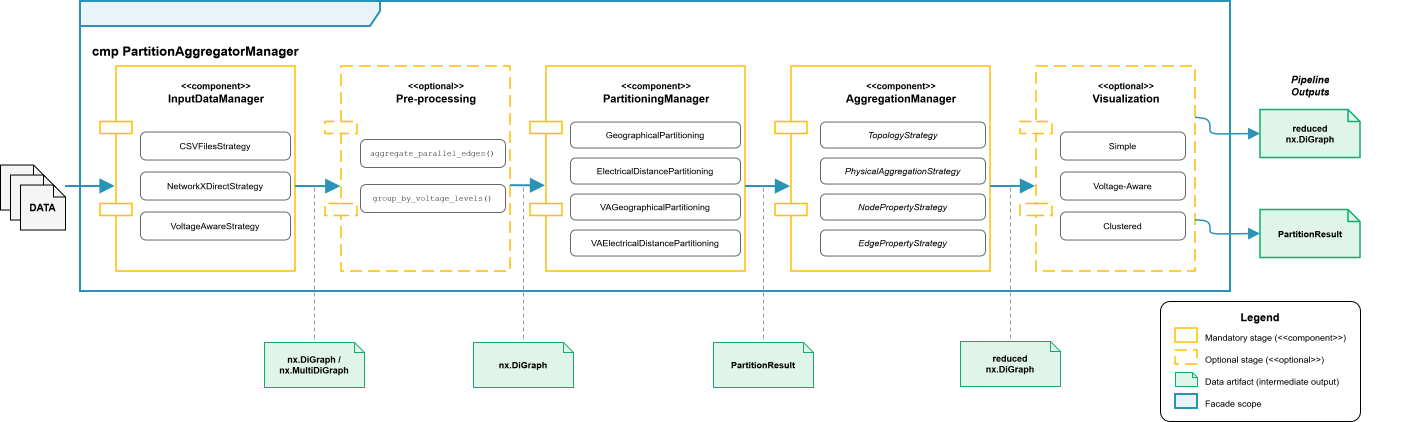

In [ ]:
#@title Pipeline Architecture Figure

from IPython.display import SVG, display

# Use triple quotes so Python handles all the multiple lines correctly
svg_code = """<svg xmlns="http://www.w3.org/2000/svg" style="background: white; background-color: white; color-scheme: light;" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" width="1404px" height="422px" viewBox="0 0 1404 422" content="&lt;mxfile host=&quot;app.diagrams.net&quot; agent=&quot;Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:149.0) Gecko/20100101 Firefox/149.0&quot; version=&quot;29.6.6&quot; scale=&quot;1&quot; border=&quot;0&quot;&gt;&#xA;  &lt;diagram name=&quot;Pipeline Architecture&quot; id=&quot;pipeline-architecture-joss&quot;&gt;&#xA;    &lt;mxGraphModel dx=&quot;3616&quot; dy=&quot;1659&quot; grid=&quot;1&quot; gridSize=&quot;10&quot; guides=&quot;1&quot; tooltips=&quot;1&quot; connect=&quot;1&quot; arrows=&quot;1&quot; fold=&quot;1&quot; page=&quot;1&quot; pageScale=&quot;1&quot; pageWidth=&quot;1550&quot; pageHeight=&quot;520&quot; math=&quot;0&quot; shadow=&quot;0&quot;&gt;&#xA;      &lt;root&gt;&#xA;        &lt;mxCell id=&quot;0&quot; /&gt;&#xA;        &lt;mxCell id=&quot;1&quot; parent=&quot;0&quot; /&gt;&#xA;        &lt;mxCell id=&quot;frame&quot; parent=&quot;1&quot; style=&quot;shape=umlFrame;whiteSpace=wrap;html=1;fillColor=#E8F4F8;strokeColor=#2993B5;strokeWidth=2;fontSize=13;fontFamily=Helvetica;fontStyle=1;width=300;height=25;verticalAlign=top;align=left;spacingLeft=10;spacingTop=35;rounded=0;&quot; value=&quot;cmp  PartitionAggregatorManager&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;290&quot; width=&quot;1150&quot; x=&quot;70&quot; y=&quot;-10&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;input-mgr&quot; parent=&quot;1&quot; style=&quot;shape=component;align=center;spacingLeft=36;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #0FAD6B);strokeWidth=1.5;fontSize=11;fontFamily=Helvetica;fontStyle=1;html=1;verticalAlign=top;spacingTop=5;&quot; value=&quot;&amp;lt;font style=&amp;quot;font-size: 9px;&amp;quot;&amp;gt;&amp;amp;lt;&amp;amp;lt;component&amp;amp;gt;&amp;amp;gt;&amp;lt;/font&amp;gt;&amp;#xa;InputDataManager&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;205&quot; width=&quot;195&quot; x=&quot;90&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;csv&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;CSVFilesStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;150&quot; x=&quot;130&quot; y=&quot;120.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;nx-direct&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;NetworkXDirectStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;150&quot; x=&quot;130&quot; y=&quot;160.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;va-load&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;VoltageAwareStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;150&quot; x=&quot;130&quot; y=&quot;200.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;preproc&quot; parent=&quot;1&quot; style=&quot;shape=component;align=center;spacingLeft=36;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #3691af);strokeWidth=1.5;fontSize=11;fontFamily=Helvetica;fontStyle=1;html=1;dashed=1;dashPattern=8 4;verticalAlign=top;spacingTop=5;&quot; value=&quot;&amp;lt;font style=&amp;quot;font-size: 9px;&amp;quot;&amp;gt;&amp;amp;lt;&amp;amp;lt;optional&amp;amp;gt;&amp;amp;gt;&amp;lt;/font&amp;gt;&amp;#xa;Pre-processing&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;205&quot; width=&quot;185&quot; x=&quot;315&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;agg-edges&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=8;fontFamily=Courier New;arcSize=20;&quot; value=&quot;aggregate_parallel_edges()&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;145&quot; x=&quot;350&quot; y=&quot;128&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;group-volt&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=8;fontFamily=Courier New;arcSize=20;&quot; value=&quot;group_by_voltage_levels()&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;145&quot; x=&quot;350&quot; y=&quot;173&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;part-mgr&quot; parent=&quot;1&quot; style=&quot;shape=component;align=center;spacingLeft=36;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #ededed);strokeWidth=1.5;fontSize=11;fontFamily=Helvetica;fontStyle=1;html=1;verticalAlign=top;spacingTop=5;&quot; value=&quot;&amp;lt;font style=&amp;quot;font-size: 9px;&amp;quot;&amp;gt;&amp;amp;lt;&amp;amp;lt;component&amp;amp;gt;&amp;amp;gt;&amp;lt;/font&amp;gt;&amp;#xa;PartitioningManager&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;205&quot; width=&quot;215&quot; x=&quot;520&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;geo&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;GeographicalPartitioning&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;170&quot; x=&quot;560&quot; y=&quot;110.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;elec&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;ElectricalDistancePartitioning&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;170&quot; x=&quot;560&quot; y=&quot;146.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;va-geo&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;VAGeographicalPartitioning&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;170&quot; x=&quot;560&quot; y=&quot;182.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;va-elec&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;VAElectricalDistancePartitioning&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;170&quot; x=&quot;560&quot; y=&quot;218.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;agg-mgr&quot; parent=&quot;1&quot; style=&quot;shape=component;align=center;spacingLeft=36;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #ededed);strokeWidth=1.5;fontSize=11;fontFamily=Helvetica;fontStyle=1;html=1;verticalAlign=top;spacingTop=5;&quot; value=&quot;&amp;lt;font style=&amp;quot;font-size: 9px;&amp;quot;&amp;gt;&amp;amp;lt;&amp;amp;lt;component&amp;amp;gt;&amp;amp;gt;&amp;lt;/font&amp;gt;&amp;#xa;AggregationManager&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;205&quot; width=&quot;215&quot; x=&quot;765&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;topo&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;fontStyle=2;arcSize=20;&quot; value=&quot;TopologyStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;165&quot; x=&quot;810&quot; y=&quot;110.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;phys&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;fontStyle=2;arcSize=20;&quot; value=&quot;PhysicalAggregationStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;165&quot; x=&quot;810&quot; y=&quot;146.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;node-prop&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;fontStyle=2;arcSize=20;&quot; value=&quot;NodePropertyStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;165&quot; x=&quot;810&quot; y=&quot;182.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;edge-prop&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;fontStyle=2;arcSize=20;&quot; value=&quot;EdgePropertyStrategy&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;26&quot; width=&quot;165&quot; x=&quot;810&quot; y=&quot;218.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;vis&quot; parent=&quot;1&quot; style=&quot;shape=component;align=center;spacingLeft=36;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #3691af);strokeWidth=1.5;fontSize=11;fontFamily=Helvetica;fontStyle=1;html=1;dashed=1;dashPattern=8 4;verticalAlign=top;spacingTop=5;&quot; value=&quot;&amp;lt;font style=&amp;quot;font-size: 9px;&amp;quot;&amp;gt;&amp;amp;lt;&amp;amp;lt;optional&amp;amp;gt;&amp;amp;gt;&amp;lt;/font&amp;gt;&amp;#xa;Visualization&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;205&quot; width=&quot;175&quot; x=&quot;1010&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;simple-vis&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;Simple&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;125&quot; x=&quot;1050&quot; y=&quot;120.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;va-vis&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;Voltage-Aware&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;125&quot; x=&quot;1050&quot; y=&quot;160.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;clust-vis&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#666666;fontSize=9;fontFamily=Helvetica;arcSize=20;&quot; value=&quot;Clustered&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;28&quot; width=&quot;125&quot; x=&quot;1050&quot; y=&quot;200.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;data-in&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#F5F5F5;strokeColor=#000000;fontSize=10;fontFamily=Helvetica;fontStyle=1;size=12;&quot; value=&quot;DATA&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;45&quot; x=&quot;-10&quot; y=&quot;153.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-in&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=block;endFill=1;endSize=10;html=1;strokeColor=#2993B5;strokeWidth=2;entryX=0.075;entryY=0.585;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;input-mgr&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;55&quot; y=&quot;175&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;90&quot; y=&quot;175&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-1-2&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=block;endFill=1;endSize=10;html=1;strokeColor=#2993B5;strokeWidth=2;entryX=0.083;entryY=0.586;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;preproc&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;285&quot; y=&quot;175&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;315&quot; y=&quot;175&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-2-3&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=block;endFill=1;endSize=10;html=1;strokeColor=#2993B5;strokeWidth=2;entryX=0.07;entryY=0.582;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;part-mgr&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;500&quot; y=&quot;174.21&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;530&quot; y=&quot;174.21&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-3-4&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=block;endFill=1;endSize=10;html=1;strokeColor=#2993B5;strokeWidth=2;entryX=0.07;entryY=0.586;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;agg-mgr&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;735&quot; y=&quot;175&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;765&quot; y=&quot;175&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-4-5&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=block;endFill=1;endSize=10;html=1;strokeColor=#2993B5;strokeWidth=2;entryX=0.086;entryY=0.585;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;vis&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;980&quot; y=&quot;175&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;1010&quot; y=&quot;175&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;out-graph&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);strokeWidth=1.5;fontSize=9;fontFamily=Helvetica;fontStyle=1;size=12;&quot; value=&quot;reduced&amp;#xa;nx.DiGraph&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;48&quot; width=&quot;100&quot; x=&quot;1250&quot; y=&quot;98.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;out-partition&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #b4d1d9);strokeWidth=1.5;fontSize=9;fontFamily=Helvetica;fontStyle=1;size=12;&quot; value=&quot;PartitionResult&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;48&quot; width=&quot;100&quot; x=&quot;1250&quot; y=&quot;198.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;out-label&quot; parent=&quot;1&quot; style=&quot;text;fontSize=10;fontFamily=Helvetica;fontStyle=3;html=1;fillColor=none;strokeColor=none;align=center;&quot; value=&quot;Pipeline&amp;#xa;Outputs&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;30&quot; width=&quot;90&quot; x=&quot;1255&quot; y=&quot;55&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-out-1&quot; edge=&quot;1&quot; parent=&quot;1&quot; source=&quot;vis&quot; style=&quot;endArrow=block;endFill=1;endSize=8;html=1;strokeColor=#2993B5;strokeWidth=1.5;entryX=0;entryY=0.5;entryDx=0;entryDy=0;entryPerimeter=0;exitX=1;exitY=0.25;exitDx=0;exitDy=0;&quot; target=&quot;out-graph&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;Array as=&quot;points&quot;&gt;&#xA;              &lt;mxPoint x=&quot;1200&quot; y=&quot;108&quot; /&gt;&#xA;              &lt;mxPoint x=&quot;1200&quot; y=&quot;123&quot; /&gt;&#xA;            &lt;/Array&gt;&#xA;            &lt;mxPoint x=&quot;1185&quot; y=&quot;135&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;1320&quot; y=&quot;104&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;arrow-out-2&quot; edge=&quot;1&quot; parent=&quot;1&quot; source=&quot;vis&quot; style=&quot;endArrow=block;endFill=1;endSize=8;html=1;strokeColor=#2993B5;strokeWidth=1.5;entryX=0;entryY=0.5;entryDx=0;entryDy=0;entryPerimeter=0;exitX=1;exitY=0.75;exitDx=0;exitDy=0;&quot; target=&quot;out-partition&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;Array as=&quot;points&quot;&gt;&#xA;              &lt;mxPoint x=&quot;1200&quot; y=&quot;210&quot; /&gt;&#xA;              &lt;mxPoint x=&quot;1200&quot; y=&quot;223&quot; /&gt;&#xA;            &lt;/Array&gt;&#xA;            &lt;mxPoint x=&quot;1185&quot; y=&quot;175&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;1320&quot; y=&quot;172&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;art-4&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);fontSize=9;fontFamily=Helvetica;fontStyle=1;size=10;&quot; value=&quot;reduced&amp;#xa;nx.DiGraph&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;100&quot; x=&quot;950&quot; y=&quot;330&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;dart-4&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=none;dashed=1;html=1;strokeColor=#999999;dashPattern=4 3;entryX=0.5;entryY=0;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;art-4&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;1000&quot; y=&quot;176&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;998&quot; y=&quot;345&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;legend-frame&quot; parent=&quot;1&quot; style=&quot;rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#000000;fontSize=11;fontFamily=Helvetica;fontStyle=1;arcSize=8;verticalAlign=top;spacingTop=2;&quot; value=&quot;Legend&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;120&quot; width=&quot;200&quot; x=&quot;1150&quot; y=&quot;290&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-1&quot; parent=&quot;1&quot; style=&quot;rounded=0;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #ededed);strokeWidth=1.5;fontSize=9;fontFamily=Helvetica;&quot; value=&quot;&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;14&quot; width=&quot;22&quot; x=&quot;1165&quot; y=&quot;317&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-1-text&quot; parent=&quot;1&quot; style=&quot;text;fontSize=9;fontFamily=Helvetica;html=1;fillColor=none;strokeColor=none;align=left;&quot; value=&quot;Mandatory stage (&amp;amp;lt;&amp;amp;lt;component&amp;amp;gt;&amp;amp;gt;)&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;18&quot; width=&quot;200&quot; x=&quot;1193&quot; y=&quot;314&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-2&quot; parent=&quot;1&quot; style=&quot;rounded=0;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=light-dark(#ffbf00, #3691af);strokeWidth=1.5;fontSize=9;fontFamily=Helvetica;dashed=1;dashPattern=8 4;&quot; value=&quot;&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;14&quot; width=&quot;22&quot; x=&quot;1165&quot; y=&quot;339&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-2-text&quot; parent=&quot;1&quot; style=&quot;text;fontSize=9;fontFamily=Helvetica;html=1;fillColor=none;strokeColor=none;align=left;&quot; value=&quot;Optional stage (&amp;amp;lt;&amp;amp;lt;optional&amp;amp;gt;&amp;amp;gt;)&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;18&quot; width=&quot;200&quot; x=&quot;1193&quot; y=&quot;336&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-3&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);fontSize=9;fontFamily=Helvetica;size=5;&quot; value=&quot;&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;14&quot; width=&quot;22&quot; x=&quot;1165&quot; y=&quot;361&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-3-text&quot; parent=&quot;1&quot; style=&quot;text;fontSize=9;fontFamily=Helvetica;html=1;fillColor=none;strokeColor=none;align=left;&quot; value=&quot;Data artifact (intermediate output)&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;18&quot; width=&quot;200&quot; x=&quot;1193&quot; y=&quot;358&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-4&quot; parent=&quot;1&quot; style=&quot;rounded=0;whiteSpace=wrap;html=1;fillColor=#E8F4F8;strokeColor=#2993B5;strokeWidth=2;fontSize=9;fontFamily=Helvetica;&quot; value=&quot;&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;14&quot; width=&quot;22&quot; x=&quot;1165&quot; y=&quot;383&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;leg-4-text&quot; parent=&quot;1&quot; style=&quot;text;fontSize=9;fontFamily=Helvetica;html=1;fillColor=none;strokeColor=none;align=left;&quot; value=&quot;&amp;lt;div&amp;gt;Facade scope&amp;lt;/div&amp;gt;&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;18&quot; width=&quot;200&quot; x=&quot;1193&quot; y=&quot;380&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-1&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#F5F5F5;strokeColor=#000000;fontSize=10;fontFamily=Helvetica;fontStyle=1;size=12;&quot; value=&quot;DATA&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;45&quot; y=&quot;163.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-2&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#F5F5F5;strokeColor=#000000;fontSize=10;fontFamily=Helvetica;fontStyle=1;size=12;&quot; value=&quot;DATA&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;45&quot; x=&quot;10&quot; y=&quot;173.5&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-3&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);fontSize=9;fontFamily=Helvetica;fontStyle=1;size=10;&quot; value=&quot;PartitionResult&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;100&quot; x=&quot;703&quot; y=&quot;331&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-4&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=none;dashed=1;html=1;strokeColor=#999999;dashPattern=4 3;entryX=0.5;entryY=0;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;_T5SmF-n8n5hG3BHDfqH-3&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;753&quot; y=&quot;176&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;751&quot; y=&quot;346&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-5&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);fontSize=9;fontFamily=Helvetica;fontStyle=1;size=10;&quot; value=&quot;nx.DiGraph&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;100&quot; x=&quot;463&quot; y=&quot;331&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-6&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=none;dashed=1;html=1;strokeColor=#999999;dashPattern=4 3;entryX=0.5;entryY=0;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;_T5SmF-n8n5hG3BHDfqH-5&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;513&quot; y=&quot;176&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;511&quot; y=&quot;346&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-7&quot; parent=&quot;1&quot; style=&quot;shape=note;whiteSpace=wrap;html=1;backgroundOutline=1;fillColor=#E0F5E9;strokeColor=light-dark(#0fad6b, #ededed);fontSize=9;fontFamily=Helvetica;fontStyle=1;size=10;&quot; value=&quot;nx.DiGraph /&amp;lt;br&amp;gt;nx.MultiDiGraph&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry height=&quot;45&quot; width=&quot;100&quot; x=&quot;254&quot; y=&quot;331&quot; as=&quot;geometry&quot; /&gt;&#xA;        &lt;/mxCell&gt;&#xA;        &lt;mxCell id=&quot;_T5SmF-n8n5hG3BHDfqH-8&quot; edge=&quot;1&quot; parent=&quot;1&quot; style=&quot;endArrow=none;dashed=1;html=1;strokeColor=#999999;dashPattern=4 3;entryX=0.5;entryY=0;entryDx=0;entryDy=0;entryPerimeter=0;&quot; target=&quot;_T5SmF-n8n5hG3BHDfqH-7&quot; vertex=&quot;1&quot;&gt;&#xA;          &lt;mxGeometry relative=&quot;1&quot; as=&quot;geometry&quot;&gt;&#xA;            &lt;mxPoint x=&quot;304&quot; y=&quot;176&quot; as=&quot;sourcePoint&quot; /&gt;&#xA;            &lt;mxPoint x=&quot;302&quot; y=&quot;346&quot; as=&quot;targetPoint&quot; /&gt;&#xA;          &lt;/mxGeometry&gt;&#xA;        &lt;/mxCell&gt;&#xA;      &lt;/root&gt;&#xA;    &lt;/mxGraphModel&gt;&#xA;  &lt;/diagram&gt;&#xA;&lt;/mxfile&gt;&#xA;"><defs/><g><g data-cell-id="0"><g data-cell-id="1"><g data-cell-id="frame"><g><path d="M 80 1 L 380 1 L 380 11 L 370 26 L 80 26 Z" fill="#e8f4f8" style="fill: light-dark(rgb(232, 244, 248), rgb(20, 31, 34)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/><path d="M 380 1 L 1230 1 L 1230 291 L 80 291 L 80 26" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe flex-start; width: 288px; height: 1px; padding-top: 43px; margin-left: 92px;"><div style="box-sizing: border-box; font-size: 0; text-align: left; color: #000000; "><div style="display: inline-block; font-size: 13px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">cmp  PartitionAggregatorManager</div></div></div></foreignObject><image x="92" y="43.5" width="288" height="19.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAABIAAAABNCAYAAADekR8jAAAgAElEQVR4Xu2dXchGS1XH9T4J86oujmFdKH6GlqIoKllwKERF+1BENLQuRAQVixCROEohB/FCEw2RREtMBBFSUVGU0oRjJnWhwvGirkzE7mv9852cNjPrv2bN7OfZ737/Dwzn493z9Zs1a9Zae/bMQx+inwiIgAiIgAiIgAiIgAiIgAiIgAiIgAiIwKkJPPTUvVPnREAEREAEREAEREAEREAEREAEREAEREAEHqIAkIRABERABERABERABERABERABERABERABE5OQAGgkw+wuicCIiACIiACIiACIiACIiACIiACIiACCgBJBkRABERABERABERABERABERABERABETg5AQUADr5AKt7IiACIiACIiACIiACIiACIiACIiACIqAAkGRABERABERABERABERABERABERABERABE5OQAGgkw+wuicCIiACIiACIiACIiACIiACIiACIiACCgBJBkRABERABERABERABERABERABERABETg5AQUADr5AKt7IiACIiACIiACIiACIiACIiACIiACIqAAkGRABERABERABERABERABERABERABERABE5OQAGgkw+wuicCIiACIiACIiACIiACIiACIiACIiACCgDdTRn4B+v2Uxd0/R9vynjQ/vmApb+19N0F5d7FIrwx+QsD8qadoVy7/p27d9Xif9Vq/1qgBZ+xZ34z8JweEQERuBsERtbq9xmS1wxi+Q17/u8H8kA/QU/pJwIiIAIiIAIicEsJKAB0SwdustkjRuVoVQgC/ZGl/xzNeMLnYVy/KGiU7xGA+UOr++GW3h5gu0f9gWrvxCN/ab18dbCnj9DcCZLSY3eFwIgePRuTkbX636zzjxkE8Of2/BsH8igANABLj4qACIiACIjAEQkoAHTEUdm/TSNGZaY1/2WZnmvp65nMJ8iDHR/vtoRdVtgl9bRAn1YGYH7H6rvf0s9biu4eWll/oLt36pEfW29/JtjjP7HnIgG7YHF6TARuLYGMHr21ne00fHSt/mUrZ2QX7mj5CgCdTcLUHxEQAREQgTtHQAGgOzfk/9vhUaMvQ+kuBoF+yUDdZ+klFbBLBoDwpvxtlurP+xQAykjvujwIxn10oLjMW/yB4vWoCByewIwePXznBhs4ulZj9+17B+r474Fn8agCQIPA9LgIiIAIiIAIHI2AAkBHG5HLtGfUqMy2CkGgR1o6++dgP2d9fLMlGN/bnR6XCAC1HKYyZgoAZaV3TT6cr4HA3Mjv1+zhu7p7boSTnj0XgRV69FxExl/W4BNsBJ0jv9HgNMpUAChCVs+IgAiIgAiIwIEJKAB04MHZsWmXCgChCyMG6Y5d3rVo7xyFSwSAVny+taKMXSHfwsLh0P4g0e67MGcSWJTl5ARW6NGzIRpdq/HS5WFBCCNnk5UiFQAKwtVjIiACIiACInBUAgoAHXVk9m3XqFE525rRcwlm67t0/ms7LgreXHrEY/XhEO73xB79f0+NOHGJ4pVFBA5J4Np69IhQMmt1dAfhv1qHHz3YaQWABoHpcREQAREQARE4GgEFgI42Ipdpj2dURnas4JMW3C71Qkv1eTe91p/9YNtrOy4KAF1m3ozW4jlYuLLZuxls9CyP0bbpeRE4GoFr69Gj8UB7MgGgyHqb3Z2oANARpURtEgEREAEREIEBAgoADcA60aOzAaAaBYJBH7fk3XL0Gfs7DMez/q7tuCgAdDzJwrlM33GahV1xn7LUewMfCcQer9dqkQjkCVxbj+Zbvl9OT7djp2Br3Y2st73diTiE3tsVpADQfmOtkkVABERABETgIgSiASC8LcJOj+dYwqG+9S1DaCiMhu9b+qIlfFe+16G/CDa8ytITKiMFRtBXLX3CErv9Av14jaWXb4wcOFvftAQDdOQK1ZFBgsH1AktPt1SMtv+wf/9WsO0jdbFnVwaAUBc7THLEmWWyVuTtR/YvX7L0MUt7HJiLK4j/zFI5wLfI2V/Z//ubDeBrOy5HDQAhCAK98XxL91jCtfTlB57fvpl3799pDLfzAO15k6UnWqp1GObhly19wRLTIWxulb9752uUm77+2B7GrXG938pPJ8u8gg56fDUWRa7faf8PjuNev1oWHmuV1DoQ7LFrYS/d2+oTeODzvHurtkBPfdASzmBia1itp+r1CHUV2V6tn67NEHr+uZYwf+oxLHwxj2AHYC39vKWtnmSytbcehU7/g077S9s/eTP+e8riiOyxtbo1DuDMbDuMTWv3LtuZOBoAKjL7bKsPa0AruIR5h/X8izuzL/Yf1qOaW9GBqH+F/Qo5e7GlZ930uV73av3woP0H1pyIvmFz59q6oR7nen1Bu4ude4nxndHpjLH+LgIiIAKnIcCMBO9WDg8CjAg4N8yIRhk9A6cOGmBx+bClbeBp2wY4VgjutAICCMDgRiRvpwrKi7YdgQHc8NP61Tcv4bkPWtoaAdt8WCRfb2nUaM4IIzMqn5Yo9MeE7V6yhqaC3SssRRxYz8kobWRnt6Ce0ZudaqStgNhIEMeTvcjQtW4GG6mf1dG6jp7lwRjiCvvRAExEf0CPvd2S98lVad+qefjvzpwvn2iwXULRG9wYW+hi1Ml0H+TypZaK8+vNlagjOMJ+q3s9mezpE29ulDbDQUOAoscDMvA4S731C1xaN/71xgFc3xLUT60yLs1w2wboQ7SfrWHbfHCsEeDE3Ov9Rq8hr8uJvljItD8zZnvIHlurEThprUVsfvb00+9aeR91xouVW7J6N1MyfbXVQ97zkfUc+aM6EDKLIAJeFIz+MuteqSNqd27bdG3dUIKZkaMAStsR8BoJ+O8xr0bHVs+LgAiIwKkIeE45jGS8DRs1+gogGNF408J2ZzAHDm8dsUOAOS+lXizgeEtZ19t729UbTASSnmHJC2BFAkAskNCq/xI3ADGjMhMAYmcVeLIGI+IrlkYPpNzyi5ybwgxGtpsJdbK3pExJnDUAhHH8iKXZ4FgdhGAsmf7I6rGILPXaxmSo3tnjzRvo0F9gAJy/Yzw+bYkFzusiav05GwDKsK917x4BIAS3HiDrSdmhtUU7q6egN7ADdeR3DYZ1+0bXztE1bc8AENh9aHJdGXHMmaOakT1vDsBWgCy3dhF6stYLPEPuX2ep92ILYxsJALEAa0T+W3ZcKx9bzzM6EPWM2mEZW2/bn4jdWee5tm6YGWeM7xstRV747DGvIjKoZ0RABETgtAR6Tvlo0KUHKLKIew7cB63gzC069Rtcz0DwBpYZ6ywA9L1k2zPGx6iA7hEA8nYAebcazTpV274zx92TBzjmzDlEfbhl5Wuj0KvnzxgAWuFsFUQRvVGe9fTHa+0hb6cHG8KIs9Mqw3Oat+dzMMch24aZeQX+T7KEYAWM9NaPtWvGOSgBmD0CQO+yzrBAc+sQ3Zn+1PxGHMuZOmcYlvauCP6Usnr93isAtMqGQfujjjlzVDOyx3Zmfs7a1wrY9IKY6E9P58DmwXl+MwGgGZnd6pnIOuCt54+wAmdeLEV3YDIdztaZ+u9RWZvhvEI3rOozs9fAZo95NTImelYEREAETkegFQCaWVhagNiC1jNwEMR5mKXozp9t3Vi8e8ZRdCC9Mzi8RQkO/shb91Z7Ijd5RPuxfW51AIgZA95Wfe+slEz/2BXa7JwJNm7FeFrtuDBDv96SfrRPwGaCDb0xjhj/yNvjhnHCjzn7nox5TlQvH7tdZ2vwsudHAgZ1m+DEze7Ewhk2mQAQ+vQvlrK7R9EP6G+codGbj5lPwKJ6GY5jvftztXyzlwvo/zUZon62iy2jm1vXk6/Wo2jXahsGZTI7Bs+ssAm2shdZF3oMt2WVMevpBugmvLiaCQBlrpb3ZIkdaO2t59CdI58mtdrRY1iexW6qyEujkfnCbL9r64bV8wufHXpHH+wxr0bGQ8+KgAiIwOkItIzo1Qt4MeZ731SzT4ey0OFA4pcNICGvZ6jPOuGsX+Ut/B6HUa4MAIEDuwWs58SyM1AYo97fvd0J2R1hpa7iwK92XCKGfmnDrOytPgNorznMzmIBj73qLqxbTqsnlywY2nIoWLCGOSHb9qxy3sG/F8Tx5tiqoK5XfyYAFNEnLV21cidMaQPbQXVNhmijd4ZVhGPrmZbeWa1H4RzjcN2Zdb/XPxaMmNXLLdmLrAu9Z3qOdW+3Ll54YU3OBoCY7svKjff5+Ox6ztrEgjF76AZ2ttXZdANsXVwu0ztyYY95xcZdfxcBERCBUxPYLqx7LeCegt/bgZsZQG8hnl2UIu3Kvv1nZc8EgGBgP8XSoyy9whLbMYO29Lb57mE8oT5v6/aswVic8dWOS8TQL+M6K3srA0Crgg09mWW7JfbWH8wB2Lbba0/PgWQMI9vk63bs4bxv+9kLYOwV1N3Wv1cAaOs0z861nlx7a8u1Ge5lB7T6vFqPrnKOe+Pm7VaYlZVW2ZF1obemtewH7N5ofb5czhtjffACl3vpnT1f6DBbyQv67TlPe/ptzzprFr36Z+2nHm/PZmMyycaQ7TBi+fV3ERABETgdga2SZwt4uSGhvnobC9Lzbpxu761bz5GKOHCteuE0vdVS9BMPGJ/3WypbTaNnlsw6GuUmFBhjZTcP6n6DJbY9mb0ZyQpkhHm27G0+rw/euUHYco/x/ayl8mYIwSfI2isteZ+3zAaAypjVV8JizPArh4uvdlwihn5hO2sQrQwAMZ2BNpe5V48l+vAiS68OCJr3KWZUljH/PmCp3BQXnYMsAFU3nxnnXiCHzYXHBDjhkZ6DV2cv+hTyXeskXF2MNkZ2T/ScMna1PdpRbnzDmJS5DXl4lSWmE0s/ZvUyxhXOTOk/xg5pe5MgC1L39DuuG2ey3dtddm2G3o60cngr5nK9OzUyn/cOALH5V2Rnqwui60qR3d7B7FG9HJU91BdZF3r1tg6R78lWCRaxPvTmPdM7mFfv3MyvYjvi4GnPjlsRANquQagbZ5wxfed9BszmKdbZ2lYu+vnX7V/YrYw9/cbq3Fu/svUevHDWVa3bYaszm837dJ/JZJnXI/Oq5NE/RUAEROBOEqgXGbaAs2/g2XfJvYWUOXDeWSDR7697O2lYmyEUM44GYxb5lnqPtxeM+crJ0Av8eYs648YMY++tXeQNFvs8Y8uHnSsUuVUtYuj3xmUmbykzUwbbuYK5C0fY+74/Eoj1gjARWfYCL0we2Hb8eky8stjZVCzQ4AXB6jawHRBsbkGnfoo4ZKivN0fYJ8RsV2Pkk9JZvRw93BX1eIFexpLp955cX5thr8+Rc7lm5sCsHo3I/sttTL2bSSOHR/fW5IijOiJ7bJ2ry+qN2VZv9PRl0ZGsD715z87iAdfej3225+3CZPobdXo6h/XX0zXe2sN2bbJ6e8Hha+oG1mam29nOwkvOq5U2rsoSAREQgVtHoA5usIU04oCwBaJVBnPg2ELKzs9gVymzfmcDQNHdO8yJHtmBEBVAxjxaDnuOHaJb3rrjjdjPWnqipcdaws6Q7Zv4bV1ZZ4GN94jDX9qUbUvdp0wApuSfyTtTBgtaRIOXLJDrzWEmy+wTLuZ8jMiD93aUGcer9IDnIER1EhsPyEzLEWQHWkdZMhaeU8bWoCgD1MHaEVkTvTf2Lf14BIblM98nG4OHW8Jh3PdY+mtLvbP8ih5h/LPnuURkx5t/I2fqsXHvzWXW9xHZG9XLvXm/1X+9QFEJOLAXgd7LEeTFp+GQG5zpgoT13DvfZbSfI3YAnmXnNuEZtoZ4MosxR5+RYL9gnvzIUuSljxdcPqJ+9QKszM4u4+bZ6z1bd495tZUj/bcIiIAI3CkC9cKWObuiBQufMnz7ZhH8pv0Tt0og/ZOl1iFvXr3srTnqZw49cwCZsZcNALF6a3ae0xYxfEeFlhk8o+W1nmdvx2fryAZdmLywgGOr3dm21GXNBHFm8pY2ZMrwHK5RuWVvB3vO9qz+YA5AtB/MSI0Ew5gDi1sR2c9zKkaCyWw3RctBWcGg9I+96c7qZRaIq/mumNcsoLPtxxEYMhnz/s7av1cAiH3+Nbrzxgtu95xd1vcR2RvVy735WgdAeu3b2lmjgYkZeRnt57Yutp5HDvFnZXgyO9P3Uc5MviJrzIx+zdgIWz6evd1ba1m/M/NqZtyUVwREQARuPYF6YfMM7pFgxigUb1GJOF9s8WYGAFtcso5G5O1wYeX1IfpmZYT73gEgjNu9lnq3Ooy0tX62nBnwnJvye2eVeHLD5GVk3CLjF5FhFoRgzssKw2y0DObYjhij6H+2vFn9gbq9YEd0/DyHMRLIZu3A3xlT5gSPfNrI9GKrLBbEG3Gk2DzN6uWRAK/3tprNyVpveWvrluMRGI7q53KGznMt429b6t0ch3L3CgCxFzmrb9JrlcfmzIjslTGI6uVe/2vdEwkSod7RwMSovJTnsWMIu3+fbQnser+ZM/0iOofJTqSMKAP0E33GPHm0k+mI+tU7py66trB1vsV6j3kVHS89JwIiIAKnJFAr20st+luQUQOnNwBZR6GUxxaXrKMxYjRc0gBBv/cKAJXDXd+7YLbAmcVtY9hOjq3Vj7fkORZ1lTMBoJFxK3Wu2CkwMw9m8pY+jJbB5s2ow4V2eI5yzwnw2h3d8TI7fuwzsugbSvb5BfucYfWYjK4JHkf2OehWZbC+ZPVy1FHZU0/Wfd225wgMPfVdPg+DE4tPe55AHNltWXsFgFZyQ5uZo5rZATcie6N62WtveQk2+5kY2pTpA/JBt2Etx6dS+KQQn4ZFDptH3mwAKKpzsrrGmyf4G8pFn3/REmyYyI2ppcwW55UynunzzMUXjFX5eyYAlJXJaJv0nAiIgAicjoACQD9ZpPGmt/fLOhojgYRsG7ICuSIABOMK37oj4VO/7W0Xo22DAYsbgF5g6emWosZhq55sACi722o2gIA+jAZg6n7P5C3ljJaxh8yOtmGWW+n77PixXRujc8F73tuhtnpMVgaAojupSt+zfWH5Rnb4rdCTbOy3u2tnZbGuj7GIrlF4QfFCS8+0FA3Cj66neH6m7zN5e20dlX/Ge0T2Mnq59wkpAijvsPSDTke3u6RH+90qFi9wsJ4/39JI4KNVVjYAFNU5bNyi8wRBLlx6gACXt7uH6QT8fTQAFO3rjH69RACotWOfjU9mXkXGQM+IgAiIwGkJKACkANBWuEcNidnJgcDPmy1he/xM0KduR/YWsGzfVzgfmeBHxknojddo/cwoixrNdXtG24C8mTxbBrPjxw6in50jdX7vc9zVYzLqCM5yrPuZ7Us2X2uMLhEA2jq3R2BYWCCw+RZLs0GfUh77FHKm7zN5e/NzVP5Xyl5Gt/c+Q8W6dr+lj3Y6utXVo/2ui0Xg5z5LCP6s+mVvAYuu57PjhvxvszQb6Kp5tQIhK2U80+dLBIAyO+sytsYq2VQ5IiACInArCUQDQOzsiZnOzzpwR/0EbOQTmCN9AhY1mmbGvORF8Ocrlmbflm3bsvcbw219KwyzmXkwkzfjaCAPMyBH5L+0ofcGG3/PfAIWPadlZvzYuTsr5kldhrdLbfWYjDqC1/5EISKXI87C0QJA0U9airwwefBYsBv+MnLN1paZebhS9tA3Nq8v5aiO6HZvJyI+h311Y9BaYzI670ux2AHzeUurXuSUcr1PfGZkZsU82Wv3Z2turpTxjG5QACij9ZRHBERABA5IoF5kMs5Xq0tYpF5m6fuW8GkQPhH6nKUfWvp6I8OIgdOr740OW2bwZxbCiKMx8l3yyoU9ImYec2akR8qPPsNu+kE5eGuMW+UevEnfuJElnEHRG3cFgH46AtEgSGYeegbhaNA4c+YGeplp91Y+Z5wI75rv6DwYfa53sH3Gae3VzfTiEQ8pjehlth7UPFbI1ujYModypP3ZlyPsBrjSJ6wV5RPgctsnro3v7TRha8vMPGTyOhqQzryUYW0YGbvCeEQG2fxvyWJrfcgEgFD3A5ZY8AcB7JZt+G77/70dNEcNADEZKbzL5/JfurFdYMN819J3HOXQkpVr64aMXIzqv9bze8yrFe1SGSIgAiJwawnUi4xnaIy8eRw9yHXEwGmBzhq5pazs4sLyRQ9+RTuOdA08M9JXCbvnOCPog+AOGPZuEvPGXQGgn47SngEgL2g8KkdsHmeugY/2fcbx9Bismivbcjzdomvgc2e6ja4t7EDuUh703GtvnN5tEBtlbH9sXRkJrLIAe8vJZAeRY04hQAQHdtRZYzphZh6y4EdUF5Q+eXZJ9hr41QGgVmDEu6mpNV6tMjKOvvcZLOzHt1rCrrLez+N91ACQxxpz+08ttV56FgYe58xhyHvrBm+MojcFQ07usVQCx+wFMVgxnZiZV3utzSpXBERABG4FgVpxMgcssqOFKepWGWcNAEEA2BX0kcVt1HCNCN4RdgB5jnPEkPHeUisA9FMpiMpPZh6ys28i44iWsrfH3mdPmXZv50jW8WTOcmQuZp5BgBQ3MLWCo57Tj3xPstRz3ktbIp9ytHQ528UVfZHA3nSjnZc4nJ+1I3L4qKfnWjyuzdD79Ctyq563K2LPABBkwnPIo7KPctjOjl4Altk/GUd1NDDCdPJW37TaNBoAYsG3yO4rT28dMQDk6YaInmPzvDUuLE+kXow/02s9/erphsgFGkxOevplj3mVWXeVRwREQAROQ6BeZJgzAwPquZZ6bzTYeS69AyBnHTgWuGJGV3ZxYfkgJIxZxNGKOtEjQnmEAJBnZOJAaO8qecbtSAGgiGGEsZuZB17e6E60TP3MkIT841YU780vxvJDlh7tCLA3npl2b6vKBoD2OCclOo97c4R9vgMn4RmWejvrMB6ftMQO/u05ZWzXCZNHyBTGm31KcokAEHNYwPK3LPUCamxt6r01vybDGV3CbICZAFBEj7L5iPF6uWPDYO4h+PN+In892Wc2AbNFWnN/NAA08klqbzxGA0Cs3yxQytaRIwaAvLm9QlZ7snJN3cDGCbod61JvbfFkGbLfe2HK5Cszr6LrrJ4TAREQgVMS2CrOyOcMiNJ/3FLZvl6u72a3hfQM/1kHjhnZbHHILi4sXxEYOMHvsVRfkw4n68U3i6Xn6LBbU7JCefQAUIsZnLGnWHqlJbD3fkcKAKGdxdHDXHmepUdZevumAzPzwMsLli+6ma9giPpxHtc2KJOtP/LJQbmF5rNWbzEOMYZoV+tg0hoNe3OfbXddRzYA5PU9+ja2J8csIN9z3lg+1Aem91mCTi7Bi3KFMRuP0t6eUxZxQMHmXTf1F3mA4x2Z26X+SwSAUBdzWnr6/Q2Wl92E1NsZcU2GrL+QmQ/c6BPwgU6DXn6VpXsteevZTAAIdTE9GpF9lNPqA/RiRP68ec1sAmaLtHTBaAAoygB19XZcrA4AISCCW7Kg/2t982T779dZ8oL/aOdtCwChzb01D2cX4oxMFmDvyco1dQPmOj5j9eZ4a6yh219vybsl7dLzqjXX9P9EQARE4M4Q2C4yLMI/A2avMzyOHgCaYRb9fGe0jqMHgEb7s33e+1Qh6+x7bYoYZXX+liM0E8gY3fbfkqts/Wz+zY4lmwPZdtftysgE05XRMxE8Piwgn9Gps+NR8vecsoiTsKINlwoAMac+2xdvJ9Q1GbIAULa/yMeConvr0Zm2M7nH35msXCIAhHZEgvJ4rre7eHUAaJa7tws6o7u37cmM297rXi84fE3dAG579dvb9Z0Zn1mZU34REAERODWBlkHCtphmgHjG7qwDxxYkZnRlFxeWL8OpzuOd8zFb9hECQMy5nemj96Z5hcE4akBun18dAGJzYFv/ygAQyt5DZ0QcRjwzqz+YUduTJRZ0Y589ROSbjWv2zIRI3eyZ7Ft5Vm7075cKADEZi7Z3q9vZWUxs7DP1bvO0GLLPqGbr9dbj0TW1NTfZeWIz7WdnILH2M1uk1bbRHUAj8toLMowGgNinkjPMkXfvHb2ZcWMvAGb7fFT9ukcAigWGM+Mzy1/5RUAERODUBHq3gHzees3OYIiCwZbQx1nKfBfM3v4z5w1/Z0ZXdnFh+aJ8es/tcfZPqesIAaBZBwdGQ2/r+KUDQCPb7ssYbOVyJpCx95tzNg/ZmUyZucA+/YrIMmt3KWM0KLjqME7GhTlW3lkTs4482OEmvt7Pc1DYWTCs38Xp8+q/ZABotXyzM87Q/2sxnF3XMG+xA6X3iYu3Hq/Qo2C3h3POnFTUy9gxW6Q1LzIBoMja6vVnNACEds/uHPPW8yMGgFYEQrw+H1W/rp5f7JzMveZVZA3SMyIgAiJwWgI9gyRyEGIESkS5zzi+aAMzdpjRlTXaWD7semJnQPQYsjeNEfbeM0cIAM0YUCU48GHrZOu7cu/spFFnP8p6dEfTygAQCxRs+7B6BxLKX+kkI7DxfEveFbqlT7P6g+mQFisWcFvx+VfpH9td1QsUzwQQSp8zjmBp94w8wOH7nCXssur9LhkAQhvYzVBRPcEOwa7LuRbDGWce8oizXXrBO3Yz5qweLfxWBoEwH3C+Ue8lVqmT2QTMFmnJUCYAxNqBejw5zNzIFamzN0dKMKqnb3DeJAIird+K9Zy1vTduzPb0dEI5S7On49gaci3dUPrELhuI6sNIMDw7PtE26DkREAERuHME2Nu4yG0wPWhRJ27WgWOLMDO6sotLJF9mkdw7+IPxOkIACO3IGDH1TS4e356jscJgHDVEW8+vDACxMd3Wv0cACHUg6PBpS95hj0zJRp2tUs6s/kA5ozLBgjKRa48Zh/J3FmxiZ8l8xQpih6zWbalvCZsJAGXnd+lPRL+2GGbzRcYjo6/qcjO6PVPnLMNM8LC+8c8LljHHlq3n23Ha04ZBXSNjtofsZQJAaLc3d/F3z/HO1pkJuiG483uWEFzr6dW9X+jMjFtmp2XZ0eTtJPWCXmUOXEM31PMvM94lP8YUQWLvttfy7Mz4RPS6nhEBERCBO0eABUewQL35xliIfhJWbkV5x82izqDOOnDMYJs2Te0AAAe1SURBVGR9zC4u0XzR3VQImOGmBO/KbMYy+vejBIDQXhgx77YUCRrAGIdDXN7EegZIz3AfdfajTPHcSMBvG6CanQcjwZeWQT1bf80JcwO3vkTGtOQrt4dEDMK6rhXtHpEJ9plKxHAfkSn2uRnKYgEnpiNLe7bzazYAhHLR/o9Ygkx4v3IzWbkdL6pft2Vm80XHJLMmQrZfYancnBmtqzx3aYZl3HB7ZWQXK4K2L7VUbnjydiRGPqWa0aMttlgn2C2l23zoE/KMjNkespcNxrBdXN4ZZdk6wRD2zv2W2C1X2/mOvF4wpbfTcUR39+bd7LihDQioMRu5pQe8HW9Mr5d5ekn9umWIuX5fUE+UvFt9wfTh7Piw8vV3ERABEbhzBFhwpDZAYQg+x9IjLW0dOxh1/2zpC5bw9pFtla5BzzpwzLlhfcwuLiP5YMCD3yssPbYyFGAQfMvSJyyNOr4zwnqkAFDpB3jiKuEnWKp3LEC2vmQJ41wcjJLHc8Z7h2ivMBg99jCI3mTpWZt+lLH+ov1/ODjbOTI7D7Ycn2n/ozbC6znakrVV9ddswAJy/2xL92x4YHy+fTO2H7N/Rj73anFf0e4RmWDOaWRL++jcZQdOs10VqK+MBT6tq3VQkQuUUc8v9lkh06vbPpZr5p9of6jXDzgDmN/bFwZecNc742tEL4+OQ/180em9NRFtfNDS31laFdS/FMPtHIY+244b9NmXLdVXwtf5vJuovPNNShlZPeqNKfi92BJ0M/RRrR9r/QwbZrvWRGRlD9nLBmM8PeWdHYZ+ZuusGWH+vsDS4zecMS+ws7y1Bnq7HXtzfkR398ZwxbhBH7zG0la/Yp37qqWejefp9ugZdujXNXTDVk+wtf6bluH9lkbX+hXjE5m/ekYEREAE7gyBUSP+zoAJdFSLUgCSHhEBEbgoAeilj1tCcO1HlmB0/9DSN27+GTW+2Zk33rkYL7O6vm8JARCk790kONVRx9pzYL0A0EVh71QZnFox3AmuihWBW0xAuuEWD56aLgIiIAJHIaAAUH4kFADKs1NOERCBfQgwvdTbGVe3hp0B4+0gYDsyI8EbdrbFyEHK+1Det1Qx3JevSheB20pAuuG2jpzaLQIiIAIHIqAAUH4wmKMltnm2yikCIpAjwPQSSkUQBud0fNZS/Ski8uIGp9da8s7wyN7KU3qEAM720yEEnZ5i6UWWft+Sd55G5JO3HL1j5GJOHlophscYK7VCBC5JQLrhkrRVlwiIgAiclICCFPmBZY6W2ObZKqcIiECeALsBKF/yT3J6ARimF2frRn52lfiKOq5Zhhhek77qFoHjEpBuOO7YqGUiIAIicGsIKEiRHyq2EIttnq1yioAI5AlkriaO1hb5hMy72SZaT++5yCdks3UcIb8YHmEU1AYROB4B6YbjjYlaJAIiIAK3ioCCFPnhUgAoz045RUAE9iOAG5QesMSuJc60IHIzDTtAOlNvyRO5QWqm/KPkFcOjjITaIQLHIiDdcKzxUGtEQARE4NYRUAAoP2QKAOXZKacIiMC+BLxr1LM148r4Z1iqzw3qlbXHLqSzH/68ZSmGWUlVPhE4NwHphnOPr3onAiIgArsSUAAoj1cBoDw75RQBEdifwMogED69ujcY/Ck9W+mkvM8Kfc3+yA5XgxgebkjUIBE4BAHphkMMgxohAiIgArePgAJA+TFTACjPTjlFQAQuQwCfg91n6SXJ6nDl+9ssvTeZH3oS+Z+azI/A01ss4eaxu/oTw7s68uq3CPgEpBskISIgAiIgAsMEFAAaRvZ/GRQAyrNTThEQgcsSwDXrCAL9iqUnWrrHUuuqdwRcfmTpm5Y+Zunri5qJQBTqf5KlR1p6rKXtGUU4YPrblh60hDOM8MnXdxfVf4ZixPAMo6g+iMB6AtIN65mqRBEQARE4LQEFgE47tOqYCIiACIiACIiACIiACIiACIiACIiACPyEgAJAkgQREAEREAEREAEREAEREAEREAEREAERODkBBYBOPsDqngiIgAiIgAiIgAiIgAiIgAiIgAiIgAgoACQZEAEREAEREAEREAEREAEREAEREAEREIGTE1AA6OQDrO6JgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAJAkgEREAEREAEREAEREAEREAEREAEREAERODkBBYBOPsDqngiIgAiIgAiIgAiIgAiIgAiIgAiIgAgoACQZEAEREAEREAEREAEREAEREAEREAEREIGTE1AA6OQDrO6JgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAJAkgEREAEREAEREAEREAEREAEREAEREAERODkBBYBOPsDqngiIgAiIgAiIgAiIgAiIgAiIgAiIgAgoACQZEAEREAEREAEREAEREAEREAEREAEREIGTE1AA6OQDrO6JgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAJAkgEREAEREAEREAEREAEREAEREAEREAERODkBBYBOPsDqngiIgAiIgAiIgAiIgAiIgAiIgAiIgAgoACQZEAEREAEREAEREAEREAEREAEREAEREIGTE1AA6OQDrO6JgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAJAkgEREAEREAEREAEREAEREAEREAEREAERODmB/wELizDzMv/VBAAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="input-mgr"><g><path d="M 116 66 L 295 66 L 295 271 L 116 271 L 116 215.5 L 100 215.5 L 100 203.5 L 116 203.5 L 116 133.5 L 100 133.5 L 100 121.5 L 116 121.5 Z" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(15, 173, 107));" stroke="#ffbf00" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/><path d="M 116 121.5 L 132 121.5 L 132 133.5 L 116 133.5 M 116 203.5 L 132 203.5 L 132 215.5 L 116 215.5" fill="none" stroke="#ffbf00" style="stroke: light-dark(rgb(255, 191, 0), rgb(15, 173, 107));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 78px; margin-left: 216px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: nowrap; "><font style="font-size: 9px;">&lt;&lt;component&gt;&gt;</font><br />InputDataManager</div></div></div></foreignObject><image x="168" y="78.5" width="96" height="28.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYAAAABzCAYAAACRttW8AAAZs0lEQVR4Xu1dXch1R3XWe6WoV0pR0F4oaqu0RqkoqViFYBFbUOlFCE0wWhARVFREipSk+IMUoYmhliBo1dKG0FLQSgqKUv/Q1IpemIJe6JWKmHu7nnimzDestWatOXv2u98zz4HF937nzJ5Z88ya9cys+dmPfxw/RIAIEAEisCQCj1+y1qw0ESACRIAIPI4EQCMgAkSACCyKAAlg0YZntYkAESACJADaABEgAkRgUQRIAIs2PKtNBIgAESAB0AaIABEgAosiQAJYtOFZbSJABIgACYA2QASIABFYFAESwKINz2oTASJABEgAtAEiQASIwKIIkAAWbXhWmwgQASJAAqANEAEiQAQWRYAEsGjDs9pEgAgQARIAbYAIEAEisCgCJIBFG57VJgJEgAiQAGgDRIAIEIFFESABLNrwrDYRuAIEXiVl3i7yhisom0UqCJAAaBZEgAjMRuBZUsDfiYAAvibyktkFMv8YAiSAGE5MRQSIwBgCH5TH3iLyhNPjJIAxHKc8RQLQYX2yfP16kT/acLo6I88pRsFMicBGCGDE//kmL4sAPivpviPycZGfb1T+jDw3Uu0Y2ZAAbmwHTFXvrEYsW4xWZuR5DOuhFkTARyBDAP8lWb1Y5FGRT4tg5vDImQDPyPNMlY71OAngN+3xIpF3iGDUX3/OIYAZeR7LeqgNEdieAOocPyf/+YTIFwaBLgSwZZ6DqhzzsdUJALsR3n4aeWgtNEIAW+T5ZlHmdSLPF3lqpRj0eVgkOzrCLATk9tqmrj+V/39X5AGRezsmqo3mPiTPvEsE+ePfl4s8+5QP8v6yyHtF2pHce+S7W4Npa7XaDl3aB+E1zNza+uH3+wN1a6u+BV7IU3NApc+VHTEvq9rYw8xqHtT93SfsMYIunx/IH18SidjK1npq+Vn6Fxvynhltxxl5drrJ9fp5RQIosfj3Vx1PazWMPjTnpaXdKk/MGj5ZOUbPmu47OT0vDfS6W+RNAbOE87lNxBptWQTwC3nmLid/TOlfIfINkUj9sGBokZFGAG+V9A922hLOEIQDHfbCC+VoDugp8v09Iu1ss9XLw6GkxUABDrQssFp1g62AdK3Y+tZ6jhAASBd25OECG/2YSHSdYEaeHRO6Xj+vRABtLN5qqYzj3zJPOMeHAp251hu6Wnuq4fy/IlJG5FHLtByPRgBw7j3ng3KR7s9E/jmY/iZJpznr1rHAsf92MM+aiDQstsYLZWiOEDpH2+TVktYiZDjBCLGXuqLclxoksLWeIwRQ9Iw47ew6wYw8o/3p0OlWIAArFl83TNagts4TzudHQUfWGtQb5Qvsdmg/mU4YyVMjgFnGDacH57dlnZAXnOBzDKW3xssigAxmVggSpP+ZTEantNas8Zy6I+tWz0x+JQTUVqc47Vs6/SKzTjAjz4FmOM4jl0wAcFgfEKnjoi3ycPyYjv+NSGTr2Yw8oRMceDv1hW7vFCnhEJT9tyLt6BHT4qc1FUNoAPVqP3Cs7xMpo2uk00JhKPsZDSYeASDfvxRBrB+d7N8UPYsucMJvE8EzXlrNNj3HAkdS2hEEjVCB1vbaDGcGXqivpW9rd1bbIg+EjFrb/Il8V68NIV3dtmVdAPbTfrTZ1Sw9M7uAFFUf+6rUpT5LoKUFCX1URBsMteln5Gnpf+jvL5kAPGeRdfylEWfkCWP8WbCjwmH+MJBWcxBWuAjl/4/iUNqRmUUA2mjdGqGCrJ7XODSrTprjs/C3QiXYgw696482C5iBF8rM6Gvh29ZNIytrxoS4f7s+o9nBDD1R/y0IoLRdxGlnN23MyPPQDr9VbjUCGHX8HgGcm2emQxengn+xG+jbIt8SqePlmvPVZgm1LVjx/SdWiSwHpY0oLVLDojoWpdvPr5XvNKeuOSpvHSRCLrPwsgjAC0NpRNTioJGatWYCHX4lUq/TaLZgrQFY4bKInlsTQIQIsgQwM89rQQSrEQAaJbPI2zaiNVI6J09s02un6pajjBiVtjhoxVnr/LROXTsWiwAsG4o6dctRRgmgt1vm+1JAGzar856Fl1Uvry00+2pxaB06yvH6sZZnO7vS0pyrJwkg0luvOM2KBFAgH3HavcWtrfL0dn/0TCbiRLQ8tJFlvcCsEYA3s9AIwLK3qM7RdHX9tHrVpDGSJ/Lv4WURgEfuEV00XHs20f7e2pdW7rl6bk0AkQXc7AxgRp7ZtrjS9JdMAJEF2+yMYEaekU6fMZLR/LSZSD0KzMZzj0IAvXrNwiszsyntG9FlLwLwBiERPbcigMgWTpQF548NDZFTwzPyzPTRw6S9ZAIoIEcbOzN63zLPaGeKGs1ofj1HSQK4sQV6eJEAzlsE3rKPzfQF0X55yHQrEEABPrLin50RbJGn5rCtvf0RIxolgF5I47oSwNFCQOeOrDMzq4i9zCKq0RlAxPFnN17MyDOK7aHTrUQAdUNg582WV0Eg79E8IyPJWnfsWsF+Z9zhg51AXxT5pkjZKz5rUfOoBNBbMD/aIjAJQH8hTMRJY80JZ3t691ZlRvzZPA/t0LPKrUoABadeTD+7qFRGPd4BtDZPbRuot1VQOzRWb4Xcaltju8B7VALwsNpzG2h0e+W5BKDN8Ho7oXp+ITtrjKbP2Iy3wSJzyKuu64w8e1heq99XJ4DeSGGEALJ5WnvmNUdhXRlROwArzYyDYB4+mVBF1KFYHdqaBWjhn1bnWXjNCq1oh7u0A3ZlMHK/M1ssthrFP5v+XAKAzX5YpHeJn+V0tXqdm+e1cvA9ZUkANyI04+UtkTytqyBwirPcfJi5CkILK6GmW18FcRQCQN2wYwlYlesoyjto2z6gjZZn4DWLACzCqq/YQNmYWWo3hWptticBtLfDPulkl0WHEt8vbdnzYd7vM/I8R5/DPUsC0JtkxusbvTzPuQxOc2ijN1sWNLTZR2Y0h3z2nAFEO5ZFWDPwmkUAyFebBUQxiN4FdG6oqujT27ZathpjEMRXQkZbcaN0JICNgNwgm+t4HfQRZgDR65UxsnzBaYagNdcoCXjx91kja+ivzRp7ZmjpOlNPLw4PfSOn1Hv14u+DCJAABoGb9FjkhSml6EjHyb4QBm/UsuKtR50BYKT6ShHt5suCFUjiNY7zL+m2xGvmDKDoa4WuWvME+d1xIg3NdGcSQG9gc84626RuuE62JIBjtjXit7NeCflcybtcDobFw3NeCXmEGUAJVYCgbhep74+HfveLRLcNFmuoXwk5itceBIAyyhoTXsdZX38Np/89EbwtrfcGrZkEUHTEelb7+kvY3j84xHTM3nlBWpEALqgxF6hK1lEtAAmrSATGESABjGPHJ/dHgASwP+Ys8YIRIAFccONeYNVIABfYqKzS1SFAArg67FlyHgESQB4zPkEETARIADSO64QACeA6tRZ1PTwCJIDDNxEVrBAgAdAciMCGCJAANgSTWU1HgAQwHWIWsBICJICVWpt1JQJEgAhUCJAAaA5EgAgQgUURIAEs2vCsNhEgAkSABEAbIAJEgAgsigAJYNGGZ7WJABEgAiQA2gARIAJEYFEESACLNjyrTQSIABEgAdAGiAARIAKLIkACWLThWW0iQASIAAmANkAEiAARWBQBEsCiDc9qEwEiQARIALQBIkAEiMCiCJAAFm14VpsIEAEiQAKgDRABIkAEFkWgJYBfGzh8SL5/16IYHbXaHxTF3jmo3E/luR+LPCzykMhnB/NZ9bFXScU/H6j8GxPYvkHSfiaQJ/tiACQmiSFAAojhtHcqOINnitztFHwOAbTZPipf3HNNSD6Czez2ihLAfaLInUFlPi7p3hRISwIIgMQkMQRIADGc9kr1ZCnoH0XgYHodfUsCKPX7gfzxUpGf71XhRDkZbBLZDiWNEgBmWk8LlvATSffUQNqeXQSyYBIi8BsESADHsYT3iCrvFXnCSaVeR59BACgas4FnHIwEstjMbtUoAUCP3xF5pKPQs+T3HwaV7tlFMBsmIwIkgCPYADr/p0Re3CjT6+izCABqHGUmMIrN7HbNEMBbRJl7Owq9WX5HCC7y6dlFJA+mIQKPIcAZwNUbgvaeW2jV6+geAVi7uxBG+QOR3xe5VeTZTvUz8etZKI5iM0ufkm+GAL4gD726oxAW4V8fVLpnF8FsmIwIkACOYAOjTm6EANr6IrRylwNCJHwxE8NRbGbqhLw9AkAIrYTxkBb/f2JHoWj8PzIwmF135n9BCHAGcPWNOerktiAA1N4LP3xOfseum6v6jGIzW1+PADDix+/15yb5zzcMpbT4/9ckbRsSLI9zBjC7dRfKfw8CQNgBW+Fe2xg1jPxBETiZ3iJZtEnQ8W4XuUWkjMIQz/6SCBzmVuVE9YmkG3VyWxEAdLR0yCwIgyj+VAQLyK3zQj7fE/mRyL+IRM8djGLT4v4i+eIOkd8TeW5lGyUdbPGXIg+c7LG3C8ojADjo9nyG57Q1Akb4zdoSGiWArescsWWkAaHhzNDLRUqIEe3/1QS+bVnIEyEy+JCni7S7pdDH0X7n+JOen8I23Z5dRDGqy6rtsfQT+CuUt6W/wmz/rSfsSnt85FwCsDpoybfdvaEBBGUQhvD2vOM57ZAaOu5LRAAoFtF6cVR0LOjUa0jrQBxiuRjhWR/PMdRYjyzglrqWsrckAO8QUu8wExwNOl5kC2PRHdsjbzOw3AKbUg7s4t9FrNH0qD167QwbaQ+JtW1Xl4u07YwBmFuHwnoEMKvOkT6IPtw7y+C1vdYe0fMR9bPRfl6egf3/vUgdumt1gd4gIMzkLBvt+QfkGfGJpWwMjrGJoOevLHsstmKuMc0kgMzCFircM2yLADDa/4qIt6BZN2Zkh8tqBGB1bnzvLQZHT69qHRvfaeSyFQFg1PidTqe29OrVu0f0mv08xejIv1J0RNqfGcp5/WRmnS0bAbll+yDyijjL7yf6dQsX+vlzvAY+/ZbZgVX0fqX8oZ3C79Up6xNRXk08VnU8AviFPGSt8z06iwC0aXCgLdw90xYBIN/MCA/pe8axIgFYszlr9Hqus0E7aCGmrQjgHOdRbNXq0D0C0LDUyA6zp683HaMcHhu5lmVmnT0CGOmDvUNyIyP/1sf0BpVZ519sFrNKLdrgEcCI8y/16YViLXvU1qNqjO6bRQARZ6+l8UabVocYLcszjhUJwDJQaxfLOQZdt1m7T34LAhjp2JodWYvgPQLQ6qDlpe3CKumyBDC7zhYBjPY/PGeFFzMH47zyPZJBqAxrUl7YJ1s3iwB6u+0i5XhhxMy25Lqsm2YTABrgAyIwasSxMOL5a5E25lmU8kbmPQIAQB8VKQuMvbI8Vl2RADJrCl4HBbHWC1hIi00A1sV1LelvQQDWtkqMiN4nUnbkwAlgJAedNUdg2WOPALTfNWekxf8LIWYJYHadIwTQ9kGECP9KxArPWgM+a3CB9kB+9SaCXhlW6M2zM7TV2xO+pPgvjQA8osn6x5EZqUUuj9n2TALwYu1WuAHKWoeYPALwtit6DY2rF7TF59kEUDfK6E6XjMO2jKD+PpOfNaLxZnDWlN4b2Yxgo4VVUE9vcOGtZWj22CMAy1m25yq0+H/ZMpohgD3q3CMAqw96DtBqew0XDNheIKLtjEEZ1pqJ5TS1MoqdWPdh9QYnWllWX4Hzf56ItsBrlWMdKuzNAGD7bxOpN7BgYPbITALwDhFlO5xnfL1YIp7NxrdJADdShuUEcWPpC0XK9krvDiHLSLcmAGgOhwjdcOIZ2xGxdbAe0WmEaLX5KAFoNlcPODSnXYfbMgSwR53P6YNZ8odzgmCxFbaF9sPWSMwkrY/VxzWn3NvF5e308wavWllW+t4VIdaMTpvR9A4mWsR59lUQWcdaGs8aseD37AzAGsXXhuLFR7XySAB9AnD6ovrTngSQ1c1zbqMEoDm9egSnjQxrMrQWdHsLm5m6Z0jPw6inkzUK9sg/Uw+kzRCANcLubQ5BOZ4v0Qggi3Gpt0Wa2rqJRwDuYc5ZM4CeQXjGZM0cLCC9U5YFTG+KqJVHAtiGAID7H4u8QuRPRLSzAjNmAFHngY6DUSZ0s+LUowSgzXLrEb7msOp+MxL+itR7tM5en+1tf7QcVGT27tUJA0m0380i1rqippvlXCP3X2XCTefU2yIpzbd6BOCe4zkiAVjGNMqkxYAyTj2TtjbQSGy4NejRjp6J2Uccwxb5FeeCafvzDYff6rIXARRngenw7zoOv9VvlAAsR1HsW7Ox2vZH7aLWf8s6zyAA5Bl9LS1CQhhMlJBjdOt3JiwTGbhmcOjF5iP9sk2jjei9ctwBMglAP5CyIgF4+669Toop8eucEVjPyGcSADpGezVIT59zCKAd0WphHDiZL4q0p4VbZzhKALPqnHF8LYYjAyPkUa6VsGaPkba8NALQ+ssovtPWACJMmnWynAHcaO5bjNjrHLPrORhdfjIxkrY66wwCqN8eFnESXprMDKCti0aqiDP/q0i7LbaNP2cJYHad9yaA3o6baLuSABykLmEGYO3zbaudIZxM2rqcESbOdvRS3tYEYG2L06ackVPA9cVW3zoprd1vM4MAIidiUe7DIt8W+Q8R641c5xCAtdsNzr5dc2jjz1m7mF3nPQkgcgoYGP63CK77wIzqYyJaWIgEcOEE0FuAQvW9hRuNQEYJwDvxZ4VRsh19BgF4u7K07WraASboVQ62wKG2+7X32gVktUF58f0/iW7a1cyZGWa0LpkTre1iXcYu9qjzXgTg2SIGI58Q0bZpZnYBnbMI7LVp64uidhKdzVjpRgaej+V1CTOAyMq9NRKzrjkYJYCRUbnlTHthtJGyLAPyroFo9/ZbHWD0vhJvBjCCjbV/ujdQmEEAwNvSp22LdjdahgD2qPNeBGDZYq8/ZAjAIsytt4FaA8/IS4IypLA0AfQcD4C0jMM6WWc5g9HDGxrZ9kbyPYPfigB6I672hTCjo5qRveCZrXAFz4wjL89kz6VkMIjcmaRth8wQwB513osAMo68dpJWCFMjfq+9ewMFj9C1Z63QXO+adRJAg4B3FYR37YR3cMNy6FYjeyOEXke3QkAjTg7QbEEAvYVc7YyE5fw8IkY5D4lo9+14M4ARbLKzN4zSvOvEz1kDQDt59ldMXFtn2YIALGc2UuerJgBvQOT1PQsDr49bV0H0+rhWlmXD3lUQZY2tvEQJl9ZhnQNhVe0qjKVnAKUTAVAc90f8uVw89w7523pJjOewvOPecFh4s06JI2OEjHJ7+5KzBID6vOzU4GjgJ4nUl2CNEgCMCy+Gx9u7vBfoWKE1z9jay7rKW6n+3HD+aLsRAvCwsQgA7Y2dN+ViwvKWqfKWpGJH7b/nEkBkHUA7zb4FAWxZ56smAJRfXzRYLvK7rdP3LALIXgZnLTLX9qKV5bV/2z6lTu+XTLVDkygrMyhDevecxSWsAVgdt/e9d4XEFte3RhwJ0kS3u7WOMvpcDwftd29G5S2oj5Q1QgBtOZErFEZ0szpQJgSEPHrrANphnQwBRHYAZeqfvY6lFzbJjFAjO4AydfFmQXtdB71VXx0ZlJEAFGvp3UFyzl3hYHUt1GE1RPS04F4E4N26WKDsTYWtDroHNpGQi6afpZvmQLIE4OFlLQhmFsD3qPNeM4DIjCnTfl7oaOSNdtoW3qLPaMgtQmjeoCxDsDeUdQkzAIzkIdEXO0ReCQmQRjoV9MB7Q7VwkMfEvREi9GkdxVajitogQDK3iPTeQdqLIWsGDWwQxtLeC+AdVx/BJktQCAvhZfXaOQVtppglAG9GaQ1Gsusfs+u8FwGM9D306deIaGc5rI0exUYz/Qh9EPdafd3w2N4NyCN9phTT81lLEwBY95sikZd/R7aM1m0LErBeFlKng2HcIYJOaE3dPQLwFknrcuo8MoZr2Ov/f13279/bS1j9Hn35OPK+TaS8nk67AsFrlxFsoGYklIB2u0vk7lO9tPUDbeE/SwDerhNrhJolgNl13pMACglE+h5sBwSLQYvV93qHRSP9vJAMFmFHdl2hTugz7xaxXo6kdb+6flb3XJ4AysGQci/NHwpSZUaAhsNd4uhQ2gp6z+eh0e4UaUf2cGzfFXlApCwsIq8RAijGAUeE++vrU6LlxCNGqNFF4F6dkOcvT7hYB6N6eZTfMY3+C5H68jc41q+esGlJRes8va28aIMMNkU3OF5sBGgvf8Oo+0ERkEQ924luQcwSAPTJbFNE+hECwHOz6oy8szusSjuMOqjyNjn0iXpWbfXpUcxK/4Nzrsuy7HiUAAoexafc3PQb/A6/8uOTfcKvRHzWKL7hm/iK4lf576jxXaXOLJsIEIHLQ+BcAjgMItGrWI+gMAngCK1AHYjAZSAAf4KZIGbCuBPqf0+CcLK3BmaF87TDfIdHigRw+CaigkSACExAwArJoShvMTf7essJqm+XJQlgOyyZExEgAtcHAe+wJ9YYbhWpLw1EnB3vlrAOT0ZeTXs4dEgAh2sSKkQEiMAOCIxs87bU6m1i2KE6Y0WQAMZw41NEgAhcfwS2OkHdu7jxsEiRAA7bNFSMCBCByQhEz5h4amgX+U1We7vsSQDbYcmciAARuH4IYE/+PU5s3wv71IcIr1/NRWMSwLVsNipNBIjAxgiU22Fvlnx/S0S7zgXbRnGB3H+K1Ic/N1Zlv+yuEwHshwpLIgJEgAgsgAAJYIFGZhWJABEgAhoCJADaBREgAkRgUQRIAIs2PKtNBIgAESAB0AaIABEgAosiQAJYtOFZbSJABIgACYA2QASIABFYFAESwKINz2oTASJABEgAtAEiQASIwKIIkAAWbXhWmwgQASLwf9+tHgGwvXpQAAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="csv"><g transform="translate(0.5,0.5)"><rect x="140" y="131.5" width="150" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 148px; height: 1px; padding-top: 146px; margin-left: 141px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">CSVFilesStrategy</div></div></div></foreignObject><image x="141" y="141" width="148" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAlAAAAA1CAYAAACORNWFAAAO/UlEQVR4Xu2dTcgsRxWGb/aKEFe6UIguFDUqxh8iihF/QBQRQY0RN0qigoSAiroI4iIGdReIPxjIQjAKMYgSMEgMhogxETQqulAhLnSlEsxez0um4OSkqutUT/d8PTPPQHHnzlddXfWc6q63q06dvuwSHwhAAAIQgAAEIACBIQKXDeUmMwQgAAEIQAACEIDAJQQUnQACEIAABCAAAQgMEkBADQIjOwQgAAEIQAACEEBA0QcgAAEIQAACEIDAIAEE1CAwskMAAhCAAAQgAAEEFH0AAhCAAAQgAAEIDBJAQA0CIzsEIAABCEAAAhBAQNEHtkTgg1aZt1p6paXXu4o9ad//aOl3lr5j6ZEZlb7cjvmApWssXWnpJY3y77ffvz9Rvv6mcsrnufbl3zPqUw75r3151u4/37Z/b3Bl/W+Pcsuh77Qv97lyvmrfP7v7/9fs38+Fc/zK/l/Y1/6+QJUOUsRS9j5IZTkJBCBwfAQQUMdns1Os8SesUTdbel6ycQ9bvuss/TWZX6Lhk06o9A77p2W4yVJNSL3Dfv+pK0DlfrNXYOPvEox3ub+9OLQJATUP7JL2jjV4kf1wuyUJ0y1/jqWeW2ZI3SAwSQABRQe5SAK6yf/Ekp8NUn0kkDTb9MSuci+0f99kyQsszUpptqo3GxVnjEba2xJH/3B1+bN9f+lIoS6vhJgEWWnzG0I5CKhxsGvYu9TCz95t+d55LPUcty5HQGBDBLZ8E9gQJqqyAoHXWplaLivLVzqFloxutdRaEtNMlfKUY3oiyg8kKl8zS7dZ+o0lv6yl5Z6rLH3Mkl+e0zEfshRnor5gv93imMSZowwuice/uIy183gBFZfiMueo5TnlJby17F04ents+d55LPWc24c5DgKbILDlm8AmAFGJVQhIsDxkqcw89YSQr0QUXhJFL7dUE13ev0gzRW9s5OuV//xAQfX/l/ttjq+QF2FqQzyHil9DQPUMesw+UGvZGwHV6zX8HQJnSAABdYZG30CT40zB66xOvaU4X+3oO1QTMNFXaWSWSDNd33AnrNXPLxW1BNAUar8M2BJgCKh8Z13b3lHQbvneyQxUvt+QEwKzCWz5JjC7URy4aQKavXncUlmG+4F9lyAa/fzJDigzWDUBE5fZRvt6GYTkj/XpisCLA/bIElt2sEdA5XvF2vZGQOVtQU4InAWB0UHlLKDQyFUJLOE/pApqluhGS49Z+rmluBMuipR9ww3UoPhZpBEh6Gev5IvV2tG1hoBa2gdKdnifpaudKNaS7C8t3VOxS6tzaWn245be7ISx8koc/35Xlhi3/OPWsncst1Z/L579Eqh+f9SSZjPfteOj9jxo6YuW4i5S+cUpjIUYvMzx1Dm1BP33Caaj9YztWMqOKlftUHgMb0v1iXst3WFJfd7X18/Aqh/82lUuOzvtN2TMWVKv2ZXfIDBJAAFFBzk0AT/A7LODrVfv6Kc0InB6ZZe/ezGoAeLZiQPjDFzNebwUs2UBpQHwTku90BMSDO+1NLVE+y37+/UJdmIskVULL7GWvUeFie/f2sXpNz34JvolZdVdIituYGghqfnzjdazlL2kHVVmxpa6FiWkSjiQKHj8g0mMjVZjEm0/slyf6HZkgUCdAAKKnnFoAl4UZG6O+9Qv3szLLryfdQb07DnjjTsTE8r7V/V8p7YqoKKPmHhpVkGhJ/RRINQ4I9UKORFtJHHwY2cAlVVCPZSfWwPkGvYus0I6dwlAqu8a9MtH5y2zSV5ASfBpqVp2VpsUluM9ljST5Gcd/XK0yhSDX+zy13jqNy0t+7AXo/VUGUvaUeXFEBK+3TEUidpYluCjgBp9MPH5p2Z0ncn4CoH9CSCg9mdICXkCS+xey5/tqZytuEBlmUmDvgSVD2swco7sclwp0w+WvaWGLQqouMSigfDdluJylGz9PUtF/Ii3BlG/BBf7Q8uPTOJAy15ltmtqNnFNe2ecs72Aks1rs0Vqd+EQRUxrRrI2S9Va3srUc0k7qp1xY0fr4ag2QxWvg9gvpmZpdW5/TfXyjlzb5IXAJAEEFB3kkAT2cbzep556QpXPiY85VStPT/U/sqQBOhvlPOsQrvPF2E+9pYZ9Amm2xNm+PlBxCbYXGsLnj8LHs4szKtE+GqD1Gp/ySh//ypuYdy17Z4RJFFA9G2d2Y/r2+VAN6tNfqXTk0XpmQnxM2VFVGFl2iyKq1lezDyZeCPZmdPe5h3AsBJ5BAAFFpzgkgYsSUGpjeTdadHhutV+Dfc3Rt5bfDx6tQU3H+YEjs9SwNQEVBWBm56G3efQT83+biuc1p4+uYe85wqQXpV7CRB+9f7AntpQvE6erV8+l7ehnn2ozjdF+0Q8wE4aktQnEC621XQLm9EOOOWECCKgTNu4GmxYF1EVOt+vJ9W2WXmUpviamoMsG+PQ+GFOO8V5oZdq+NQE16ptSOLaWIuNAvrSPmr8ElrB3T5hEgbPGxoUlBNTSdhx9MBAnL3xas6WZBxM/I5cRoBu8LVKlYyWAgDpWyx1vvf0g1PMBOmQrNZhrF9RHLfl380lESWRNLelFn42ab4p/Ss8uNWzNB8oPlGrDd5MG+ojlK/5L0eatXVvFR+0BO3Ypp39f3Tn2HhVQS/RvCb8rLL3GksICaKaqfDIBWGv3+KXtmBF1sav0lpKVv/dg4v3HekvAya5KNgjkCSCg8qzIuQyBEV+JZc44Xkp07M3MJPSWEubEqdmagIr+PeNkn9q9phhB/pPZ+l52dGngzfqnZeuXtfeaAqosOV5jlZazfYwDVWvLXAG1tB3nCKhWHCjfzt6Dib+mMjtgs/2BfBBIEUBApTCRaUEC/qa3bxwoiTEFWXzA0ojjd6Y58XUzvWtlytcnDgTZoJ7nIqBkj1rwxZqdNDOlcAIxcGrGplN5MvZeS0Dp3BIAmU0OL7B8rdm80r5ePY9FQKk9/n7hfZz88m82Btu+fYTjIfA0Ar1BAVwQWJpAfNqf67cQt037J1Ate9xmSU/x+mQCXMZ2Rn+tzLXS8nHySxGZ2azaQJhx2M7Yqrd0MjWbkN0ZlanHVB4Njm+39GpLMTJ5Oc73m0PZuydMVLfR2Zha2IUSdVwhNv62SyXMRqb8Xj2XtmOmTtHevX5Y8kcH9XIt++NxHt/3iuP4WQQyg8KsgjkIAg0CS70Lzz+Zxp0/S+z2myOgWgH9vLAaEUJbm4Hyg9a+s4cjF0gJEhkDWZalwEPZuydMRgVUbelQDwKt19Vky+/Vc2k7ruVEXvpI7cHE/zb3IWykD5IXAs8ggICiU1wEgbhckn3fValrHDBrviB+d84cB1P/lJ51+q4t1WnwL+/2ypZT2rk1ARWDL+47cElw6jUvWpa6yVLtFS2+f07NdBzC3j1hkhU4pU2+j2UEaWb7v8ru1XNpO46GMVAdvb16zvb+fqEZ3K+7a2rOtX0R9zzOeYIEEFAnaNQjaJIGgj9YKr4c2XABappu/vdbKv4irbgzUaRpCeRTljIOyH4mSefs3eA9cj8oajZBy1DX7zJMxYiqmW1rAkp19E/+mUG/DNYSj3qFyc2WynKUZ5UZCKeiuB/C3j1hIj4jy1k+b6b9mQCUqkOmnkvaMfaL3vUSbdXLH/2dbrETKumD8/gR3PBPtYoIqFO17PbbFYVQESq32pfaEoZE1+d3N0zvbNuavVL+hyz5kAQ6h55gf2jpUUteTKk+2ip+YzgmE6XZ0/azYxIKr7BUhGLWebyUt0UBFWf/NPBfF1iW+ivv3ZaKveIMXCxLtmktYUVRG2e/DmHvjD1GBFQURC0xIAFxuyXx8p/MLrzWkvGSdlSdok9iq27RjuW6jzszQ1Of5kxe3jGYCdoZy+H/EFiMAAJqMZQUNINATUSpGA3Keplq+cSX0+p33Tzfb2nqHXatQTVbVQ34WmJ6JHvALl95ui83ev084jxeTpcZsAerdqnnvJsRANF3J9rsOfZDdP5uzTJGEaF891p6fNcwlaUX8BYRqp9bTsNr29vPgPk4WGpD7WXCmZmV39qx/oEgvkw5xn7K9KlMPcVxSTuqvOgQ718mHO3o29HjpLKjQJt7TY1eL+SHQJMAAorOcdEEai9J7dVpZDmuNXPVO8fUbEjv2NpT9ojz+NYFVBnQ9G663tZ75ZUoUIDSlhDNxIEqTHqD7Zr2rtlV9fJ1yghQ33/KO/56HCVGvmzpP5bu2hXQWkLN1LPUIXv+jB2VJ2NLCeAnLJVNAT2blrr6ZUf9Nuo72btu+TsEhgggoIZwkXlFAiUy9FvsHHIqjtHA9RJZzUr5p/2R6vQCFWqAWiqmVHQmH3UeL+3a6gxUqZ9/35xfqiyD7WP2RculPedw5S9xoDTb6KNta6ZCth99yfNa9pbg+FLon352cVRAqe1F9MXZptIn77E8Je5VdCRvCfNePf21s6QdVa5mlj9j6UrHSW150NIdlvQAlHmVS7y+vTjL+N+N3B/IC4FhAgioYWQcAAEIQAACexKYIzS9gMJ5fE8DcPj+BBBQ+zOkBAhAAALnTEAO6Xda0i5LBf+8IQFjTmy0EvoA5/EEYLKsTwABtT5jzgABCEDglAnEJetefLDoEJ7ZnTo3mv8pc6dtF0wAAXXBBuD0EIAABE6AgN/5NxX6I4a2aO2olE+cdjYW/yw5mhdH+55AOwGcNOEYCCCgjsFK1BECEIDAtgnEuFKqrZzFtaSnTy20xZTQ8hsofMt57922+8FZ1Q4BdVbmprEQgAAEViMwEhJB4upaS633/vlXvZQKjwa1Xa2hFAwBEUBA0Q8gAAEIQGApAj4kwtVWqI9vpQC5mpFS/LBecFrtuPvw7vgStLT1loKl6k45EBgigIAawkVmCEAAAhCAAAQgwAwUfQACEIAABCAAAQgME2AGahgZB0AAAhCAAAQgcO4EEFDn3gNoPwQgAAEIQAACwwQQUMPIOAACEIAABCAAgXMngIA69x5A+yEAAQhAAAIQGCaAgBpGxgEQgAAEIAABCJw7AQTUufcA2g8BCEAAAhCAwDABBNQwMg6AAAQgAAEIQODcCSCgzr0H0H4IQAACEIAABIYJIKCGkXEABCAAAQhAAALnTgABde49gPZDAAIQgAAEIDBMAAE1jIwDIAABCEAAAhA4dwL/B8t/T3J/+0C9AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="nx-direct"><g transform="translate(0.5,0.5)"><rect x="140" y="171.5" width="150" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 148px; height: 1px; padding-top: 186px; margin-left: 141px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">NetworkXDirectStrategy</div></div></div></foreignObject><image x="141" y="181" width="148" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAlAAAAA1CAYAAACORNWFAAASXklEQVR4Xu1dX+i2yRjePSfhiAMKBytrKX9bUStRok3K//QVfcvWpm2tcCA52BXO1FrarT1Qlo1NtEWSbMRahSUOUOuAIyTOua+8s65uM3Pf8zzzvu/zfL/rren7fe87z8w9133PPdfM3DPP1VfpIwSEgBAQAkJACAgBITCEwNVDuZVZCAgBISAEhIAQEAJC4CoRKBmBEBACQkAICAEhIAQGERCBGgRM2YWAEBACQkAICAEhIAIlGxACQkAICAEhIASEwCACIlCDgCm7EBACQkAICAEhIAREoGQDQkAICAEhIASEgBAYREAEahAwZRcCQkAICAEhIASEgAjUfmzg9Sbqd0jcL9nfNw2K78uQ/gcBnJD9M1bG7YdyPmv/fmRBmW+3Z+6n535qf79ysJynWf7HLT3p8Nx37d83UBneVqLi/2UZfmPpl5a+b+mr0QOH32fgkaxql9mgp7dZusHSdZauoVYsxXyXQEhoIbA1BDSAbk0jbXlqAxoGPAx82c85CdRzTci73CCdlftKyjeLMHzRQLlMwIySsd/SYPwX+/taS3+j8kYJlNcRyryUsM9ZeOzFRkb6AbD5oKVCcqM2AvNbLWXI64gcUb3H/H0vch4TA5W9UQREoDaqmIpYtQGtNvD1WnQuAsWD5EW3uZmEgUkQ9P5ySz9LmDSTL6xivLby3FoCVcQAAbi7I9NMPBJNP2uWkX4AEoSVpyWfEcy33B9H8FqCk54RAqsQ2HLnWdWwK/Dh1oDmt162SKD+TUJddJubSRgwO/+FpbJCkSHUH7D8XyB9tAZbb2/RaufLrMyXWLpk6RXOCHsD+kw8tt7ts/2AMUGboNfPW/q5JV5xxvbeSy29r0K23mHftVaisnKcG8+9yHlunFT/mRC46IPZmWBfVG1vRaDnLLmyc61AyRH+TwuzCYMnRD1CDZKD+KRCuL5mfyOeqvYZJVBchpcJq1wvtvSHRZZ/5TyU7Qf/JB39zv5+lSXeXq0h4nUL0vXMBnRZOc6N/F7kPDdOqv9MCIhAnQn4BdX6AQ0O8hmHcjBAPTvhZEWgFgA/+ZHZBAri+e2ej9t3dzq5sVrxa7KZaGBeQ6BQtSdRPbI2GeLNFpchBB735w0QT495a0s3I8cWQNyLnFvASjKcAQERqDOAvrBK71jhHB+hsjInsUSgFoI/8bFjECiQox9ZKie0anFNOMEJ/eOTWRFaS6BQD9eJ/4+QgYmQb6aoDCH4mEl7B0k86qNLHfAHt1iqxcRl5NgCaHuRcwtYSYYzIDDaOc8goqo8IFAjPz5WorbywAAuIVCY1b7F0vWWytYPBuAfW3rQUitAOBOEjLia22hgj1YpfmJ5S3xNb4sCbeYA69aVDyAeuAriRksvaLQPMvW2T1gmtOdRS4gxeuOhPMj5sCXoBltYWQI1uoKDLRwm1Fhhev5B+d5OMlu+MwiUl6lmnxEeo/h6h7HUfmuOp1wp4PsDdPxYoz9k+0GJbfL5nx7YX03O2nejcqzBHbF56Fevcf0KcsEu/9TACr+PynlMfaMduGYE7eDJyUP2/3stQWcsL5+E9bafPeDBk47Rk7VZW1C+SQiIQE0C8gTFtMgPE4VoZWGEQCHvfZbKNmGriRg8QED8TDfrCJ9jz5ag5ogU8YwU8rRWNOD4fk8C15wXZvoY0KMj4tHRcB5oECwNp1crs8gaEQaIPUqeSlP96gVkecASE6vs/WEzCBTk+jPZUC0+K8JjFN+CxVr79faOWLF7EvYCgvAmSyXeK9sPCoECSfsrVR5NKrKuZ1SOJbhDdvTl7OnB2jbyqJzH0re/JqSGM3QDIlXu5/OEh20/0++87i/6im3Wts+WTwTqbNAPV9wiPz54lFcefCVZAuUHcJQDB49LEvF5kSW/IuWPwpdZKPKXiyPxN5xM+cBJ4RORHeTxl0fiu9bpLpYfpPLJDggfM1RW1Lh9ZburPNqqiwcalAPyBNL1LUv/sPRmS5hxl0sqI8LgHXd0JN017f+2zWAPZfbcsw1fziwCxTPqGkGO8BjFF+2YYb+MR6Y8theOScz2Aw6w9zZQTuF9z4TKXFPhdYn/j8qxBHd/rQbs7YeHfgAZvN/Adz70YFTOY+jb+wfuz4g1fbWlMrHk/uUJFE9oan7I64nzj5yurulb350AARGoE4A8qYoe+amtPNRuuM4QqNpWEM+oS3MwW/qKJY6raQWyR7EM7Hhb25C1GWFrds6Dts/jiRgc1Tst+W06OPJvE/lAu2tH+XmgQZ7arBpYlfJ7hME77lHyhPp9sHjRV/agQck/i0D57UPvc0YIVAbf2fbrcWjZS+aEY9QP2FW07oFisg9CNXKRbik/I8eoXXuS2domrq1SrQl2n61v7x9aK0c1f+QJlF9RirbO2Q9GeScNKypmDQIiUGvQO+2zEfnxDq/mlKIy0CIuJzqp5fO3CE3ksJkAtoLhy3I4z/haW358DNw7omhLibXqg7Nr9Xnco2X3FmGYQZ5a5KdF/noWvFUCFeE72365vOighsfMyxr1A6+P7DYz5PqmJfS/zFURGTlG7Zr7VSZ2h/toa9I0KucMfzWy7ZZ5GwD36+iKkbLVHoUynHbkUW1NBESg9mMcEfnxlyrWtmsyZfB2WnR5ItDjMlvL1JEj9DFLPnCWf8eMEFsBJZjcD1K9NvrZZTQY+/bh/56Y+gG7BG63LKtGoNjJAsP3W8q8jqNVR227MxODweVtkUBFW5Dejtba75LyMABj6xbbtjc7QhP1g5o+W4HrLd2DRJUDC608GTlG7Rr58UG/zPQrLr9FuCI5l+in56+432RWbP37JGvt8P2odSiAfcBoX93PKHaFSSoCtR+FRuQHLfHL6L4jRmWM7tkX9NjR1QatyBGiHJ75+VUjbhfKf6uly4fK/TYXzwr9jI9/i1YT2DJ6s2seCDIBv55AYduTg24zg37Paj2R5rwj2wJbJFARvrPtN4qlG/UemX4QlYktq9dZwsWkHIvDz7Vez1Prr60xYNSuI7n97zMI1Gx993xHq31MfFpEkP1Ha7WNV+QyBHQUb+U/AgIiUEcA9UhFRuSnVOvv3uEBOSqDHQiWkb+cbMt7LF8Jqqw5kczAwXX7gZLbBJvlmaLPy87Kk6uM0641uRdTNVomE6gSdM51rp19+pcEI4Cer5/I3gi+RQIVbQ3Ntl/W1QjhbnWbTD9IdrknsoEwg4C/11I5LIAfeydyM3KM2nUkN4gfTtzidT+4FoBf97N0BWq2vpe0OYrhAy5M9GqrqEzUZ9hZpAv9PgkBEahJQJ6gmIj8FBH8sjKI0LWWEMQcleHjHpY0aymB4mBQHwNQZmdlRYmDMzlvtBW4xEECg95AOlqmD6quYbx0FcrHZKCcp1q6nyrJOuhZBCraCooGoBF8Z9vvHggU249fgV4ak4gyR3BnGcqW4w32JVZX+X61lj9ZSqBm63tJm7mftNrhg8l9GABP0JYcHFnip/XMBAREoCaAeKIiIvLDYvgYmOJIozJmO6QiU2bGi7y8jF2cDMvMy9+80lKWvKOZ3hIHeWwCVe7Rwstiy6w8E3/hza63fesD1KOVHJQ9i0CxTmsDugjUXAcSnXpEbZn+uKSvoG4QgOhuNZD4Z1nqrVpn5Jztr5a0OUOg0BYmSbzKzJO+zFUHc61Fpa1CQARqFXwnfTgiP14YP2gi/uXvh45c8nr9Z0+MjDY847BRJtdfyBIPCDxz4+/LrI2dVC3WYImD7Dk//DZaJsvNp4Z87NLIPTDRXWD+NCHkjla5ZhAoX0Ztdj2TQM2231OvQEGPINJYtcHH31+W6XcZP5Hpj6N2Xbt2odw6jvvV/nhI5dqFTPmRnLP1nZHJ6yCy35LfB6gX3fLza7fvM/ahPBMREIGaCOaRi8o4RhbB3wdUTnfxdk7vTp7oxNNIcyNHWHMyZauprDT5bT3Go9zNwzc41wIxjx1EnlnZ6Tlcf59XJui79h68WpyTvy8nWuWaQaB4QGrVFw1AI4OaJ6fRicjIhnlVL7s6ABkQE4hTeLha4E6qJOoHMzDP+IlIjtGJQW3rEGQ5+wqkpVt4s/V9rCDyYgK1gzL8nYLHox65sd9FoDamkI44GcfoH/fPgISUZXPk9fr3g+ysDp1x2EV23vLBkd9CimrbP6VcTw5b96gc+xqDtQTKD1zRq3mQv7bS2LoCwRO0XjzU2sE8G48zk0DNtt/MK4F8n+tdCpvpB2z/2Xg1loHtodUPMnKMEFeuMzPxyhz/R5siOWfre/QaA8jI+or6P9s6/NnnLD1yUN4SXe9n9LpCJRWB2o9ilxAotK52Y25pdU3/PCPKOMPixOCsMev+hCV/O3LkCFkLPlbg8uHH2vYP5+ULNntL4dy+aJts9CLNyIGiKRFh8Ft5Pcfai3tqWbY/pdk6Vr2GQEEufidgb7UrwmNkIEebZ9sv1x8Nch4zf+dPph/4GCbY6M2WMhdkeoK8dGXHE/nIrkcwqvmkNXLO1jeXF7Xb6yrK7+Od7jAwkPBR8Ph+xuInJBWB2o/SlhIotNC/o6pHoHw9GDTe3XDgyPt1SyVoNDPjjWJvPCkostYuoPMDRsnbe/P5MV/lEjnQDIFCHt+uGsmpvcIis2XlZ/+oL3NrfaQ32AKOqV+yxEfUUX5vK3I2gZptv748rBzUtqd8X6iR+Oi+NGBVi1fD96j3G5YedX0RdoCrAT5k6RpyZ71buTNyjBBXP0lrkQEQiLssASv+ZAhUy/5m69v7h5ZsNd+T6f88gSnXmETb6Q4u/XcrCIhAbUUTsRxrCJQfbEttLf3XSAyIFF4Mis9TLOEuF3bYvcv7/N1E5X4pOF4/s/ZHflFfayWs1q5MrIrf9pr1MuGMA40IQ9GNjx/ilzXX4tv8y5x7FlXb2i1XXZTnfJ7YQus5opl1hMfIQF4kmG2/vjzYy0OWHj9UiBdGZ8hLth+0SFRWB+VkZ+vFwxk5RnCvXd6KPosXapePv/uJ70Crbc/juYycyDdb394/8MuE4fug7xIKwe3I9P/aWwJa7c/qW/nOhIAI1JmAX1DtGgKF6vxyM77r6R8d/R5L0ZFklANniYv8Wg67tVLUcjh+m6m3JccxCJAl64wgE1Z2ovbBed5qqRVXNDLQeD30HG7v1Twen4ik1MyttlWEWX75rCVQINy3dGyi1HMMAoWyZ9rvSHmtlw2jjJF+ABL1UUvQbWSjrN/WChnnycgxatdZvNGfPmUJJ4LLgZbWBCkjZ2lXtn7kj/wV8vRCH0qd8Et4bc/thy8yBApZeZsQ/++tmLPe9PfGEBCB2phCOuKsJVAo2m/lRfrn93C90J7nAHQ4oV9ZwrZCi1xwc+DgPmmJZ+otsuMdZ2/7yJOJzMm1Ihfad5OlGy3xhX9w8o9ZetDS3YGJjA40EWHg6moxLRh4StwE8mYJY60Z3h54q3CUQJUYOKxSPmCpRaa9HBEeo/hy+TPtF+X27OVh+/1eSz7+z7d3pB+UOnHTeOtiymKrPzjYQiZWCuVGcizBvZA+v9pU609+K7nVxyM5j6lvrHB/2NJ15LfQFtY1r1ZlCRSTs0ycaeCC9PO5EIgG0HPJpXqFgBAQAkJACGwdgSVEkwnUktXjrWNyYeQTgbowqlZDhYAQEAJCoIMAVl3vs4TTxLj8E6vT0Ye346KDFqWsEnag4PEI3Y3/LgK1cQVJPCEgBISAEDgJAv4AS3QPng8Ir50U9oLztvya7feTAKJK+giIQMlChIAQEAJCQAj8FwGOC+xdBZG5tgLl4TAI4tJKPB7fjxYRNOlk4wiIQG1cQRJPCAgBISAEToZA7fAEDgZgSw+f2hUu2Tu3uBF6793JVHq8ikSgjoetShYCQkAICIH9ITByJULv2gq03F+zgu96hGt/aF1giUWgLrDy1XQhIASEgBCoIsBXYFxvOfguLtxxhhUp3JMXXdeBE3fvOjyPKxBwifCnLfVetCyV7AQBEaidKEpiCgEhIASEgBAQAttBQARqO7qQJEJACAgBISAEhMBOEBCB2omiJKYQEAJCQAgIASGwHQREoLajC0kiBISAEBACQkAI7AQBEaidKEpiCgEhIASEgBAQAttBQARqO7qQJEJACAgBISAEhMBOEBCB2omiJKYQEAJCQAgIASGwHQREoLajC0kiBISAEBACQkAI7AQBEaidKEpiCgEhIASEgBAQAttBQARqO7qQJEJACAgBISAEhMBOEBCB2omiJKYQEAJCQAgIASGwHQREoLajC0kiBISAEBACQkAI7AQBEaidKEpiCgEhIASEgBAQAttB4D/S4+KBBP0B4AAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="va-load"><g transform="translate(0.5,0.5)"><rect x="140" y="211.5" width="150" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 148px; height: 1px; padding-top: 226px; margin-left: 141px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">VoltageAwareStrategy</div></div></div></foreignObject><image x="141" y="221" width="148" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAlAAAAA1CAYAAACORNWFAAAScElEQVR4Xu1dXci22RT+5pyEIw4QDohhlJ+JaJKoiTSUn9L0hWY4cOCAhgNH0xAHkgNDM/UlP4OQSPmJIvI35W/iYIg54AiJc9Zl3qVrVmvvvfb93s/73PfzXk/tvvd7nn3vvfa19r33tddee+3rrugjBISAEBACQkAICAEhMIXAdVO5lVkICAEhIASEgBAQAkLgigiUOoEQEAJCQAgIASEgBCYREIGaBEzZhYAQEAJCQAgIASEgAqU+IASEgBAQAkJACAiBSQREoCYBU3YhIASEgBAQAkJACIhAqQ8IASEgBISAEBACQmASARGoScCUXQgIASEgBISAEBACIlCn2wfeYU37BDXvTfb3F87R3G/Zs688e/739u8zz1FW9uiH7cv3nP3wU/v3xpXLv4zFPc0a/SA1/N/295Mt/f0ygnHkNkMXb7B0k6XrLT2B5Pmr/f2QpR9Y+pKlnx9ZVlUvBIRAAQERqAJIO83yOJP7z5YedSb/F+3fNy5sC8r6Gz37Tvv77oVltR6rEijIcoel71r69soynFpxjKm37RC6OzXc1mwP+isWMiBP1Q8WEO+yVCFSWNS83tLt1cKPlG8vch4JHlW7RwREoPaotbrMsDjxwP14+/8S68P77Lm7zqo9lBWjQqBAAO+xBFL4KhGoYUf4i+WApQM6cyJ9COvhUJBLmgHk6UeWnrGg/dDZyzskCmV/3hKIyZYttnuRc4GK9MhlR0AE6rR7wAuseT+jJi61PvhEjKI+ZekQq90KgfqJ1f2is/aIQPX7LsjmfWdZYKnjbSNhdzHvPfdX1Aiic83S/YEYYXvv+ZbeTf0b+UGibrD0h0RcECdsq3u5W93y3oucF9MjVMtJISACdVLqTBvzO/vWV8BLVqqRhD29MaCfF0kRqPMi+Mjn2Wft/fbTUyzddpblPNu560p5uqXF96aKefRdbD23F2KyFzlPtyeqZQdDQATqYNBupuA4IM8SIN4GXELAqkCIQFWRGueLzuPQObZS2Bo52w/GtSoHI8D9GU7iT5yAh985WKEenTy7F2KyFzkn1KOsQuBhBESgTr8nRGfyj1iT31tsdnx26RZgpToRqApKtTyMJfs88VbsTD+o1apcjABbAGcXHk46QJ4esJRtz+2FmOxFTvVeITCNgAjUNGS7fIBXtDOrYbZetVbCDgjy3mIpHtHG5PE1S9iKyHw5/PkegfrPAPUWGQABhL/WTYlcfnQcsn3SUsW53st7reV3XyyIBh+jr1ryk4kub2XixATzNksvtcRH2x23qmwMERMlbN998OzHeBggs2x4Of+yP9zxfEScWT+9rap4mrMVWsNPbD034AzZgAtOl957hnura7BMGOewpXanJQ7F8XX7/4cS3bf0jD7zw0LdkKlFYlvyVr/PTlbGZ3lcPw8O59HDrJzchjXw5/Kydwy6hP4hJ8Yllpd9BGfeGa6T3x/5HFZ7987yiUDtTGELxY3+GC+0cipHpNkJtuU8jsHpmiWe/DMxQcBwnLtl/VqbQKE8TPxOAnrQjU484VkQRBC1Xnmw9rzEkod86BEobLN91hITsRZuiI9VDRvBK36Ux1t1cWuvR4yYdPdIUayvR9BHhBz99OMFTBynnlxMHEDU3KGeMc5kxYQJ0jnqN9DtzZZaxJud+FHniIT2+if/NktMluCwhh5m5fQ2roU/ygMR+2ahP0E3T7XkceiY8MR3phJPj3U/s2Ct9gHl2wgCIlAbUcQFiMHO5BWH1syPJlqQon8VmoGJBQEB8UHQRkwyPBm16u4RKPyGz1ssOVFDObBE4BNjQsFq4w7T+N0tB54fckWLTy88Q2wn8mJgRnmPsfQyS+6oDxI1ctrHBPW9gAuew4rYcYvyVSdgJj6wjGEy4E91a2lEdrzMiDW+b/lX9WRDf/tlwIT7EsoFzpFwtqyPTBw8jINjDJ29xhLImlvnUH4M+8F6zup3wtwiUfzO4Xk/hfcd+7tnjQ0qe8R/QVhfYQl92EOUoH9/hnLxImUWh7X0MCvn2vhnIST4HYN188XU3/i9jRYjfmeydyrqKx7g4D7W061+2xkCIlA7U9g5xK1OiF4FT4yZJSUOtBiAbrUULVtZIMFs0lvLByoSv17YBTbPo9283eU4xHa2LA+ZhSrDDXj81pITQUzSCISYBQWNq/jRVkAl4Gkkgy1rZCyrlS+SBODWInu9bcG4zYxt0sxKCn18w5KT1NbWctz2zYg72ujkJ/YF5Ec7IjkC+f001d+zMvbiQDmpB2nEAqBiEebXv+pbNIvD2nqoyrk2/jx+oY9kVtyWhSq+Z9Ga2IunF9+bpbH3zjHU69GLQkAE6qKQPn49sw7h7EeTTYhxoH12Mtlwq+PqPlop1iJQXE/FB2m0uuTyRkEo40Cb1c/trGwdzpzmqvprMJHpWSMZm4z0MlnlFXxWZtxG5oklkt4RUaxsSTNxGG2jzEbtn3mXkBcWCLaIZqMB+sKPLcGXDviNfPKqxGQGh0PooSLn2vjPbrvFRUDW/1p+hVGX/A5WLP3HnxkkwWIERKAWQ7fLB0fbO94oJgLZCr9i6YgAxUEyWnvWIlBYecI8/6zGqjPK1as3tnM0saNs9hvLCNTsSbiIW89/jcvuDd5x2621SmZrVUYe+Xf2M8oISw9n97nB1hpS5cg/E4NML/z7KPhrtM5W7gvk9lS2dfwuvHgAoUWm4C+YObh7/goxQd4ZHA6hh4qca+M/sp5HzKMfX9afWN+9hRS/gxV/qV1OJBL6YQREoC5XT+hZARgJJlrZ5BMtLdV+1LMOrUWgZjXaq3dEJLO6eDKIBKpiOcnKZFLW8vmJk0CPaEU5sq1LyBFX8pFosT7RB3glHy2M/FurvhndzRCokf/YyAqZyRXxrr4DTIDgyxR9cbiuno9VhZhEAjXCYQZ/zzvSQ0XOtfFf0teY+GQEKr4L2fvF79XI6rkEaz2zMQRmX/qNiS9xFiAwGlyi1SVzCK6QnUw0Nm/HAaZS5hpXuWAgRMomr0h4KjL1VrOxvEg8QYYqH3aebm1Lxi3VkRWH+0FvsOd8cQL2rUCXiVf+nLdyIGGEAyZinJR6niV22sdzIwvUyHIYo/X7IYiRTH5qqyXD6Hn+HZPv2y3BuZ1PtLasHRViEgnUCIeKvLN6qMi5Nv4jUpe1szK2MNHLFpb8DirOWqU37TyPCNTOFbhA/NG2DJOc1mS9hFhA1N6qvVJmZZBjSEBYcCErVvlPChNTBt0aBIonrV55C1T3v0dajukeOmFpua3thpZPB6+23aLEBJG3EEd9jmX2ra6b7Ets543CPLTIy8wkOoozVsF0DXLi9UR/wcxyVCEm5yFQa+mhIufa+M/o3jHn8aely5FFmn0LFem/8tbsPI8I1M4VuED8kU8NrwZbk2qF7GSiXRSBwkD30QJhwuoen1bYgaXtbAXSjKfqFqgvJVDxBNNa5aIcJkrsD8dt8e0Mtl6yVWu0ckc92WnNrB3ubI2+5J/zWqDWnsCX4B+fGfnSVYjJEgK1th4qcq6N/6EIFPBkksTjIy8SKj5xa/QRlXFkBESgjqyAI1Xf8nGq7uEvJRY80cetiUqZFQtUFpsKk/lDlrA18w9L91v6hSWcdOrVW5EpqrA3YcyGkqh2D/bf8LZWno1Wudaqmct3suS6iIcMWEdeHk86me9I67g/rG2ItYUEnf3Rkh/3H02So98Zn+oJqwqmyAM9X7UE69nSyXTU9yrEZJZAHUIPFTnXxn9G967TytiCvLxNzbrl5+U8Xn1Tdp5PBGrnClwofsuqUN3D36oTefS1AUl7taWlV8iMTPYZ/D0n8miBWyNGTHQIn3EUjvK0TqvxpAHfDpwO8y3DeNqPJ35s7YH03HcGVMvXKm5ZVZzMR5Pk6HfWHU9+oxN7lVcuhqqonOqL5R6DQB1CDxUCtTb+Iz/PTIcjJ3J/JjtY8Vj78cFBH6/0G+XZGQIiUDtT2IriZlt11T38rYYxiNanCkHpbZUsCWMwivQ9c8dcRd086Y3uKxxNHK1o7EzSYBXC9qiTokjYeMLECv1Plm47q7gVWoEnrwqBqRw7nyFQvcMNFR3EPJHULnEoZkwy3CrEBHLN4HAIPVTkXBv/2TAGUV8jfzYeM9D/QaDuOusES3S9pI/pmQ0gIAK1ASUcSQQmGxigv0KTYmXbIZ762kIgzehjNOrflcCXvdALUXVxYs8cviPhucEK6VnIPHI5Lv59wBIuP/arIWYDEGZdLfpPtSxYTPxAcpwUZdt+nheEDH/7qbLW1gZP8pUJqBL4cIY4zESvdwwdN1g5/2npZksc/JInWTzjlrtRgMzMBymb0CvEZJZAHUIPFTnXxn82IGjU1YhARX8n4Ow+eXIeP9KEdoxqRxPMMWRSnReDAE++fueX361V2cM/9lUu2UQbCVHL4oG232GJj6ED9YzwxHaCXL45TJY+gH7Z/uB7/1on5uDT4/mwrXXVUnaVS7y2BPXwAB0tbtVLormHRRJW3WZDGa0j9myF87p61jEmRL3o7JikPmbJnf697PM6kaOcSL5BEkGSMsKTXTuCvsef7L5DtO1zltBP3AfPn0HbEFqD73vEb60+3DuQwXLMEMlD6KEq59r4x6tcECICi5fY9xGw1Me9Xn8Kj/7fmdzvWcTvrVPL8Vn9/0QQEIE6EUUubEa0hmBSnwkAlzlsYxBZ+zJhb14cFDEZYfXPlwlH6wTag0t6kQ+fGLiQB8BW22M74yWziN3jk3plQG1dJgzcXM7s4txoHeK2jq6Z6XWR6PuSEZJITlFea7stOxXYs2pmZSP/r86Ejhc242vGObOazRAHxybi4Cf+XA74MsVLnnvBLjM9z7yqeJeiZcufj9vL/N61LhMeWVYOoYeqnGjXmvhnDvHxwm5g6wsZ7k8jnCBrjOaP72b8D2f6gfJuFAERqI0q5oLEinv/qLayhcLiYYV5zRIH/8vExwCF1R4P7pxv5DSLvJm8+J5XfvGy1xaULg8GQncARd7etSbAhi1MsezoH9RbkVblRB2QNa6gz+M8HuWOZbXIDm/joYyWpTLT02hyqYZ4AKYfsIQLmH0bMSNySwgU2lSVA3lb1kjGF1ZE+MdEK0erX7q+e++KP5tZ+vAbE4BZHKrtr+oB8lTk9DZV66/g37osmLH3i4av2pcec6xCoOI24RL/w14f0G87QEAEagdKOrCI0WKzdA8fVppbLF1vyckUBhX32wFR6fl/VAgUoMDkfKcl9znAd5nlyI+S4048XmVm8rAPRI9AYtC83RJbh/gS2Lvtt94pvEyVWPW/ztJzLPHWFNr0G0uty2Wj9XDJSS+WJ/qBZP0gToS98SOSrYpDv5ONiAUsB7+2dK8l3+rkraHM+X2WODAWfG8d9x/kAXGAReoeSx5SofKKjgJTehu/b4Vh227kK+V14r2J235MVpfgsKYeqnIeEn+8Y2+1xGMT8IbFF/jBB7F6Co/l5LGzcvih0k+UZ0cIiEDtSFkSdRcIVIngLhojIYXAJUFgCdFkArV04XlJ4D3NZopAnaZe1ar1EIAlBVYrOH4jPlHvxBxqZcvQ7HboelKrJCFweRHAIgZ+ifAnvGYJluHeJ27HVebFGNrjxssL9+VteaWjXF501HIhcOUKrzJHfjzxxF7lNKMwFgJCYF0E2Bm+ciiGHcKrhzF4O3s0LqzbOpW2GQREoDajCgmyUQTiyT9cTpz5vsSQA9WBeKPNllhCYLcIxJN/rVAQaGA8MZotelAePvBLcz9ID4FSIWi7BVKC9xEQgVIPEQJ9BGKcJOTm49D4fww50ItlJLyFgBA4PALxNF8MPZKFpKjG3GLpZWU+vC43W4MI1GZVI8E2hMBMyAGQq1stzZzQ2lBTJYoQOBkEZkIi9PwVW+FTepatkwFRDWkjIAKl3iEE6gh4yIEsmCKO2eM6nBjtuF66cgoBIbA2AhySwuM8oQ4OsQIiNDocwmE+sEhCRPyRc/rabVF5G0NABGpjCpE4QkAICAEhIASEwPYREIHavo4koRAQAkJACAgBIbAxBESgNqYQiSMEhIAQEAJCQAhsHwERqO3rSBIKASEgBISAEBACG0NABGpjCpE4QkAICAEhIASEwPYREIHavo4koRAQAkJACAgBIbAxBESgNqYQiSMEhIAQEAJCQAhsHwERqO3rSBIKASEgBISAEBACG0NABGpjCpE4QkAICAEhIASEwPYREIHavo4koRAQAkJACAgBIbAxBESgNqYQiSMEhIAQEAJCQAhsHwERqO3rSBIKASEgBISAEBACG0NABGpjCpE4QkAICAEhIASEwPYR+C+yWsGBUxUwwwAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="preproc"><g><path d="M 341 66 L 510 66 L 510 271 L 341 271 L 341 215.5 L 325 215.5 L 325 203.5 L 341 203.5 L 341 133.5 L 325 133.5 L 325 121.5 L 341 121.5 Z" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(54, 145, 175));" stroke="#ffbf00" stroke-width="1.5" stroke-miterlimit="10" stroke-dasharray="12 6" pointer-events="all"/><path d="M 341 121.5 L 357 121.5 L 357 133.5 L 341 133.5 M 341 203.5 L 357 203.5 L 357 215.5 L 341 215.5" fill="none" stroke="#ffbf00" style="stroke: light-dark(rgb(255, 191, 0), rgb(54, 145, 175));" stroke-width="1.5" stroke-miterlimit="10" stroke-dasharray="12 6" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 78px; margin-left: 436px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: nowrap; "><font style="font-size: 9px;">&lt;&lt;optional&gt;&gt;</font><br />Pre-processing</div></div></div></foreignObject><image x="396" y="78.5" width="80" height="28.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAUAAAABzCAYAAADpCdsdAAAV4klEQVR4Xu1dT+h2RRXWvRLYShcJ2cLQVEhLlKLEEoQIk0wK5KMiM5CQMtKFiISKLlwIaZLwIVRmiEggaGKSKJoFmYUtNLKFriqi9nYe/M3XOM45c+bf/V3vfV44+Pl775yZeeac556ZOTPv8cfxQwSIABHYKQLH77Tf7DYRIAJE4DgSII2ACBCB3SJAAtzt0LPjRIAIkABpA0SACOwWARLgboeeHScCRIAESBsgAkRgtwiQAHc79Ow4ESACJEDaABEgArtFgAS426Fnx4kAESAB0gaIABHYLQIkwN0OPTtOBIgACZA2QASIwG4RIAHudujZcSJABEiAtAEiQAR2iwAJcLdDz44TASJAAqQNEAEisFsESIC7Hfrmjp8kJW8TeVjkiYyWz8rfHk/+/oL8//nNNW6zIHFawbiSAFcwCO+hJnxT2nqnyAkil5AAu0aOBNgF35jCJMAxOG5dy3nSwbtFPh51lATYN+okwD78hpQmAb4NIxz8uyL3K1FNC9gzdLa0Y0SZ5xPyg04SYB+yHgLEM18bbJczdPYhcYil906AXxLsr4ucW3PqmiGaobOm/hnP1hDgjPq3qNNLgGE9FeuoR0Xu7QQjrneUzs4mHV7xPRIgFvGvELlJ5OQE+lYCnKHz8Kzi3TWTAMePRi0Bhha8Kf/AcsSPRP7Z0Kxcvb06G5qxjiJ7IsDTBPKrRa4RwSJ+7lNLgKN0Imr8gsgnElLGG/olkTtEXiuYTM6wQ3/CtCfWD6N/RuRGRXdOn9WEYEsex9b0zMIBGzffE8GLCjbweZF4PbM2EkIfLxc5O9GDfgHXl0UeEXlIRCMpD07WGPxXdP/UaRsx3jN0FkxzvV/vgQDDWhyiPu0Do71FxDu9GKUTxnhUJI1Ec+28T/54Q6VDgQDhqN8omGAgCK+j5NT1EOBsHNC/J0WQuqO9/NCnv4hcaGAMAv2ZCNrr+cCuQLYvZh72ECCKYec9N1uJVYJoa9avZ+j04LG6Z7ZMgOlaXA78WuIbqRNGeE+lRVgOqjlUHOlY1cGJ0L/wWSoCXAIH4Ha6E2srZzG3FFBSi0jtHJE0gvcSYNDvIa3aSHaGzhIeq/p+awRorcXFwNcYygydteQStx3O/GFnRFFrbFdKgZ8fFKptY0sEWFvHUjjklkJaiDq0F9E7pt7xp5YAYyL8doHQa9f00LfROmtt71Ce3woBgqS+L2Kt7wFgEB+mE7kTDOkAzNAZ6nhD/pFOexEpXC8S1o2wvnirSG7qXjtlBWnCwNHvsA6Gtb90OgjHOSVjiTWbIDWOvTQO8fiH8QXm6SdHWLm2YqziNVQsjTyQIadcVFmDU44cUB7LNlaEH9YJraWTWPcMnYdCbN5Kt0KApUiihvgCdjN0QncukoChXiSSWyuC8YII4w+eP1UkXmDX2qtN6eCsv80YShwFhq9nEOBacMj1LYcZXkjnHowTNj/wyR3v03BNfa2XAGM7LRFh7eaehwhrdXo5adHntk6ALcRXIsAendD9iki6HoXI1dqAyTkpIg+cyS2190PygLaDjOluGmHmop8ZBLg0DjliB3Y5Iu49u/xWxotnEaCHCFvJyiLCVp2LElypsq0TYO0mR4yXFlH16MS06x8O50gfyTkpprMwQosAtSltKINNjweTynLOP5oAl8YBXdRsfWQkdrHU87nMCy5X/6h6SYAlljO+3zoBhq63kFZpCjxKpyfayE2r0s2QFofK6c2R5mgCbGkrxrIVBywZnKj4QUtbwsbYp0XnWQrhpdXNigA9Gxi10doMnR00Na/oVgjQu2FRQ1ozdLY4Wxj90rSqVXdJL+pfCwGiLaX21uJQ87y1MVXy0tEE6ElhAfEj1ep2Ec+pkRk6S7gc6vdbIcAYRM8g1hAhdI/SWeNsqWGMdnwvsZIA30YK0edTIrlE6nD642n5HjvDr2a8ehQBjrLF2T5zqMTmrXyLBBj67tnJqiXCXp2tBNg69StNr/cyBbZw8I5JLg0G6Ug4k5tuMpVeVrBRb73Bnj3EV7tBN0Onl3tW8dyWCTAA7Jm21BJhq86lF/+ttS/gs5dNkF4CzG1CpSdngr15x9hLgB6SSvMRS+QyQ2epzlV+vwcCjA2zlCxdu1jsWSdMdY5K/0hTZ7RNGy39A7hsIQ3Gg0MvAeIyijRhOpeMrr1U8PeWKbC1ERfW93IRqEU2M3Suktw8jdoTAXrWPGoJsEVnzplmJkIjuj1TJF0E1xJ2cxiM3gQBbkviMIMAcxEgXojPiqR5niMJMMxWrJtmagmwV6eHa1b5zF4JMAzGjMtLSzrhJK+LpIvps4/C3XwQ8aHvmAKF3/aIDbPmKFwggJASEhK5vVO7JXGYQYDADRiGHVaMOzDOkd8IAkQf7orGsJVQ4vEZpbO1LYdebu8EGAZgxvX1ls7cmpLXGDRnLuUtevRrEXAuWkv1tVyGsBQOvQSoRcseTMMzrVNgXolfg3LlsyTASsAGPt7i/LXXYSGiQwKwdQde6FLuCFz4zkOuLQQYotElrgXTfpbTG7Hiano86/nglE76bPpy8dbrqY/PNCJAAmwEblAxOMFREe+FqOmVSnEzNIe6Vh7K3VASl03PFee6l9swiZ8LDt7i2Evg0EuAmLI/JlK6feXr8szvRNJcwPQF04LTILOjmoAACXAdthCugk+PVWHq1nMlfpj6hSuwrhJ9YY0K0aF1JX4OGUStRxISCG0MVy71OPZsHHJ9qm0vMLhM5AKREFkDg0dF4t/pSPMG0xt8autdh6VurBUkwO0MKB1qO2PJniyEAAlwIaAXqIYEuADIrGJbCJAAtzOeJMDtjCV7shACJMCFgF6gGhLgAiCzim0hQALczniSALczluzJQgiQABcCeoFqSIALgMwqtoUACXA740kC3M5YsicLIUACXAhoVkMEiMD6ECABrm9M2CIiQAQWQoAEuBDQrIYIEIH1IUACXN+YsEVEgAgshAAJcCGgWQ0RIALrQ4AEuL4xYYuIABFYCAES4EJAsxoiQATWhwAJcH1jwhYRASKwEAIkwIWAZjVEgAisDwES4PrGhC0iAkRgIQRIgAsBzWqIABFYHwIkwPWNCVtEBIjAQgiQABcCmtUQASKwPgRIgOsbE7aICBCBhRBICfCtjnrxm7X/Fnld5NciD4n8s0MfixIBIrAMAs9LNbmf+7xT/v69ZZpwOLWMJMC0B/gZQPxGKn5Plh8iQATWiwAJ8GBseiJAbXgRCeL3XvkhAkRgnQiQACcSIFRvPpRep12zVUTAhQAJcDIBQv2HRF5zDQcfIgJEYEkESIAFArQiuNOk7LkiXxXB71JwKryk6bIuIkAEmhHwboJ4p7DflJbcY7SGaTfNQ8WCRIAIjEZgNAGifVo4je8uEXlidCeojwgQASLQgsAMAsSO74NKY66Rv99b2VBMsX8oEqbXyDf8pcjtIlaeIaLRy0Q+InJyVOcL8u+XRB5eERmfJG25WuQqkdMP2oo0oudEHmnATIMY9dwm8mWRE0TeFHlG5EaR0vosxgFt/KTIGQflQz0jMQ1YfCozdhj7vx9g0ppnin4gt+1skTj3DVi8LPK0yI9EWnJYofsKEbT9AyJhLANOqAPt/43IL0ReDF84/wtsoP/TIqcm7YcK2MyfRWDfT4kcdgpa8MELpC2wN3wwhuj/jxv6H2Cy9N4hD5Vs+RjcMwgw9/u0ocLcVFqLGNG28w4GMoAX2wmA/HDGcFD/UZGY9DT7guNe2zEQmt747xiQ6zMPhmgY7QUZ5/oYisFxjoiUomerrt9J+WdFUqcMdbxf/pFzejj1T0RyibK5/nvbmiuL9uMlaWERytXmmQby/4Zj0KAbSzk1ScAgTY/uuHrY31dEPA4Lp4f/eLCptZvaTRCPTR+VRpR88D555gbF7nLDBD54wLBhlMHYwd8QaGlcdIyH1kyAcMg/GSAiakE0E39Ka5A5UGPAHL5R/YhlLB88cDSv0lIEbdX1nQODyNUFYgUhp58WPIMOGDciRs8H5GSRs6XDk2faqh8EdamIFQ226g59gv1dJGJFg4jkEPm1fkp2M5IAa20aGJ/v6JgVDOWKg+SeFHk88+VUArSmwFdKY9KwXAMfTmntKqcRS4+zAqNZ65MaKWEQcpFhyRZyGIYyWl0lLHM6e/FEm2aSU4yT5eC9BFVy0JbILx1jRM1nKkRr+VPJVuLvP2aQ7CgCbLXpEkHXkl/oN17Cuah8KgFamyC5QbCe1wY4jVgA0G9rrCHzLN7EWFdpWfuxqtZIqbW5Vjtb6oK+E5PGWMsYte0uZRCMIBALE0QA1ovU0x+tD1geeNWjwPGMVscbUrY0lXSoP84i8lEE6GlH7hltOSs828IRVlumEaDlgDlHQyNbOpdGLJqOsJYDJ8M6S1jI1yKvkrO2DHCJlNI2hoVua71Ha2eprlz7c1NVy+ngSHeJhEgeL58viljRrBZ9WASCqOgWkbDZkW6GpX3J9cMi8rQfiLRuFsmtkWoEi/WrWzOgBt2/ku/CCxXj+hmjDvT3lESX9mIP2EB/vH6I/lpLHdphhNEEWOt36La2Bm2NIeoB/mHTquTfAd6hBIgGYt5/RMRaKNectkSAKBfv+KKT8aBb0Z/meBqoGkm3EF8oU3opaOs/cBjcrJNb9NbaWSJARM7fivBDHfjEUa819bWmtNY0RVtj1Na2rCmhViaHiRb9ae0BFpo95tacNbw1Z4Z+YI61bewGY3whWKvCJlU6+9Ds1FoGQR3oN3ahUQd2hH9/oF/bbBlJgNaapmWf2hKUNoZWPaUZTDUB9hAAylpTFIsAPQvpGqil9SfNkUrGVYuFNeiltQ9rIHMGY9VVmmaEfr0i/8hFQaW1MJTXIiJ8l4s+/iN/zxF8aU3vH8ogpGOnXe5hHcvUotIcfhrepXH12pA2/iXb9uoPz40kwNax0whQG8PSbM3yhcUJ0CIViwA954e18qVNDW1x2UO6NQamDYQ32tSmozkD6CHbEJ1o5GItosd4aO1NHcOK3EsnhjDm+IQIChHOX0XinVSNPDxErr0E0sjOInxEschXRT5ePBWusR0LI9jPYyK4ezOdCtfUgWdHEmBp7LSXXs5frQDAirLRJ2t5ZTEC9KSYaOB7I5aWtzwA6nGQGgOzdmZzqSepbm2TIBcFWARYMhgLk9z6lIaBt73aC8hDUB78W2cGFiGkTlqzCQJ7/mMDYXk3QeJEbkypa5KsRxGgZ+y0unKRo2YjXm7QXmSLEKA3ydNKg/EQxOg7DGucvccRSyF80K05cs7YeqPNmrq0vlsbA3G+14i6LPxL66GesUufyTlp6y42nBhJvaVTJ61pMCECBQ6lROs1EGDNjMZDtK7I1psIXTKWcAQHV+Jj0bXmmE8t+GlbRhMg9Ke4lDZq0jbFkYLmiEsSoNdgRpCSN7IeUdfSBKiNWU+ictjJTJP647715mSWTlzU+mDP2NXU1VPPUAL0OmuJKHPf1wCSK08C/D8qvQbTW96aRqckPKKutRAg2gGSukmkNWevtPaMFwvSgrxHElNsrGljrQ/2jF1NXT31kABb2PigzBIRYMngQ/NrjKDm2Rw8veWhc8tTYE8ggI0L/BYOLo3I7aZbZlnauEPZcOHC5xvIsDYVrTbf1DPTIAEmFlADSE0EWNqNquHHGVNgj7GgjdoaU45AewlMm77WrIt629u7wF0av96lh5J+z/ch+fmjB4RYit5a0lswZheL4Hab+NaVXPu0caz1wR47q6mr10aKGRTeNUDPm89jELlnagDJldd2erxpG552zyBA1OvZmdX6V5OY6yVbOOwa0mBKuITpZrhaCikwkPi2HM15rCRojy30PmOdOPGOk9UGRKA/ENGO/+UCg1ofXIoArTSgko0MTYNZMwF6I45ew20t70rIVJRbeVA5gu8xzNCEWYnQOYPVcsJy5B5DpJ0OiAnEIvOS83jHGg6KU1CI8HCOHIITGOmRtlSfd6MITgxBhPc+EUR5Z4icI1La2dXWxt9LBAjcNBspcZK1MVWdBlOqzGswuedq3z5eY8JzVhQIR8cnPi6UJtP29CuULaVjaJnz1i0m2lRmBAFayb3WFM06CqeVs461aUcEraggJc6WFCtEaLisM1ws+jf5dzhKFh9Vs9JTSgTuWSe1CLwUxdYmmdf6YI+d1dbVYiOlXfNNESCIxkoWRWfDZQh4FoZ7nYi2HjPqGJOXAPEc1vPCDbnhMgRrR3HG4nRor3UGGc+klwiULkNAmocWsVjTlJBED/IE8ZQuicgdt7QcAbuiN4vAwfAJB+kx/rnjebmXjmV3aPf9IvG0PGyQ5K5oCnYQ36FoRTFhHOJTJmGDBARcc4lwLSktSYC1lyHgElsN32DjmyPA0uHn0PHSf70Z5iU98felCLBGF561LgroMcy4Ha3Jt7m+lKKh1kTitK7aHc5a3GfdmRi3Iz36WXPSxNMf7eW+ZgJEv2rX4EtYbI4A0eGeZFSU99zMWwI29/1oArRSJUYRIPoxgpg8u5q9F5airdaLq/UyzXgsrX702l2oR3tRlKZzXptsuQFnxkyjlmzRP7wI/iBS83MA8GesH+byMjdJgD0kOIv80CaLlHCYv+aq89L0fCQBou3WemDJ8WrWjXtIEOR3oYh1kW0PCXpIvJcESzmhvSSI6fKlBka1pNRjZ7V1BTurneXBV46I5Ja6jvnRFtJgUkeEscD5vG8L75nlksNr35eMxdNeTHuR+Fo64F6qq6UPpYtIU53AE+uX8dqXt160X1uDy+koHfGKy9T2w3NELdaPZQNcFFtzEgTjivXosA5p4QQSv1txaK1cuJi09ONOtaTUY2e1dcV9AwaPFjBGny8/sD+trmOzqC0SYAAMxIKfDzxLJM7ID+eWcWa556f5apw6d1tynLIRfqoxPj2Adj4nUvOzmD2GWepPfAIBqRjxCwZ9GfVTo9bPYsY3npQuEdD6Y/2854if3QQRYgc7pKzEOMW21/qzlWHTCbaClJuUcDEWmFngmqywgVQa21pS6rGz2rpybYdvHxGJ7RD9BjnGdlFNgCWg+H09Aj3GUl8bSxABIhAQIAGuwBZIgCsYBDbhPYsASAxJ4LhpCj+o/i8R5GUiEbyUDK4lUR/bbR95XvY9i/DkhpMAJwNM9ZtGwPpVP2tT0ErlOsZ7JMD5tkMCnI8xa9guAlYaGdZUcfNOvIkU1ki1zbR3pAORAOcbDglwPsasYbsIjE4Gf0ceLQlwvuGQAOdjzBq2jcCIpHwg9K7bdkiA8w2HBDgfY9awbQR6EuUDMtmEeRLgfMMhAc7HmDXsA4HaRPmAipowTwKcbzgkwPkYs4b9IBBuBcIhB9y/mCblA4mQ0P60/BvJ4Gq6DAlwP4bDnhIBIpAgQAKkSRABIrBbBEiAux16dpwIEAESIG2ACBCB3SJAAtzt0LPjRIAIkABpA0SACOwWARLgboeeHScCRIAESBsgAkRgtwiQAHc79Ow4ESACJEDaABEgArtF4H+mfEXdOFAACAAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="agg-edges"><g transform="translate(0.5,0.5)"><rect x="360" y="139" width="145" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 143px; height: 1px; padding-top: 153px; margin-left: 361px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 8px; font-family: 'Courier New'; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">aggregate_parallel_edges()</div></div></div></foreignObject><image x="361" y="148.5" width="143" height="12" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAjwAAAAwCAYAAAAVUqDIAAAO8klEQVR4Xu2dWeh32xjHnXsy3JEoXDgZUsaIkKFOTpIypzdOx1A6yRCSC+koQ5ILQ+jNhTEkUihO5GQsY1xwQTquKHHP88nvOVbb3ns9a/jtvf7799319H/f/Vt7Dd/nWc/6rvmGe+gRAkJACAgBISAEhMDBEbjh4OVT8YSAEBACQkAICAEhcA8RHhmBEBACQkAICAEhcHgERHgOr2IVUAgIASEgBISAEBDhkQ0IASEgBISAEBACh0dAhOfwKlYBhYAQEAJCQAgIAREe2YAQEAJCQAgIASFweAREeA6vYhVQCAgBISAEhIAQEOGRDQgBISAEhIAQEAKHR0CE5/AqVgGFwMUh8For8UdnSv1je/ekQjQeauH/sPDN3v7zLsvX/Wfy9lx79+3Ccl7V4FNd1+j4qpa9Jd+O2xMskp9mIvqW/X7virrTkr+zfLt3hT1LoRTpRSHwBSvtfUxw8nqEwBICPzr9UEp45uJ7n718i8lo/vM5licap0siPKl+/m3/EeHJ+wAn8VGs3N5fZ1F/LB/9uCFGq7DjIqWcjYoADdkTB2x8RsXrUvMlwnN8zYvwxHRMJ/FFBcT4fhb2T6eoH2x//x5LZrxQIjzj6UQ5KkNAhKcMr0sNLcJzfM2L8OR17KM7v7egN+aD3x3CR3neb2/eWvDdUEFFeIZShzJTgYAITwVoF/iJCM/xlS7Ck9exj+6UTk8xyvM3k3+ZXNlRHhGevIEoxNgIiPCMrZ9RcifCM4omzpcPEZ51bH10p5a0sD6MdWKlZOl8Gi+M+aoQHkB+lsnTTB5k4jsTUNw3TT5gkltp7tDAVN9mcrPJw08v/2p/f2DyDpM/mngj6t+sKZjV7tdMWEfCQ57uNPmgCTslfCjQ4/qi/ePFEz3N7SpJFx4+3sK/2eQmk3uaMBz5ykyZMe7bk288Sb79/ilflDXy9MSshy6XdqcslSW6OI+8vcmEv+nD918z+bjJFvPXU/tzW/D8PflkB+QR2/16gT574E+63lNMcUr9CTb+qgRL6sJLV/DDXp9t8gwTepBen4gfm/2MyXsjxroQZhTC43XpFZbPdIeV+6BP2fvaHVYjLVru6X9Q6dTP8o56ed3EF9JGCE9PX+b5us3+4W0J77wN+GqSt4jpkrfXmDw/sX/i+q3JL02+a/JJE/x6TV14++nbuTYokj9vp0qnwyJxbxLmKhAeHOtTTXDqKPxnJt5QQwTeYxJlnYTHcf7D5EMmxM1D5cTQ2HkBubl2Mrg1fDDOz5k8yuTdJhgRjSHvWRDGXCdkjMVexBvdOTF1WhAm8sQ2Wxpcys7fW1fixDBJn4pCOb9zyhtlTRsiCF6u4vTErKcuKQtPrxEexxQ9po2O6xOn9kCTF5rUNkie5+jf1BZebR9hV+QvJfhuu24ja/Pr58CfsqS7lubqBWGoC48wmRsO954nuN5h8vME47Q+/cXePyWx5SiObif83XOXFnUJ4syDz6Bepr7sFvs/9Rodo89Scj0K4enpf9D/D02mPtvt4l2n3+gA/sRkrXPT05eRvts0vvlLJt7pxp6pq/hXbPZ5iZ6XbDZqG3xfu47md/YtxKx2hMantcjDwwJlWirrbu+vAuGJgIMjZ/RjbW4RZf3GhJGc6QiLp+EMFlbNSMoaPgzvMdq05IAxYAgaD3GVEp6X2DdvNOH8g2mF8Ubl0/abkzYvgzu9nFF7WdcqT2/MeukyjacH4XFS+UyLeG2ksHR3Q6S8a2FclzhxyMJa/tzecL4tiwojdWmaZyc8nOlBg04dmzbY5O8jJi83iY4spum0lm/vER7f6UIjueR/KK+Xk85KKTkbgfD09j+QnV9lMHObxc8uEZ7evgx7wjevEXAna3SUcuteGLXmeaTJEtF1bGsJDyNgPJGzd6Z13P/fSpqW4t3k/VEIT6SSee/2ARlk0ymoJXycLORYrueLJEsJD6SrpkdLxVkjdWnxfYhzqQL0xCxq0BFdpnG1Eh4fXcgRRE8Tosuo3ppjipY1Fy61HwjwlNxOv/fwObtcS7cUf+LyOuNTzGsNeq7Ma7+jazoZuTo8F8fehCdal8g7pIfRisgIbFrWEQhPb/8DUYgQP2+IlwhPFP+e/h/dONH69akNWLJvyEiEyPzTwtVMaaW+pKXd93U8kby21PWzfNtS8LNkqDLSHPP1Ri3iQNJhuyV8qNQ5A/aieEUsJTw186wlp2d6/qhAc73O3phFVZvT5TSeVsLjvcN7BTPojVGUIAWjnQ3mWJTMmZc0OHOJluJPHFsdTNai6z0JT0ldcp04sS4hd3sTnnP4nwjRBzNI9udN5ghPCf69/T95847lWkeEevvnILmr8SmOD2vFSmxqmpbX9bWpw5r8bfLNpRAer4hR0rHmWL3yRBmuG0g07RanVdp4Y2RLjrUnZiXGXNrgtjSC5KuEvOZIYkk5I2FLsSDOGhtI81KT5lYnD7foek/CU0MEIo3k1IZafEfEHnNhamxvyf/U2NTSouWevqyEPDlekU6ST2XS+WQNIdO+NVO/SzrqRVR6xZOzpbP8flUIDxWZRZuPNklXwwMKvV8e3i+RkNLKs+ZYS53KloTH811jLFNb6InZtEFt0eW0bC2NIHH5vHYpZlv0cEptjTLk9NZal+ZwyqUZwTbdocJ6JdZj+OM7Vfx9jd/ak/BMd2pG8PAw0Y4S4WvspSQvubA9/U9NvV4iPKX2GfH/OSzmfs91kqkDrMFL2zlGZBj5YZfWl01qN0z0Iiq94qnBr/mbGsfRnGhhBN5r+OxJ4ezSShd1UcnZOXOriQhP/RqHqVp6OgmPu4cup/mscYxpHDjJmunDQjOuCl7TgK3p7Rz4U7BSW5mCkS7UvW4/sksrXTxOr/pxJuw4ZCt3jd8agfC0rK2KGFCNvUTijYZpWWPVo15vSXi2mNJ2TKgfHMvCkgzaQXYUlz4+yqUprVLkNgzvDjq3eyY3DH+OIc0cW3eYthzh8bR6ONaemIFFL132cIxpHD2ddO+qkbPrufSWphXOhX8r4UmH8nOLnVvI7Z6Ep2YheI0t7U14evqfGhK9xZQWetmrkxTd6TdnO1q0XNlTqqmINd+UzJXmGoaSuHovWqtdtFwylJ32BNjdESVja3rpiVlJXDld9iY8vlaiBu8auy75ptei5XPi30p4StZ9XFXCA0ZsDqjZal5jL3vZsq9V6el/Rly0zLojDv/MbTUv0V00bC2pTNs1bUuPor1hOHf2EYP3Rmutou2xLTFl1VEn1NpL61kZe2HWW5epGfo2yZppDuLxbaPn3CFRW21S+4nUAw8/HeE7J/6thAcSw3kmN2ZAcj1dxSktirYFsW71HbV2Oq2PvcgAdRvbGG1bek9iB3aUk4c2IvfUEh7ibT1DRwcP5rTT8LsP392ZMQR3JCS15SF65z54MEqQphD7YVe8z53w6YvkbrKwc9uyex3W1VuXaZmjU2/k4b4mczsf0mmV6YF5U3wZLfmGCQQp4qAaqsDdi1BZY4SOIgcPcqq3H7XvaZ8Tf9KomX7wvPm3a71Ox9w3LNSQ2z2ntLysPpoVOa07d0bWnF2NQHh6+59RDx50vxM56gS9sOD4dpO5k+195DI38tLaOdPVEi3eeINv3ahYmf5Ok3QhI/P9nETMQWRcO7G2aNmzmh4t/oYkvtarJciHHwqXHoXf42qJGpj9JGZ6Wixy4/4Vx47fWADKIjju8+G5ZrK0+r8XZr11meLio1o09pADX9SOo3mICfczQRjWTrn1ctKj5ERg4nFy5ItmIRwvM2FqovbE4BJ9pg0Y5WAHB/laulpijux4eufEv4XwpKfRTvWXXpuB7nz3ylUlPOjCsUKPXzFJD5NE34814S4ldqQtNZBLNjQC4SFvPf2P20fvqyVa/T/lpA3Ct+IPrp/qpvse/Am6xPdwzcQnTCAcc6cop7vb3C7S64BIC91++KT42utVfGpbl4cu1aAB3qNoLnScXpjIwX9+OVs69E+W11ai+/ZX7l7xHuPS5aERx0pD8oKTQZL20uWhSyM2boRRqEtW2YMLW8C5iyy9qJAt1SXbHHth1luXKWbo4ZpJeukkWGEnlDW962YNa9dnam++LZpLV/0+s6i+WsJNGzBshUYw1efUdtfS64W/k6do2XK74LCv6YW+xO12CkmIXupbszV6KX8128kj9RM9cv0HlyG7D6K8HLHBNQrfM5mO0qVYT/1dVA89NjNE0yJcL/9DXHP1G/u4nmA1PWJirry9fJnjkB6nMOd77jj5jLV70XxK6/UWFnL0dBM68m4btZeRzukKgk0apbvMfDqrliyV2M3ZwkYa9LMlPnDELYsjp8Uq3aU1MCyrWeuJ2VXFoHe+R+mx9y6X4hMCIyNwZF/mHeyS09vRlbdjPRak76Z7EZ556HtuVW5ZZLabYVQk3BOziuQP+YkIzyHVqkINjsDRfZmP8kTXifoaQNS2x860buYiwjMPJavZGVrOnQsSUQRTIDebtNxfEkln7zA9Mdu7LKOkL8IziiaUj0tC4Oi+jFGeX5hwOXVud2Q6uhNZoD20nYjw/L96mCtm2O4xJq13mfjun1ssrnRx4tBGUZG5nphVJH/YT0R4DqtaFWxQBC7Fl5WUs+R4gEHV+t9sifD8Tz3pjpDcyc45paY7tdZ2zuTiGf33npiNXtY98ifCswfqSvMSEZAvuwCtXyLhWdsVxdZsVsqXjOzcZeHTHVBuNiwKu82k9rK3kcyvN2YjlW3EvOR2GkXn3kcsm/IkBPZEQL5sT/R3TvsSCc/OkCt5ISAEhIAQEAJCYGsERHi2RlzpCQEhIASEgBAQApsjIMKzOeRK8IAI+DbPHkXLHdLXIw3FIQSWpuJrkCk9xK4mDX0jBJoREOFphlARCAEhIASEgBAQAqMjIMIzuoaUPyEgBISAEBACQqAZARGeZggVgRAQAkJACAgBITA6AiI8o2tI+RMCQkAICAEhIASaERDhaYZQEQgBISAEhIAQEAKjIyDCM7qGlD8hIASEgBAQAkKgGQERnmYIFYEQEAJCQAgIASEwOgIiPKNrSPkTAkJACAgBISAEmhEQ4WmGUBEIASEgBISAEBACoyMgwjO6hpQ/ISAEhIAQEAJCoBmB/wBt6aBtTy3zDgAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="group-volt"><g transform="translate(0.5,0.5)"><rect x="360" y="184" width="145" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 143px; height: 1px; padding-top: 198px; margin-left: 361px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 8px; font-family: 'Courier New'; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">group_by_voltage_levels()</div></div></div></foreignObject><image x="361" y="193.5" width="143" height="12" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAjwAAAAwCAYAAAAVUqDIAAAO6ElEQVR4Xu1dSeg+RxFN7oqgp0gwoh4UV3BFUURcICgigvtBjLicggTFBJEgEsUFDzm4oCAeXFERRXBBg2JwO4gLelBBD3pSEb1rPfgeNJOZ7qrqmflmeR8U/9//+3p9VV39prur58Yb9BECQkAICAEhIASEwMERuPHg/VP3hIAQEAJCQAgIASFwgwiPjEAICAEhIASEgBA4PAIiPIdXsTooBISAEBACQkAIiPDIBoSAEBACQkAICIHDIyDCc3gVq4NCQAgIASEgBISACI9sQAgIASEgBISAEDg8AiI8h1exOigEhIAQEAJCQAiI8MgGhIAQEAJCQAgIgcMjIMJzeBXvpoP/sZY+qGitbPN6qnubVf3xkep/Zt8963rNUs0JBB5tef44kU9jbByYPdv/061LPzC5x+QDDXu5036/y+QWk38mbGt3WWTwu1PZ4Rv8IevhO01km9tS9U8vzckSnr9Z/nsdTnhbvT5mazTG4nrttf94jbkcGGcPdpKYF1u675h82eTVuer2lUuTyr70dYbWyhlvU8u9Dv9/1i2tEG1DtxpjcT302n+8xngOrkx92LK+y5kd/XqmyUtMvuvMs9tkIjy7Vd1hGy5nvE3V9jp8EZ7t6FVjLK6LXvuP1xjPgdWdm0weZuLdouIqzykeRkR44kalHMsiIGe8LL7Z0nsdvghPFvn582mMxTHttf94jbEcXN3JbE/93qp67BlWeUR4Ykal1MsjIGe8PMaZGnodvghPBvVl8miMxXHttf94jbEcXN3JbE3h8DIOOWfIUqyVV059NMKD5bk7TJ5twogfLNV91uQTJly+I+x/tz8ePtDBWFRDuSf6UEuP0+8vM8HyIcp436X8mjpRLvZVn2cCNo3Pf03uN/l6Iz+NmeWPGfWX7MdXDRowTEdHx2TsF9oGg3/upU9s27ftj8+YrLm3O3TGYzr9g7XpmyYfNJlauh2LtBjTN/oaSVvTceu3WsTM0NlMRYqgjtoePfK9wqQcA8DrRybA9k+tRk78HnX4tb5ONcFz9gD28EITjKNHjNjrR+y7XwT6CLzeaIJzDLR7jMmPXux+OGZqkwJtFf+WH/igb5h80sS71RDoQjhpD+GB/3u3yRsK7NEAjK0fm9T8xdL2vyT+UfsfKgVtu82k9LEYl381uc/kkSavM8GB4+gHkVk/v+hgOJ95yir1EtkO85S9qTRHIjwYxG83QTgtHAsdO06f331BHf9+0cTjWKkoPJkyPcr6tAmIAB0rvmuVyfA/RB/BYZZOD8b6fhM475cW7R4zFDqqFov3pGO//nzBDE75YyYgTvjAsYFAvdfkNyavHbR7rH1zfFc6Y7Tl1kv7qNOyXXAOLzCZmuA4kL1PLkwfsY9sn+FAoXOPg0Lf32JSc0Zo+7dM4EDfM8CEmKFfnnDVsT71Ovw5VnhgD5gwQHYRevtLE45zjiNMLPADeMCpfYDJF0yeaIIHFo7LEiuM87+YYNy2xhx1hHLKSZ/l3W7f32zySpM1HyDGMMgSHmAM4oYPMPveAP832/9hp8AAOqiRu7ntf2n8e+zf0zY+BGfm5LL8bLQVt7U8Y6cxtLb7cwbcLfaGhGJq8oPT+cnF4WDlJzKhkRg8xPKBgY85LBjcv03GTsbjNzyNPqfhAPCkiXY9pXAiQ6w9RAZ5POk4AeHJtmbkxA79y4YkR2yGbQcBe7xJTacgtyBENdLDla/HVHBl+0iw1riXgis4r7HKSTKncMIdRZh8p5wZyM6vTDAx1yZ66hKrPW+NKMXS9jh8VDUH4fE02atDhOOCcE6NS95ngjrhM2qEhw9bNTtEObTFFnny9LMnTYbwwHZA/mp2iDYRt9/Z3zV/Maf9r4F/1v7ZT9x3U7sXh9FSmTmZeVt11GxmDtLUY5Or5M2Au0rDApXwqbzFTDlgM4QHW0/4tBzasNncQnuG/eBZZocTBrGachQeIoM2eNJhAsLnUyatyY/YtSbUgNomk5ZbCB7c8GQCzKZWSryrPN50c/SRZYDIYPsEE+DUhw6zNknC4YGQ1sph+Vz+jk66WYfPetciPBxzNX9ATFskuNwCn8LL63+IA8Y4VpWeYHKt7a0M4eHqmmdFkjbWmoDnsP+18M/avxdrPrRntrToy6NjuvQ5PMdz6GitIxAePtF5DIUsNrrCg73W1grN2IQVmYiQn45i6qnfQ2RQjicdB4l3zzbi8HpIAdvuIWKoxzPBeVZ5WG9rEuzp2zAv7bFWZ4vQRUk12sDVjccFOpN1+NciPLUxjjNx2Kb1EMRWBEvE/5RjvPWAFlBNOKl3EmbBJBUtAlM2hMSuRpDmsP+18M/av+eBJazAIgMeRv9x+X+P7yrJ/RF4wSimR+gYnBfOLXi2W6jUKOGJpCfQNMRoXhCRqcneQ2QihCfC5jlwPasuPQPY28eyjtaTYmv1xrtc39OvsbytM0OeJ2VOGpGxTIy9ZBdtzzr8rRGeFuZDPbXsMUKeWHZri3JuO5vqk9dmMmOfKwa1SbilC4/9r4V/j/2TlOGM079M5jzDNRdRmaucpW23q3yvwXdVsnDm8lBxq6o1CQ/rii4z1gZWy/my/550EdxQbrY/LZ30OmPvZFxb5bnG6g77XXsS9pxHyTjijC4z9ZS6nWtLi9EuT7LCedCT9WAlFh98P/WgEe17ayxxpTRq55GHjWjZrfTRFZ5ym7lV9vD3lv/rtf+18O+1f5y/e4cJziWWEcTYir7PJBvBNxdRmaucqH2sml6Epw13lBiwxKhjZT4Rnvi7tDzOqLbKgyfu1iHLtqXkUjDKb7iN6V118vR92LKMbWbqmZvwkAB+3gr+qgmitMpzMOgXggoQKbQm4fFGAeYsZP5cWcLTs2Uy1Yte+4d/XgP/Xvsf6z/G+ItM3mSCc10vN/Gc9SzLKkPKe/QjwjP/OFukRG1pPRDW1lMpckSfuDPL2hmFe9o+LNe7rD22yrP0HrsHgzEb9uJ9li0tkp1W4EBrFbe1jTLUV8seMRF6rxfw2MIaaaKEx3NOrqfdPfa/Fv5LEJ4SM2+k2RjOOrTstL4jrPBEDq1lDy1Hz+EQfh1adhpikSx6aDkSpTG2yhMhzPHe+HKMbanhsCw+rYPFZzi0HDk02yI8wNRLkJG2dWiZZ1VaWzc+S1gnVZTwoFVLroL22P9a+C9NePgQmlmtoo1GDpUPLU1h6euMve5avBNeT1h6lvBEJ6NWWLp3NYLGW3PCRwlL90SDlEbGVR4c2MXFirjLx3MXTrehVgqgDfOwevSJOkKsrxWW3jNhEg+PnjgBtm6jht5bWwDlMv/UWIJf+a2JN3BiSTvylp0hPEsSix77Xwv/DOHhWPMGemS35+YgK7p40Dt6NpBujYsHxy4V9HQdxogLC1tL8Vypql086CF3NH60rUV4EC2AVxDU7tfhZXW/tnTZWzw9ODENnXHr4kGkb+l9rN5ySwOvB6nd4RNpd29aEDfoAtcreA4rl/Xx4kHvpXA4A9O6e2nYn4zDL8vw9gl9QSRLeTaHDyv3X2x6CmtOyvi99ZDC0Pw5Lh7kZXvAH+Hmtft1yhuxPWHxvXY1lj9DeFAOdei5LZq68E72Pfa/Bv4Z+ydhhp9t6bqHUOrVEs5RcoQtrXKihLO5x6Q88T7nqyWcsD4gGSfm4WsvkJCn9zHxtl4tgfTc60WII2/oLV+3gCdN3IiK1YsW4cGk8BUTXNOPQ7tTr5bAO3LWIDvsHwgYVmB4k3KJGw/6IeIBZycyB/3ouBEtcc37UEpD4eFNLEvDhqNL25xIEfVR6hF14DcQHI6P2o2vUzaecfhlWXwSR/vuHtju0+z/TzV5vgkmiTGdcHUTk8fw1RkcQ7AHvHaidmiZbSpfLQFbGo4ljI3IqyUw6XzOBOP43ov++NoL4I8+4qEHDz8Ya683yb7XbEpH3u+zhAflMy/s82sFbvgNuoMeMSYRjQQ79tpar/0vjX/G/ssVQrxrDHbxfZPyYDLfTQaf1+OLsE17k0lma5VkK+pzvPa2mXRHIjwccLfZH7ea1F4e2rqUDIbj/bSWxVkOnF725aHDtsDplC/vG764bxhGOqbnMvqMgw4rHgz15YtN+RJFLx7ZdMPwUrYZTmP4QliEH2NyyYZycpUHuHlujs32KZqPTgv5vHY1rAPEoOfloXDsfJGmt/1eRzlmZ6gD+sQKIl6PgbKmiMCYLUCHuESQL+AtJxmU3dIx8UI+fIZ23zq07MEfZYLk4JUesNm1iE4mnLyFF/o75stKPf7Q/tN6l9mYbS1l/xH857T/ckvrUdZhEN4nm5Sh6XO82BdY8oHAOxZL/Fvn1Lx+YPPpjkZ4WoB7DjS2yjjK79lw+yP033Oh2RH6qT70IxAlPP01qgQhkEOAhDFyoSjnxGveC5XrbSLXWQlPz9JhAuZNZjkz4fGeJ9mk4tSoVREYiyBatQGqTAg4EeAqT+v8WlkcV7QyW2HOZm0n2dkID/eJs9sF29Fcf0vOSnii97D0I60S9owAtqCw1bulrc8946m2L4sAtqduNqkFv7AFkUPVy7Z6pdLPRHgYbYR99GiEykrqWLWasxIere6sama7rozRP2WAwK47pMYfHoGIzTKY5hZDpRZZeBjQzkJ4GKm1Vmj1HgzkjISHL3TNHOzbg07VxnkQYNQjtgZqVzbMU5tKEQJCYBUEjkZ4eKncEDyGBHpDJFcB/wqVtKI2Inu/V2h+qMryHTO1jNreDMF6uMRlZFDZOUTP3G4y55utDweeOiQE9oTA0QjPnrBXW4WAEBACQkAICIGVEBDhWQloVSMEhIAQEAJCQAhcDwERnuthv/eap7YCMv3a6jUBDPPM9GmYx3Oh2xz1qIz9ITC1FZ/pic6nZVBTnlMgIMJzCjWrk0JACAgBISAEzo2ACM+59a/eCwEhIASEgBA4BQIiPKdQszopBISAEBACQuDcCIjwnFv/6r0QEAJCQAgIgVMgIMJzCjWrk0JACAgBISAEzo2ACM+59a/eCwEhIASEgBA4BQIiPKdQszopBISAEBACQuDcCIjwnFv/6r0QEAJCQAgIgVMgIMJzCjWrk0JACAgBISAEzo2ACM+59a/eCwEhIASEgBA4BQL/B/WGV22V5Ya5AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="part-mgr"><g><path d="M 546 66 L 745 66 L 745 271 L 546 271 L 546 215.5 L 530 215.5 L 530 203.5 L 546 203.5 L 546 133.5 L 530 133.5 L 530 121.5 L 546 121.5 Z" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(237, 237, 237));" stroke="#ffbf00" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/><path d="M 546 121.5 L 562 121.5 L 562 133.5 L 546 133.5 M 546 203.5 L 562 203.5 L 562 215.5 L 546 215.5" fill="none" stroke="#ffbf00" style="stroke: light-dark(rgb(255, 191, 0), rgb(237, 237, 237));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 78px; margin-left: 656px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: nowrap; "><font style="font-size: 9px;">&lt;&lt;component&gt;&gt;</font><br />PartitioningManager</div></div></div></foreignObject><image x="603" y="78.5" width="106" height="28.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAagAAABzCAYAAADNPJaYAAAbuUlEQVR4Xu1dWch2R5HWe0VGr/TCgPHC4Do4LijKGEaFgEgMbqNI0BAXkBBcGEVkEDHiggTBDQNhQI0RleAwoDPooBhcQaNiLlTQC73SMOj9WE/+t6Vpq6q7+nSf97znPB8U+fN9fbqrn6qup/d+6EP4QwSIABEgAkRggwg8dIM6USUiQASIABEgAg8hQdEJiAARIAJEYJMIkKA2aRYqRQSIABEgAiQo+gARIAJEgAhsEgES1CbNQqWIABEgAkSABEUfIAJEgAgQgU0iQILapFmoFBEgAkSACJCg6ANEgAgQASKwSQRIUJs0C5UiAkSACBABEhR9gAgQASJABDaJAAlqk2ahUkSACBABIkCCog8QASJABIjAJhEgQW3SLFSKCBABIkAESFD0ASJABIgAEdgkAiSoTZqFShEBIkAEiAAJij5ABIgAESACm0SABLVJs1ApIkAEGhF41yndbY3pmeyCECBBXZCxqCoRIAJ/Q+BF8q/bRZ4g8mGRdxKb/SFAgtqfTVkjIrBnBB4plfukyCuySpKgdmpxEtR6hr1ainqjyAMio6YjZuS5HiIsiQjEEfiQfPKO4jOLoL4n6e4U+VS8GPOLGXkOVG9fWZGg5tvzGVLE27Me34je3ow85yPBEojAcgQiBPX/p+L+IP/9uMinRf60UIUZeS5Uab+fk6Dm2faVkvWtIs9q7O21aDIjz5ZymYYIbAWBHoJKuv9F/vF5EeTx684KJYIamWenKvv/jAQ11saYH8fc+HtFHm1kHR1BjcgTeWB68aUiTxR52Ek3NNhfiNwjEu1dYhR3k8jzRbBQnX7ul3/cJ3KHyDcq8GrB5sWn77AI/gaR52VYIu+viXxQJO8Jo36YNn1JQ9pSpTLgJPtg+hQL73n9gNe9Ih9tqFtZzgi8kGep7/fld88+FfYm+e/1Is8RSTa2MPNMg7p/QOQpIrltUVarr4zWs8zP0z/5kPfN3ZJBi4/W/CX/e2+eXl0O/TcS1Bjzp7WgN2eBocwZwQ2Lu2VwtTQYlSdGXZ919ErlQz/M7dfm66HX50TKkaFWDwS014hYvVWNoF4l6V8mki+Cl3kj6D5XBCRVqx/qda3IDw2gNYL6jaQFUaUgr30K8n31SQfPi0bihXK0wA+M/1MkJ5NSpxoOKT06Kjd7FZK/IS8QmLeWOlrPHoJCJ+d9FV+Fj94pUvP7BMmMPCtwH/fPJKhlti/XgrTcosQ0Mk/0qEGKkR+QrNVYods3RbzAHQmMGkEBr5b8U2BpqR/WIJ4koq0/aIG0hXxRz5woNYxH44UySn1Rt4c3YgZsrzJwQN6/FPFIrqwjRgzoIGg/o/XsIaikVwupRNepZuQZaaeHSEuC6jOztRaU5xZ1+NF5ogF9vaN6CGJPEylHPZhG+21jICyLtfLUCKpD5aZP3i2ptB5/JPBpBX1Gfonp0/JnBl4oY6m+1hRzy8hJqz9GvF9U/jBaz0h+aYqvVAtt4m0i+K/1E12nmpFnk0MfIREJKmZljEi89SXkBmLCtELrlMGMPKHH70XKdTD0+G8RSWtDKFubytJ6xghC2rQbvkdwA6EhKP+biDbVma+VJNQ9gkK+aToUQeDLItbICvV5y0kHK61WPvSwAl855YkOxMcUTJHH409l5940Ay9P39LvLNvCB67JFZV/YxryV8Xv8L+5bZHmEyJlcAdOGMGVPxauS/REGZFNEopaD/4qrbF508hIh3bwERFrejjPf0aelv6H+T0JKmZqrxcXJaZU8ow8EUzvKqpmTXNp04Bl0LECmDUdiKmtHyjQlj1bi6C00Y7Vwwc5Id/8R6uTFpjxjYa/NRUGAv65SEn85ShqFl5RfS18y3avkak14sSovCQpzQ8iuLbqOYqgkq+0kEp0U9OMPGNRakepSVAxY2qNrpeYPIJammck4ECPP4tgN9+3RX4s8iORfIpPIwdv/cEKJCWZWGtQWo9cI12U80yRsodrTW9q/q7Z1FuHayG/WXhZBGVNM1pEWeIA++ejU2tUhPK1zofmCxquS/UcTVAtRBUlqJl5xqLVDlKToGJGtHqFkd15ZYkz8sRp93KhXwvkrbXXFs+tef68gZbTRmXg0wjKmoqLkI4VyFsJSpuyS/XCKOqPCnB53rPwsurl2ULzr1xXjXAsG1idKm10qpW7RM9U9ogpvtJ83qiHBNUaJSakI0HFQPWm46K79azGnms0Ms8ltq4FOQvFsmeOdI8SSbvptGBjjcw0gvICaavOrenyOmr1ykmtJ0/kX8PLIiiv81HTpXczTWnz0r+0cpfoOYOgWjY4RAlqRp6xKLWj1EuC1o5gaK5Ky4aGKKnMyLMWlJorfErYm582kst70ZHe8JYIqlavWXhFRoZeByhv92sSlBdvWjGL+Izl5y1bxPEtOktYi2u5dWJGntF2urv0JKg+k7Y4Y5SoRubZ2thba9+bXy2QR4INCeqKtaK2qKU/EkGNbGOp7czIs7Vd7j4dCWqZiVt27ESJakSeWlDKp9aita4FOSu/2pTVpRLU1qb4loxMosTf6jtRn2lNH/GZCIlENya1EFM0z1ZsD5OOBDXG1N75n1RClKiW5FkbuZS1xq4z3DmHO/R+IoKdfPk9erMW/SPBJhpIWwNedK1ki5skSFD6g4UtJIJ1TJxtrN0bGSG7aJ5jotAOcyFBjTdqbU0puugKDaN5atvMrS2+yF871JtvtR61bbrcALFVgvKwWnObeev27SUEZU0bejsZW1pNawch5dWaPuIz3qamyCHcvL4z8mzB85BpSFDzzG713noIqtZ7K/PUzgxZh0+tNYg8QFlpZhzUtfBZcwQFvLUdZ9ZB3VLnWXhZZLKUoLTDt9oBaJQPgsCt8dZoO0o40fRLCCrNYqSbT3paf0lQI/Ls0eMQ35Cg5pt5xuOCLXlqoyLMieONqnR3WuSqI23aEOiNvupoKwSVrjpCTxvb4kE6t4tol6lqo40ZeM0iKItQ8yuk0pRz+Zpt8gE8TVIbaSwl0kSQpQ7l7fbpoHkik7QWlGy5pNXPyHOJPrv+lgS1nnlnPM/u5blkd5YWcHtu5k7oWqO3SG947RFUq2dYhDoDr1kEhXy1UVQLBtYVWq1TdtERVItfp6MMM55nn5FnC86HTEOC2rfZL/G5jS2MoNAjb3l2wrrfL3lVD0nV3m2aFfgxQvpuY73zjof11tZMPWu36tduOdl3q99R7UhQOzKmUZXag355sMELudrTCXnW0Qf4rpOPtXeYrOmaLRAUtuR/QQS9desH00VYg7Pqlr4bidfMERTyBknV6p3qBXJ+nUjrQ5D4bsQUH/KpdbyWrPPuPyJcUA1JUBdkrAWqznzy/amiV37v39In37dAUKldIBDiCfVEVCOefF+C12yCSi6G+t4gkj93j79hOu9nIl8VqT0nM2sEleuIt53K5+2xeaP1iYwFTYqfroEACWoNlFnGlhGIBtIt14W6EYFdIUCC2pU5WZkOBEhQHaDxEyKwBgIkqDVQZhlbRoAEtWXrULdDI0CCOrT5WXlBgARFNyACG0WABLVRw1Ct1RAgQa0GNQsiAjEESFAxvJh6fwiQoPZnU9ZoJwiQoHZiSFajGwESVDd0/JAIzEWABDUXX+ZOBIgAESACnQiQoDqB42dEgAgQASIwFwES1Fx8mTsRIAJEgAh0IkCC6gSOnxEBIkAEiMBcBEhQc/Fl7kSACBABItCJAAmqEzh+RgSIABEgAnMRIEHNxZe5EwEiQASIQCcCJKhO4PgZESACRIAIzEWABDUXX+ZOBIgAESACnQiQoDqB42dEgAgQASIwFwES1Fx8mTsRIAJEgAh0IkCC6gSOnxEBIkAEiMBcBEhQc/Fl7kSACBABItCJAAmqEzh+RgSIABEgAnMRKAlKe3qgVYP7JeH/ifxW5Fsid4v8qfXjHaf7kNTtHUr9vi+/e/bgeq9Z1mDVh2ZHHK7A+T2RZ1WQRbu9JoD+LyXtExrSs/PbABKT+AiMJKiypL/IL24S+eKOjfCMUx3f6NRxVLB8pZTxOJHbVijr0k02CvNLx6GFoFDHR4m0dCYfKen+2AgKCaoRKCazEZhJUKlUjKQQXPf2k4JgbSS0NFgiKHxB5EUiHxZ5Jwmq6kpLMa8WcCEJWgnqzVKfTzXU6U2S5pMN6ZCEBNUIFJOdl6BQei2wXpKNQBR3ijz6pPRMgnqXlPFukYedyqrhyMB8BSjicAWHVoJq7URiNuQVjY2VBNUIFJOdn6CgweNFfn3BxsBIBtNrNxd1mEFQV0sZnxMp1w9IUG0ORIKKEdQfJPljGqD9fdYxqyUnQdUQ4t+rCLRO8XmBEcH0n0ReL4LRhfXT2kurKn2mBGsGPavnWyOoM0HDYjeKQOsICuo/U+SHTj3Qzn8VqCcJKgAWk+oIjCCoPOfaHPUlOy0Jiq3o0hCwCAobmNK0caoTppK9DTi1tl1ic8lt/dLsvFt9RxMUgPJ6bS+Wv3/jQtEkQV2o4Q6sttUW0QbL2Q78Du3T+tHWnzC9bW1jJ0Ed2PFGVX0GQWHH3l2Ggi27hfD9y0SuUpwfPb9fiOCs1VdERm1hx2aEt4pg4wPKuFfkowWZHomgsN6GrfP/LPLkEy7JpDg3c58Izrq17PyK+ip66teLPEck9fJR5rdFPiviTUNFy4qmn6Wbly/8rnft1psq1s7meaSirT99RnQr12QTpi0EBT/DpgvY+7Ei5fkqrI39TuSnE2w/w5ZrxC50LN4g8rysXQKn74jcITJyAJDKekphm1kxANPInxBJnaf7ZxAUMv+60fK9NRScKbonA70leMAwN1aMYumTdPF2Jn1A8sbUR/Qnx7WV2Kx0XtnlBo3Wsqw8rY0gVnqQOTDypobSt5ZuaVRd7o60ykRQRIfCO7cTxWFN3fJ6wef/o2j8Zb2BMcgEnYGaL5ffegT1fElcjn6sGQ7o+YMicwSpr51002xVIygQBNpgOdVY8/fXSAKPsM9hy1mxK8ciP27iYYT2kc5lahcv1DZ1IW9rk5ZWLmLwrSItgwXLH+ErwPCbpT9shaC8UZdnjPS3VzkAeY36AfkOAVb7QWC4QcQiW0+vSyQo1UFawJc0cPrrRHpIA0ERB5Bbz9dApVojG0lQo3VLkEbxRjD/H8MfrY6fR1DQoxxF5cEtNz06BGU7QVrcHKONxPCtR1Cflr9bI6+ay6FdPk3EIimPoGbYcmbsSliAnL4r0nKDR94+eggq6pdJR8t3cnta/oiD4j8XSUd3/vbNDILyDKYRCdj6JyKRnlTpxHBaTAlqAdIiKG0ePs8XgH/ZCAi1RnRpBNXrlDkO6FE/17AB0lmBA8HVCnIezt508SiCmqEb6tSLtzWl1kNQGtlZ1x6hk1auWQF/BPwoQS0N6HkA1vxjTT+bHbtQvyg55YShdQK8zl2vX6Yya7uMI2uiD+Y5g6C8TRLaVtbI4b+egOVNOXr5Qdd/OABBoQFgTW9JByHh6Dl/zxSmZx/vDrlRBFXriFh/r91vF9n+3aJDD0HhRhKth62dV/yz4h9Ih6mkKEFFzlJ5dbfOVa7pZ7NjF+o/uj5WG0UcUEcxLQ6YpfE2woX9fjRBeWBilPPworLe2Qo0OkwFpKE80noNwhpi9hBUCjA935bE3xosexxxxBqU18gwv/w+EZxhw+gUNnihiLd2YG1XrtUP/oFpvmTzmr2Bs3WHXCvmyR3X1M3zqbSmBwwS3p7PJ/17CUoLGOXIVFt/Sgd7Pdy0KT5rq3paZ0t+hnqh3PeLWGcrrWn9tWy5RuyqdR4R89ImmrThpLauZxGUhxvs8hERbFCqleN1Us9CUHAgDPVvFPFuTtYakTa3Def05jOt+WsLmBrJgIxuEcl3v8D5yjnuaNCrBb8eQ9aG0FEdvUbmTdl50w5aRwRY1Dov154aQMKthh/+bvXWojisqZs2XYa6ADcLg5oP9xKUVm8Eo/zuTK2Npi3pUYKy6u6tIVu3p1t1XsuWa8Quqwz4izXFXSM1K+5oo2SUY3U4vXKsQ981goJNPyiSlmqubh1BlUEj+v+1NSIQ3D+KPFXkiSLWehLKtRprD0HVFlzzekaDXi3AboGgLLL37JXqpfWs09+0xuMFDm89ybtBew2CGq2b9aRNb+cDmPcSlNaWyg6GRiopaEUJCrbErTNPF8FGB7TzR4hc4wQUb01Juzh5TT9LnfNZscsK6LVNQl6HRvvWSl+7AssaEVsDDI+g1G/WIiivhxQlu5EEVfYWPV32SFBW77R2q0DCyZoe1HCNBrPcFlbvbg2Cqm2XjujmBY7akxe1KSUtWNeuzLLIP+8Ba/VLuHsbHmq4tbb7kQRV0yliy1b983TR2GV1ZlriqbXWpxFUFONUJ8t/rDVYj6DUNcXZBJWf4egxaA4E1j4wBfISkb/bjii/6xlBtRh6yUgI3/YQWy2wWFhGy7IaQOvFvlaA0npeUd3yOlp4WKObaFnR9L26WXjVNlWk8qLTXS1+pOWZOihWQE1xwyPcGhl48SCtdb5AEl0nom3giU7x1UYd0CfqZy0xDUG8J3Z5Mwe1zgz0iiyFLKm3FUM0+1vlmP4/k6DgELVDdZaB4fj/IoIpv/ImA+ubHoKqXZCZl9UbxHq+awksGg6RskYEF2+ar/StiG5l3aJ4RMuKpm8hKC2ALinHC6C9U3xWIEttSdM3b2cjfCgFcEz74fAwpvhbdpSuSVC16dfcH0bFrqXYRnyttjbUQsRlGq2T620zV6/ZGkVQ6QoiHNzDtSRfEoleSZOuHrF27dRA6iGoSC8vYvClxBYNyKm8iI5LG0Aqs7UHFdGNBKV7e9QvWnrG1qgObUP7Pg/WvT6UrtJ6nZTRevi0RGRLBDUjdvVi2xMLZhCUNv0e9d8p56BqRFL+veW6l5Y8SVCx6cSlDYAEdQWBSKNbQtLRsrz0efCwppIw/X2X0vDyafEeHwIh4k7FllGS1+63QFAzY1cPtr0dYxKU4WktJ7HT6AyXhf74lI/WcEhQ6xMUp/gun6DQpLR1KKwLaKObfP0jGkRbbpHA+uXPRDATg9suMNWvHQY+N0HNjl1RbMsQG+kMkaAMgrLORaQDov8t35XnkaI7YZYaumfI3NuTSd9FeuVLypq1SUJb9Iw0mNJdonhEy4qmz/WL6LZ0k4S1Myu6BlVOv7TeiFDaNdq2rF1y6Fx+TATtvbyuLLrDbC1bzo5dSzdJWDbVOvKWD49+HinSVh5sY61rUJFFQm9Ynv/N2jZbO4NzLoKyDs3Vdgf1NBjL+Wt2iJa1hW3mNfzgM1HHjuIQTd9LUN6Is7Yza+Q28zLwYA2l5bLeuyVdfog3QlBWGTX7b5Gg1opdFqG37D6ObDO3dvy1HjdpjfnRdnxWgooSTQIhShSRRuQB3atvT/CLNsreUd6sg7paA+rBoXdEGS0rmr6XoPCdFXRqnQ9vlLN0BNX6nHu5rT/Stnp9OtpZW8OWvbEgGrusutdI3etwaN8uHdkfiqC8EZR32+7sNahep+xpML2NOVqW16PvverIOn0e1W0JCUTLiqZfoptFNN5VR7URzlKCQn2sHnde13Lr8AiC8oKtV+9zrkFZ9R4du7z6W2cAazeSa3h71xZ5oyh0cHEuFY9KYo/Ab05iPZq4ixEUGgSC47+LoDHjB6DfJPKvItbun3MRFPRLUybQE+c58pdme4Kf9Q2CP17SxLocGgluW08YQY+esrwF0p7LYqOXeNZ6g6hX1LGjOETT50E7qpsX1LXLYnFDxM15gcq/RxBUbR1Ku2NxBEGhOgho7xFJR1PSy7R4bdf62SJBQdeRsat2r155WSwuFgaheDskrfbm2b+0D+Lc20Us+5RTwcmG0bZy1ik+bxGw0h7VP5+ToEqFet6DyvOwAmZZTlnnnkDbshup1R7pElEtfY9uvY4dLSuafglBeYTbinOZbgRB1UZpmm0jBNWygy9S/3MS1FqxC3i0xoJW7Kw4WSPD1vy9+00viqBQ4VqvzQIFIGi9BO3gbaQR1Yxg7XobTVCeznlZIwgK+Y0IHr0PFh5tBAW8ezoF8HmsX2nXfI0gqNo6lDbVEzlmgHq3TCNqbVBr75bfrNXZWCN2JSyszUxevLKOCfROqdZiY/q7NfXodczM9ddz7uKDwj2vRaKhYGpLOxuhXV00kqBanTLXo7fBtDTmctqltyzYAjjhBeGeA5ToXb9apOfJ9yMSVMIbi+CtP2j4N4poT9pYQSG6fdjawAEdrS3HrTeJII/a+kiJBfz7BhG8SVbWO/qsy2g/WyN2JTyioxtMseERUi1GWtNvqazaSNrzV4+cLpKgEkn9l9HwcjCwHoIGmp5q1xq3dmX7SIJqdcq8MfeSRmtjXjqdmGOM+t0m4q31lTZB8MjX3CwH7sWhx7GjZUXT53UMT1tkH8PG94hoo6KULAVp+H2UcKLprV1j0MW6FixCUMinpc5IB0JJd3la9jn3blG0l5mxq2ybLWXVnkKp7RZFmYiZt4toB7W19p3HZqv997Tjs65BlRXBNNPrRfLLYdE47xX5qhIEtYah7aIZSVBJZ2wXfalI3qtLJ+ChK3opaTSxJPglwsAlmrmzYPh+n8hXRJZuktAcKr2aeX1hD6RNZX9LsYnnnEtwiJJAtKxo+ryeUd00jNBrvVEkvygVARrklV7X9Rq4NbqJElR0GzR0ihIUvkn+VdYZbeg7IneI5DvBIjtoz2HLWbFL8xVg8baiXaJNYhcd6p4uNrBwaCGoVC7KwggWl3aXI1j4J0ZpZQzyYkC4rUQuS/UK5t+IABGYj0CUcOZrxBK2isAIgjp73UhQZzcBFTgYAiAZvCKLm//R631ABHdMoudbXutVQmOtEbW+33UwqC++uiCZ14rgnBHuJoTP4H5C+EzttQhrura2TrQp0EhQmzIHlTkAAt46jxc81ni99gDwX1QVrSlXVMLb7ODtEh19v95UQElQU+Fl5kTg7xDwzrVgDRUH0vN1RWwqeLkIyEvbYemdPSP8l41A7bgJNkTka5TpJeL3yu+1jTfWzsfNokSC2qxpqNhOEaidN4pW+6J6xNHKMX332TENusgGiU1AT4LahBmoxMEQsC7pjcLQcrYnmifTbwuBEYfoUaPaKxHbqvVJGxLUJs1CpXaOQOt5Og+G2s0dO4fwUNVrvSDAAsW7iHjTQJKgNm0eKrdzBLAeZa0teVXHgXQsoHs3d+wcusNVDyMpPOroHerWQMkPPF8caCSoizMZFd4ZAunQ6gukXleJ5Id1U1UxWsJW4/8Vwe6t2nb0nUHE6mQIgKiuFcHh2ccqhIXDzun5iy/Jv2vb0TcNLglq0+ahckSACBCB4yJAgjqu7VlzIkAEiMCmESBBbdo8VI4IEAEicFwESFDHtT1rTgSIABHYNAIkqE2bh8oRASJABI6LAAnquLZnzYkAESACm0aABLVp81A5IkAEiMBxESBBHdf2rDkRIAJEYNMIkKA2bR4qRwSIABE4LgIkqOPanjUnAkSACGwagb8Cz7az8O9GdnUAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="geo"><g transform="translate(0.5,0.5)"><rect x="570" y="121.5" width="170" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 168px; height: 1px; padding-top: 135px; margin-left: 571px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">GeographicalPartitioning</div></div></div></foreignObject><image x="571" y="130" width="168" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAqAAAAA1CAYAAACeCFkcAAAP7klEQVR4Xu2dT+h+RRXGf+4LoVa1MKgWRqVBfzGKkv5AJCJBJUUUQVY7MaNahLhQqL1ZKP0WQRaUhGEUEaIklS0qkVpUUItaVUjt6zz6nTqe5t5z5t4z9+/zwqC/7zv3zJnPzJ157rkz815xiR8SIAESIAESIAESIAESWJDAFQuWxaJIgARIgARIgARIgARI4BIFKDsBCZAACZAACZAACZDAogQoQBfFzcJIgARIgARIgARIgAQoQNkHSIAESIAESIAESIAEFiVAAboobhZGAiRAAiRAAiRAAiRAAco+QAIkQAIkQAIkQAIksCgBCtBFcbMwEiABEiABEiABEiABClD2gWwCLxOD75f0NklXSbraFPBz+fevJf1E0reyC6e9TRL4mXj1xgvPviz//exML78k19+eaG+mO+HLPQ7vEks/DFt7NuNfJf354p4Clz80Xr/F7Fntm2VnLUZ7938tbix3JwQoQHfSUDtwE5PnnUpoRFzG5Ilr7o1kZp7dEvCEV2vF9joxexymCFDL7tvyh09J+nsr1AXz4yH1HknvHigz2r5ZdhaselNRUQ5NRpmZBLZCgAJ0Ky2xbz++Ku5/wlThX/LvpyQ9qv7+Evn/t0h6kcmLSfMD+0ZA70cIeMKrFd5eJ2aPQ4YABcvfSXpFK9SF8uu2G5p/Iu2bZWehak8qJsJhkmFeRAJbIEABuoVW2LcPeI2OV+7lg8nvDkljr9dr0VKK0H33gzHvPeHVWvO9TsweBytAESH8kQMHUcB3SsLShuepvBlLHVrbJZL/3yrTHAGaZSfi81p59trP1+LFcndGgAJ0Zw22MXdt5LNVRFrxGplwN4aA7gQIeMIrYOIQWTwOUwRoAfN6+R+sqy4iFG8gnr9BahHhGHE7y06kLOYhARLoQIACtAPUk5i0k2Wr+CyY9KSMDUpvOgm/M1XTE15nYeFxmCNAwfDzku5SMLf4QJclHLPsnKXvsZ4ksDkCFKCba5LdOKQnU2wmepWkKRsf7KT7crFzhJ28u2nIBRz1hNcCLmyiCI/DXAGK1/G/VzX9gvz/3Zuo+f+cyBKOWXY2hofukMB5CFCAnqetM2tqJzrsup2zk/23cj2OknlEEl7re0L2k5LnJknXSdKvHB+Xfz/Y6MsLJP8tkm6U9MoBe4juej4VvmCDY4beKqkcQYXXoQ9Lul8S1vRpoVFbq6eFCqJYv5T0FUnvufAPgv8xSRAYVqyjfNQH5ev6wD+szwVnj5Etv/h8m2EOe9hk5h3/UxNe8BPRumsMp0gbtqyNQ/tijbLtL2D4ZICFbtdMrrV2nytA4asWZmPrQHv0k6F++gPx6+sF5MB/dbR2qH0jm7QidmouZIwDtfum9HO9+RLjQUY/zy5Pc8kYx5wm59dnJ0ABevYeMK3+eoKAhRdKigq0aSU+exUmoMuS7C56axPiAoLyCacwvLKEiNObN2qXwN6tkrxzS2unAVh7ELMQouW8R0+AQtzbDSbFpo4WYwKFSNUbwsaqD/H45oF2sxPb+ySfPeXA2h6LtlkBimvLOZ5DPmI5BgR3rV9FBShOVrgv0L5g8V5Jtch7L649BCjWgf5CAa09GPaqz1g//Zj4tGUBmjUO2PvmHZ37eXZ5petkjWPO8Muvz06AAvTsPWBa/ddYt4moJwSW/iAyh0Pt8blWko2IXi9/GxKhdgNUiUpoexC8+jMW6bX2IFofkvS0JHv8FARPiY56AhR+QSBrezfIvxHJ1OcoIoqsD/0v0UmUX+ODvw2tubXtWw6Rt3UqEdnCaCjipu2V+uAabe9K+TfqpR8u0L61syIjAjTSX3T7wi+0kxW8vbj2EKD2wfANlf7fqz5j/fTT4geix/joBw8wKB+InvIAMNS+JWo7144q9pmHSv3QNmcc0P1c3+O9+nl2eeCSOY5pzvx/Evg/AhSg7BRTCPxTLipRw6+pyWWKrcg1NrIzFLFCdOebkoqwGBIViIw9oAqG0LlZkhUfmPC+L0kLu9rGDmtviEktsuAJULhZi1airsVfK7Y+eDGRWLa16FdNpOiJrdio1cnyRt4an5q9oYipnQBra4I9AWpf1Q61r905bjfS9eSaLUBtXSB6Xmw6QM/6RPop8kTWbnrtm2Unexyw/RzjDwS3XZ5Uuw+n9PPs8rLHscjYzjwnJkABeuLGn1H16DqzGUU851L7pD/06rhcpPPXduf/RTKWSNtQlK3YwmTxUyVCaxO7tucJcitCIwLU25ily4+c/6gfIGpC0E5sXp10VK3G09obe10P3n+SVB5wank9gdISoR/bBNeTa4YABavXSfq4JLv0ovYQ0rM+uF+8fpolHLPsZI8Dtp+PvTHJ7udgMre87HEsa/ynnYMSoAA9aMN2rlarAI1sHigu29fCdsNT5GgZXZ49D9E+5UcmTeu/jhpqe0MRV90cduLxBGjkV20w8eGDV+WR+tQ2BWkf9fc1wW27l3eSQas9z78xATqlv2DixVIFLGvA6+LyKrgn14gAnXobDx2J1rM+kX6aJRwz7GSPA/BpyX6eXV6PcWxq/+V1JyFAAXqShk6u5pICVJ9t2HK4tvZRi1YdgWw5d3QoeqTtedHU0gz6NbMnQKeerzrW5J7A09970c9Sjo6q2uibthdh5EU4x77Xr5lb+kvGLdLCtYcARX2xThqnMGR8WuoT7adbeQWfPQ5YQRjp5x5f7z5ova/GyusxjmX0Qdo4MAEK0AM3bseqLSlA9cCIaNw3gvX6sOQrr9n1ZO8N+kPmsWu9rC3Vk+0Uey0TS+SVuocE6wNfKum1knA8U9lUhOs8ATy0ntSWOcahlZHHZ+x7/V3LA4bHsPb9HK5ZArQcrfWIOBg5wmysntn1qZW1FQHa2idLXYbGAStAI/et54N3H3jX97xHYdvzb8o9xWtORIAC9ESNnVjVljV2kWLHRINdVxWxZ/NkCNAhH1snAfjWcg5oZCIr9S1nXr5d/oAd3fYc0Bo7T4BGljx4k28rI29iW1qA9uAaEaBR9q33xFL1OaIAjY5VkfvWuy+8+8C7vrcA9cax1n7J/CcjQAF6sgZPqq6OSma85owO6lPdP4MABUNsQvDONEVU8CpJtehw4asntqgIOmoEtBfXtQTokvWhAB0fsTwBSQE6dcTndbsgQAG6i2banJORA69bnB4ToHq9ZGRdlVeuN+gPXa9fvel1kVPsZU8s9ugi1KG8msW5pn+8SODnRSvt92cWoD25riFAl67PEQXo0DgQua8sD2/syB4nMh8SURfPP28s5vcnJ0ABevIOMKP6rTs+x4oaE6D6u+hO27Gysjcf9Fi8701Mun560w3+jvWpiISO/TKVZ9/7vsZXb0KyorXVnjexZW9Cgj2sGcYu+O9JulvSGlwzfopzqO+vUZ8tC9DscWDvArTHODZjeuGlZyBAAXqGVu5TRztZRnfB1rwZE6A22ho5ZmisxtnHr7QeXwLftFjz1mB6a8l0VCsi0HscA2X7gv1p1iUFqD2GqXbQvu0f+hzTcu5ob65LR0DXqM+WBWj2OLB3AdpjHOsz89DqYQhQgB6mKVepiD1UPRJ9s44iMoPJuKxdrO1c1kcgRURWEa3YNY+o1hclldfPKD/7AOqWA7612IYvcwVo64awKQfhewdc64P6aw8iSwpQKwS8nfBD4rk316UF6Br12bIA7TEOtPZzL7/3JsC73vL38mePY6tMSix0PwQoQPfTVlv1tPbbwXeKsxAiQ6+Byy5cCEP929+oY00wWJGAPB+SVA4M12yQ9ztK0NYOUs/+CT5rbyhqqc80LT7PFaBWUA6JRUQG75Fkf9/eKx9+jv2koBafyPeaSrt4E5/t297E631fi87XliXYvqLX9vbmurQAXaM+ngAdWl/stS/sDp3zq8v07GSPA6393Mvv+e9d3ypAs8exrc5Z9GsjBChAN9IQO3fDRvVKdSAUsQkGvzKDz5WSrpWkz6HUVR8TlnYNG65D/keVbZxxebUyCEF0vaQnKnytcEbexy/8RXb4acXaWCSwJsQfuqg76n2DpCK2UVaJ+HoC0HsFD2H5K2UPviNKjLLLx579qcv3IpY6r7YLPteZcofODG2dKL2J1/se9bb9BfV4WBJ+5hMftIfuK6ib/onX3lyXFqBr1Kdy213Syx30ub4QyOWBMtK+WXYyx4HWfu7l9zh411v+kfyZ41it/fk3EvgvAQpQdoYsApjg7pJkf5Pas1+EAdbe1SKa+no8od9nRM+QfQiKj0iqic9yDSKSKNc7uggT5a2SMDiPfWyUqZYXUTYI8tsvvpwrQGEmygX1QHT6H5IeuCi/tqTBTlQ4U3SsXWH3o5L0Mgdd98jEp/N7E6/3fbEV5QK/b5ZkI/bR66dytb9Y1HMT0hL9JPILTLW3APBN3weR9s2yg7KzxoHWfu7l9zh419vxJ5o/axxzhkt+fXYCFKBn7wH59beHXNtoJwQPBBgilz8eES1DnhX7N0mGV0vSr/Bh+zeSvivJE4vFPuzdIulGSfrgdoiKJyU9KOneBkxYf/oZSddIKhE22HpM0v0X9W35KU4vAqrr8Tn5h4121uphNyJFdq1DHN0mqUSF8eDwlKTLAT7Ria/UxZt4ve91c421r26Tsf7Wk6sut7cARVngsVR9hphC2N+h7g/k05H4aPtm2Slc5o4Drf3cy+9x8K63/FvyZ4xjDcMms56RAAXoGVuddV6bQMtEsIavW/dvDSYskwRI4LkEOE6wR8wiQAE6Cx8vJoFnIoKXJWG3Pda7IoriffRu0+hB757NzO85sWTSpC0S2D6BI45j26d+cg8pQE/eAVj92QTwSvNvyop3TqndaWrPzJztUIIBCtAEiDRBAjsicMRxbEf4z+kqBeg52521ziWgd+Ta3dS6pLFjf3I9mmeNAnQeP15NAnskcLRxbI9tcCqfKUBP1dysbCcCdvMIisHOarySxwfHMNkjosaEaic3w2YpQMOomJEEDkPgaOPYYRrmqBWhAD1qy7JeSxOIHtlTxGnt2J+lfR4qjwJ0Ky1BP0hgWQJHGseWJcfSmglQgDYj4wUkMEhAHxFlD2kvh/LjHNOxs0m3gJcCdAutQB9IYB0CRxnH1qHHUsMEKEDDqJiRBEiABEiABEiABEgggwAFaAZF2iABEiABEiABEiABEggToAANo2JGEiABEiABEiABEiCBDAIUoBkUaYMESIAESIAESIAESCBMgAI0jIoZSYAESIAESIAESIAEMghQgGZQpA0SIAESIAESIAESIIEwAQrQMCpmJAESIAESIAESIAESyCBAAZpBkTZIgARIgARIgARIgATCBChAw6iYkQRIgARIgARIgARIIIMABWgGRdogARIgARIgARIgARIIE6AADaNiRhIgARIgARIgARIggQwCFKAZFGmDBEiABEiABEiABEggTIACNIyKGUmABEiABEiABEiABDII/Acg5V6QWo32lwAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="elec"><g transform="translate(0.5,0.5)"><rect x="570" y="157.5" width="170" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 168px; height: 1px; padding-top: 171px; margin-left: 571px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">ElectricalDistancePartitioning</div></div></div></foreignObject><image x="571" y="166" width="168" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAqAAAAA1CAYAAACeCFkcAAARF0lEQVR4Xu2dXeh+2RTHZ+5piisuKFyMvAx5bUSZDCXS3GAijcigXCiEC8mFKS7VGJqJC2UQk0YjkjQTebvANHGB4oKrIXHP+urZZrXss9faZ699Xn7zfWr3//+e55z98llrr/09+5y9z7XX8EMCJEACJEACJEACJEACGxK4dsOyWBQJkAAJkAAJkAAJkAAJXEMBSicgARIgARIgARIgARLYlAAF6Ka4WRgJkAAJkAAJkAAJkAAFKH2ABEiABEiABEiABEhgUwIUoJviZmEkQAIkQAIkQAIkQAIUoPQBEiABEiABEiABEiCBTQlQgG6Km4WRAAmQAAmQAAmQAAlQgJ7DB14r1fxeUlU/K/l8xOT1U/n7ZZfvar8nFX2abD4jNf3wCXl4duz1o38Jg0ck/VrSDyV9LWjBs/ILNu9xc1ivvwDMXyX9+eIz8IM/XAFaWf6clc9eSM9e/724sdwFAhSg53CNNQPBUsuuogB9pjT2TkmvSzLnWQNttgC1OCEubpP0fYfz1vyy7Z/kRqfPJiPufF0ovE/S3w5Mw/OfqD9n5XNUVFEOR60/63UwAhSgBzPIQnUyBoKS9VUToDooZvnzWQPtbAFafAiC4q5G19mS3wz7nyMqzK9lVtz5nVT12fOru6qEiP9E/Dkrn1WN2OikCIeNqsJirgKBrAH7KrA4chvsQICZPm8Wqqc9nnDpyWvrY/+tCszy57MGWs+OvX70EmH7Ikm3SSqPaERE6Jb8Zth/ax8+anm9/oJ2YBbwZkm40H2CathRH+2J+E/En7PyOaovoF4RDkeuP+t2MAJZA/bBmnXlqrNmIOiB4AmXnry2PjYS+Leu017leXYc8aP3SqM+rxqG50NfIGnvZ/xo/3neNuIvuHjBc8NFhMJfnjivqqtzzvKfrHxWN4QnksDZCFCAnsNiIwNBpIWecInksdcxDPyPkffsOOpHVoTi+b637GX4S7m0/zwDjPrLx6Rqn1bVy75zk9HyLP/JyiejTcyDBE5BgAL0FGa6ZnQg8FrpCRfv/D1/Z+DfToCiJOzGAH8sn2fJf/acBaX95/W+0biD2/G/V9X7uPz/jnnVXZVzlv9k5bOqETyJBM5IgAL0HFYbHQi8VvYKUMyE3SLpRkn6FttP5O/7JLUWqNi6PEm+eHMlP6y4fnghv8jiCD3botuH738pCbeTX3+pP8p6SBIGSIipnmed1tS/Zg8M1rdLepWk5yiuOBaLOLC1jcfWs2OGH+HW6s9VA2qiIsoPeb370ubrVZ7a9phltSuoe+2veWdzLn6GfDHb90pJT7kUiNvOvX0iy59QhdF+muEvWpi1ngOdYZelfv5dYfOlWidU3+n4seTPvX4Y7ReoBvwA8eBNJh5on6r1Dd0sG/ewbmDET736Z5dn+y22D0R8LLECLB6QdI8ktE3b46jPHDtu9/j6mQL0HPbOGAhaLfWESzkX9fiyGmCX8oSAQOD8hYMXt2/vlqQXK9ROgQB7g6Qy09Yb+HX7sILbLpAoZZbZPC/QluPX1l+3EQMNxDBEeOQDFq+QVNvWxrNjlh/9RfkAAr/d/irC7wty3nsCDcYgA5Gq9yDttT+KmcUZbX+NpLJv7FKTfiY/4IKntR1Rhj+h/Kx+Ouov9mKltnvCLLu0+vk7hdGRBSgeXcCFnRcXEWc/aPqG9j8rCEf91OvX2eWVtkRiBcQ4hGjZL5sCNBBc9z6EAnRvC8TKHx0IvFI84YLz7fN/+A7iA5uU43ODJDsjepN8tyRCI/npW70QIk+/DOBltgTl6oEfQUcHrSJYdfuQDwI7gvf9kv4h6Y2SMMNYhJQXaKM8luqv7fFb+UPP/kFgPnipV40rvoOYebnO5PJ/z45ZfqRvw4PjU01dPH52QEGbYYvygS9pdvhe3+rvtT/On8UZdS/20z513cWvymwo6lAT66XNI/1B44/kE+2no/6i/QB1fKkkGw9m2aXVz98v9cDsIj6R+LHkz71+6PUL1AcXWvpitMx46jhr+8bStmg6HmT4qVf/7PJqPHQfw3ig7zjoNlKAmqB8xD8pQI9olf+v0+hA4LXSEy52JsPOSJb8MZvxVSUetGjUdbDtwcB8qyQ7O2RX0tYWvUSevdLtQz1qs4ioeynfC7RZ9bdi4a2XAcjaqzZLVBvMPTtm+ZEVFjaOtPihLY+qBi4tTMHgjsciioBbWvAUsf9MzmgK/BxCxj56UrNb7ZnZLH+a3U97FhHZvlu7UJltF6+fw3YR//HiQVY+mAG/V/WNpbiIvvEdSfrCtWYbG/dG/dTjkF2e5fFFaXO5cNAxsjZDSgHqjfoH+J0C9ABGCFQhcssxkM1/bz3b13DiPE+42CvbpVvApQ76+Jpw0L8vzeaVvGzb7QAeGUBsYPQWzvQE2pH661vZkYD5T4FSbsvVnr307HgEAarr4LErt6TL60Brg0/E/jM5w09bG/NDhP6pw24ek1Z/yO6nvf6Ctr5Y0rsk2UdKahdXs+3i9fMs4ZiVj/doi47xYP1jJUJrAt/GvVE/7YmLGf1C81gSn4WJFaGReBoZM3nMRAIUoBPhJma9pwC1K1kjsyC6vnb/vzX5IRDhVjluk+P2mV51HREgdmD23srSCrSZ9Ue98MEm75HB0hOY3u+9gmLJhUdmQHUdMGg+V9LIaxqj9p/FuTbwW24tu2T505p8Wv0UbciKO0uz1zP9P/r2pYj/eMIrQ4Da2b5IPLD2sXdFtN+N+ina6HHILE/zWLqTZgW5vtCjAE0UILOyogCdRTY336yBYM0MqN7Lr2czaR3YtWjVt9168lsiGhlAvBlZm3cr0GbXv8dTPIHp/X4EAWqFEgbGz0n6gSRv0VqNVcT+PYxxrMdR/956rrOU28ovy5+y+2mGAEX/xgK72l2XXpv02mVJ9NpyI/7jCa8MAapn8LxZcN2G1ixypp/2CtDRfqF5RPJC/fTzsxSga3rYxudQgG4MfGVxWcJhqfjWAKkDAcTCV4JteLscV57f08FAB/OeQJslQCOBqTXgZNe/hRPP0T1DEl6Hie1H9Oswa+3whFOWH43MgKK9S6tay4KLH8kxUUEaERCey2ZztuW17JLlT9n9dK0ALVuGwYao08js9my7ZAjHYuuIH7biitd3l3xYLwi0ors3T+94T4h75/f0i968IgLZiwP8fWMCFKAbA19ZXJZwWCNA7XNEa5pAAdqmVvZ+fLUchpWddh/Q2tl7ClDvkQZvoGqJUN3WsuIV+S1tdh8Z+EueW3HuGWizBGh2P60J0MjjN2viw152uQoCtOU/vSLOO97r1975Pf2iNy/rr5GJhjW+ynMSCVCAJsKcmBUF6DLciADpDWZbzoCiLCwO8Pb8w2zx0yTVZpULHa+dWX6kF0PVbnV6A1WpL27H282la5ZeWr0bFRA4bkvOPQPt412A7mmXqP9E/DkSh2bMgFKAPtbbdHyjAJ0oSLKypgDNIjk3nyzhsFTLlnDRz9VEn8Vp0cgacEsZkcDvCTNb360EqN3zD/UotzCx798fLwnc8fHa4f2e4Uc2j9rK2siAbZlDjN4s6YWS9NtO9HG1hRkR+2/NeQ8Bmt1P0YYMf2nFgr3tchUEqL4Fb1eKe/Ggx09xrNevM8vrzStSv7mjNHPvJkAB2o1slxNmDwTRZ9SiK0tbkNYsukDgwzOlWAX/bUl3qAIiAqQ3mGUvQqrVX3NAczCTCDHXembOa4f3e4Yf6TKWVqd6A1WkE5VNvu1G4XZBi2f/PTj3DOxZ/UEzz+inswXoEexyJAE6exFSZEbQix9ev/bO7+kXXIQUiZInP4YC9BwGzBAOrZa2Aofd3DqyPUirLLsKurahuj1fvy3F7n/pCRDk1RsYW4E2q/569iciGOx+kns8A1oTDdguxX5a/LBaG69pxeMErdcIljw923n234Nzz0Cb5U/Z/XS2AD2CXY4kQGdvw3Q2Adq7DRNsqR8NirT3HKP/Fa4lBeg5jLunAAUhvdVHRCyVwRCLSDBr+QlJ5TayFYTeSnjb9idLBnqW0BMg2QI0q/5aWHkMUGZko2VPrI34EcQngnp5VrW1N19LgGrhEWm3vvioDSqe/ffg3CNAs/xpRj8d8Rcvsh7BLkcSoNZ+3uNOvRvRRwSZFz+2nAG1PLz667rhXO94zz/5+wYEKEA3gJxQxMyBICLQbPkQDm+TVFuZjGO/qYRKbQNkm9/S7WebV+1tGEv7jWrsXmC1JvICbUb9raBceksJZsjulIQy9WeLGVCUiW2gbpOkt4BCPZZeG4rfWvyi7JCP3tsSf3vPgNZWae/B2fqT539RJl5/mN1PM1fBH8EusFMkfnjxICufma/ijAgyz089Dt75vf3C8lhqg40TKCfSXlsf/r0xAQrQjYGvLM4OLCuz+d9p1u6RwGFvvyIzCNEHL7leJ//axSOYJbtJUm2DcZsfjn1AEt5mgc8bJV2vGlp7rzN+1jNkep9SDHBFIEfap5l6gRbHjtYfwvJXkvTqd7TxflURu/cnGJXja6vPvXZm+VHrlX6ovsfPig9re/gS7F9W/CPPpVfxefbfg7P2Jfzfs0uGP5UyM/vpzAvfI9glGj88f87Mxy7MKnvjYlEiPjdIshejS/0x4nfaV73jPQ7e+Wv6heVRtmbDm/FsnNDxkQLU0j7g3xSgBzRKpUpZwqFkvUaA4tzybm5vyyAcCzH1Dkmtt9tE88PtqFsl1Rbo1K5+Ub4OQL2B0Qu0heNo/aPnI+h+StLfJd17Kbz2KITXzlE/wgXHBxybonoRfkub0dd6ZGswidh/a85rBtqe/tXqDz35eP10pgDtqWeW/9d8K+I/EX/Oygd1RF541t2Ls+DSeo7aiwe9fupxyC6v1C8SK3CBClFaFi1SgNa8/WDfUYAezCAL1RkVDjbbtQIU+ZRNo2+R/z9Pkp6lgij6jaRvScKVa+SD/G6XhIUpegN2BNeHJN0jST8/WssTAuOTkvSMqZ4h7A2MXqDVdRitP87/qCQ724n2PyzpPkl3XQq0C5HsLVGvnb1+VJ7hxSz3NyRFX5UZ5Vf2AcWsjr7Fj5mMRyRhxwPYcWkT+mIHz/44bkvO1kc9u2T6U8kro5/OFqB72yXqP1F/9vwwmk/hshQXbVyoxUR81+N3keO9+meXp9uFdQUfkvR8FeftGMFXcS55wkG/pwA9qGFYLRIgARIgARIggTCBXgEczpgHziFAATqHK3MlARIgARIgARJYRwCz71+WhF1U8PwrZoO9j96tJXPBnFcuf19JgAJ0JTieRgIkQAIkQAIkMIUAHiF5VOXs7T9tV8zb7fqmVJKZjhGgAB3jx7NJgARIgARIgATyCegdLpZ2QUGp3vZk+TVjjikEKEBTMDITEiABEiABEiCBRAK1RZNYkFq2pKpt/dcSqolVY1YZBChAMygyDxIgARIgARIggWwC0S3UUK63PVl23ZjfIAEK0EGAPJ0ESIAESIAESGAaAb2l2I1Sit4fFXsTY0b0bknRbeKmVZQZ9xGgAO3jxaNJgARIgARIgARIgAQGCVCADgLk6SRAAiRAAiRAAiRAAn0EKED7ePFoEiABEiABEiABEiCBQQIUoIMAeToJkAAJkAAJkAAJkEAfAQrQPl48mgRIgARIgARIgARIYJAABeggQJ5OAiRAAiRAAiRAAiTQR4ACtI8XjyYBEiABEiABEiABEhgkQAE6CJCnkwAJkAAJkAAJkAAJ9BGgAO3jxaNJgARIgARIgARIgAQGCVCADgLk6SRAAiRAAiRAAiRAAn0EKED7ePFoEiABEiABEiABEiCBQQIUoIMAeToJkAAJkAAJkAAJkEAfAQrQPl48mgRIgARIgARIgARIYJDAfwA2kxSfg+rAZwAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="va-geo"><g transform="translate(0.5,0.5)"><rect x="570" y="193.5" width="170" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 168px; height: 1px; padding-top: 207px; margin-left: 571px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">VAGeographicalPartitioning</div></div></div></foreignObject><image x="571" y="202" width="168" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAqAAAAA1CAYAAACeCFkcAAARu0lEQVR4Xu2dTch/RRXHddeiCGplC4VqoYRZ0BuJESEFgbSQ3qiFWGgtRCKSjJCIUFEiooUVCRGCViSIIRSRkRi9EKQitaigTa0KpPZ1vvUMnI4zc87cO3N/c+/v+8Dwf57/vffMmc/Mnfnec2fmXnoJf0iABEiABEiABEiABEhgQwKXbpgXsyIBEiABEiABEiABEiCBSyhA2QhIgARIgARIgARIgAQ2JUABuiluZkYCJEACJEACJEACJEAByjZAAiRAAiRAAiRAAiSwKQEK0E1xMzMSIAESIAESIAESIAEKULYBEiABEiABEiABEiCBTQlQgG6Km5mRAAmQAAmQAAmQAAlQgB6vDXxCivSAKtaH5Pfvrijmj+Tad19c/wf596qKLeTzAXX8fvn9jhV520vfLP/xfknvkHS5pMvUCf+S35+X9HNJ35f0m4750tS8BP6tXHuP/P7jla7+Uq5/64WNHvZWuhO+3ONwn1j6TNja/07E/f6CpMckfUPSPxqvn/H0XvXby86pGO3d/1NxY74dCVCAdoQ5ialXiB9/kfTSC3++J/9+cKFvsPV3de0n5fevF2zZfHHa3yS9amHe+jKI6rskacHpmf3VxTVrBYmXD4+floAnvFq92+vA7HFYIkA1Ozzg4cG25wNla91EzsfD8o2Sbi2cHK3fXnYiPp/inCiHU/jGPM+EAAXoMSvaRiJfKcVcEr24U667+wIRBqArKnZ05BXnJgG8JgILUfuEpBSRSrUFYfucpGdU9V0jv79d5ZsO1UTzMWv/vErlCa9WGnsdmD0OawVo4vjNirhrZd3zfPQVD0uCcMTD59sKxr367WWnZ9lG2PI4jMiTNkng/whQgB6zQeBV9a9V0ZaKsL+KjRR19Aae38u5V17kiXNvufi9NhjU6GMgeFrZxLmIZn5eUu31ei5aurT8x2wdxyqVJ7xaS7vXgdnjYAVopO9PU17sq/sZpyZAeGK6EH7WCNBedlrb3dbn77Wdb82J+Q0kEOmEBmZP0wMJaEG4RARaEfta8fVPBX/1uSlSql/d164tIdD+45wWEWnFqxe9HVgNND2YgCe8Bmc/jXmPwxIBmgpn55XjQRAidKafqHD0fO5lx8uHx0ng7AlQgB63CdhBo1UE6tf4noDV56Y5p3rxUus8VDtYtojPVKN2TmrvBVHHbTn7KpknvPZVmuXeehzWCFB4pe9n/D3b2NFLOPays7wmeSUJnAmB2TqRM8G+STHXCDB7bcviozTn084Jrc0f1UBs3muiLXrQ7bUgapPKYyZhAp7wChva+Ykeh7UC1D7QvkV4zbTTRC/h2MvOzpsT3SeB8QQoQMczPmUOOjLZIsCseHxZpRC1c/8p16XFSJ+T3+8JwFgbudVZvEb+eOoiPSn/llbwp2sgfrF69n2S9MInsIOdByW1rKpH/lg1jAVSOXuPyv+3bJGFwfFjkq6TlObmwrfHJUFgYIqEFhq5uXpaqOD+x/SJL0nSW23B3r2S7MK1tDLYlgf8ECXH7gseI5s/rkWd32QYwV5k+5+c8IKfn5Z0teEUqcOWuXGoX2w7ZtsLti96NsACZcdPb665el8rQLUwg8+1eaC9y1Nrpy8RX25LIAv/6nGuVL+RRVoROzkXevQDufsmtXO9+DLaV3ntvHd+mkuPfsypch7eAwEK0D3U0nIf7TzOaNRCd07e4iN9rn3VvkQAa3vevqPLybz4Sqz4h0hOgrlkG8LovZJquwpAyEJsp4VYNT9hDwNoLZpU2g3A2kWk+tWS0qIRT4AiWv1Ixjn7sIJ29DVJdjeCUrlqUy70wIbdGXK7HGi7mL+LbXVKwl/bQ3lulpTEdMm/Wpv2BuZkMyJYcC5YoF5y7WUU1xECVO+IgXLlpvSMKk+tnT6k2nupviPCMVKfETvah579gL1v0or/Wt+ypp33zg9+9uzHauXmsZ0QoADdSUWtcFMv5onMxcTT+h9VfrW5o/ZcK3CtAI6sntUd31bzNu22VRA9EEaI6OEHG99r8QVhfG1BVORW76eoRLJ3g1ybdgyAfeT3Lkk5EZqzh/wRpcSP3X4Kx5JtT4Cm7bKSvZfLtfANYjNFq1HHv5OkhTlEMzb8Tz+WD/6/VHe6fmEncbVlsiKy1Ha0Pb39l7aH6R94aNBlKEXkIwLUay+2fnNzqEdyHSFANRdwtm9FRpan1k5/K75cLwl1nD6CgfsNwjT96L1LS/WL9tbDTsqzdz+g27m+x0e189759e7HVPXy170SoADda83F/W55nQ6r+OJJdAslfW7pFb/eysmbz2kF65o9RKOEbGSnFLGCb9+RlMRdaWGWZlITYhjwfqBEUWmlvraHcxDdtFMJSpEFT4DCv9xDCeyliJ2NYuN1c04oQ4D8UPHJiRTkpwc2/F0qk+Vd4pOzl4uY2gGw1F49AWojZSWhbaeS2HnUI7n2FqC2LLk2M7I8kXYanbvp1W8vO737AdvOITxvl2TfDNj7cGk7751f734s2r/zvIkJUIBOXDmdXGtZUIQstWD0Vp9H5nhGXt2lorbMM+uBp/WrUR5LGxH25r1CZP1UiVA7sFt7niC3W1d5AtSbF2zz9yLYkSkfdmCrlclG1XI8rb3aNBPbvnLn1gRK68K+0iK40Vx7CFD4+CZJn5Kko/94EHiDJL0l2+jyeO0UfUEv4djDTu9+IPfgVnsztbad985vRD/Wo/+njRMToAA9cQVslL2OTtSikPhkZ5oTWIpgJZeji4Xs5zxr85KWCNDI3K3ks41WLVmpr/OzLCMRYVvl2p5l3hKNtoMw/vYEqDe/N83pw6t5pMhnVb3V2Pp4ZEqIt5NBqz3Pv5oAbW0vaeBNC7TSJ3FHc40I0KVdT+6hdHR5vHY6mwDt3Q9YQRi5b9a08975jejHlrZfXjcRAQrQiSpjoCs2MlX6NKcWql6nrwdq79W63kOwJmy3FqDaL68MqXqsj/oe0hHI6PzVWvRI2/Oiqck/HcH2BKgX4V7SJL2Bzy4a8nYB8Nquthdh5L2CrR2PPsgt4eZd08J1hABFFBLRUK++vHKk4y3libTTHpHLXkK2dz9gBWGknXt8vfug9b6q5TeiH4u2M543MQEK0Ikrp7NrXidgI5Uti4+8AUJHVlGs0vlbC1D7tSi9sKaGX3+aUA/2XqdfsqmnMmg2S+y1DCzeK/VIE0SdYeX9GyVhMZJeXOUJ4NKDkM23xqGVkcendlwfiz5gRBjmzlnDtZcATZHbJ8VBbwszr5y9y2Pzm0mAtrbJVJZSP2AFaOS+9Xzw7gPv+pH3KGx7/nntjcd3QIACdAeV1MlF/fowt72RnqtZWmCTXLET7FtdrG2vpDu+HoN8TTTY+YOt5cD5PQRoycfWQQD+tOwDGhnIEpO05+U75T/wOj6yJZMnQKP9z5EF6AiuEQEaZd96T2xVniMK0GhfFblvvb7DE3je9aMFqNePtbZLnj8hgVGd0IRFPXuX7AIKuwBDRwO9xS76SX0p2FInqv2Ivhav+RDt1HuUo7XTTnnOLEDRbh6QlLa4KXHC1IpfSNLbJ1GAllvVSK6nEKBbl4cCtN5jeX0RBejSHp/XdSNAAdoN5S4MleZ46nl23opTu/gI0dLoj46alSbSt6yaj+RbE6B6vmRkXpWXn9fpl67Xgl6L/yX2eg4sub37UIb0ahb7mmIfxj9LSlszeT7r49H+52gR0NFctxagpyjPEQVoqR9AWb37yvLwzu/ZT3j+eb7k+kXPP68v5vEdEIgOADsoCl0MENBCUy8G0sLUe+2tF+54YtW6pDsVHMvNAWzdGskrdk2A6mPeoisvHxzvvfjAm7eb86llEZL3Ks9uuB4R6d5g4x23ZbKLkGyf1WrPG9h6L0KCPUxZeEHSXZIQ1T8F17Wf4qy1/1OUZ2YB2rsf8ARerm68+8K7D7zrWwTviH4s0h/znMkJUIBOXkED3Mu9atdP3i2LjyKCRBfBRk9LYtcOlt4ipxqmmgDV0dZWMZ3Ls/f2K63bl0S+PNUysGgxGxHokUVkOv+ITd0WcnOHW8qDOvMG3tpx3X69bcqQl13Yl6a9jOa6dQT0FOWZWYD27gf2LkBH9GMDhkaa3JoABejWxE+fnx5E8Rr8UUmPXLjlzbm0wrAmVksl1WK3JvrspuqtYheD/2cl6RXrVvDaLZAigiiJVoghRLX0d+F7b0DdusG3jTB7czC9CGjrgrDWjfBrnyBF+7Eb9eceRLYUoGs2otfieTTXrQXoKcozswDt3Q/sXYCO6MdOP5LSg9UEKEBXI9ydAT2Ipm+epwUm3uKjls9qlsBEo5u5eWWYe/gVSbW9CNHZ3SoJYkV/+xv+5CKu1h+IUIjM9ClKXY7cZzvT5uLpvN6f4LOfsPt4pvylBSBrBagWlDWxiMjnVyVdaSrdyx+n4yEk93lPKz5LOydsKUDhr20vpQcj21b0vTWa69YC9BTlqQlQHCuNbV4EvLbPr87Ts9O7H2ht5975nv/e9Za/d37vfmx3Ay8dfjEBCtDzbBV6zhaEBYSa9wra7uXpidUSWfs0XNvyCcLqYUl6ZTXswufnJel9O6+Qv1+fEUHJj5qwtHPY0oruZy4uhu3rJF2mCgVBdK0kK1Rzwhlsn5KERTv4ucH4WRN3OXvI+3HlG6KwSWyn+sRhTwB6EVBb57CJKHnigrmNdu9Pnb8XsdTnaruw6X3+MVWFN/CpKvvvr97A6x2HDdteUL+oD0TEwQT1q9uKXXA3muvWAvQU5bH1aqc7oF9J/cMd6mSvfnvaedrc52v6gdZ27p3vcfCut/y983v3YzZ//r1DAhSgO6y0Di7buYIwOXLxkXVZL2TCsdr3u3EcAvSLRpREMKDDf0jSvZJyEU1to+WTnhBLH67YRGd7j6RbAk5ioLxNUlpFnrsE9p5wyg8xh+kGN6nz1gpQ+BLlgnJgkc2Nqty5KQ16oMJDzBck2cipZgC7H5Gkvz2uj3sDn+XpDbze8WQvyiU6z7nUVJZw3VqAjm4n3oNSYmf7lfT/+vpI/fay07MfaG3n3vkeB+96214j5/fsxwJdK0+ZnQAF6Ow1NM4/O1+vZfGRJ1Y9r+1rrsi3jWFTb3J9eUa4YLBGFOpnkn4iqSbqcj4m+3gl/DpJ+hU+bCPy960Gu7CH6Ms1knREDxHMZyU9KAliNvqDSNPNkq6WlCJssIVIDwQRRFrPVfDJL5Tjbkk2wpwrh65biGJEj7X4zw1UmJd8u6QkRPHg8JykLwf4RAY+zdcbeL3j2latfnWdlOp3NFed78hV8Fu1k8h9gnJ+VN0fuEZH4qP128sO8u/RD7S2c+98j4N3va2LlvN79GORtsBzJidAATp5BdE9Emgk0DIQNJrucvrs/nUpJI2QAAmsIsB+YhW+fVxMAbqPeqKX50kAURjMJ0RU99uSvO9x2/m1M97fHFjOsy2z1OdL4Ij92PnWZseSzzhAdSweTZHArgnoxR3eIjEUVK80La0aPzUQCtBT1wDzJ4FtCRyxH9uW4EFzowA9aMWyWIcgYFfk1ubK1rb9mQkGBehMtUFfSGA8gSP2Y+OpnUEOFKBnUMks4q4J2MUjae/WtKVTbouo6KKuU4ChAD0FdeZJAqclcLR+7LQ0D5I7BehBKpLFODSB6JY/gLB2h4LRIClARxOmfRKYk8CR+rE5Ce/MKwrQnVUY3T1bAnqLKLtJOzblf0wSIp+l/TJnAUcBOktN0A8S2J7AUfqx7ckdMEcK0ANWKotEAiRAAiRAAiRAAjMToACduXboGwmQAAmQAAmQAAkckAAF6AErlUUiARIgARIgARIggZkJUIDOXDv0jQRIgARIgARIgAQOSIAC9ICVyiKRAAmQAAmQAAmQwMwEKEBnrh36RgIkQAIkQAIkQAIHJEABesBKZZFIgARIgARIgARIYGYCFKAz1w59IwESIAESIAESIIEDEqAAPWClskgkQAIkQAIkQAIkMDMBCtCZa4e+kQAJkAAJkAAJkMABCVCAHrBSWSQSIAESIAESIAESmJkABejMtUPfSIAESIAESIAESOCABChAD1ipLBIJkAAJkAAJkAAJzEzgPzwZ/JCJ/J6+AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="va-elec"><g transform="translate(0.5,0.5)"><rect x="570" y="229.5" width="170" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 168px; height: 1px; padding-top: 243px; margin-left: 571px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">VAElectricalDistancePartitioning</div></div></div></foreignObject><image x="571" y="238" width="168" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAqAAAAA1CAYAAACeCFkcAAAS3klEQVR4Xu2dX8h+2RTHf3PnghRX42YKFySGxp/JRJKoKSmTf5GEBheTJFNcuNKMuJKLGTI1SRlkNI0UCtHIn5QZxAXKXHBFTdyzvjy7ljV777XWOes8z3me9/vW7vf+3nPOPnt/1tprf88+e+9z3TX+kAAJkAAJkAAJkAAJkMARCVx3xHvxViRAAiRAAiRAAiRAAiRwjQKUTkACJEACJEACJEACJHBUAhSgR8XNm5EACZAACZAACZAACVCA0gdIgARIgARIgARIgASOSoAC9Ki4eTMSIAESIAESIAESIAEKUPoACZAACZAACZAACZDAUQlQgB4VN29GAiRAAiRAAiRAAiRAAbreBz4oWdyjsnm7/P61Fdl+V659/eH6P8i/z5/khfu8VR3/rPx+Z/Len5HzP5a8ZnT6G+TA98zBf6v/944X3fpssvmZlPQVh9KeEw/Pjlk/+psweFzSjyV9Q9IvgxY8V37B6l2Z07L+AjCIh09IekjSFyT94wJoVflzVT6nQnru5T8Vt7O+LwXoevM9Q7L4i6SnHrL6uvz7toXZIq+/q2s/JL/fO8jL3henoVN/VvLeSzqC0S0uUYDiYeA2SR9Ich2dfq6BtlqAWj4/lz+8U9KfHM7H5ldt/yI3Ovts1sadfwkBPPhnH7iPDc7zn6g/V+Vz7PpH7xflEM2P550BAQrQGiPZkchnSrZLns4/LtfddSgSAuwNk3z0yCvObQI4OwK7tiPQBC9JgELgf1USAj/E0c01rnLtXAPt1gIUeOHHr5U0Gw09Fr+t7F/kRmefTVXc+aKQqHo4rIQa9R/Pn6vyqazbFnl5HLa4J/M8MQEK0BoDvEyy+YXKajZyObvjX+Xg9YcTvMD6eznveerc2w+/Z8WS7QiqfcITLjUWqM8FwhPTIfCTZTorzbkGWs+OWT8C35sk3aF8Htw8EXosflvZv95TzzPHrL+gloizb5FkpwztcSpL1H88f67KZ+9e4nHYe/lZvgUEqsXGgiJczCVaEC4RLFbEPlfIjF5H6nPbSKl+dT+71gJf0hFkjOYJl0xexzw3GviPWaZT3suz4xo/sm8QvLnPx+BA+29LeY2/2Hn3mHcOEbqnnyr/qcpnT2xYFhL4LwEK0DpHsEExIwJRCt0JewJWn9vmnOrFS5l5qGs6ggg9T7hE8jjFOQz8/0/ds+NaP7IidOlbhCpfof2rSPbzWesvOt7tsS+r8p+qfLa1JnMngQUEKEAXQBtcYhcFZVak22szi4/anE87J3Q2f1RXYW1H4BH0hIt3/amOM/AfV4CiDfxWUpuCsmRBXaWv0P6VNJ+c19q4Yx/4Xy63iO6ksG3N/pd7lf9U5XOMOvMeJJAiQAGawuWerEdxMh2oFY9Pm9xpdu4/5bq2GOkT8vvdbomvXVvbEXi3yAhQiBAsKHiTpLZVEfIHy59Iuk+S3eZpdv/nyEFsU2Xzwyvexwb5RRZH6Haj64e/Y3rEpw4dEMqGez0s6dOSsDAtM9dpSfl7PNoK2hsNV5yL0Xbs4uCx9exY4Ud6ER7K1hMVUX7YieLNkl4lqYnaZg/Y/kFJve3SsvbXvKs5Nz9Dvh+V9EpJrX0vaRNV/lTRTtf6ixZmsMFsHugWdhm186dIWTCvefaj48fIn7N+GG0XKBf8ALsH2HjQfGrUNnSdbNzDsTV+6pW/+n623b7PxAqwQNyGHTAVTttjj3OOHZfb52EK0Fq72Hmc0ady3fi8xUf6XPuqfYkAXtsReAQ94dKuh/iAaG4d7ChfCKZbJXm7DEQCOO4BhhhxbvlFrhsJUIxGP9ApuH4Y8QJtuzxSjl759e3hj5+XpMX8zF6zqRueHSv8CB3jH1UBew9RHj+Io+8E64yHg3dL0iNnEe42bm7FGbtptJ0YZnbzYgaujdTL8yccr2qna/3FPqz0pjxtZZdZO/+KMPL2VT6VAEXbwKBEW7A68ynEWQjp0aiyjgcVfuq16+r7oe7RWIH+4dnKrhSgM89JHKMATcAKnqoXI0XmYtpOdzZ31J5rBa4VwJGGsrYj8LB4wgXX2/l/WFgFEYGROfy8WpIWURAOt0gaiVAvvzfKtW0HAeSv59ziKf51kjCFoW3yDwGJjqX96L0Hdf3adlht1PPpcgHuBRHYRqO9QBvhMSt/KyN85deStKBHPbHxe/uxXPH30dQRz45VfqRH8Xvtx+On2x/qgxHzR1WdLTv7piJr/y05w4+anzafQlXgm3gI07advfFY0x4UutJ2utZftB+g3dm3RlvaZdbOfyVlycSPkT9n/dBrFxBbjyh/gl3biGeLs7ZtzHak0PGgwk+98lffr8dDtzGMDus3DrqOkX5Vtxv+PiBAAVrvGpnX6bg7vugR3UJJnzt6xa+3coqsDl3bEXgEPeFiRzLsiGTLH+L6yyqAjhZq2fqMBJWdQ2bn3UbnXun6oaw90YRg18SyF2irym9HwzENoTeagY7624prrzNHvTw7VvmR5tOz8YwfXru3EWi0D7x+7+0kYV/f9uZcR+2/JWdwR8f3YUl26om12ygeVPnT1u000xfZtttrc1vbxWvnUf/x4kFVPrrvgF+N4iLu901J7eFmtB+1jXtr/dTjUH0/zQN1xKi1/ejLaISUAtTr9YPHM40+mOWVPy2zoAiwtGD0Vv5G5nhGXk1pI0VfzXmGHTXKmXDJfkXKY5tdCKbr3hsJi+wDqusXmfc7C7RV5bcj5V7AjEwdOQcBqu3pLQJEB4QRH3wO9P5O5xPp+LfmjDY3eyNihbR9I1LlT9XtFPXKPrCA9UslfUSSfhsC8fBi86CxtV0i7TziP+DgCa+KfCJTW3R8Rzz4gRKhPbFtBeEaP41wqLyf5eF9vMW+VfHiqddX8viBAAXoNq6gn75no5B6xGY08tRKaJ/6Rw3efs7Tmx92SgFqR4sjK/d1eS3bbH4tELWFOPoTqtHArwOjx9oLtFXlb3PfMAUAKfJ5Vk9gesezgmLU8taMgM58I9vSI/bfmnNkCs/MLlX+lM3HCsxeDKyKO72H9q3tEmnnEf/x4gGOV+QTeXNm24e2T69v0n631k8jHCrvl3nraG2A/1OAZqPp4HwK0CKQJhs7ojT6NKcWql5Q0x2z92pd75HnCduqjmDJCKgup1enhtiO+mgfjgr/iNWjgV8HRm8E2wu0leWP1FGf4wlM7/geBKh9SMODxf2Svi/J+8a85RW1/5acIztZzOxS5U/V7dQK1CxDnI9RSIyG9nYyWJKf59/Zdh71n2OMgOoRPO/NQGPnjSJrHmv91IuLOF55P80jUnbcX7+ppABd0sI611CAFoHsZOM5uR2pzCw+8oSOHllF0WbnVwmHEclZYLdfj9ILZGaW0atMdTDQwTwaaEf3iXYgXsdl8591OJXl9zwb9cPKzpdIwmIkvSirF2C9elb50ZoRUNTZvi5rHNqCix/KHyKCNGr/Y3O295vZpcqfqtsp6rDkwbe9qYAN7Xw9zw72eLX/9/KPTOE5hgD12u6InZ7yZfuQbJ7e+R4H7/pMu8jmhby98mX9j+cLAQrQ7dxAj8b0Pi2o52qOFtS00tkJ5NlSzz5tWCUclghQO68nWy+cTwE6p9b2fnyNnIbX8ZEtmU4pQL0pDV5HEN1aBW0Ci9rQtnq7KWQF6LE4ZzraKgFa3U57AnSrvuhUdon6j+fPFfksEVxWdNkH+mye3vkeB+/6TLvI5mX9lSOgS3rqzjVbNfqi4p11Nnbivl0goEcVvEnQ+kl0KZRRo6EA7RONBv5sMDvWCCj87x5JbSupkd9gisZPJaG+7edUAtROXemN3HsdVasD6mM3l+4xwMhob4eAqP2PzTnT0V5lAXpqu0T9x/PninyyMar52Mx/snl653scvOsz7SKbFwXoUtXhXEcBuhHYQ7ajOZ66o/VWVPbmtUVLrUe7RhPFTylA9bya6FycWd2rOlzcIxr4s8HsGAK0t8cd6tReYWLfP+xX+GdJbWsmrx7e8Qo/snn0pqV4HVXPP9DesDcjVkvbLyPh/F4bjNj/FJwzHW1Ve6hup7ZDx/8r+6I92CXiP6i3588V+XhtdxRT9cCHHSTJ5umd73Hwrs+0i2xeETtF+2SepwhUNnqCfTIBLTT1YiAtTL25inoBgCdWbQl0o8ax3mKoCuEws310jpq3CCviX0sWXYARXk0/IemTktp+i9HAnw1ms0BbVX678XhE3Hv18I6v9SP7xmA0LcXrqCJ+Yj+jiGvsqG/E/qfgnOloq/xJM69op1sL0D3YJeI/EWFTkc/Wi5Air6S9+OG1a+/6TLvw1mf0YggXIUUia/IcCtAksAWn91616yfLzOKjiJDQRbSjpz2xu1Y4eEhmgUPPg82K6959dX291f+43i4E09MkooE/Gxhngbaq/DpYRgSD3VngFK/grWgYLZzzBPwNYtcXSMK/3udaZ7aL2P8UnDMdbZU/VbfTrQXoHuwS8Z9jCdCtt2E6NwGa3YZpyRcGvX6Rx4UABej2bqA7AbwGf1DSA4fbelsPRV5JejXQYrcn8k4pQO1WHxGx1DpDLCLBqOWtSmis2XjbLtSKdiCVArSq/LpM3gg7/Cey0bJXzzV+ZBfZzRblzQSoFh5eve3Dx5IR0FNwzgjQKn+qbqdbC9A92CUaP7yRv4p8tt6I/twEqLfFlG1j9k1ipL5ev8zjFKBH8QHdCbRvnLeFId7iI92hemJ1VBkrDOzI0hrhEAGYFS4QoRCZvdGr3ucA9ebxvY5tNGps87K2sKOCo4c1r36zYNYLZNYeS8qvBeXse86o4+ckPc8UcusRULQJfNXmJkl3SLpe3b/3ZRtdvFmHHWVnF6h4c0Bx/579T8E5I0Ar24NlW91OKwdD9mCXaPzICNCRH+LvXj5bfoozIsi8OOmV37s+2y7spzjfLxnYPWVHC9ki9Y30jVf+nMpGf+VhTgDo14voYPGdXe+Vs93L0xOro9vbpz07urRkP77RvXojV5HAYV+/tpXZjx5uhNepdvEIRixvGQhVmx9YPywJI6aY74lPMGrR01ugZUfIULe2T+mdCkCkflEB1c5bW37rO8gXDzCNJxjYvT+bX+Lc3utvr54VfjQTy42N11HZ0Vxte+QBX8KoefvWNf7Wa1sR+5+Cs217nl1w/lp/Gvnlmna65YPvHuwS8R9w9fy5Mp9H5H76YbPtjYtFifhBXNTHZ+0x4nfaV73zPQ7e9dl20Vuohj4F/UQvTuj4SAFqaS/8PwXoQnDJy+wcElzuvSJcs/jIFk/nhWN6rmOFcGj3WypAcX2mHBBT75A0m+MXzW9mB8ut1VMHoGxg9AJtu8fa8kevh82w+Oo2Sbcfbt6bCuHVM3q/UdPBQwCErzdv0+MX3QcU5UCn0hv5aGWM2D9a7yrOlp9nlyp/yuaD82ftdEsBmoknW9kFZYj4j+fPlfmgbdyt2vmoLeLv4IK3E22XjKV+167z/NTj4F2/pHyRWIEYgQ+fvEdS21WGAnTmOYljFKAJWCtPtSMzmcVHnlj1imZfB+kRv2gH6t2jBa2bzYmZwNE2jca+jFhIokepEBAxgvelSVC0ZUR+GK28UQUPnIMnXYxmou7eJxpxzrsk6RFTPUKYqR/u7QVaXYe15cf1d0l6kSQ9soH6PybpPkm9Vf8IunYRj1fPrB+hDI9L+pEk+KNnh8Ylyg8+j31Abd0x6vMbSd863NcTvJ79Ua5jctb+gd89u1T6U8urop1uLUBPbZfGyvOfqD9X5dO4jOKijQvW39r/M34X8VOPQ/X9dL0wYv5eSS+U1OK87SO4Cn7kCSv+TgG6Ah4vJQESIAESIAESuHgCWQF88UAqKkgBWkGReZAACZAACZAACZwDAYwmY74r1gTcL+lep9B2HQV1U5GVCbIIJLMhARIgARIgARLYPQG9SM1bDIzK6BXzdru+3Vd2zwWkAN2zdVg2EiABEiABEiCBSgJ2Z4HeLijtft52fZXlunJ5UYBeOZOzwiRAAiRAAiRwpQnYRXBtj+62JVVv67+ZUL3SMJdWngJ0KTleRwIkQAIkQAIkcK4EMjt3rN2J5lwZbVpuCtBN8TJzEiABEiABEiCBnRLQW4q1fT5RVIyI/k7SQ5Iy28TttJr7LBYF6D7twlKRAAmQAAmQAAmQwMUSoAC9WNOyYiRAAiRAAiRAAiSwTwIUoPu0C0tFAiRAAiRAAiRAAhdLgAL0Yk3LipEACZAACZAACZDAPglQgO7TLiwVCZAACZAACZAACVwsAQrQizUtK0YCJEACJEACJEAC+yRAAbpPu7BUJEACJEACJEACJHCxBChAL9a0rBgJkAAJkAAJkAAJ7JMABeg+7cJSkQAJkAAJkAAJkMDFEqAAvVjTsmIkQAIkQAIkQAIksE8CFKD7tAtLRQIkQAIkQAIkQAIXS4AC9GJNy4qRAAmQAAmQAAmQwD4JUIDu0y4sFQmQAAmQAAmQAAlcLIH/AI22rZ+58gQdAAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="agg-mgr"><g><path d="M 791 66 L 990 66 L 990 271 L 791 271 L 791 215.5 L 775 215.5 L 775 203.5 L 791 203.5 L 791 133.5 L 775 133.5 L 775 121.5 L 791 121.5 Z" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(237, 237, 237));" stroke="#ffbf00" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/><path d="M 791 121.5 L 807 121.5 L 807 133.5 L 791 133.5 M 791 203.5 L 807 203.5 L 807 215.5 L 791 215.5" fill="none" stroke="#ffbf00" style="stroke: light-dark(rgb(255, 191, 0), rgb(237, 237, 237));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 78px; margin-left: 901px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: nowrap; "><font style="font-size: 9px;">&lt;&lt;component&gt;&gt;</font><br />AggregationManager</div></div></div></foreignObject><image x="846" y="78.5" width="110" height="28.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAbgAAABzCAYAAADqkhdwAAAd60lEQVR4Xu1dW8h1R5H9fVcEfdIHI+hDgibjoMYQUTLBUZARiWG8TGQIRqIRRMQLKiJBhkS8ICKYGBIQQY0OzhCEgI6oGBI0RvAW9CEZ0Ad9UhF9d2olpzJtW1Vd3fty9tlnHWj+7z+nd3fXqupa3dWX/aQL/BABIkAEiAAR2CECT9qhTBSJCBABIkAEiMAFEhyNgAgQASJABHaJAAlul2qlUESACBABIkCCow0QASJABIjALhEgwe1SrRSKCBABIkAESHC0ASJABIgAEdglAiS4XaqVQhEBIkAEiAAJjjZABIgAESACu0SABLdLtVIoIkAEiAARIMHRBogAESACRGCXCJDgdqlWCkUEiAARIAIkONoAESACRIAI7BIBEtwu1UqhiAARIAJEgARHGyACRIAIEIFdIkCC26VaKRQRIAJEgAiQ4GgDRIAIEAEisEsESHC7VCuFIgJEQBB4jqQvSbqCaJwnAiS489Q7pSYCe0bgaSLcByS97yAk/dyetR3IRsWfqeIpNhHYKQJvELk+LekZhXz0cztVdkssKr6F0Hq/o2O+e+ZwyhJlrocIayIC/Qj81XjE8nMflHzPlvRxSY/2V2M+sUSZMzXtPIshwR1X7wilvF7SR4oR51SdLFHmcVFi7UQgj0CW4EBsGsL8mvx9l6Rv5asxcy5R5sQmnffjU53peaM3Lj0Wv98m6SZJT66KGdXJEmWOS8gnicBxEBghOG3pD+WPL0i6fbDpJcHNVeZgU/gYEBh1pkRvDIEXy2PvlYRZm/fp1ckcZb5SGnODpMskXVw07Ffy988k9Y5udRZ5jTx7ZUHif5G/H5Z0j6TPS/pDA8baWcEBYUccyscA4bWSXnIoA2U/IOlTkuqROEK1b5EEOfGJ8pZNshyW6uftkrGWD3h9Q9LHErKV9cyFl9XeVx3wwADo/ZJeLkl1nMWhVhNkv17S8yTpAO138vd9kjK2Mnc7rfLqNuv/1YaiZyDLZyVlbLRlL/r7aJmeHPw+gUCvM00UySwGAroWps7YAgkdD6HKbJhkjjLhWL8iSR1/pDy079UJx411iA8Vjs8rE871Fkm3BpVaBAeMvt4oHzNjjMIz8iE8BSytj+UEny4Z75UU6RKyvVXSVxO9YU68POJ44QHrqDkRDvocBlMYnJQbOKwyYSvXSfLWtuZu5wjB6U5LK4qiMkGPX5aUXadbosyECTGLhwAJbjnbsNbCPGeQJbY5y0RZ90sqZ2wtNDBDeakkb+YFhx7NTq3yI8daExwcTh3S9dr8Rvnh5qR8IGSLaL2QU0RuZXuUaL02zo2X1V7oLKvjT0hezPKsDwYBd7cMpPgdurpa0o+MZ+Zu5wjBabMypIS8Pet0S5TZAT2zKgIkuPltIVoLK2vr6TBLlPkDaUzWUZftvkP+g/Bg/elxMvWzXpnWesr8Gns8ZPmUmWVCcSj3BZKsmcwSeE0pU9t7kfxRD2Bgfz+RlB1cKJQg10sWwrVsZ4/cGqKsm6Wk9Gb5IZqh9qzTLVHmEva/2zJJcPOpFk4AIbfWDAbEhhlDZmvyEmVCYqyh3GaIjhG8rh+h7s9JssKXz63aj7yPGOXBwd0sSUN1KOujkixi1bWishiP4FDuuyQhnAsnAlk83EEy2C2nIUsvr1V/5DhR9zsOOOj61o0GBtYMdSm8ovaWdhfpFjPfOrRqzTRr3cKmYD81CVqz46XaCfizm0wMVT3xFWQpdzZbeXVNLQqxl88tUWYkA38TBEhw85lBaxTZQ2zaqiXKRNm/lFSHrbww3W8lbz2irfN6DtALZ35TyqyJ0xpZW84KjuX5kspZBkju944qL5fv6zCZJZPl2D38vVAe1tMwyKk/WLcr27sUXj3tBWa/Ngipls0iY0sHkBlrdA9WwiPvM6vvlminVjEHwWlZGVLq9aFLlDmfF9tZSb3K2Zn4s4rjddoRYmsR3JQyLYflhejQDsj1GknYTYkw1Y8llRthPHKpZ3kl2J5zrcnIclYeEVukjXZiZlZ/rPCsRVqWTi2HXZbfIs8l8fJssCZYba9FtDUOFml7OkC51uCltoUl2rkEwWWIbtSHRkQ3WuasDm0PhRHI+bToddre3ZFli5YoEzMnOKHy4xFBBh1r84G3zlGWZznX2nFaBGeFElFulrSUtPWQr7YpS3BWyLGUC1vL61BlWfaSeFn2EunCyl/jYBGWpwMP23p2vEQ7SXCZ3npmeUhw8ym8FU4cIbq1yox2z7UQyjhJqwxrZlBvNrEIzpsZWgTnOeJsm7P5SvksuUpSHCkT5WfwssqOBi+ZtoxuRioxqe1riXbOTXDZDSI9PnSJMlv986x/71HOWQOVED67IaSH6JYoM+PUEuI+kWW0PGsmWc82etZTtkJwLbmWxKu37Ez+tQguGmRl2jkXwWW3+CNUjQ1TmVtPliizp4+ebV4S3PyqzxpzD9HNWWaPs8igM1peiwhQNwnu/zWQwatXF5n850Jwc/Yx1doSZWb6JPMcECDBLWsKmR1TPUSH1k4t03Jq3jm0DDoZJzlniNKz2a3M4LYWopw6M+rBNWMvyNNrMz35ewZFaEuWhBBmzh7vWaLMLLbMVyBAglvHHKLzX9qCXqIbLTMzEyhR0R2PuEPy+5Kwi/IhSXqOb8lNEz3OqscRZx1m71oRcNvaJhMSnH0cKkNC2F2Mc5PZu0WXKHMdD7XTWkhw6yo2s6bWq5PeMr1Dxt5WcutQeLlVfs5t7/UGki0SHCzGwwq/rXlMILP9firBWSTf2kna6lXZAYaW05M/azPRBi5dX4OcrQvBS1mXKLOFJX8PEOh1pgRzHgSikd6oTnrKtM6MeY7QmhnVDs7KE91bOeWg97FDlLAAb2eiFZ7ELKC+/mopvHqIAHJk8luHt/GsdYAeNvgLSb+RZM32Rwgr204tewrBIYqCt4FnLsm2PIGF59Qy5/E4Z1rKqDM9U7hmF9u6PHmqTjJleld1YS0OnRThx56ruqywJ8Ba4qquLRCcktyH5Q/ckqKDi/psHfJZs52l8MoQVmnE2fwWIZdXoKFMyPQZSfUNORbBZ+sdIUSL4PTSa9j0iw4EVrYBOvrkQZdTOvkSZU5pz9k/O9WZnj2AMwKgr7/B+87m+kRlju6O88JTIzfjq5ze7DE7Gkc5a63B9ejGcu76/BJ4LUUc3iwug0X2LsqpoVRtS8uu9SgKZtvPlqQDuowsrTxLlNmqk78HCJDgztc8TvF1OdDWsWdwPa+fse63LC1uhOSi9a+lCA5t9mb9UQ/y2rpkO6N1MLQ1c8vO+XqFnUlOgtuZQjvFAcllX3iKdac3SWotuve8wFNv+feavcUZHGYa2El6pyTv9TGYuV0rKfPy2jnxWpI4oCNEBCK5Sz3ONSNDmT1yZQZu9HudjuJUs1PRp6q5eduN9ZMbJF0mqVxDwWwFlyzflXTW2ipdB7xGvrhUkr6NAI4fxw3wVmhsp2+R5VYJDi8F1Vfk4CJqlQ94fUNSdlv53Hj1EEEvcZRtxfsAr5J0paSS5DE7+umBkKLXQS3dTl0ThW7Unkvby77iZt5extJWR4AEtzrkrPCEEOh1xCckGptKBPaPAAlu/zqmhOMIkODGseOTRODoCJDgjq4CNmDDCJDgNqwcNo0ItBAgwbUQ4u/njAAJ7py1T9lPHgES3MmrkAIsiAAJbkFwWTQRWBoBEtzSCLP8U0aABHfK2mPbzx4BEtzZmwABCBAgwdE8iMAJI0CCO2HlselEgAgQASLgI0CCo3UQASJABIjALhEgwe1SrRSKCBABIkAESHC0ASJABIgAEdglAiS4XaqVQhEBIkAEiAAJjjZABIgAESACu0SABLdLtVIoIkAEiAARIMHRBogAESACRGCXCJDgdqlWCkUEiAARIAIkONoAESACRIAI7BIBEtwu1UqhiAARIAJEgARHGyACRIAIEIFdIkCC26VaKRQRIAJEgAiQ4GgDRIAIEAEisEsEegnuz4LCkxtI3CS/375LtCjUOSDwAxHyJYagn5Dv3n8OABxk/GtC1jskz9sS+ZDlaZJ+n8j7Q8lzRSIfsxCBJgI9BPcGKe3uZokXLnxL8rwqkY9ZiMDaCOD9bt+WBBv1PiS4x5HJENyvJN8lSSVm/QcJLgkos7UR6CG4r0pxr28X+ViOp0v6QzIvsxGBpRF4sVTwRUkXHwZfJLg24hmCQynPlfRou7gLWf9BgkuAySw5BLIElw0vaK0MU+bwZ65lEYDd3irpxqIaRBdIcG3cswSX7eu/lSqf0a72AgkuARKz5BDIEtzbpbjbckU+lqsndNFRLLMSgTQCr5ScXzCcKgkuB2GW4L4mxSH8GH2eIz8+kquWBJfEidkSCGQJ7ptSFhxG/YFxe2HLbOgi0UxmIQLdCHgOukVw3RXt9IEswf1F5H9KA4OeATJncDs1qGOIlSG4KDwJErvPGCVDlg9JQniIHyJwDARIcNNQ9/ADodU7qS+X734UVJddf0MRJLhpeuPTBQIZgvNGXxqG/LyUV65xaPEMU9LUjokACW4a+h5+WL+sozmtway1/gYis45jkOCm6Y1PdxLcLyU/dp/VHzXqaPtva2TXUgY60g2SXiZJF6h/J39j1niXpGizQKvs+vc16yrr1o0Q/yZfYmSs8gHfaHeatveySj8YWPxM0nclTTmPiHbhjNNrK0cEB3SPJAxs5tgpi3oQ5r5G0rMMWwMev5H0U0l3SopmCiWuxyY46OdaSf9Q4YcZ0MOSvn/AMLMDsceWW3rDskKmTg8/nAd8X9WgiJSs9TfY6J8qXLTILMGhXNgN7BN2U29g0Tpgq1mZMzjPhW9Z11J9oJYHkxX0sysl6SwcOMEWcYQmYxcZjJBH67q00g30i778dUlz+u8PSnnvPNSFPvaApE+1ZnDR4nC5xuYdAO85CFor/CvyhbXuV+Yry7c6ZKazwLiWrAuGUzsEyIC1oIck3S/JGkAgj3XcAjr5kiRr9FsbH8jh3ZIQIur5YNACMokO9aNsOBcQTiRjZMToBHCYrcsDyrZDp9dJsjqjd4Ytkr0+wD31HJy3ucVrQyRP/YzXNu3H6OQYGEV4ovPfIqm1fBANELAmX388X4I2ob7yg35bE7/+numzXtQo0jPqRFuiQdma+Gpb5+4DFgblMRkPI9gF/BQGxbBhS8eZyw567B+6Bim1Bq2t9rgh8BbBWcYJgOrwo1cBnOAzI6szfgPhRE6/fkQ7xAjBrVFX5PzfczAmCyLrwDwM9TuSeggBZfcMNHo2BKBsEPUrDp2jliPa0DHipLR8dMYXSKpJ7tgE17PWVGJVOpeou0QOuLfulrOKCO6j0sh6gPVG+c4aSFkb1JAXA6+REKUXUcq4mdayyZr4or1L9IEah16fAbvAZQgjBNfrO9DWjO1HBPdHKaMeQD3hJ1oE1wpPakFRmLJn11ov4Wj9cODWOmA0GlyrLo/grLWM0jhrh9FrqLWhtxwa8o8a6L3yrLWb1tN99laLyGlZuj0mwfUSjCVb60xZNLu0ogQtpx/tdI4IzhrQeIMoK7qDer0oRNRnpxCCYhH1gzXxXaoPlDof9RmeP42wG/EdZVsjnvAIruVD74gILhue1EZ6YcrMORktwyODVkf1fo86y1p1jdRTb70GGf9CUuagbIRVZESo49eSemeHI/VlD/229F476GMR3IiOPdkiHY3IF2EYzewjgkOZ9QjfitbAwT5YNUDzebJ4fbbnLF0kcxRVWhPfpfpAKfvc8ngEZ+m51Xfr3+HzLpJkhZA9gmvVcXlEcL27I70RbOacDBracrDojLoQqouyrfUbr7OsWdeI86sdT1QGBhCflIQ4dguXUcKv1/Jg0P8hqbVGajlrb6SnoQrIo0beqqee5Y506KlrcC3HW+oHdg7MotA0sH6+09Fb8uFZhA8VwxZ+UciutUnH+r0ecFhLHDrg7SU4z79AhpslleFRzI7wXc/aNnSzFr5L9gF1+hEp6DqsbhSDDWNDWSsK4BGchxvqwQUhqAfLCa16vPJHCO4x244IzhtheFuCoym3F59XZeBfb70Pv3mhmxZReQ59zbpaBIdp9jsOBgBZIRM+5UjGmx17uohw8Xa2enXAUF5atUf11pLNIjjv0oDIRrxQeRQyaTno0vbKv3s3mUShySjkGIV0PL1GDjjSU/Sc5wNa+Fll1vJaulbZegnOsk9vLVb7kff2Am+WvBa+a/QBrw5gdrUka2NHi0is/hbN3jxf49XjTYZa7YLtv0tSuaENZPqoZ9xRo6O4/ZQwZa/Bq1OKhPcIbs26IhJoLXpDRk++1gYez4FaYakIw9YaauQUrGdBvi+S9EJJ2CiCsMRTJV3iMY5872F4bIKLLkHIrHl6TsjTbYR11C+jwecowVk6qTdGWf5AnV5vH4TDQsL6H3Zg4mgAtrdj5tE7WBkhuDnxXaMPRMc8otc+Rf7Ksmkvf2tpyhsYWgPd1mzU2nD2mE14xt0bnlQDi0azrTcMeArJzP682aZHcGvWFRlMa1MBcB1x7njOc74WqXp1ZAg4mom0yDHwTX/z0wgGrRlIr1O0OrdHHNmwfO86dy8pqIzRgHWU4CzZS7m9OrU+z8dkjglk7cbDq5fgWm0awTcrg+br6QMRIbT8cGSTVh/oxVjl8fpO7wA8JFLPuHvDk61G4/fImUcj4ZZCUHZPZ1mzroig8FtGNs+AMuToOfla7x5+meMFEZ5TCA4d7Z8l/ZOkV0uyNr8cewY3OnotnZsXfrX02xs+LevxbMGbmbQGCJ7edYZmYVMShYddi0xaxACywSzvKkneGnEvwWVm4734tuTA76N9wCOPzIAV9fYsCYzK7ZGwpf+IsMMJkEVwUTgjc4GyF6a0znWpkiMBWkcZIhLpBWvuuqK2ZUf5rYXvTEep82R3H2Y6NspuOcNWG+EsQWYIW75c0vMcQqvLOTbBTSEclcULU/aMljN66tVRJr/lCLUtFjZlO+cgOCWAfxQwvYPjlu2tSXDZQd6cfWAqtj12nb2Uu+UD9HcrPB/xQ3hbluXQvTBja81HGzgSpjxHgsuOVJcguLrT9Ri0ZagZZ1g/p1ce/bv84O12a3WKPRBcT+hpip56dZQZmVszf7Vr6/nS7kadMEgNa0ivkTR6bGYrBLdUHxjFVvtbj53NTXBoQ81Lw/xgEZw3A2s5m8zv3u6wYQEOlfYodM26emeXFoZ7JLjMVWAZeyLBPY7SmjO40md40R6Eje42FFiG5Hv6rBbV2rWbsRnk2QLBLdkHRrAtsdstwc1xuj4yMi8GvCbprFkXCe7vL1TN2BiiBT+XhEtZcW2QdxXYHgju1EKUJcFFG5nqWXnd93udcOYWE71o/CcHu/ms/GtdB3Zsglu6D/RiW/vs3RKc19myI6NMPmsdb+rGDy8saoUB16xrSYLLxvYzOpmyySTadWW10YsQQFeflvQ/kurbDHrCeCpvb0hOn+vp3EtuMrEWz3vaVuu9F4/sBqXsjRzZywusPhvtUsQuOu/NIr07/NbCd+k+MHWTiadTa0CZtZOMH/LyDE9KMqOxKQ2znvXClJ7SlzgmsGZdU0dTHvl4OI7oK3uptlV2zzEBL29rPXKE4DwdtwYGPU5uK8cEjhWihD1Ea+6lvdS7Qnv6hVdHS+4tEtwafSAaELR2bvceE/B2XE59VVppO7MQXOSoRpym94y3WcWbPbacX9Ru79k16+rpyBZmU0djGd1FHaJFCNEIvn52hKjQ/p4wXmsm1pKnh+CWOujthfJ72rbWDC7rN+rITU+/6CUqlb13kLMGvmv1AU/21qAgGrBYz06J/mR8E/LMQnC9tyq0GhfFzC12jzqKd+ardVu2R3Br1tXTkS1Mo2u3olkc8MdOM7wsFDc+/O8hee9n84gqugKqNXrPElw0iIl0FXXWUafY6+SisH50VnHEBnvbVtrTUiHK1l2caIM1qO3pFyNyR7Z5zDW4HrlVfyN9wJM/uqqrNVix+tvoFn7M/PDRlxn/+OCfeq8QC4926Y/RSDRz2NdyzNGswCqzda9kfdkyruiBg49uv/cc55p1jRh0jWfUWUFYH5akhgHc3yvJen0NyvVO/kc71OCgyhenog5vAb9se5bg8EwtB2aurwvkwDMjBId63nRoJM7egfjLTtXrTFv35AFvvQwb1SJ/dNlydBi3t22lLpYiONTRWoezzsD29AtPbrUBvcxXLxu/Xn6wNpcoHlskuLn7QOt6q1ukwvKyZRy9uLE0GONvr79F+sczqh8UiX7tvQsQv1uDwskzuOjy4SmxVE9wL0w51zZg1U00M1irrp6O7NlXi5AbdvnEz63LaZd+XU5m91hWFnVu3r16kVMs66g77QiJZHb4ZeWK+ttI27TeJQmuNZO3Ig09/WJOfIHHMQlui30ga5sewbUGednyZ99lrzM4b6Ewe7jbEyAyTG/ziNeWCCQAc7GRobV+t0ZdPR05krEVPsgYURQy09HV3ZmCijwe9p4jaY32vepBzvVsfY4BzBwEhzaP2FIta0s/WyW4lm1apO0Nqi2dZsKglt1YNhMNjNbCd60+ANxwZKLnHY/ADOt31iH6KGLSGuS03MroWw6aIcrIeEbDkypMa3svRjP1p3e2ghAQZh7Wu4y8cJzWuUZdcxEc2txyJJERtZynPtszs1WjfNCp2DoS0lo3rYtCHddKwnvO6rBTdN1Z1inW4bNRJwdbuk2SFxqOdAM53ioJTiL6jLYNZS45g2u98NJyQj13EY7YPgZe/yLpEQNQ79rAtfBdqw9A9N7ZFfzE9UZfQ1ktHzJKchG5tWRoEtxS4Um1K2+0EjknOIt7HZBLe9XQx+jOJJS1dF1zEpwq+zPyhzVjtZwjZuEwWG9zifUMiBSjtWjkpw4ELzLsPQuDDn6PpNZVSxjNXycJdXg4RsdIMgOCesYwxcmN6AeDMNgxZGx9prRtSYJDu6OzXVcYgvUSHIrI2CXyYWAOv4bzlB5m1nb5NfFdqw8Aj0xdOpCEnxjdoNWjIzWJso979j9pDW6p8KQ2diRMqc/qgvylhTOEY8WuQDg8dQpTCG7puuYmuLK9mNlYl8zCaDCr/S9JrVmBZ1Qg/g9IwuXHOnNCJ3hA0n9Lur14sJfg8Gi5IaC8XBmEfJ+k+vDuiEPUzo1NNy8rbAjfAyPclHKnpCmbTDz84FQwK6v1AwwflgQbLhffvXLK79d0wL067T3KMapPfSt0aZfAyPIL+L7HN6yJ75p9QG0IA4TrJZX9Df0Ag03dcIK8UwiurAtvArlMUjkYV/u3+p7XByYRXKZjbT1PjxFPlWXNuqa2da3ne53hWu1iPUSACPQjMAfB9de6wBOZ18MsUK1ZJIjjzZL0XMSf5G/cQ/hHSdbZiLIQb/ToxYzXrGst/KbWA5LCaA64Y3Sl5+Yekr/rq7PKurz1l6kblKbKw+eJwDkjAJJ66qE/I1oAP4qzZoh6tcLhXrg587q0TWG+JYKL1gKjzSLRTiFvO/CadW1K4UFjordIRIbthaBbO1hPBRe2kwicIgKjFxBExxi2xBcpnWypwa3dPliIL+PE+rLDj8j31maFaBPLmnWlFLGBTNG5Maxv4L1t5UwaGN4gyds1OOddmRuAh00gAieFQLQb2tq1i0jMv0pC1MvaXBa9sHqzwGyJ4ADS6PkQC+DWnWtr1rVZAygaltlxmJUDHegiSVFoM1sW8xEBItCPQPaYTLbk1h2u2XJWzbc1gpvrlH/Gwa5Z16pKnVDZHIeVUX1rcDGhiXyUCBCBJAJz3QBzsssNWyM46G30sKDqvHVosLSNNetK2uRRs/UeQLUa2zpcf1QBWTkROCMEcBTnfknZM7MWNNFl65uHcosEB9Awu8LLL1sHgWuAM4cG62fWrGvzBiENHL2RAwMLXOB66ykIyTYSgTNCAOtx3tpaBEN5YP4k4doqwSmYIJ+rJeGw7LMMwsNWdH0dzH/K363jBJGS1qzrFIwFMXxsILlKErYbW7ez64Hy78rvmLlxze0UNMs2niMCerECDl9jfbw87K14YLYGf/q9Q39uHSfYPI5bJ7jNA8gGEgEiQASIwDYRIMFtUy9sFREgAkSACExEgAQ3EUA+TgSIABEgAttEgAS3Tb2wVUSACBABIjARARLcRAD5OBEgAkSACGwTARLcNvXCVhEBIkAEiMBEBEhwEwHk40SACBABIrBNBEhw29QLW0UEiAARIAITESDBTQSQjxMBIkAEiMA2ESDBbVMvbBURIAJEgAhMROD/AMJLHRA6/c00AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="topo"><g transform="translate(0.5,0.5)"><rect x="820" y="121.5" width="165" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 163px; height: 1px; padding-top: 135px; margin-left: 821px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-style: italic; white-space: normal; word-wrap: normal; ">TopologyStrategy</div></div></div></foreignObject><image x="821" y="130" width="163" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAowAAAA1CAYAAADLabpCAAAO/0lEQVR4Xu2dO8h1RxWGTW8QtIoIFlooGLXwhoLEQBSCEkS8gwSVqIWIqAEtUqRIJBJSpEiUREQEo6JBEMELIgGDl4CBKFrEQgutIoj2ul48Y5aLue195pwz+9vPB8P//d+ePbPmWXP2fs+a2zXP4QcCEIAABCAAAQhAAAIVAtdABwIQgAAEIAABCEAAAjUCCEb6BwQgAAEIQAACEIBAlQCCkQ4CAQhAAAIQgAAEIIBgpA9AAAIQgAAEIAABCKwnQIRxPTvuhAAEIAABCEAAArsggGDchZtpJAQgAAEIQAACEFhPAMG4nh13QgACEIAABCAAgV0QQDDuws00skDgrfb3Hw2m8zYr78eDy5y1uM+bYXcdjPuV/fuGWQ09s13qV++y9CpLrw91/9H+/xdLj1r6tqW/L7Dt+Zb3m5bUx2b+2YqdMzPENghMRwDBOJ1LMOiMBO6xuj43uL49faa+Zezec+D3Ffv3Y4NZbq2415rBX7f0sk7D/2X5HrB0e0f+j1ueL1n6vaWZhflW7OxAThYIQMAT2NPLDc9DIBJQdFHRoFE/ih69fFRhGyjnr2bjdQc7P2H/PrgBm09looSSxN+aH/WbN1kqRRt9JHdmYb4VO9f4iHsgsHsCCMbddwEAVAjEIes9DTe3OoaGHZ9xmV5qv/+pddMVvf4Sa9eTlp7r2qfh5octPeGEoJi9xpKGq99hKYlt3VYTgr+062loe2ZhvhU7r2g3pFkQOC0BBONp+VL6tgn4iIlawuflWX96Ma2h1Wu37eqjrP+y3X3boQSxuNHSbxolSjwqIpmG9JW9JLr/adeSGH1dR9lHNeaIm7di5xFN5FYI7JcAL8D9+p6Wtwn4OXp7G25u0fHzP7XIZ/aFGK32HHN9bWRNovF3llKk8Qv2+93BEEUvn3Z/m/WZvRU7j/Ez90Jg1wRmffjs2ik0fhoCfo7ezHPHLgHMiyQtxuhZuHEJO89Rp2exdNpCuleRSS3AivNA32t/e+TQiJlXom/FznP0B+qAwJUkgGC8km6lUQMIxDl6vXPHdJ+GGd9p6XoXPZIg0ArXr2VEQc7cP9gf02rbJEIUxdE2Njdb0hClynzc0r2WerfyGWWfH36siaRR9SVGKk+rsW+xlOb15Tj4YeL3WV5Fi/WzZisgrX7+tXNSHDo+hXj2/s/1jxjxzonW2F9UTq4fa8FO7K/KK4H6mCWxLM1PXWqnb0uu3r9ZhqcsfdX5LNf++LcZ+0WP3eSBwGYIIBg34yoMPTMBHzFR1T1zx3TPQ5b84oec2XopSvDU5rn92934AvtdIrS2CrcnyjfKviigZF9uhe+o+hKKtGVLja+E8/st/cJSEtzePj/3Un54YUe/agnCONc1N7TcUc3/ssTh3dy9cRqAF/Bqr8r4WeiLsb292wCVop9r7FRb1C/us+QX/eTaKMGqL0etvSpn7RdLfE5eCExPAME4vYsw8EIE/By9nkUdfr5jj8m1xRFxQYmGKnu2bKlFQUfa57eQKc3tHFmfeC4pT2IqbZcURVKMHLeegf6Lg8p6RUbAqEwvUGWvxI5EUYps9vSJlKdnix7/BcEL+PRlJIpFlR3vyeWp2ekjtcq31E7d4yO/PUxaWw7N3C962kceCGyGQOthuZmGYCgEBhPwUaXW3LEYYUobMn/HbEpRRL3UP2vJr4otiS1fnspKw88Sjul0EEV3NDTrNx4vCdvR9vmXvuyRqPI/o+uL5UkU3RlY3HQQRDH6mLPPz02tRY7jopSaIC9F62TrNyx90VIrUha7cO9CkijgX3ToM5p3qy8+cTg5titFEH/i8qpuMb3DUooEliKyvXbm/Hi/lf/T8Dl5d+jXpej5FvrF4McSxUHgcgQQjJdjT81zE/BDfLXh3jg824qIxKhMjNqIStxQvFZmLC/OJzyFfX7eWhRRo+uL5UkAqs6c+FLeGDXLDQ/7LwM5/qln+ihz60uD7sltleN7edqbsXe+ae9Ckhi1kwDUXo+leny7Wv017kWae2f02LnEj2Lm+3Xui9CS8i7dL+Z+0mEdBDoJIBg7QZFtVwTiy6i2qMOLj9bLN0H0gisnRn0ETC/LV1uqbYpdK+8U9vn5lTFCN7q+JZFe8Y1Rp5zvvGAqfRmIm3H3zGFN/k2LTXw02X+AJD4VuWsJRy8Ea19a4sKTmgiWHb0LlpS3RzD22LnUj6rbfw6iH5eWN0O/2NVDlMZePQIIxqvnU1p0PIEYtSst6lgiLL1VtchVnGPXs4Ci9MI+hX01ATG6vlhXz2kyPQLH+zc3ZC1f+ShvKU+rp6WVu5+0jLkFHmmBTmmoOrdSPlenF/A9kdCW3bqeTqX5iP2ehG9pCkXLzjhk3eNH2VDarmjr/aKHP3kgMB0BBON0LsGgCQj4ifS1lbReqC15UdcEox/e61lsI1yliNkp7KvZPro+74fezcG9mCj5pJUnLjp6sTFeOv8wdmP59dOW0lZA6Xqt33ghWHpWrz2+UiJOQvAGS887pLSqvPQRLPmgZefShS65+n2E8Sr1iwked5gAgT4CCMY+TuTaFwEfMalFl3wEpCcSmCh60RXLr10recFHw/zQ5SnsK9UVI0IjeNTmSpZY+OhhbbP1msjx9S5pR8+nRALvu5b84pzcYpqWqE11+aHWnm2CWvMsa23IDYv32On7YQ+jlmC8iv1iLRfug8DZCCAYz4aaijZEwIuJmmBYMhfMN793zmHvZuF+rpefv3YK+0p1qX2j6/N+6D1BxUefanP5vA/8lIOeLYPU1jW2pT4QF2Hkoow98yxVnhfwPacRtTbali36+Yeln1tS/0/idu18UM9q7WPA172G/bn6xdr2cR8EpieAYJzeRRh4ZgJxiK+22GHNiyvO54ov4aWiK9rrxc9o+6LtcW7n6PqWlqfo2Z+dwKnNlfNCK/kg3l8Tqd62XmHvu3LcPzA+i0vz9+LHoSbgY14vQnVNQ8w6UeUJS7lFVS1/q4weO5f6sfWRX1reOftFy3auQ2CzBBCMm3Udhp+IQHyp1j4jS19cMtkLhThHcc2iEf/CjnPMRtsXN7GOp6SMrm9peUs2W/d5UxTZz7VrzZn03NcsivF15eaq+i8OpT7YI+j8x8SLy56TgTyj0nB3j51L/dj6aC8t75z9omU71yGwWQIIxs26DsNPRMBHnloLWfwLuGeuW1x9HV/a8XqrzHh8YYyIjbbPv3hzgmp0fa3th3wXiMO8LcHn2ckPEnBPHwrs2cooCr4lC2NixCva6r841PpgS8DHj8gSodWyUWX32rl0zmFr0dHM/eJEjyWKhcDlCSAYL+8DLJiLgBc9rTlhMVp4ozWldD50PO82d8xcXE1aOoouvaz9JtU5YTHavtYimtH1RVFW2o8ytzFzK4LmxY4Em1YKpxXMrXujWNL/teXM2y3V9stUvtwxgrUj92q2tAR8TTDWhtEVufyBJb9qOmeH/4JTs9P7sdanZW88fzxX7sz9Yq6nGdZAYCABBONAmBS1eQJxiK+1AXLMnztiTS/AD1tKZxsnSLn5cbkFCblj8HQkoF74aTFCKSI22r5WhGp0faXy0vGIEn0ftXRbpuf1LJJJ7UnHL6qYlqDxVcUTeVTODy09bEnzAv1WPPK/Tl/5gPObysoNZ/cOjbcEfMTi7U19NbFU3pKNupYTmL12Rj/GPi0RrS1+brXktx0qRVdn7xebfxDSAAjkCCAY6RcQeJZAHOLt2WA4znls8Uwv6gczGb0gU3QzJ4TibSqvFtkcZV+cX1l6doyqL7Wzdw8/Rfh8RKzn2ZYT6K0vCZ5/LlrY8r+/Xtq4u7QNzbFzVOMCqZatXkjnBHivnaonnrTSqlti8WZLpf0vZ+4XrbZxHQKbJNDzUN1kwzAaAisItBYilIrUy9BvP1LKp5fgBy3lhi3jvK1rLV/rpVgrz9swwj7/wi+d+JHqHFGftz+uKI58Ja5/a+mBw4WWfen+WG5rzmrJrxLJPuLb6noSYndZuruQsSSu/PBsr4CPVcR5sjkTFAG81dKdllLELxdh7LEz9kO1u/XTMyVAZczeL1rt5DoENkUAwbgpd2HsiQnUVhy3qk7HwN3iXrK6R+LlMUsPWSrNb1Q+//L1wkVC8jOW3mhJQ9ASG49b0nYoemH2/hxrn385t+Z2yqZj64vtKnG41zIq8ubt6121HKOhPRHlEu80rPoWy/BKS/HUFPlUW/58r9NvEnafcuWoH33I9aHe/SJz9oqljvxTBC9Na5BIfMrSo5ZS9NszLYm4lp2xfg0n327pzYGR+Ohzoi9JrXmgvszZ+0Xv55N8EJieAIJxehdh4E4I1E5Q2QmCo5rpt3fp3RfRf0HoEcFHGcjNFyFAv7gIdiq9igQQjFfRq7RpiwSWbMC8xfYttdmLudYQZZx7GjcUz9Udz+xesi3O0raQfxwB+sU4lpQEgUUEEIyLcJEZAichoOHMZ1zJPYLnJIZMVGjvxthx4UnPcHTcY7A3IjkRnt2aQr/Yretp+KUJIBgv7QHqh8B/95575ACidKLG3jjF+YVpc+00v01z4W6ydIel6xyc3DxE5fX3+T0G1y502Zs/Zmkv/WIWT2DH7gggGHfncho8IYGlGzBP2IThJknkPWkpLcroqaAUKSxt9dNzoktPveQ5HwH6xflYUxME/o8AgpEOAYHLE1gyL+vy1p7PgtwJLrnaa3tbKn9u+5XW/pXnayU1LSVAv1hKjPwQGEAAwTgAIkVA4EgCfiVnzwklR1a3qdvT9jw3mNVpa6HUAA0nf9+StmIpbfCsvLqeTlhJp7Fo38wl27dsCtoOjKVf7MDJNHEuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6AgjG6VyCQRCAAAQgAAEIQGAuAgjGufyBNRCAAAQgAAEIQGA6Av8BrJ+IcolQ9U0AAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="phys"><g transform="translate(0.5,0.5)"><rect x="820" y="157.5" width="165" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 163px; height: 1px; padding-top: 171px; margin-left: 821px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-style: italic; white-space: normal; word-wrap: normal; ">PhysicalAggregationStrategy</div></div></div></foreignObject><image x="821" y="166" width="163" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAowAAAA1CAYAAADLabpCAAATi0lEQVR4Xu1dPch1RxE2vWm0ioWCWkSiYuEfSsQIKogQjERFLYIJiRYiIkq0ELEwwR9EBI0SIUUQf9AgkYAatAgJGi1MVLSIgo1WCqK97gPvysOwP7N7ds89e+9zYfne795zZmefmdmZMzu755pn6SMEhIAQEAJCQAgIASEgBAoIXCN0hIAQEAJCQAgIASEgBIRACQEFjNIPISAEhIAQEAJCQAgIgSICChilIEJACAgBISAEhIAQEAIKGKUDQkAICAEhIASEgBAQAv0IKMPYj53uFAJCQAgIASEgBITARSCggPEixKxBCgEhIASEgBAQAkKgHwEFjP3Y6U4hIASEgBAQAkJACFwEAgoYjynmzwe2Pt7B2q/CPU+Fhvv/XLif6eOe13b0deRbeHw/DYy+9cjMEm8/CX+/5er/Xwj/fqKB7++Ga99lrpd9NwB4Rpe+KozljtDuyoxpVfvIieiD4YebQnt5aNebizC//TW0H4YGG2n51HBsoTXz2lX4nImBaO+AgBzKDiB3dPHLcM9rOu6Lt/wn/IGA874MjS2ByQa2druV8ftU6PWe3Xre1tHfwu3XXZF4T4ODg8N4MtH1q8N3v97Gku5eCIHnBF7vvrL90gPHqvZhRfHu8MX9oT3bKaO/h+s+6rArL47Obqddtgqf0wAQ4X0RUMC4L97e3v7dMAmWaOYCBqaP7BuycOf0+S8NZpXxvSjw/Azx/eLwdylLzPLiAAAZlfiw0RJ0npP8L3Us/CBYkv2K9mFlmsqoe+X+vXAhgs3cx4ujt79Z163C56zxi+7OCChg3BlwR3c2cPA6fSxl3h4aL0umlpst/eeGe/7p4EuXzEUADuw7V10gE/I8Z3f2vq+G+z53dW/rsrazS112UAQ4EGx54DjocLJssc7jIqyofD20R0Pjh1/Mda8M7ZbQ3hYaZyK9AfWRcbwUea+mn2fLrwLG44nWToatE9Y3wpDupGHZ+3sDk+MhdV4c9daV8TL2hwIkfwkNmQd8VqrfPC9p7j8aLktAAHXt/izs1uMfQ0+xVvFP4e/Xh1Z76EXw+GO6L/dQtgqOq/C5m1Koo/kIKGCcj3FrDxw49Ez8NoNol2Q5oFRA0Sqdedf31JWxrkQHyI4EzvQl81gW5QMhgI0fyLLhc44b2Rjq3syarfVNleysguMqfB7IRMTKVgQUMG5FcPz9th6tZwdzqUapJzAZP0pRtAi01pWh4B27P+MyG7KLcZMT05KNX4au8YPguZcibNHveC8esG4OzW4KWwXHVfi8DOu7kFHKmRxP0LwhpWfit0/RNsOYCkyQlcQRLm8ILS71ILv5RGhfCi21KaZnp/UnA61YX5daEkIQhKNAMJHzLnFc+7vQHqKgKCU53P8P+qG0nM993UCBF/p6LLQvJpxJrs/IM9MBfn8I7YHQUGRfWjKzMvPYJTsMm1HiZerWndIpXYiYYMd53IjDy4KlOthR9FJBAup2PxZaPIoI8rEyz8kZ2denG+QcZT9qPJFejj+P/lh9T+nnN69sCr+12AfGiXpo2KK1D9hibl5gHrj8hTeagDbmgRtDi6cCQB4Ph3ZvxVZAv/XhKoULf9eKo+Uh2usWfZwhbzvG1Dx1KjuY4T9qctbvGxHwOKaNXej2BgR6N7xwFxxI2CVtG5jA0ePIGa55TLHL2av4Oy+H1nYdRmfFGTEbyIK3n4dWOyIDE9zbQ0vtIMaEHev3Ssv5CFwR/NT6qgXs3mM9ctmMiCUH0p5l5FrZAWeRvZumwIutf03pAjCBU4+BeYnfUfRSy+y8JBf5tHoIHYXu1uTMQVXJXEeNJ/axVX9SGFj++Vgpr314z4HFgwo2k+QehpgO+AB+tfnGU5PIwQbs/J2hbTnpoRXHXn3cW948Vx/NDkb7j5Ld6rdBCChgHATkIDJbN7zYgNA6UA5MMNEimxmf8EtDSAVfzKunZqpUO4kA6LcOxx55zDkVz4Hkrcdx5M5x9DgZxhQYviK0VKDLPHmCFw4IU3WojEMt6AWPyLA8Hpo99DinE+gzZvVSDwuj6bHeor9fhBbr9ZjH+BCC/h8JreUs09JDz+jxgOcR+uPRZX4wq9lH6zgxjlKAx3oKPr7i1LGaDaQeLiE/76qA1etWHFv18VTyPrIdjPQfg9yvyNQQUMBYQ2jf37dseIED/4EJuuzyXG5ixGSLNyH8LDRkC+KSER/RYzOCnOWqbc6xgWyJr3joOC/jppZ6UoFQbZnDZojg7D5D48YEizGDdsxKpcZmx2PpQGtwza2h8ZN9Lijh5d1UNpe1kLNE+D617N5aEM+4gSYeAL4cWnwzRhxL6u1DKX5H02O9jedMQi5Y1oRMbYYr1f8DV3KOAXtKp3Jndo4ez2j98cq7Zh92nMiMf9bgBkePw685GM8FeFxeA3nBpuIRON8Pf8f6QTt3eR5Ac9k62CIC09xLC9iW7N9eHFv18QjyjnZ9FDsY6T9KMtVvAxFQwDgQzAGkWje8YKJ9YWi3mQkcrKQyYxyY4JrSUqmn3olriUp1bDyuVKDnfcMJB3ypGsjSgeQ20CpllGp1oDye2nK8J6vjrbuEzBirXN881tqZjpwtyelNVO1UVszWSI6mh76t3pbKElr6B212/qlsbQs9Dz7oc6T+gB7bRSmjXLIPO86aXtuHT2v/tmwCfJaykTU7SU2vsFOcO5rKJCMw/XZooOs9AN+LY4s+nkreLXp7KjsY5T8GuF6R8CCggNGD0n7XjHrDS+qJ3waApSVSjNhen9IVu+SUqiOy5z6+NNC2GSGeOEo1d9YJMU+1A8lbg/FckGvPP3tBYjysMTVH6K0rA00OSCC/Ut+enaR2p7Vn+dpmoVgGo+ml9LCktz39l3Sqh14JH4xntP6AJgcwuSxpyT7sOGvBYkoutl9bXlOrTWQ7qS1J2xkZNoRMaK4EAePhDVu5Gd2DY+s8egp59+jt3nZgA+mc3nr8x34e+sJ7UsB4HAVIPZG3cld6V6rNsLUsfeaWiDjLkKKHiev3ocU6yVyftoi99B7sHCalA8kttq07h1vlgOvRJxrXbaUcYS2gjH23OgHP6x+571omMvJR4nc0PfRp9bYU1HJA7R0P+sgF1zPG49Ulr/54HuzQZ8k+bG1z7SEojqG0cmA3zuQCgkiLs3u973+PO9jfG4imNjqVdMeLY4s+emXdMl94+FzFDkb5jxacde0GBBQwbgBv8K32idxDHoHcv0J7KjSuCUrd21of6Xnir22u8AZDdgkY/MPhPxgaHIlnSYkdjs2QMB+eXcge7GNdH44iwuf5odU2EKUcYW25PvJi5Vdz6kw3F6jz8rbXSZdkPpoext4ybrtU6JGjvYbnxBnjif2N0h8OYEq1fyX7YNw8WeY4hpLutmb0Pdk9rzxjLfKnEzaZG58XxxZ9ZH73lPcqdjDKf3j1QtdtREAB40YAB97eGtC1dt1SNwXanqNZSpOs3flcy+qlNu3EMXqWlJhfG/yUfmvFsVQ3VaOVyrJ4MoFbs88pJ+mpUU2Nh7MCXD4wml7sm7PPtaVSzhTWZJH7Pc6Js8YzWn9qTjcV3Fn7YNxqdsq4lR5KWK9rqxmg6Smh6JGpreUDjdRGMS+OLfqIvk4h7xXsANiM9B89uqF7GhFQwNgI2MTLW5/IW1nhCdxzNh9fnzsAm52qzdy1HhWD8cRDjD8c/k5l6xAwwPmkzn0rHebrCco8eNaO/4mH74IWzpxE453F1t5qdZepoMnDp70mlXmyS2veuYCzbrzRYTS9OAav3tr+e3DCPXwIM4KD+NmKD+iM1h/Q9NQR47qcffQcGh9tlTdr8cOQV68jtrXsXq9uRfp2M1LqAcqLo1cfTyXvFewgymW0/+i1ed3nRMA7CTrJ6bINCGx9w0up69YJnJ1IrRaM+U4529rmjBzfWKL/QGiYAPmTWlKuOb1Rb4ZgpwKeUJOIo4x+E1oqiGVHleK79jv6GOEAUkcD9Tjh0u7r0fSiw32GhF/aid/Tf8lmeujVdqeP1h8bCObm85J99IwT/dogjPsu1UumMK+Vv1geS29wysmUH3RSD1CeDGfrPHoKeffKM4dbD72aHXBfs/zHBlesW3MIKGA8hm6MeMNLaSStRdC8jJM6aoT74kkxLmdxDY23Ni7HP7D5mgkc7RIX81tzBrXi+9xkV3u7Sor/WhlAqa4s0qvRyOFml1RtsNXjCJgXqxej6dmgpFZ72tP/6ICxhM8M/eFAsFS/WLKPXtw4ALO6wAFgbf6ADDz1thzQeZa4rWx5TrI8eXH0PODFfk8l7155jgwYS3Zg+5ntP47h4c+ECwWMxxDk1je81EbhCUyYBtfp1AI+po1gDOdCxrdwlJy8d0NM5Kt0Xl5t+btlGSm3AaB1IrbX1za8pH63WZzWzEppKd4GlLVA2vJi+R1ND3Jv0duemsOSDo4ezwz94UCwtFmlZB89JwjYMxit7ng3ckXbZj3N1VCyXXoO9ub5rGaLXhxb9PFU8j66HVhf1es/aj5Pv09AQAHjBFA7SO654aUWAIL9lpo/O9ni6T8eaVEKQlp3G/LEYjMEtTelcABccjbsCO1SesuyGK61b91JYVHabGCPJGrZvZrKTtYOci8F9zZYBP3UeFgOI+i1blYqZZGsWXqOfRk5nhn6w/pasrWafXC2sHZeItshME1lEFvmD3tO4bWZ+dNuXinVMzMJ+xrB1DmeXhxb9PEo8q5lePe2AyveXv/R4WZ1y1YEFDBuRXDM/bM3vLTsgqzVA9oR88QYX/+VcyR2In+Svoivens0fBdfGYafQf/20Pg1hbwk5XmitgEPgkZsrEE/8QiOj4S/ryd+UhuD2BHG1wHC2eADOm8O7RbDayRps4O1DERrQJ3SRHbuqTMgLS52TLk6UvSVmjtG02vRW/CUkjO/4hDZNOiR3VSVC8ZHj2ek/mC8ntKPHvvIvTLT2kiqPrm1zo8xLj3M2QcojD8evYU5g18aULLF1HK2B0f016qPp5D3CnbAc1Wv/0jNd/puMgIKGCcD7CQ/c8NLLTCxLHon8HifdUj4vvYWmXivLQr3wGWdip1wchmKlr5yb5qwT+Mlfjl4TgVYpboyu5u2J7uIPmu1nTboKI0HQUQMqEuO3XsGXI1eq95G3jmb7NGn2ltFRo0HvIzUHxvA8Fg5mzzDPmKwdnP4gx/u8H3rhhfO7tX03GYLPfLla3L0c8fQ5HBM2XOKl1PIewU7YKy2+I9W+ev6jQgoYNwI4IDbZ2948QQNPIxaPWBqyLykhd9rE3+kgcnintDudOKYWoby1kKir0dCy70+DCzELCd4yn1s/VbqOgRU7wuNd/jaDCMHNjZo4T5qu9RL0HmCBeDyeGicXWWawARHA90UWszyloKsUfRa9ZZ1CjW0nJFOYYRx3RFazBDncBw1nkh/lP6AXi445uXpFvvw2iLkD/mkTgZo3fDCc4fnuC/IwyNflids6LbQOAvJv3tw7NXHveW9ih0w/r3+ozT36bcJCChgnABqI8nZG15aA8DWCRzD5exdT4CDoPmu0PDWlBtC49d6IfjCm2zgiFJvfOHJ3hOoIoP6jtBeR/0g2/VwaFjC9bxVJtJAQBY/oPF0aN8ix8RY2hqzHM62JKBnRyg7DT4rr3QsDcZ0W2gxoIYcHwsNWRZgwvx6eNpKr1VvrdnFUoYbww/XXf0Yz8l8IPwfDx+pgMfSif/fOh6mO0J/QA/B092hvZ/GaLO/rfYRX68HW+SHCND90RVuJRtp2fDiWS7PySOWF7wxXPAyGj+uj3LGvHF/aDYLaml6cNyij3vKeyU7iLxu9R85HdH3gxFQwDgY0Askh8kWB1THIM+TJbhAmJYesg1iW3dr28GPpndqcM9tPKfGU/2viUCPHch/LCRrBYwLCeugrPLGitbjLg46pItgq+Uwc5ZxbvfzaHqnFsK5jefUeKr/NRGYbQfyHwvphQLGhYR1QFZbjo44IPsXzZL3IGS70SC3HD2a3qmFc27jOTWe6n9NBGbagfzHYjqhgHExgZ2YXdQNxfole9agp37wxOyre0KA64bixhau60OgeGtofK5mqT51NL1TC+vcxnNqPNX/mgiMtAP5jzV14P9cK2BcXIA7s587mqb22rad2VR3DgTsZqvaLQgq3xRabgPBaHo1fmb/fm7jmY2X6J8nAiPtQP5jcR1RwLi4AHdm3x5/gO5rb4bYmUV114CAPZg6dysyi6kz9+z1o+k1DGXKpec2nikgiejZIzDKDuQ/FlcVBYyLC3Bn9u3xBw+G/u8NreV4kp1ZVncVBPhIIz6jEhnFJ0J7KLT7GlAcTa+h6ymXntt4poAkomePwAg7kP9YXE0UMC4uQLEvBISAEBACQkAICIHZCChgnI2w6AsBISAEhIAQEAJCYHEEFDAuLkCxLwSEgBAQAkJACAiB2QgoYJyNsOgLASEgBISAEBACQmBxBBQwLi5AsS8EhIAQEAJCQAgIgdkIKGCcjbDoCwEhIASEgBAQAkJgcQQUMC4uQLEvBISAEBACQkAICIHZCChgnI2w6AsBISAEhIAQEAJCYHEEFDAuLkCxLwSEgBAQAkJACAiB2QgoYJyNsOgLASEgBISAEBACQmBxBBQwLi5AsS8EhIAQEAJCQAgIgdkIKGCcjbDoCwEhIASEgBAQAkJgcQQUMC4uQLEvBISAEBACQkAICIHZCPwPTvM3n+ENhdAAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="node-prop"><g transform="translate(0.5,0.5)"><rect x="820" y="193.5" width="165" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 163px; height: 1px; padding-top: 207px; margin-left: 821px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-style: italic; white-space: normal; word-wrap: normal; ">NodePropertyStrategy</div></div></div></foreignObject><image x="821" y="202" width="163" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAowAAAA1CAYAAADLabpCAAAR70lEQVR4Xu2dTQiuRRXHr/taVKtaFFSLooygLyGsFCqIQjLseyEpWouIsMIiQiJUyohokYWBiygrKqIQKilCjD4htaiFLtrUqihqX+eP77kcz52PM/PO8/2/MHi97zwzZ35znmfOc+bMeS67wD8kQAIkQAIkQAIkQAIkUCBwGemQAAmQAAmQAAmQAAmQQIkADUbqBwmQAAmQAAmQAAmQQJEADUYqCAmQAAmQAAmQAAmQAA1G6gAJkAAJkAAJkAAJkEA/AXoY+9nxShIgARIgARIgARI4BAEajIeYZg6SBEiABEiABEiABPoJ0GDsZ8crSYAESIAESIAESOAQBGgwHmKaVzHIV4gUvzGS/F3+/qxGyd4h9e87XdNzfWN3XdX/Z676qvz95q5W4hd9Vqp+NF79Ys1fy98eloLrH++4npecRwD3w40z6IeX8v3yD1dJeYmUF7gfoRN/lfI9Kd9qHN5S42kU88JW5GwdF+uTwOQEaDBOjpgdnAhgofqyo/HOxoXJGkc/kWvfuDK63ij+gMh398Qy/kraf9UZffxXroXBObWcZ4i4q0ufLqO59cT8c/Lfj800Orxs3SPlKcH+8EL24cD9udR4gsO4WG0rcraOi/VJYDYCNBhnQ334juCxeLujAI/GFQ1krHE052IbFdEbxc+XC6f23v2nwQgojeOV8uNvowNlvW4CP5Yr33C6uvWFqbfT1L0XbevbUhHGZu7PEuOJym7rbUXOnrHxGhKYhQANxlkwsxMh8GcpugX2F/P3FqPKGkfwLsLLuKY/dmGG5+6pEwv3PGn/MdNH1ACBwXKDFGvAtxrvEw9tt83bkIUW3e8FYsM40Ab0Ep7+B9z9A116uZRrpbxJivVElvRq7vH0ctiKnL3j43UkMDkBGoyTI2YHJwL2gY0FSGMRax4MBei3e9eou9YonsMA88ZAqwHyFYF7k9HQ1uup3G0ErA7P8UIB6fyL2qvl3/5ZERvG44+k6AteLl54ifG0EX+i9lbk7BkbryGB2QiscdGdbfDsaDYC8GhhSwh/4F18oRT1FmLhfE5gEbPbvdrGbAMIdmSN4jm2zG1MZ48B4j2Ua/TaBtFvoprV4TleKACl17PmX9BSIQtLjKdnorciZ8/YeA0JzEaABuNsqA/dUeqwivVufULo3FEhZOtHvZJzQrdGMfqdw/iyMZ29Bog1KOaQec45WVtfVofneKHwBmPr8151Ax7Ga6T4GNclxtMzp1uRs2dsvIYEZiPQ+gCZTTB2tCsCNuBcF0rrwYikyLFba7XTx/CcIT4Pi9yLpGg8Fvp5VMrnpbTEP0LWj0i5UsozTzMDL+cXpejp4o/L3283s/YM+Xtu6w8nNpFux8uHNh+RcldicU4phI3p7DFAvBfJG4zWmNRnBQzjW6TowQ3I5beyR/AHo3+YQef6x5w+KAUvHdEDRqP4R/nUbmZNv5S6T2rXWr1L3UejXwj8vKTk8+mkopy8HuXmCd70P0m5VwpeHlP3WY+cOpZR+qHt4X7AafjXSLHb/F5v7TPOPj+m0IuaXvF3EriEAA1GKsUcBP4mnaihZY0S+4CsHdiwi07pRG80LyE8cgjuL8VzYeGA59PG+XleMPIQF/ZNKWpElQxgyAeDt5bepJbDsffAi5Xfel78lrY1JjUEIJUayXt7R/FPhTGUTvtCfuQ1rOUPHMU/yuf3ItPLKjeZetgtu4gXHfqJvImqSykPsTU2wOhtUlpelrzoKR3wdeyOQZSTH280DVDO+9kqp45hlH5oez5OOKUKeNm7U4q+IPmQmyn0Yo7nPvvYGQEajDub0BUOxxs29s3ZekdKeRX9dm9Kb7F4PiTFJyMuIVFjL+ehiLYH2S+XokZxarGHfPdLacmZWDIazj3w4r2Lvi87N/jt51J8Hk2wVSNlNH8fxvAv6cunZfJzC4Poaimp9ECj+Uf5/ELkeW3lvlSGdk4jIQbWGMndP5jnn0mxLyiYz6gX24seSdFjDdcoJ3tNxNizcmHeXyrFephb5RytH633A+ZPXzhTxrMeEhylFytcKijS2gnQYFz7DG1fPrsI+jdn7yHJndK1i07ugWk9KaAGz8OnpfzULCSQBcmIrdGW8+T5hNh4oNutbN2mThkxqZhMLx/Gca+TL7Xdm4srPOfAC/r5rjMiPHu74EJWMMPCjG13GCreyB7N33vGYPBAf26Tol5EzMFnzEKLec8ZTqP5t/KJHLywL1e1Q0ze4C+dcM9563xYRcvTJjIetNfKyY9L5xz3seoc6lwnxXrqcy9XUTlH60eqvS843cUYUl9p8iE3U+lFy3yzLglcoMFIJZiaQG07xS4oOePNPnxTdXz8YG07z3sffLyh31YtxUz6vsHTG3m+Tu2Qj5UvZwC1HniBkfhcKdefjD877yl5bLgA6mLhfrOUVJzgaP7ozyckL82pn0//XJuCfwsfjCd68MKGXpTiYFuT2MPI+lJi7iEbjNNvSIHeR+NAo+Np5WTHVbuP7X2ae5GMyDlaP1raS3lTUyE3U+nF1M9/tr8jAjQYdzSZKx2KXQBShonPkZZKsWNjIH2so/dS1hYZYPIB8dbA8+3VYglTxo29r3x7kcMpfhs/dZ+O+sJLanyeT2rLT9VtNH+068dfS6PUMp8j+LfwUU7WcCqdRrf3S66e/6b6i6WTWm5FlQMvDvC850IjcP9EDhBFxtPKKfIssI+5iMFYk3P0/dnTnvdGpu73qfVipcsHxVoTARqMa5qNfcoSOaVZOgHtFx2/9Wbf5qM5HUE656Hpaa/k7bMehMhpcNWC1MlS/c0bVD2aU/pWsI8ZLRlZPbxK/PGbj8+MfLYwZxhMwb+FT+oFpfTctd7SlGcb98MfpWi8bC1jQE439OTuu6VC6gBWac5zJ9h9X62conoM2VGQpUBjliMvPinuo/XDGrHR+z1i+M6lF9E5YL0DEqDBeMBJn3HI0a+zlJJy20UnFddlDYWI90iHnzMYe9qzbfmFy2/J9eD396k3qCJtYsvu31IelvIdKaXvRvv4yFJi9R5eNYMxcpjDjznngZmCfwsfyGl1uHZowbad0ueIcRHRB60D4w9xuJ8yRqj+lrufouNp5aT9aowi0tDgz7MTsvkxpnYvInKO1g+7G1ILPdEx1OYc9Wp1RutFiw6x7kEI0GA8yEQvNMxowLnfxrEeJX9aFtt09k803U7JwLBemp4vY9hrvMfH/tY7Df4+PefAS0QGu0VW2+IfzR/yWeMv6kHLfWd8Cv4tfCKLvZ2TkpEDr9ofpKhHMOJ5jcy31knF46YO09SMF22vlVMpzrI2jtT2fUTOkfpR2w3JjcF6D3PpxZbUixp7/n4QAjQYDzLRCw0zcqBFRcvVtYuO93hEPZh++LmYt0j6Ht9W6bSqb693Gvx92nrgpbVfa3yV8mOO5q9ythrtudRNU/GP8tHxROLPtK7VTR+7GbmfenTY6oc/hJHyMkbH08LJG8NeZzVZN/4duSdR7Anjnri/0frRy956JXMHnc7Vi9ZnAOuTwCUEaDBSKaYk0Pp1lsdOwtit51zSb1TtfUD7RdF+RQQGqv6J3B92+9RvmffKV5uTc7/wUmq/lDfTX9c7vhx/tN9jhFpPkjWyeuUbxSdlAEd0ys5vSjdLsbp+zKV0O7lx2nsutYVeiq/VNlv0CNf4NFYI7UDqp99JSR3oKYWxRLmP1o+e9uw1tZjHc/Si9kzh7yRQJRB5eFUbYQUSyBBo9RTZRQOeLeRes5+H82/fPQ9oiGoXRJu2prU9v5XuF9fW9iKKNOILL6V+IguxXt87vhx/tOu3RWvPKD8HNm6sV75RfLwBXItf1H7tfaDbzvblqxYbVwqRiOiY7cundbIGfWk8LXrkdTryTfNa+p2InKP1o6c9O47Sxwu8Ud2jF5G5Zx0SyBKoPYyJjgR6CdiHZy0JsfZhFxn1MKjHL/X27ReaSEyXz9lnF6eWZMj+AY7/99t3PTFNteD1c7/wUptP6zGtxS+O5g/Z/PzU5tR7eO0BnSn4t/DxBnD0UJbtA/qJ/Jn6lZ1aiiH0aQ2+qJGaewnwxqk16EvjaeHUamj5+ikDOiLnaP0opXdK3Xfe0157EThXL2r3Pn8ngSIBGoxUkKkI1AyfXL+67QIDEYmGbz9VzBkv1ltV+tQfmrEPXPx/6o3ebvuU3vi9YYP2Up6RkrfGM/AJw2uB/FFDvGWOa3kzfVuj+ftTq6U5iMTbjebfysfqScRzljIy7RdNIm2kEqmjjVquRv8Zwdon96L5JGuGUMs2Our6rxSl5IhyH60ftr2Sce91N/f8sPebN4Jb9aLlOcC6JHAJARqMVIqpCJQOq5T6tEYdvCOaYDi36PgHr/+UmKYN+ZC0pTnb0H8uDswbgjBYPilF09DAw3eba0vHkwpY9/JhTPYTYfDSIa3JB6Vobj20l/PeTH3gpfXU80j+3kOjXD2z1GcZc4vzaP6tfFq2knW83juvp6JrW5Z6vc/ViH/HC9jXpTwgBe3Yuq+X/7n2pIf23kydUI+Op5WTfVHzn4DEeHIyQt5UnGZUztH6kbsf8FzBHzw/3icFc+z/1Nbjc/Ui0SX/iQTiBGoKGm+JNUngyQSs56l00tZzyyWljnozIvOAxfMaKalchLXTmrZ9LGxqhJYC1v2XHGoylr4uM+WBl9atQR2HP7BQG1+Ovz8A8GhmYfXt1zzLo/j38MmlbSl53VKGc+lrOyne3ltYmxP/e+6FJTKeHk7eu16SFyxssvHUOhaRU/sYpR/aXjS3o31+REIHRuhFqx6wPglcJECDkcowBYHWE5JehpQBUtJVPEjvkHJTYDAwxrC1U9qeqy22WLCwVf40KZraoxTvB/kQgwZPYm0hvFEqqDfC1536wIvd8oosYCrfKP4+5+a7pIP7peQ+Y4f+I/M5in8Pn5wxUttati9cGGc0/tHqTHTc9hoY89dLsV5I+3tkPD2c0EcqzMPfA9DL90jRjAr4PeVhjMhp9XfE/Wnbe0j+x+5o2HHg+YHnxlVS9JkQ+QQp2hihF6VnEH8jgSwBGoxUjikI2IMZtVQRqf5T20RXBATVz53hCxH2YY1F5gdSYNQ9HmgHVbDY3irlLaYteAR+KAXb5minNZ4NnpcbpFwpRbefNb/cvSf5Sobs1AdeInn+SvjO5Z8LY4A+XC9FDUfo1INS7pJS+mKNl/Vc/j18VI/ea+Y8Yoxb3eq5h+zYNezhdfKPlxs5UEf1D18AuifAMzKeHk4qL+b6rVLsli3uu0ekfE2KGrLWcEoZ3xE5R+uHby+nt/qtbjuG1PZ/6l4bqRele5m/kcAlBGgwUilIgATWQiD3tZa1yDeXHD5VUEtIx1wysp/zCLRmZEBv1IvzmPPqMwnQYDwTIC8nARIYQuDcMIYhQqykEX/wK+JdX4nohxbDxk3WQg7sHEdSJQEs9eLQ6rX84GkwLj8HlIAESOCJ06P3nUBEF9A9cmtJMbPH8W95TNGE6T5GOrIdTb3YsmbsRHYajDuZSA6DBDZOoCXR88aH+iTx4VnVuFqfY7DnoMue2GxtLDa+UA+2IG5a45JhKF4nxeZPzMWnUi+2NvsHkJcG4wEmmUMkgQ0QaD1AtIEhhUTMpSQ6spc1BG6FlfyhtJqIMCqvlpI6uEW9qNHj77MToME4O3J2SAIkkCDQEv+1J4A+TQrGVssruafx720sqS+4pMZYygWL+tSLvWnGDsZDg3EHk8ghkMDGCfgTo0d6Lvk0Kfgay51Sap/x2/iU71p8bCffLAXpvWwOUXgUfynl+1LurhCgXuxaRbY5uCM9mLc5Q5SaBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYmQINx4Qlg9yRAAiRAAiRAAiSwdgI0GNc+Q5SPBEiABEiABEiABBYm8H8Q02eBZytwJQAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="edge-prop"><g transform="translate(0.5,0.5)"><rect x="820" y="229.5" width="165" height="26" rx="5.2" ry="5.2" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 163px; height: 1px; padding-top: 243px; margin-left: 821px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-style: italic; white-space: normal; word-wrap: normal; ">EdgePropertyStrategy</div></div></div></foreignObject><image x="821" y="238" width="163" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAowAAAA1CAYAAADLabpCAAARNUlEQVR4Xu2dS8gtRxHHk70u1JUuFNSFohHBJ0jUBFQQJRiJ70UwIdGFiPggikgQSYJGRFwYJcJdiE9URAmoQZEQ8QkmUXSRLNzoKqLoXuuffHWpFP2o6umZ786Z/4Emud+Z6a76dU13nerumssv44cESIAESIAESIAESIAEGgQuJx0SIAESIAESIAESIAESaBGgw0j7IAESIAESIAESIAESaBKgw0gDIQESIAESIAESIAESoMNIGyABEiABEiABEiABEhgnwAjjODveSQIkQAIkQAIkQAKHIECH8RDdTCVJgARIgARIgARIYJwAHcZxdryTBEiABEiABEiABA5BgA7jIbr5klHyZSLJbydJ83Kp53cL6/qfuf+r8v83L6xv69s/Kw1+dKDR38g9D0jB/Y8M3M9blhHAc3DjOdjb+6TNq6S8SMrznAqwib9J+b6UbyfVOy99kmJethc5s3rxehLYhAAdxk0ws5EzApiwvjyJxlLb9c7r+0WuuybJtlU1v5aGXrGgsf/KvXA496b3ApXP9danSuu3nDH/nPz3YxtJ83Zp524pTwq29w+57kMBx/G89AmqcfGyvciZ1YvXk8CmBJZOupsKy8Z2TwCRi7dN0ALRkFcurMc7r8+V+vYWbftPwglo4ZoRrV3YHYe4/Sei5evPNH1HwCGbAWXJM/cdEQDOZu1zHvqMMNmLnCO68R4S2IwAHcbNULMhIfAXKboUdt4RPTuRItL25J310HNE3oeNzFEHBA7LDc5xn+GA7wzfuYhrt0Bs8QMFzt63jKawc0T475XyU/N32NJLpVwr5Y1SbCSyZVdb6zPaaXuRc1Q/3kcCmxCgw7gJZjZyRsAO3Ocd1bLO6x4dJu8MZB2Qr0if3GQsM3s/jTpHwG6B2OoHirXxv4q4r5Lyz47YcB5/LEV/2GF5+hmFe85Dnxzxx6/ei5wjuvEeEtiUAB3GTXEfujFEtrA0hM9WE2YLuHVet9xPNssI7IGXEZ4+QvkGEcxGnWbJyXoeJ2C3QGz1A2U0sub395Z+3J2HPiO2tBc5R3TjPSSwKQE6jJviPnRj1sHZasKsAbfOK67Zo7NkD7yM8rQOxR4Z7OmBshHdrX6g2P7NjvV6LyKM10jxGQnOQ5+R/t6LnCO68R4S2JRAdhDZVDg2dlIE7MbzNSdMREc+IuVKKU8/I4jluC9K0dPAH5f/v83QfZr8f22pDpE4nGZ9tRS7THef/PsTUvSgjF3+a9WHE5tI34NJ+AVSdL8YZHxQyp2FyblkCPbAywhPH0XyDmPJ2YCj/WEpenADcvmlbPDCwSavHxyPh6R8XkovkglGjxqldZzy7aNO3w8lVvZvs/hH+fTk0XROI8+HtePS0vHsHwS+X0q6+fRUUU7ejmr9hGj6n6VckIJDOaXndkRO1WWWfWh9S8ePNeyiZ5P8ngSKBOgw0jC2IvB3aUgduOgBjYxsGOhvl2L35fn7dR/XN+ULdXpqe7Rwr9/nV5IHztodxsFBG8+vCI4oKw779NKb9HJCjh54sWJZ3fyStnUmVZ9SSiR/ijaaFxIRURyuqDnpNgKs7bdO+0J+5DXs5Q+cxT/K5w8i00s6RowfHbBby653OhlVwt6RN1FtqRQhts4GGL1VSs9Zb4kbSYul+qCeKCevbzQNUC36mZVTdZ5lH1rfjPFjDbvomCS/JoEyATqMtIwtCHgHpxWBG5EHk+f9Unwy4lJdmDCvkKLOa2lyztSHNlCnOqC1+u6RazI5E1tOw9IDLz666NuykSt89wsppfyZ6qRkeYFZ6xCGnSTB9l9SeumY4BBdLaWUzB3yzeQf5fNLafc1HYNWhrZPI1sMrDMCRqjHf9DPP5dif6CgP6NRbF9fJEWPdVyjnOw9EWfPyoV+f7EUmxIrK+ds+8g+D63xYw276JgkvyaBMgE6jLSMLQh4B2e0zdrSq09gjQHYLn3qMnXJ6bAREZXLRmbwN0zgX5CiESzUd52U0ltWSumCSvVdkPt/Zia60nJvbV/hkgMvaOd7zonwy4F2woXucHQxMWMZH46Kjwx6/RD5+bTTDzaAZNDWaa5FUn1kDA4PHMxbXR98Rv5tl8drjtNs/lk+kYMX9kdV7xCTd/hbJ9xr0Tq/TSPzTEb0QX1ZTl4v7XM8J2pz+uzZSH3tx1VUztn2MXP8WMsuMv3Na0ngMQJ0GGkIWxCILlX2ZCmd1vR1t/I7+r2LaM87Zf6akkOpcpaiIV7GTH1+kq05QNkDL3Cqni3leuewob2SfnY/Jq7BxP0mKaXE5l6/3nKqj/6Uos0+IXmrTl+fH9PW4J/hA37Rgxd2v18rCm/7P7J/FU7Wlwp9D9ngnH5DSuY1kVF9spysXj07ihyii8g52z4y9UXGD/TRWnbRG2/5PQk8gQAdRhrEFgSWvsJOJzafXNvv4+rt/UM93hmxz4CvLzIZ+2jC0vr88n3pGZ31hpcSL39goLTkpzbjefUmedzn6/cOu9e/tSe0V99If/b4Z/goJ+s4tU6j2+ekdp2N1iOS+0IpvdyKKgd+OCDyW9sagf6zB7lqY0NEnywnny/xWR29Ig5jT87Z9jFSX2v8UP5r28UWcwDbOAECdBhPoBN3oMLs05qqsv01D8emN8ngvlZ0zk5CrcMwFnlr4rIRhGh9qLuVDsU7NCPd33pXsE851HKaR/j7PvD1++0LkQTvNcdgDf4ZPiWHtjXm2mhpKVIOh+RPUnT/7ejbkvTk7rukrtIBrFaf106wezvMcoraMWRHQdYD3bMc+eFT4j7bPmaPH8pkK7uI9gGvOygBOowH7fgN1fb7kmbanHUUItFA76z4icae5G4tRdccRi+DX5Ibwe55jewHxT7Ef0t5QMp3pZQOhqhsfn9kywkf4d9zGCOHOTzHWgRmDf4ZPpDTOk69wyy27pI9R6JqGRuD84d9vZ8yTqjeX3ueovpkOWm7ukcRaazweWZBNq9j6VmNyDnbPmaPH6Vncgu7yNgQrz0QgZmT94GwUdUEgejG80SVFy8deZOFvcdGaHzkJPqqPPvr36cLsm2N6Id7/DO65MBLRAa7RNZbYh591aN18HyUrPVdTX67RG+Xctfgn+EDeXtOoNWp5eQgqvZHKRoRjEReI/2t15T295aegag+WU6tfZY9PUrL9xE5Z9rHGuOH6n2edtFjz+8PRIAO44E6+5xUtQ5VZI9hVEy/5BWx5dbp0pH6IKuNKtiDCr6+qF7+Oq9X9sBLtl3rfLXyZY5Gjnt7GLM/Amopm9biH+Wj3CP7z/Ray8bv3Yw8R6M2rO37QxilaFZUnwwn7wx7m9Vk3fg7ck+i2AwFpWe/J+ds+xhlXxs/LIOldpEdA3g9CRQJRCZZoiOBJQTsss/onqtS+yMDtF3u9KlLRuqz9/g9iiP1RTgvfcNLq41MvsxR/bxTYsegESfURpKskzUq3yw+Wk/29Xy2f+0bbhCxw6e1V9frHI2SW52tA1NaQo/ok7EjtO0PxeGHJVI//V5K6UCPtaHaoaienLPtY6S+1vjh7XCJXUTGFV5DAl0CdBi7iHjBQgLZiFG0uewA7U8w+skwW5+f6HwKnJH6errPeMNLq43IRKz3j+pnHRLPzC+L9sYn36d2L9uofLP4oB7rAPf2L2q71nnSZWf7o6u3t7a25aJnW/q9bcv3T1SfjB15m46807yXfici52z7GKnP6lFLoTXLLqL9z+tIoEqgNyATHQksIWAH0V4y4mw7meTF3rnDv/1yW2+p1MvnI2V+Ih/Z09Q71LD0DS89xjYC29u/6Cf6yJ46nzPROwf++16dPmJsD+iswT/DB6ytAxw9lGXbAB/kz9S37PRSDKFN6/BFndTajwBv01F9Mpyyjpa/vuRAR+ScbR+zxw//rC61i96zz+9JoEuADmMXES9YQKDnAC2o+rFb7TJN6xd66VVhpUiGnWxbk3Mp4W6vvl4EwScg723kn+2Ae6e6F8nC9TZa2HrVH661Ex7+XeLhT622mEX227WiZd72IvxtRCjCx9pdJHJWcjLtG00idZQSqaOOXq5G/xrB3iv3ovkke5wyy+i41r+lqCRHlPts+5g9flgb9U5w1i6WjrW8nwT4phfawKoE7EnJaIQlI5B3BOFgfFKKpo1BRO5WKZqvzdZdepOGd0L86+hQ33ulYOLyn16eN1yPiI99xSCidEhr8gEpmlsP10VegZiNHkW4Zk8913jpq9w0bcsHXR+U9uH5CI3K65mVXvNYc+69fEv5Z/lklpJVXx+V11PRvR8cer/P1Yi/Y3/t16XcKwX12GtfJ/+49swOrY2U9htH9clysj/8/DMHfWoyQt7SPs2onLPtY/b4YftjqV1Enn9eQwJNAoww0kDWJGAjUEvbKTlIvdOVtk1MROo4tpJoR3Oz2fpazpt/k0OPQ+sk+ZoHXrJLg6qHP7DQ0w/sr5Hic0H6AwAPyTUlx9zX34tszuI/wqeWtqUVdSs5zq237ZR4+2hhr0/897UfLBF9RjhlXh0KFjbZeGkOi8ipOs+yD61v9vhhnftHXUdl7SJrB7yeBJ5AgA4jDWItAjPeSGJlqzlSvckRg+ptUp4iRVNxtPbnYcK+3ziXng/qQz1XSUF0EJ+Wk4f6sAdNr63xRr03SkHUtPRZ+8CLXfLKRC+h3+1SbgoYEjihndLyqHUaEAV7p5R7pNReY6fca/WpOLP4j/CpOSO9pWX/Q2skOh/V23YbnPnrpdgopP0+os8IJ7RR2jbiTQp2+W4pD5svShHGiJyz7cPWN3P8sAxm2EXgMeUlJFAmQIeRlrEWgZE3krRkaaXkweR4i5Q3S9EoIiJPP5KCvXOPSMnuP8PyEiZPdVgwmd4nBdEh1GcH70i6IERebpBypRRdftb8chfkb3BiW/vM1j7wEsnz1+offd0c3tBhtwBgkv/hmX7gVvvUti/U+uFOqaj1xhrfzlL+I3zULt9j+jzijFtbzbxSssRWtz28Vr68wsiBa9X+8AaguwM8I/qMcFK50ddvkWIjy3iOH5TyNSnqyNpnr+R8R+ScbR++vtnjB+qfaRetZ5nfkUCRAB1GGgYJ5AlkT2jnWzjeHbW3tRyNhE8V1EqefjQ2p6LvyPhBuziV3t+xHnQYd9x5FH0qAbvvqbdkaE/8RlKdTBX0BCvLJno+QQQXVbK2FYlGnjKLPem29vhBu9iTNZyorHQYT7RjqVaaQDThsd8zGVmOTgtzsBvscvuRHfBMipmDmcglr+6a4wft4pLv/mMISIfxGP1MLfsE7P4gPdhi9xXCUbxOis1/tnR/WV+qY1yRSfR8SkQQWdV9nT7H4MhBl1NiszddZo4ftIu99f5B5KXDeJCOpppdAtlDOnAqr5aSOXjRFeKgF2QPJJ0KplpKoiNHWffatzPHD9rFXq3gxOWmw3jiHUz1UgRKb3ApVVDLJZhqjBdfJJDZ/3VK2Ep5Snt5JU9J/1PTZdb4Qbs4Ncs4EX3oMJ5IR1KNaQSwHHSzFKSHsTkAEVH8lZQfSLlrWmusyJ8YPdKY5NOk4G0sd0jpvcaPVnPpEpgxftAuLt3+PbRkRxqcD93RVJ4ESIAESIAESIAERgnQYRwlx/tIgARIgARIgARI4CAE6DAepKOpJgmQAAmQAAmQAAmMEqDDOEqO95EACZAACZAACZDAQQjQYTxIR1NNEiABEiABEiABEhglQIdxlBzvIwESIAESIAESIIGDEKDDeJCOppokQAIkQAIkQAIkMEqADuMoOd5HAiRAAiRAAiRAAgchQIfxIB1NNUmABEiABEiABEhglAAdxlFyvI8ESIAESIAESIAEDkKADuNBOppqkgAJkAAJkAAJkMAoATqMo+R4HwmQAAmQAAmQAAkchAAdxoN0NNUkARIgARIgARIggVEC/wduRCyBMW+v0QAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="vis"><g><path d="M 1036 66 L 1195 66 L 1195 271 L 1036 271 L 1036 215.5 L 1020 215.5 L 1020 203.5 L 1036 203.5 L 1036 133.5 L 1020 133.5 L 1020 121.5 L 1036 121.5 Z" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(54, 145, 175));" stroke="#ffbf00" stroke-width="1.5" stroke-miterlimit="10" stroke-dasharray="12 6" pointer-events="all"/><path d="M 1036 121.5 L 1052 121.5 L 1052 133.5 L 1036 133.5 M 1036 203.5 L 1052 203.5 L 1052 215.5 L 1036 215.5" fill="none" stroke="#ffbf00" style="stroke: light-dark(rgb(255, 191, 0), rgb(54, 145, 175));" stroke-width="1.5" stroke-miterlimit="10" stroke-dasharray="12 6" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 78px; margin-left: 1126px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: nowrap; "><font style="font-size: 9px;">&lt;&lt;optional&gt;&gt;</font><br />Visualization</div></div></div></foreignObject><image x="1092.5" y="78.5" width="67" height="28.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAQwAAABzCAYAAABtjzwzAAASmElEQVR4Xu1dT8h2RRX/3BdBrXKRQS2S/gmahZKkZIEQYpIVhbgQtXaSSolESFikISHkHxREKKxFIYJghUZhWOaiMmqRgi10pS1qX+dn77zfOO+cM+fMvTPvfZ/n98Dwvd/zzD0z85tzfnPOmbn3nnGKHyJABIiAE4EznPVYjQgQASJwioRBJSACRMCNAAnDDRUrEgEiQMKgDhABIuBGgIThhooViQARIGFQB4gAEXAjQMJwQ8WKRIAIkDCoA0SACLgRIGG4oWJFIkAESBjUASJABNwIkDDcULEiESACJAzqABEgAm4ESBhuqFiRCBABEgZ1gAgQATcCJAw3VKxIBIgACYM6QASIgBsBEoYbqs1XfI/08EdSPqb09Hvy/c3Fb3fK/2/Z/MjmdpA4GXiTMOYq44jW3i5Cv56RgTanNAQf+sSJhOHTlBNY6/PS57ulvDPrOwlj2USSME4wYcAgbjTc7B7VGCGzpx9rXPPfihASxjJkPYTxDWni3VJQ98VlzR1ePULmSl07LWaLIQlc7KukfDNbOZf2c4TM1SejQ2CEMDrE7+UlHsLI6/xUUHpIyi8WojVC5sIuHb18qSGu2SEk7a6X8hUpbykE9/ZzhMw1x7xUFgljKYJHr48SRpLwe/njYSn3dXap1u5SmZ1d0S/rNcQ1O/IREXbTgVehyY32cw2ZySu5Qjp1QUZi/5G//yrlMSn3S3m9AUZNEdJ4bpBrS/l/l+8el/JdRXZNntYFKFzaNfEYQk3OSBw+LQ1iZQaxY7fmIinvO+gEcP6dlO8f1PHoHPC8WMqHMjnpOuD6Zyk/k/ITQ5gHJ2sOXhXZ9zh1I+/GCJkezEJ1ooYYEt6onHIJHzXqQeERmnjdvbVkIp68VUrp6ZRdhVLfIeU7QQV8h9R/Qoo1dsi+tqLcMwljNA4gjHMPMLTUBW4/5lb7YIF4REoim5aeQq8uk1Ijew9hpJ2pmjec2sb8/ViKN88xQmYLh/DvswmjlkuodTpCFGvLxOqDHErkYym05mpaZJG3DaXM3dxZhDEDB6z6XiPXzoxg/l+W0iL3cj7R9tmVSfYQRrrMY+SoG8lzjJAZ0WWz7izCsHIJeQcjwI6QGTHGEtgH5AvkYMrPEpmQhZXqHCkpGx+R1xuSRNqYicNZ0ljpFfQQW+rzF+SPMjyJEEZJHF+WL/It7hKbSE4iEceaMhcTx2jCgFHDZW+t2CAKhACeLaoRMgEk5P6jgihWom9livUp+ft2KTUPIcXkuRjL+BBqffVg3CmOv67SB82DiSQ9vYZwHDjk84/2fygFOJef0sC1vkKX8vwSwpkHpZReSM1r8eKkGR/yKPkOX61eynNYoWx+3QiZXeQxmjBaK1WEKNIAR8iE7NpKBbK4UEot1n2yotT5it7qr+ZiI28Aki0/yHuU/RhBGFvAQQszapghf4E8SEp2ImFcO+5ew9U7Xz1H6D1GHrW/ETJDxBHtcEi4VNaMu4coWga4RCYU9LXK4N4r32lej6bU58s1z2WyahhghTnTAPMV+a10bWvu89qEMRsHQFAjQo3Aeww3wQyPBSSff0YSRmrHMvJe+xsh02XbvR12CTcII5LULNvSSGiJTLisjzqUqexLbTWGO5y7mrX+trL+cKfL0KRmLGsTxmwcagZrLQxRwgABXirlEimfqZAwCcNryQf1joswUjd7jLwVkqwl06OcNTe3TH72xMQ1uTWSWZswevqKuezFATkc5H1qn56+IKeBfNknpHywQhBlO6MIw5uwjNjfCJlBujg1/O3t3gRlxMhHyOxRToDtcXN7ZHvkov2tEIanv1EcIvWtRLRlFGsThndLFCEpEueeU6EjZIaJIl0QYbjuRuRC76AjxLGmzIhy5jiMMBQvEZEw/j8TiOfvVZQzne58Wn7/lxRP2NmjC2vqYhrKCJlLbPiNa2cRRt5RT6Y3QhxJaVpbWZbMHiVBu72ueCvc2ZeQxMLBMye1bVWcW8GDghDC5btKHnLHnHrajRp1JCHvJYqIzMVEMdvDqHXY40ZGiaNX5uxknxW7A6t9SXouJYxa0rk8GZt0zzvHHsLwGDWIC56Pdk9QaRMjZK5GFFsgjNQHT04i6glFZa65nVhuxWpJWm07EbjswraqB4elhPGsYFUeoKsdntNIuDeHYSXeU36i9HBaxjtCZqvN8O9RQww3ELjAYtjefkZk1pRv5MEtzcuohSNYrWrHotdOemK6ZuIwgjBqHgYOdz0lpTzpuSZhQBaeflYeNfeaQI0wlsr0tu2u12uI7gY6Ko542I1HZi3GRfdHHw2/TdrAQa9EbuWDetEH7dxGjTCSwcDLOi9TYI+rjbZm4jCCMFIOAzsQad7RTu3mtDUIA3Nz18Ecdqj74SX5/Kwlc0l/qtdukTDyjo54nJ4lc8mNTJryt86NtCZV8y40byCXlxuElzBw/SwclhKGdoy+hWn6vZcwRjxOb4RMLw7uelsnDPdAVqzYYyzWyc2aoUZu664dCU/DbZFRL2H0kkYUh6WEAQ/iBSnWHaIJq/TgozLnUdpAhFhXVLuTIYqEUZ+nyINjEEJYB3A0BXxerqvdQZkr+JXyH+vhQTCYZ6RYz5RIc9xjCDNw0N6L4u0v8hN4+plFGiDoq6XgJrXyzEZJyN52T4aFr9xLEoYOaIp/8Qi9/JjxGo/oSytruqU9v8+h9Yi+sscp9wEZ+ePt0mME030tvYYwA4faLET6iz7iWSSXS0keRHrE388zQq+d2yjDkki7K5vj9sWRMMbPERVwPMZsYRICJIzxQJMwxmPMFiYhQMIYDzQJYzzGbGESAiSM8UCTMMZjzBYmIUDCGA80CWM8xmxhEgIkjPFAkzDGY8wWJiFAwhgPNAljPMZsYRICJIxJQLMZIrALCJAwdmEWOQYiMAkBEsYkoNkMEdgFBEgYuzCLHAMRmIQACWMS0GyGCOwCAiSMXZhFjoEITEKAhDEJaDZDBHYBARLGLswix0AEJiFAwpgENJshAruAAAljF2aRYyACkxAgYUwCms0QgV1AgISxC7PIMRCBSQiQMCYBzWaIwC4gQMLYhVnkGIjAJARAGH+Toj2m3nr/Z6uL1vs90ns3tfdq1F4w02qPvx9FIIqv9tYzSObichrf2hvn8Kv2Xted0U0ogfX2KO1N2B4A/i2Vaq+nw2P0zz4QEFVoT7uscxqBKL4kjFOngNmvpFjvg9lrwqi9qyGpnPbC4JZR4nWEjyqVbpXvrXdl4DJ6GC2Efb+TMHw4oRZeiPSIFHjbLU9hrwkDYGlhCV4G81Y/5oc1rXAkD3OiCt3Rlb2+JIrvPnoYeAkSFrDrMk0hYShmk+JSKyyx3u2pWaMWjpQeS1Sh99r6OwYfxXffCAPjfVhK+ZpFEkaDMKywxHrBbk2spXRLciId9rL3l0QJY98A29vQonei88z3WmHJ/YV7l/dtya5L7xj3+ToShj37JIygdeSEsVZY8krFxUO3op5KcCisXkGAhEHCWNUwcsJYIyxBpvkPSg97ciHWYNNbxS+WSmdJSW/tTtekt6z/Sb54SgoSsVv+5G9Jf5d0tDwb86p8908pGM+DUp5zDGZXCGMENoDvuD0MhO9XSvlwob9Jd38j38Njf9Ex15Eqtbfd43rsTj4mBYt7tc3yMM7SsEQLR7Tdll6FvkEGdKeU2jkPDTgY3DVSrP11XPtsMXlJHtq7pTErvQrYMx5M7pcayhTFN5L01GRHFDfVtZKMa2Ojza/V73Lue+c5taElW7U+eOY6XauNL9/gwNEGy3Zgr3dISccfDvtVEsbSsCQajkQVGh23tmw9ytpKvM4mDCvn0xoPJvYcgzSi+G6NMEZgc9yE0au/mOubpdzXUAqLMKJtH1kkS8JYEpZY4cj5MsiaCx1VaOtAWMu48t+1/sz2MNYYj3XILYrvlghjFDbHSRhRg63p9JIFD4QT/aTbON64rnZ/QG9Yoq0GCAXOVHoZVWjNg4mCYBnZTA9jrfG8aVIzMKL4bokwRmFzXIQxK4TrGZ9lPw/Ij9enCjXCsMISa2XWJvhNDRY9iyi05sGAkG6X8svCNYfyf00K/q19NCObRRiIze+tdCy5nkg8vX7wO8b+bWMsWkI5gi+a2gphjMSmx6CW5jAszx24Y67vkpK88JbuQuc/kOlHrkat8SV7SfrV0q383q+qh4EM6muKkWnG3xOOoImIQmvK3Np9eVLawa5D2mF4Xv7+Y0EuHsDXTnqiXzUys8ajeX9a3yL4RglDUZEjX2vGnypCIS8slH8GNmi/N3kZvc4KRawQw8IuvyfLo7+oU8M6XWsRzaFjod2yrE2YFl5o4cib2KmiYRGF1ghj7fMdszwMEPN5Us6VgsQltobfJiXdyVszSA2vrRKGtZBYCjwDm1mEYS3AnkUoaouW4WteNbCwckZNwrCYrRaWaOGIxoLJGCKEYSkf3PgnpDwtpQxNvCthi2k9kxtdeaJ9O0mEgfnC+Rdt+661wzMam1mEoRmi98ZOK5ypEYBGGK07wC37ahJGJCyxGrIYDRMWIQzU9ybC4An9RcqvpeDZBp5DTlslDCjMpVJwQO0yxQC35mFAf16QUt7UlTCGsVwSnJcagSzBZhZhaDoe8Yy1ULQWzozwkA/t2HqKktcV6g1Hegijd6sNBPL4AUG1Ts2NALx192MyBhgayAFhykVS3m+s0LkBbYkwMIZnpGhPcUO/vXjkY1wbm1mEsUSf0vg1W6zN+5L2mh6yRRjesERb9Vv7xT2EgWtaSbTaSpR/h8QtdoLSDkRZfyjglc6lY7pXN4zMGteWCENT7tR/j17kBIotvRHYnCTCiISiQ/XXIgxPWGKFI547U6MhSVIkJECxlVreP9Iii/S7lYwdCnjRQXhMuC8kcsS9NsatEEbrYFIrp5WPbTQ2JIyjmrTIw4C4VliihSPeR/v1EkYaKmLYq6Rc3kEempHNIgxPeJVyMbjhDLmYT0qpndbbAmFY53cwX5GYfQY2J4kwTkRIAkBbYQnubKsltrxu51LCKDkSngeMCnf/XdBYubUt4l7CsLytWsyuPZUM2ey7pWC3pwybIq4psIniGzm4lWPfChMjZAG5M7CZRRgjk561Mzu9+uvCo/XoeCssgRJgdS8/yIDjTIGWI8jrRxW60pz5VesUW238vYBbxlYShmZgra2vLRJG71kLbeJmYWMRUysp23Tds8FtZVt1lWMBLcLAuFtJrHLiI6tJhDAQfqDAg8ABJ3gR2EWw7tZMfdMmOEIYrXFZ8XupgFHDT+OIuKYzPIzWWQvrZKFGGLOwQfva4rAmYYw6uKXl4XoXvFU8DAhpuZvlxLeOavd4GBborXyJ60BK1inN8K2DRi2MvIRheRhWG8eRw2htn/aQRQ/JtXTUWllnEEZr0e09Gq5dd+yEYRlrSRbe02vpuoiHYa3gtbg/JUS1h4VoDK31CX1G3uNGKenpXSCjm6TUQrMcGy9h4BoQ4G1S0mEzuLSfbbQxmzBGkYVFGGtjY3kYmIMvHkwgzsW8lM2HayUuDMMKV1E1evPZse3yeUKSFkPm2Fh3ppbkEl1NWnf81eRb32kM3YrJo+2gfkkYnl2ASDuzCaNlAJG+p7pJF2dhYxFG2f+ld6tC3pKHAZX9ObbnuXgJwzuJ1kCWEgaub7n+XkVthTHWDTxWG/CwamcqajGx95h72V6tDS2UiXhwaMe7SzKSMNCPGdhYC9YIwoBM6z3GXt1t7UAee0iSBqJtdaXfrQflaGBEFXoN0oBx4Z4MaxenlcyrjQckhPMStXMSNcKItgGiwANjawfW1npm6lYIYwY2mEOv11ouMJFdklxXEMrhGSitELamX5jja6WkcFizqc0QRusUXzQcsRi+tb0IhbpHSuSkJwDHZLUe5JsmAm1o50y0FUgjQC3r7m0DeKQH/mpt1JLNUULeCmEA39HYpDn0eK2lPvYSRmoTOP9AinW/Ta5jyHEgF9e6DwrXbIYwWmFJ687UGiNGFbqUAaX6nBTcqIWH5JSHyDDRL0vBbe8A3XM2pGwDCnWFlPwgWHoMfPlI9ihhoK30CP1r5O/8ZjN4bL+V8pCU/EnnmlHXSDaK75YIYzQ2+Tyn5PXHCx0CprXXOiwljNQ22oXXsOZrBjZDGDWD53dEgAjsEQLepOceQcKhEgEioCFAwqBuEAEi4EaAhOGGihWJABEgYVAHiAARcCNAwnBDxYpEgAiQMKgDRIAIuBEgYbihYkUiQARIGNQBIkAE3AiQMNxQsSIRIAIkDOoAESACbgRIGG6oWJEIEAESBnWACBABNwIkDDdUrEgEiAAJgzpABIiAGwEShhsqViQCRICEQR0gAkTAjQAJww0VKxIBIkDCoA4QASLgRuB/nU6dzrzMT9wAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="simple-vis"><g transform="translate(0.5,0.5)"><rect x="1060" y="131.5" width="125" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 123px; height: 1px; padding-top: 146px; margin-left: 1061px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">Simple</div></div></div></foreignObject><image x="1061" y="141" width="123" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAewAAAA1CAYAAACDbNgzAAAH9ElEQVR4Xu2dS8huUxjHvzMnxYiJAQOSS7lG1JEoKUmhSEq5laTTEQYGBhRDA5cMzkCJQjIiSUSuA3RiwMSAESXmPH/eleess/dea+1vf9+711q/t57Oe75v3Z7fs87577X2uhzY4QMBCEAAAhCAwOoJHFh9C2kgBCAAAQhAAAI7CDadAAIQgAAEIFABAQS7giDRRAhAAAIQgACCTR+AAAQgAAEIVEAAwa4gSDQRAhCAAAQggGDTByAAAQhAAAIVEECwKwgSTYQABCAAAQgg2PQBCBxP4GT70S1mB83OMzvLJfnLvh81+8bsA7PXMgA+Y2kOb9I9a38+kpGnxiSfWaMv7cDPGmNDmxsggGA3EERcWJSAxPV+sxMyS/3V0j2cEG4EOxMmySAAgXECCDa9AwL/E9BoWSPrOR+J/AsjGRHsOUTJAwEIHEMAwaZDQOA/Al5U9XeNnJ8z+9rsPQdJ0+UXmd09IO632c+GpsgRbHoZBCCwawII9q4RUkAjBP40P8I0+A/2/Qqz3xO+XWy/13vskE8if1ojPOa4wTvsOdTIA4FMAgh2JiiSNU3gWvPuXefhmfb9p0yP77N0z7u0l9j3LzPztpYMwW4tovizKgII9qrCQWO2ROAxq/cpV3fpv4u/N3k/tz8fRLD/pdHyavgtdVOq7Z1A6X9MvfPC/zYJxCPsU8zN1HR4CYnUO2w/Mr3OCtY7c7VJ78mvNDt1U5mm3N8xU3l+BuCMzQNHnPZj+/njUVrf7rF6D1miy838K4KPBuqNGZSOsDU7cVNUl7bNfWr2ltnYIr4S9qSFQDMEEOxmQokjuyCghWS/ufyv2/dbd1FenLVUsG+2Au6ZqF+idrWZpt7jKfk4m087JbB6UEjVq/x6AHh6pG25gq2HkSNm4UFkzFU9oNy48XPBcFAUBOokgGDXGTdavTyBFyORDKvE319AMEoEWwvewkEt+q4RtT7nm0nowkfte9IsvD+fSivRPt0snjXwAqvp/HDoSRjJ/7HJd7396felj0135wj20AOGZhR0EE3w04/upx44lu8FlAiBFRNAsFccHJq27wTG9mGHaVqJigTcb/PKaWSJYKs81afRblzPkNjlph3aJ+4FNvjxkn25N3JKMxCvmvkHhjB175OmBFur6r9wGfSQcYNZvMAvrm/sgSOHPWkg0AwBBLuZUOLIQgS0AE3TvqmTzjQifdtM0+epFeWlgj11CMv3Vp8/KnUqrVa+B5EdGhXHgj0k1h6rr1sPExLtEsH29eVsnfPpl35NsVB3oRgI7B8BBHv/WFNTPQTCWeLxgqgxDyQmU4u7SgRbo8kTJ1D5qfvUvm9frx4wLpsQ2FRZypra/jY1wtbCuB9d/UMj9NhtX1+KSz29i5ZCYCYBBHsmOLJ1RUBTudeYXWDmV2J7CFPvWksEe0hYfT0pES5J6wU2NboO5foDZuKT3aYE22+dKxHfsGVO9eeIfFcdE2f7IoBg9xVvvF2GgEaLOnP8TrP4Ji+JejxFXiLYqf3LeyXYY8eqxsSmRHnqd/HMwCuZobjD0oXV5Ck2mUWSDAJ1EkCw64wbrV4PgXgh2NC71hoEO3f0Olewhxa4lUYRwS4lRvqmCCDYTYUTZ7ZEIL44JP53hWDv7CDYW+qcVNsOAQS7nVjiyTwCej+tW7nO2WSfWvA1VkO8GAvBPv5oUr9lbmiF+bzokQsCHRFAsDsKNq4OEojFNndq2BfWgmDnTjf7RWcxq6npcj/LoC1dZ9MfIQCBMgIIdhkvUrdJwItQapX2EAE/ehzaHlXDlHiOiKbOXJ8S7PjQlJIb0drsdXgFgUICCHYhMJI3SSB+B60p2wfMUgeiCEZ809fQSLUGwZYvU4ewaG/6J2ZhVfzQ4rrUSWe/WP6w4jvnASGIvB6CfjZ7wqz0lLkmOyxO9UkAwe4z7nh9LIFYjMJvJUpvmn0VibeE5EKzh5yAKc/Y6V21CLb2Rx82i2/Jivko3dD2tZRgxyN0zWbcPvJgpLRvmIUT53IOdqFfQ6BpAgh20+HFuQICY6KdW8TUzVI1CLZE2F+n6S8d8ZdxiMfYnu2UYCvv0HnoEm5d36nPSWZXRQ9CXACS2wtJ1zQBBLvp8OJcIQGJ9qNmmhpOnSXui9ZIXHnG7tCuQbA1la8bvXQgzNhHDyV3mY1NS+cItsrW1aUvZzLWrIUOqNFVonwg0DUBBLvr8OP8CIFwlvjBjYhpy5cXcAnXd2Yfmi19+UdqtfZenXQW6tVU9CGzcGmIRrdHzY6YxVPlMb5cwVY+f177ufZ3fze2RPpbM72O0II+PhCAgBFAsOkGEOiXQInA9ksJzyGwEgII9koCQTMgsAUCCPYWoFMlBOYSQLDnkiMfBOongGDXH0M86IgAgt1RsHEVAhEBBJsuAYGKCCDYFQWLpkJgYQII9sJAKQ4Ce0kAwd5LupQNgXUTQLDXHR9aB4FjCCDYdAgI9EsAwe439nheIQEEu8Kg0WQIQAACEOiPAILdX8zxGAIQgAAEKiSAYFcYNJoMAQhAAAL9EUCw+4s5HkMAAhCAQIUEEOwKg0aTIQABCECgPwIIdn8xx2MIQAACEKiQAIJdYdBoMgQgAAEI9EcAwe4v5ngMAQhAAAIVEkCwKwwaTYYABCAAgf4IINj9xRyPIQABCECgQgIIdoVBo8kQgAAEINAfAQS7v5jjMQQgAAEIVEgAwa4waDQZAhCAAAT6I/AP27/RRfMSMY4AAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="va-vis"><g transform="translate(0.5,0.5)"><rect x="1060" y="171.5" width="125" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 123px; height: 1px; padding-top: 186px; margin-left: 1061px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">Voltage-Aware</div></div></div></foreignObject><image x="1061" y="181" width="123" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAewAAAA1CAYAAACDbNgzAAANYElEQVR4Xu2d3et22RjHnzknxREHCAfEeDnwEo0miZpIQ3kpTVNk+ANoOHA0DXEgOfDSTEkRikmkSA6IGJTXOBjCAUdInI/rW/c1fV2utda19177cd/7/t61+v2e3733tdf6rPWs77qu9bJvuaGPCIiACIiACIjA2RO45exzqAyKgAiIgAiIgAjckGCrEYiACIiACIjABRCQYF9AJSmLIiACIiACIiDBVhsQAREQAREQgQsgIMG+gEpSFkVABERABERAgq02IAIiIAIiIAIXQECCfQGVpCyKgAiIgAiIgARbbQAE3m3pk4Tirfb7lzag+Zbd+5rT/b+zn8/ZYCu79SP2x/eevvix/XzZZPsyNybwTLvkEbrs3/b70yz9fXyrrhABEVhDQIK9htrx7nmiFelPlh53KtqX7edbVhYTtv5G977Hfv/USlut26qCjbzca+k7lr49OQ/Xbo7rwFnsUdfXzlnlF4HHCEiw1RicADzqNxOOJ630lt5v991/srOX11URbAw4HjgNQl4rwZ7e0P9iFp9sCXXsA709oinTMy6DInCpBCTYl1pz8/P9YjP5MJld6y15Rw5Tn7F0z/ys3qgI9o/suS89PVuCPbcSMBj64skkIhe3nsQbfxLruaxlTQQeIyDBVmNgAr+1fzz79Ic1c8NR9J9ltn6/A2IJ9g5QF5jkNQofsPuebuldp/u3TKcsyIIuFYHrIyDBvr4675U4Lj5bKrgcVl8j+NXakGBXSc2/Li42QxvBWgGOzixtN/NzKYsicEACEuwDVuqGIsXFZx81W+8r2ov3rg2pVx4nwa5Q2ucaZs9z1jwVsqTd7JNLWRWBAxKQYB+wUjcWib3kv5qtpxTtsXeOhUiP79yHa++0xHOfuBxe+dcsIazaC6X3BPvRQX5bYoIBB+bbb0/yBQ5/PuXt0/azsnXJ7b3Brve5dGQNc74PWfKV857fSkQCW+XeYek2S1jw5R/nVs1bsUrTy1iYEQ7/0OmquNiwV///snt8odpoYMf12Qu3x90Jra2JYPgmSy8I9YJigCN2Szx4qqcWJ84T+lBMBd1nibcyft3+/eGkrbTaBdrY9wvP3lJ3uvfCCUiwL7wCd8h+nId+iT3jJ4Xn8CKv1mIzdGiftcRik5mG4GNfeMu7ny3YsAfhcBHpFRd5e9WACQYkGBj07ME7fYUl3wLXE2yEoT9viYW/xQ3702dvo/Nnof4wf+0fDn3HUHlPiHlQ2BPh+LzeAHI0YES7/kSBoZetly8WbAwMfAEe10mWVwxqMMgZtTO0hTssVQaGvbaq7w5GQIJ9sAqdVBxefFZZRJTNa0YPOc6PI6vomL53yjMO3UAnxZ1Z69k9wcZ3+Lzdkg8MYAeeEz5xTza8Ul8whe/d0/Hrka/o0fa2q8Vy4tpvnp7/BPv5Sku+sA+iPVrkB6H5buCC++DB4ZPlb+S1nm5d/IOFFpECrAjnDy9G6w1ARuLqNmPd4O+t+fFe3tA+fx4YctuDXdRLHBC1ojEs2L6tzesEdfx6SxgcePQB9uO2SW4X2fN9QCfRXtxMj3uDBPu4dbulZNUONetYs446dpjojO6yFD13hAvhWfN+8KzTnDWHHQcavW1oHPJFuTkc7BxiOVueUuaBZ9zA49eWfOCBTh7h3OwQmHiQyeztVZUDceJgpRWdibZa1/HA0Rm3BiO9MHuc5sE0RRY1Qv19w5IPolpTO3HaJRtYoowutrHt4HqUI4oxBmefo+dXpkm2/D/XvRdGQIJ9YRV2k7K7dAEZz2tmHWrsMJ+XdFZctOiNRK9qlmAvXdXOHmTmYbK90SEivJcZZc86Zy5nJRTP1y9Zf1BpVtU5ahbOXnSGWWaDMh5McSQisxmncfjQnzgoGw1kKlNCLNgjzktPEVz6f69Sd7rmIAQk2AepyB2KMQp/+iNZeDKPpOKZxezHTit6s7MEGyFXLD56rqXK3G/vubGcI2FAmXnePxPspSuvI7fq+oNK8+G89IQ4hrFbJ+axN54Nbvh7nifOBLJXLz53jVA1UmURJQtyVo/8/ehwoBitqpy3zuXJBoaV+tI1ByQgwT5gpU4qUs9raXnDWecVPclqm+t5v7MEeymq3nNHA5fsWdyZR8GueHqZTR4EzNpeFRd/9QYCMd/Z1AHyHT3fKOxc/2gzHB6PERf+rvW8JXW9RLBH6wVGUZksX5F39f/MkjLq2gskoIZwgZV2E7M86gijV5ktCKqIa1YkDsFGr6pic8bRpBAVpFefPPGX209fFBcFtpKnWE7umKO9ONCB+FY+vHiKbcY57patrE+IUxojL5XbTS9kzNdF4fPQupeBPXe+trLgccQN9fAMSy+yxIsCcd/Iwx5FUuLpgb7IcpQnfxtdKw+j+/X9AQlIsA9YqROLNApbsqi2FsisETIUoedlVGwuFWwIJLZrIUT+VEujrWczBBvlbO3Drgpsr7pnCHYclK1pXq090dx+OMzOXrp7zDyA4WtHbZTzC3HHgsbbLSE8PtomN0OwR+cCVHiOBgUVG7rmAAQk2AeoxB2LMJoTZe+h1SlXxDUrws0SbAjBxwoCjXlWfFrbsNaW89wFO65wXtPcWoM5FmZe/8AsPfzOAwf22jnk3JpPznYfZOVAHn5oyQ9AkWCvqW3dsxsBCfZuaA9jmMOh3CFyZ9sLe64VMhaKuCipYrPiYWd7w/1UM4Qu/2HpZ5Z+aglbcHrPreQpNopeSHzp1rq9GhwvNnM2lWfFKEVr/zTbd3H2uouLGLlO3R6vSs/m1iHWP6CBlucdgwjstUdCHf/Bkm/1WjKHPfJ+WyfDVRjqGhH4LwISbDWIEYGWF8RC3lvcdK6LzuLcJwYFr7O09kjU2YvOYoRh7fvJR/Xb+37LK1dj/lveL89Nox3hOE8//S2uRudBEULlEFk/Zaw1aIxbBCuL0mYKduUEwC11pHuviIAE+4oqe0NRs9A3eza9tzOd67au6F1XBLG3DWvNtq7RyWBLztzeUL3NW1nsRufDZ0bYu2ydDseDAni9mJ5wEY4L0XgQgO1Of7Q0eq3n0vezx4HG1kVnvcWTe9SZbB6YgAT7wJU7sWgsbvB6vkqdamWf6DkenBIXdY3+L1QOOllyEEsUhmyeNwrmCwcRAD8ZDS/e+I0lvEiFj8dc0iSWHviR2Y7z360tUDwwgSfuIpwNBP1aDADwuy8ObK2hYG+5ss0tnq62VbCXnKbnDJ0boj7/tHSHJR1RuqT1HvTaUSd10GKrWAsJcOftZyD78aGtjpIf8f8+mjTrqKMAtw4DQdnvtcTbbFC2TGBjOTGYeVvS2UKsv2KJz03P7EXRRNj3bkvZ0aTxWE3kcct7qavHjPaaUpb/bEtYDFvDZuukOI5K+LN73j8LcO+0ONTJxy35okK3vVWwYScODjEogShnIpwdY4q2qo8I3JBgqxFUCURvD2IzOpaRbWcLvCBSs1/+4c/kuVF01F+wBG+FX/4RvSmUBy/VwHX4YIsX7732Fz3gu1bZYznjSx7wYgg+q7q1r9vL0Xr5B7h5PrMXV4wO9BjVO7MZHbPasxXFOBPAOHiCvdacd7ZqvRflyWzj+l+cMh1fyII/cz1nHEdz3BmPyMFXpHs+spe46AUgo1Z6Zd9LsK+swjcUNy5AgqlKiJEfeTNer8lC93BSXvZk48sWWnj8dZ8YBDxCF/WO3Ry9XjPO17a2PuFx1Xy62LzTfoFArP1sWWwWnxlttcSVw+Kw0YrcZO1wNDip7mlHHXzQEl6w4mH5bOCwRrBRpmo+cG0rOrO2TnXfAQhIsA9QiTexCNEjXRtyhRd6p6VbLfGbqHzeFcLYm7OrbqFC536fJd5Xm3nGyM/dlnCmuHu8EOksP9WjPxGivscSe7/uVT1kf8c7q3tHk2bVCm/xjZaeb4lDtyjTryzBLkL7W+c7YzSlcv51rxkyM1yXtZsY6u71TVHcKwsGUR/3J+zgxf7S0oOWfKqB1xdki+XWCjbK7oe34I1h3N7wHQYM8LgfsFR5B32Pub47IAEJ9gErVUW6GALVgcfFFEgZFQER2I+ABHs/trJ8fQTg+cErx2Ec2O/b29MNOtW97NdHUiUWARH4HwISbDUKEZhHoPcyi/iUuKK8stp+Xk5lSQRE4OIISLAvrsqU4TMmEFem42Ui2Vxk3IK1ZRX2GeNQ1kRABGYSkGDPpClb104g7jsGD4gxtor5J27B6u0NvnaeKr8IiAARkGCrOYjAXAJLtmBBzO9qeOFzcyVrIiACF09Agn3xVagCnCkB34J1m+WP363t24hwvOuWvdJnWmxlSwREYC8CEuy9yMquCIiACIiACEwkIMGeCFOmREAEREAERGAvAhLsvcjKrgiIgAiIgAhMJCDBnghTpkRABERABERgLwIS7L3Iyq4IiIAIiIAITCQgwZ4IU6ZEQAREQAREYC8CEuy9yMquCIiACIiACEwkIMGeCFOmREAEREAERGAvAhLsvcjKrgiIgAiIgAhMJCDBnghTpkRABERABERgLwIS7L3Iyq4IiIAIiIAITCQgwZ4IU6ZEQAREQAREYC8CEuy9yMquCIiACIiACEwk8B8ufpZjq1l1AQAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="clust-vis"><g transform="translate(0.5,0.5)"><rect x="1060" y="211.5" width="125" height="28" rx="5.6" ry="5.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(102, 102, 102), rgb(149, 149, 149));" stroke="#666666" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 123px; height: 1px; padding-top: 226px; margin-left: 1061px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: normal; word-wrap: normal; ">Clustered</div></div></div></foreignObject><image x="1061" y="221" width="123" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAewAAAA1CAYAAACDbNgzAAAJm0lEQVR4Xu2dTchuUxTH752TYsSAAYOrfCRxRSSFEkkKdWUkXxMZEAY3I93ISPnKwED5KCRSpEt05WviIgYUBowoZc766921Wp1z1j7POc/7PGe/v7dW973v2WfvvX5rn/M/e5+9z96/jx8IQAACEIAABLaewP6tryEVhAAEIAABCEBgH4JNI4AABCAAAQgsgACCvYAgUUUIQAACEIAAgk0bgAAEIAABCCyAAIK9gCBRRQhAAAIQgACCTRuAAAQgAAEILIAAgr2AIFFFCEAAAhCAAIJNG2iFwK3myFVm55sddE79Y79/b/aN2YtmX1U4/LnL40n7/aGKc0iyHALEdzmxoqaOAIJNc1g6gXvMgcNmp1Y68oWlO2T280D6pd/QzzTfnjG7tpLJXku29PjutXjh7w4BBJumsFQCEqV3zQ4EByTI6k3/vfP3M+zfy4Ogq9et3nhfb3vJN/QnzK8Hub4Hm/WS47vU65V6z0AAwZ4BIlnsOoGLrMSjZie4kjV0fcTsr57aqCeuNOWcIdFe8g39X+c/13d3Y1hyfHf9YqPA7SHABb09saAmdQROtmTHzErPOust+1yj0P9hB8/pEPkl39AR7LwdLTm+uXekaJYAgt1saJt1zA/5ysmLzWomkhUgmpz2auiZx0llS76hI9h5019yfHPvSNEsAQS72dA26Zh617+alWHt1+13CfDYnx9cD1297NNCBku+oSPYeWtYcnxz70jRLAEEu9nQNunYI+bV486zs+z3odnefRD0Pvt+s+NmH5k9N1Kwx97wa9NryP5OsyvcA4WqpoeKb83eMtNDSnxPf4397f0k4pox/kFPGvG4yexSM/+O/7OdMiOfmI33T+V8bfas2XU7+an+n5o92hOvqeX7+mgyotrIeY6hXpvIl6d2GNTGI0HKYQjsLgEEe3d5U9o0Av5G+6Nldfa07HrPzm7o2fEhQetb1/28nXRXhT8SH4n6ay7tqoKt814yy5bESXBvNKuZVX+vpfOT+7xL8QFrrvJLGTUMtYrgJCfmrLOvaHQk2Q4CCPZ2xIFa1BHww70v2Cl31502OlUmyNnxsYIdhUYPI++4TPQxGIlbn/ipV1lYlCVdSisx8mLmRyPUq1Uv2P+oB64lcfpRmbHH3bcUzvPQA4V66RJ5+aDldTeY/Wbm14XPWb7qqweYW5wzvnwt7Su9/eDy/4z4ME6kwv+3kgCCvZVhoVIdBPT++k/393XeaDNBzo7H6g+lj371DV1LlDWsXHrDfe/va95ha+j9S1dJPSBcbxZfL6hur5iVhwWJscQvDsl7/5St8rsspFNe5by5y4/i39U2VL4eULyoq67rbEdcyBCYlQCCPStOMlsjgTjsO/ROdmo1MkHOjo8RbO+XhmsvGai8Jtjp86rlU6tdIww1gh1fLURxHap/14NCFOxsbsHc5f/uHmSykRe96/ejFQj21KuF83eNAIK9a6gpaCKBvSDYfevCx6DLBFs99Z9chjUPPp69etknhgqNmVswd/lxmd4poWcf2cXyEewxrYu0GyWAYG8UP4WPIBAF+zY710+8GpFVmjTrQWfHx/Swo4BItJ82+9BszPryUmYm2H6mfZf49sHx+UaR9zyypXZzl+/X5WcjFMW3sfFLGwwJILAbBBDs3aBMGXMR8KKxzp5RdkPPjo8RbKXtm91cliN9PELAM8H2Zenh4OXK4Nxu6cr788h+DI+5yx9TdnHV12Gd7agSLckgUEcAwa7jRKrtIDDmXeWUGmcikB0fK9hDou3zKjOf1avsW3+eCXZ837wKpymCPXf5Y2Mhf32vHMFepQVwzkYIINgbwU6hKxLwE4amrsOW+OtjJOq9ahjXC2AmAtnxVQRb52h4XEuM4odTYn7qeWv5VtcHTRDsvHEh2DkjUmwhAQR7C4NClXoJxOU72WzkvoziRCV97MOLXybI2fFVBdufJ/G+2uyCAQHv8j8TbL9eWeuu59gzewyPucv3ZWczxAtfBJubzCIJINiLDNuerfRc3xL3PfWutcWZAGXHY4D8UP6qQ7Dl4yjxwyjxox+ZYHuxmjpKUfwcw2Pu8leZdObjv2o89uxFiOObI4Bgb449Ja9GYOpuXXG2edcNOxMgf8PPenXZB180a1qf/Tzd7AGzbOZ7VrdMsONHS1YdpfDRy+rk085d/tj84kMfgr3adchZGyCAYG8AOkVOIqAb7ndmZcbylP2wa77c1XVD9w8NXbt9eQfjDPCYnx8irlmW5Hca66pbJtiqm+/x1/SyiyjKV31i9LCZ30hkjGCvo3zvTzbMn8VjUuPkZAiskwCCvU665L0uAhKQo2ZlZymVI/E6YhY/m6ljEvmHzfSu2p/Tt5d2JkDxHXjX2uNSph/CLvX0w9ixx6+8VM8uP2p2KxtaL13iEcvUg8Ihs66Z50r7huM2x3akc5dfyzCOznTFY11tlnwhMJkAgj0ZIRlsiECXaKsqEp9PXJ3iJhY6pJ71zWZ9201mgq08fE9X/x/abEJ1OrhTp65ecez1qX7vmWnvb/1odyltoOF31eobio97fZd11ioj2/zDs1OZcbZ632hGDa/YTOIEwhi7MeXr3CjGnmHkVzYo0XkMiW/oAqbY8QQQ7PHMOGN7CPRt6DBUQ4n0fUG8YvoaAVLZx8wODBRWtsK80NKUnvbU7TUzkYm98FK9rnLLt8n9qEOfOxo6v8Os6+trNby68p2r/JK3HgL6tvYsaRT/X8zKVqYI9vZcz9QkIYBg00RaIKAZ1NqF6UozTd7yIirR1GYZ6nXHXmaf72MESCJxk5nfirJsj1mG6GuXEZV12BoVKD1y1bH48Lb9HteM9wnhY4FD3ydD9eAhdvLhXDPfi5cfx83eNBuaDDeGV6zvHOX7PMtseo1IlHZQvhj3lv1Ny/dq49HCtYEPDRFAsBsKJq5AAAIQgEC7BBDsdmOLZxCAAAQg0BABBLuhYOIKBCAAAQi0SwDBbje2eAYBCEAAAg0RQLAbCiauQAACEIBAuwQQ7HZji2cQgAAEINAQAQS7oWDiCgQgAAEItEsAwW43tngGAQhAAAINEUCwGwomrkAAAhCAQLsEEOx2Y4tnEIAABCDQEAEEu6Fg4goEIAABCLRLAMFuN7Z4BgEIQAACDRFAsBsKJq5AAAIQgEC7BBDsdmOLZxCAAAQg0BABBLuhYOIKBCAAAQi0SwDBbje2eAYBCEAAAg0RQLAbCiauQAACEIBAuwQQ7HZji2cQgAAEINAQAQS7oWDiCgQgAAEItEsAwW43tngGAQhAAAINEfgPvQxbVJiUDZYAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="data-in"><g transform="translate(0.5,0.5)"><path d="M 0 164.5 L 33 164.5 L 45 176.5 L 45 209.5 L 0 209.5 L 0 164.5 Z" fill="#f5f5f5" style="fill: light-dark(rgb(245, 245, 245), rgb(26, 26, 26)); stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke="#000000" stroke-miterlimit="10" pointer-events="all"/><path d="M 33 164.5 L 33 176.5 L 45 176.5" fill="none" stroke="#000000" style="stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 43px; height: 1px; padding-top: 187px; margin-left: 1px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 10px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">DATA</div></div></div></foreignObject><image x="1" y="181.5" width="43" height="14.5" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKwAAAA6CAYAAAAtDrKGAAAFf0lEQVR4Xu2cvbINQRDH781JiEgJiJWPogQCPIAqlAfwEQip4gGo4gF8PAECkYRE6iORKAI3kBCRkNNddbdqz975z3T37J5zeqdP1ZZrt2e2p/u3sz3/3XM2N+ITEXAUgU1HvoarEYGNADYgcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBdQT2AUXwliGK76nNd9re0vaCtt+GPlCTP3RgFzh4jPZ/FJzrn8DGYvKQGt3ONLxDx+6B429o/3nLSVfVZk7A9mP4l/7zqJBIacyvb/eF7PniuCTobFXA/iDf9mX8O0jHtgT+r4XJXIHtgvuV/jhVOdu+pvbnMtnii2O3IJurAPYo+fWh4NtdOn5f4P9amMwdWA5yDbR7qP0vQaYuk83zgt0qgH1CPl0t+MXxOSwY41qYtAAsB1p62x4mJVf/9W0l/a8C2Fzt3fffTVnQCrCcHF5c8CJD8/lCxoeEDfaSXW6ht2xgua5+JvT9KdldE9qu1MwTsMjXAxRB3i7QdoU2tJpnFeGEItrc57eEPc+mFxP7b9C+x4r+h6bvaMfxRHtrjrhEGfrJF+zJRIx+0r79Fb4vrak1GFM6iGQtia8M2avMrCiVoHh8qfqPE3sagFwrEY0JLKq9+aI6Ay44TWymzH+2bwkEy3auBlj2laH9lJhF+Jjm1peSg7r2qFSoqQXHBBZJcVy2nKUtVSpI6vBls7DjfHMElgeJoJeuiFnGYjlr+OlmIbQYq5GIxgQ21Vf/DpBajEnluZVCO1dgUf3JwZaMOVX/9es81L/0gkglfSxgkW/9Gjs1PvZJIs8FsIMI1JYEXXfoCY+kVkvNQMNyApUFkv6nBBbN/n0VAykItXX45DBLZpvJnZgIWDRjleQtVP8NQURgaOrk/tDHmmFTF2oKRKTRluS5ZfOwcL4Admf4U49iU7IPuvVaJaIxgEWPYlOSGyoLauW5SYEOYBfDiyBEiylUFpRm8alKghSEaDGFygKtXj0poMPOA9jFiKDbPJKrkL1FIhpjhk3d5nO+oLKgRp6bFOAAdjG8qRkzt/JHM7JFIqoFFs2YuZU/Kgtq5LkAdjsC2otLu+iSvIqnSYZWIqoFtvQapMb3GnlOcx61rRYC9QkMDaaWtVB9KXkVTzMcrURUA6z0NUiN/1Z5TnMOte1cgc0lEI259Ga+OrjUQCMR1QBb+laExXerPGc5l7jNXIFFCUS3Os2reOLgkqFGIqoBVvMapNR/qzwn7d9kN1dg0WyJZg20+DAFtddIUwtagc09hq71X1uH156v2H6OwObgS9VlXD7wt23Re7TFIBYMpBKRFVjrt4wl47LIc5J+zTZzAZbfrjpC203a0DdEkSCOygettFMrEVmBTd1NtLLamPKcGUZJQ0/ASsaTs0HqAAJFs2Di86I6WFoLWoBFr0FaFkyoDtbU4bU5KrZvBVgkMaGZRStJdYFGT44kEpEFWDSrS843hAM9tbPGogifxaAFYHNf80ZJss4qCCDJjGcBNnWBSGf0IS+5xZv2bmNhUdRm7sCWfpMAqQnWBNWUBVpgUe0tuTgQHGtfFswVWF508O9J5X7RBD2Krb0ForKgJBFpgUWPYi3lQAcwuuNo5DnRTGk1mguwDOjnbXnqJf1b+hUWjhd6FGstB7ocoLKgJBFpgEVP8qzlQOd7riyQynNWFkXt1hFYkeNh1GYEAtg28+521AGs29S16XgA22be3Y46gHWbujYdD2DbzLvbUQewblPXpuMBbJt5dzvqANZt6tp0PIBtM+9uRx3Auk1dm44HsG3m3e2oA1i3qWvT8QC2zby7HXUA6zZ1bToewLaZd7ejDmDdpq5NxwPYNvPudtQBrNvUten4f42SOEob5Tq5AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="arrow-in"><g><path d="M 65 186 L 100.39 185.95" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 112.39 185.93 L 100.4 191.95 L 100.38 179.95 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="arrow-1-2"><g><path d="M 295 186 L 326.12 186.09" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 338.12 186.12 L 326.1 192.09 L 326.14 180.09 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="arrow-2-3"><g><path d="M 510 185.21 L 530.81 185.27" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 542.81 185.3 L 530.8 191.27 L 530.83 179.27 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="arrow-3-4"><g><path d="M 745 186 L 775.81 186.09" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 787.81 186.12 L 775.8 192.09 L 775.83 180.09 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="arrow-4-5"><g><path d="M 990 186 L 1020.81 185.95" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="2" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 1032.81 185.93 L 1020.82 191.95 L 1020.8 179.95 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="out-graph"><g><path d="M 1260 109.5 L 1348 109.5 L 1360 121.5 L 1360 157.5 L 1260 157.5 L 1260 109.5 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/><path d="M 1348 109.5 L 1348 121.5 L 1360 121.5" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 134px; margin-left: 1261px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">reduced<br />nx.DiGraph</div></div></div></foreignObject><image x="1261" y="123.5" width="98" height="24.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAABhCAYAAADMfzbYAAAQr0lEQVR4Xu2dT8h/RRXGc5+bXOkiF7pQLAtCE4UwKYVAIiJTApEMrSBcKSoSEaJStHDjP3QjlFqYiCDooqBQTJNMFF3owha6qpDa23nonRinc+aeM3fu/d753ueFgz/fd+7cM5+Ze575c+/MKZ/gDwmQAAmQAAkoBE4hFRIgARIgARLQCFAg2C5IgARIgARUAhQINgwSIAESIAEKBNsACZAACZCAnwBHEH5WTEkCJEACuyJAgdhVdbOwJEACJOAnQIHws2LKbRG4XNx5rnDpT/L/F23LzWG8Ic9hqmo9RykQ67HmnfoSYEAjz74EmNv/EaBAsFGMSoAC0bfmyLMvz6PIjQJxFNW4y0IwoPWtdvLsy/MocqNAHEU17rIQDGh9q508+/I8itwoEEdRjbssBANa32onz748jyI3CsRRVOOsQrwkV3+xyAHt4gKxO8UQOPDzttgzYveI/UO54/fld9eJnSf2yZO/fyD//aPYI2LPB7z8lKS9UexasXNOrvu3/PfZLC9vQPuZXHNzce+fy//fYvgTTZ+ygT/Xi52f+Zy4vd7AYKs8A9XIpKMToECMXoPz/dcE4kLJ9ndZoM/vckUR7CEkT4udPuEKXkH9jti7E+kQaJ807p0ufegkjec112jAj6aHmD0mloS0Vjww+JqYJrDpuq3znN/imMMwBCgQw1TVYo5qAoGevxbw8fszMk++Lf9+POAZRgGXib1iXKONCqzsMaJJo4uURvsOIhrwI+khDi8oftSQwO9LDJEYgWegupl0dAIUiNFrcL7/mkBYueZTM2dJotfE0nSS1xMEyHOVxAi27zXkl2e1tkBE2OV+YgSEKbT8ZxSe3npmuiMgQIE4gkqcWYRIkDtb7pWmiJ6Qf19V3BvB/ydi+Bt+MI8OUSlF5Hb53d3FtVrPHUmwdnGHGEYdEJFbxco1hZTVmgKBst2vsEd50zoNgv59Ytr0U84S2YzCc2Zz4+UjEaBAjFRby/hqCQSC/U0nAbq8MwLfO8UvMf30GbFyfh1z6i8rafOpKvz5fbFyWuvX8jtMu5Q/VnBeUyDeEqfKKS5N+Kyy5WlH4rlMK2SumyRAgdhktazqlCUQ5WJ07tRt8j93FV5awRHJsJhc9qLzHrQmIrjuNEVw0m21AL2WQGgBHesrpxo1h9HRlWJ4mwnTcq+K5W91jcRz1cbJmx2WAAXisPy3cHdrkbrs4ee+agG/Jija9NHVkmGaitIWZ6c23tPyXEsgtMV0BHwwaPkZiWdL+XjNoAQoEINWXEe3NYGwpnbSbSPrFpar+YJ35M2hlJ9XVKJ5e9J70kSqaCSekXIx7eAEKBCDV2AH97XgVPuQDLfcQkA75IdyxygQXp4dmhyzGIUABWKUmlrOTwrEx9l6gr8nTaTGRhLcSLmYdnACFIjBK7CD+70EorYGMeWmFnC1bwXyfLw93mgw19YDyhFVi781BlodbJXnVF3y70dEgAJxRJXZWJQtCIQ32OdFXGqR2sMj6m/6CPBNKcAfxPAW05/F0jclvQUi6h+4enk2NjNeNiIBCsSItdbXZ09ALO+oBZOphe2a19pro0hfe81V+27C+xZT7Q2pf8l9yw/7yhFE1F/tu41825KRePZtfcxt0wQoEJuunlWcaxEI67sFbPJX7rOE3vMbYn8zes+pkNp3Ddaro9p3A8hHC/xacMY3C2eKlR/1Wflqi/aav9bi/tSbYiPxXKVR8ibbIECB2EY9HNKLFoGAv9p1CLzYBuOBkwJhquNesfKLYy1AW19H51ttoOeOPYwiW21YwTffXRb5YvvvG4yK0AK/5S/WTjAiwPRRZKuNUXgesq3y3isToECsDHyDt2sVCCvweopofXWt9co9+aU01tSRNh0VyTcyMvDkq03HjcTTU0amOQICFIgjqMSZRWgVCNzW6kXXXKqtVSBIWudQlHlqW5JbAmFNHWl+atuIWwLRe7vvUXjObHK8fBQCFIhRamo5P+cIBLzCF80Pi3m2/Z76AA/5QSQeFSunpXICCOI4ba7cBLC2+PygpLemkFLeEC+cflceRFTzO3JgEKbLrhGrHRg0Cs/lWiRz3gwBCsRmquJgjswVCDiejgi9VP59cSEWCNp/FUvz8t6Cojd9nVg6DhXrFi+KPSWW1jg+KjKb2r8pHQuKU92SoEFs8iNBtVdEPcLW88jRUXh665LpBiVAgRi04ug2CZAACSxNgAKxNGHmTwIkQAKDEqBADFpxdJsESIAEliZAgViaMPMnARIggUEJUCAGrTi6TQIkQAJLE6BALE2Y+ZMACZDAoAQoEINWHN0mARIggaUJUCCWJsz8SYAESGBQAhSIQSuObpMACZDA0gQoEEsTZv4kQAIkMCgBCsSgFUe3SYAESGBpAhSIpQkzfxIgARIYlAAFYtCKo9skQAIksDQBCsTShJk/CZAACQxKgAIxaMXRbRIgARJYmgAFYmnCzJ8ESIAEBiVAgRi04ug2CZAACSxNgAKxNGHmDwI4Te7mIAqcDvehGE6Qw1GgtWM6U9bafTynweWu4cjPy8Q+J3aeWH6UKk61e1MMJ+Th7OwngmU61uQ9uB8rm6HLRYEYuvqGcb5FIPLCITDfJXb3RInnBCoccfpjsdMDVL1+BbIcMukc7kMWeC9OUyD2UtOHLedcgUjeYySBHr710xKocP7zs2Lp7OsWUhjt4JxrzyinJf+tX9PCfetlon9CgALBZrAGgV4CAV9rIhENVBCHF8TO6QABInFRh3xGzCLKfcQy7tJnCsQuq331QmsBxAqoZ4l3sOvFrjI8vVp+32P+/y1DHDB19CuxJ8Wez3y4fMKv2+XvU9Ngq8Nf4YYUiBUgH+IWFIhDUN/fPSMCkdO5QP4Hi8H5QjH+/oHYGTMxWqMaCMI1YrXpIssvCMupM/0a8XIKxIi15vCZAuGAdIAk2gN3xUlvFr3rW8S+lPV+EZheFPtF0eNNrmMq5T0l0Fq9eCs9gif8iP60CgTug177c8oNfyC/e6D4vTdQRXlo5bX80kY3L0kG5RoHnj0IzZ0nZcQ93hZ7RuwesVKgsIj+ZbHzs3pPfuG618V+K1YbWWl8UgxA/t8QuzhrJzV/ciZT3G+TxF/PGKC9Yt3nEbF8hKZx5u8OSIACcUD4lVtbAvEFuQZv89R+rDl6LO4+rlyoBTQEmXJ6Bw/158XebUA2RyBwOy3AamI1FaiS6whYJUeU70yxyEIz/MIPXnv9i9irYq8ofDT/L5R02ugIl6fOAP4NEXlUzLtOUlsw1/icJnlPLdKDzffELPGxuP9GrnlarPZm2EPy9xsb2hQvWYEABWIFyA230B449Oa8QcJ69x89cfR8858yMFo94znz63MFAr3b+xWOZfv1CoS29jD1hlRDNf7vEk0gME2mBc58+swa6Uz5grZyrpLIqgfvG1zaqA230fKFgOejkZrP0W9VpsrPv3ciQIHoBLJzNnPf+rF6w5ieek2snNPPg+P7SuCa+4bOXIFAL/plhTF64XmP3SMQCLp/V/LqtfCtNQVNIKwmkwdLbSTnbWpaeXq0K20U2SPfPa7deOvyYOkoEAdDX71x7YFDMEdvHlM9CPj3iZWjAmRuBTxtegXpMa3xFbHyi+c5U0upkHMFAvl8pBDLp2LwZ49AWCMkTLVEppciLSciEGdndfuOchPU/YOZr5g6fFisFH2tV15rV+jx/zC7N9a5blDur420avliCgl/T+0VU3va22llXUb4Mu1CBCgQC4Gdma31wGkPvTUNURu2R6Y85kwtLS0QpW8egfBOV82swo9dbgkEpoJuErMWajFywrpTWpzGAjYCd/mjib426ou0K9zD6kyUYhrNVxulcpqpZ4vrlBcFohPIztlYD5zVy9WmImoPnDXVVBZj7tTS0gJRltEjEBbb2rMQmULRmFkC0avXrI2KvAIx9cqwFszL0Wm0vWIEVI5OKBCdg0iP7CgQPSj2zyM6JeMJjJ5eZ56mx9QSBeK/BKwR25xvOTBy/KoYNha8Uqxc8PYKxNTivCeYr9Fe+z9lzHGSAAViEtFBElhvhVjfILQIhBW4UoF7TC1tUSCs133XHkFMBeay4WHUh7n7S8U+qwiCZ/TX0k60aabSdy3fWvla/DjIg7j3m1IgttkCog9QNH0qNYKOthDa+4vgaA9Tq5WlF6nLN6JyH5aYYvJOqWD66Kdi3ldRk9/eEcSUH57pq2j7i6bf5lO6A68oENus5OgDFE1f69mnv00Fjgi5uQJhveba8hYT/NbExnrHv1ZOberIuwbh4WstqMOn9PX07+Xf/xQrP4KkQERaKNOqBCgQ22wY0YAfTY9SW0E3J1LrVUfIzRUI75tHXg7ah3It24gsKRDa6A4jO7yGjOmb/JVcTy8f9eXlk9dt6xRTTQBb/Ii0N6btRIAC0Qlk52yiD1A0Pdy1djLNi7KVt5i0t7TmbLVhCU5UEJcUCK3M1ihHW1fxjiCmhLF1kZoC0TkoHCI7CsQhqE/fMxrwo+mtvYjKj63gaY/F6jkjCGudZInN+jBtc0nRO6/VliayvaaYNPGxXovVgrhXIFC+2keCra+5UiCmn/PNp6BAbLOKogE/kt76BgJCcKmYtldT6yZ9iW6rQFgH+ljv7kc4WB+BeUQCDH8ppi0cLykQmihaW49HBMIaRXg3NYxwb53q2uaTeuReUSC2WcFLPnBazzRt7hbdBtvrZ1QgEPSw7cePxLQN7axtRLz+pFq3PmDDXD82B8RupGmvp/TdwXcVEc1b0ZICkdYgsM05/MFrr+ipayO/iEDAf4jEHSflRd63ipXbriCd9vpqlHs0/Taf0h14RYHYZiVHHyBv+to+TGm7B+s7AW2qyXtfLV0reS1A1UYqtamOnkeOJh80TpoQTb3FZNWVl1tUIDz5WptAettBaz15fGOaBQhQIBaA2iHLJR44a3SgBVwtoGnBwetnL4GoiQOwe/3JqwhcHpsYFXiqtLavUotAwK83xGpnKSS/UDdvimmHEuW+a3wi28j3Grm11JOnDpimMwEKRGegnbKLPkCe9J6zIJL71jpFOVftua8VuCOoEACxC+jUec9ef7R7Y+3lXjHvmRspDzCxTvJLaVoEAtdiqm3qwB0E+GvFsKlfeWaGZ88kjGRw0JG2I2wuQN+U/7E2FYxyj6aPtBWm7UiAAtERZsesog/QVHpr2qj2cZg1xZEHnan7JiQtIwhMkeCYVHwIVh4taqH2+lOrKgTlb4nhSNdPi+U9+NRTTyfIYUTj2SK8VSDgJ0YSOHGtPLITR8w+lbHR3vYqp5lqfNJRtvm+Tr2OHC1596injo8bs7IIUCDYNkhgPwQYmPdT111KSoHogpGZkMAQBCgQQ1TTdpykQGynLugJCSxNgAKxNOEjy58CcWQVyuKQQIUABYLNI0SAAhHCxcQkMDQBCsTQ1be+8xSI9ZnzjiRwKAIUiEORH/S+FIhBK45uk0ADAQpEA7Q9X0KB2HPts+wkQAIkUCFAgWDzIAESIAESUAlQINgwSIAESIAEKBBsAyRAAiRAAn4CHEH4WTElCZAACeyKAAViV9XNwpIACZCAnwAFws+KKUmABEhgVwQoELuqbhaWBEiABPwEKBB+VkxJAiRAArsiQIHYVXWzsCRAAiTgJ0CB8LNiShIgARLYFQEKxK6qm4UlARIgAT8BCoSfFVOSAAmQwK4IUCB2Vd0sLAmQAAn4CfwHIgO+nueuT5cAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="out-partition"><g><path d="M 1260 209.5 L 1348 209.5 L 1360 221.5 L 1360 257.5 L 1260 257.5 L 1260 209.5 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(180, 209, 217));" stroke="#0fad6b" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/><path d="M 1348 209.5 L 1348 221.5 L 1360 221.5" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(180, 209, 217));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 234px; margin-left: 1261px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">PartitionResult</div></div></div></foreignObject><image x="1261" y="229" width="98" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAAA1CAYAAABbYHw5AAAKv0lEQVR4Xu1dS8h2UxRmboIREwMG5J5rRMil/pKQW8rE3URyCRn8SYiBmTtJ5BaSUiRE5FquMWDAgBmJOevJt7Nta+291jlnf+d93/N8tfJ733XW2ftZa69nr733Oe+uu/CPCBABIkAEiICCwK5EhQgQASJABIiAhgAJgnFBBIgAESACKgIkCAYGESACRIAIkCAYA0SACBABIuBHgBWEHytqEgEiQAQWhQAJYlHuZmeJABEgAn4ESBB+rKhJBIgAEVgUAiQI2933yFc3BqPhO9H/XeQLEVz/Q/D6VVDfVxrxtMixRmM0XO4V3Zsaje9ldxUwq7VhSBzB3p8i34j8KPKSyHOr3tGZ2tcrHmfqzmrdlgQxLUGU1jyJc1UiYg9pyM0ZKVqxER2QveyuCm6tdgwliNIuJh+XiHzSuuHCvu8VjwuDUe8uCaIvQcD68yIXrHi0oX33ieyVtXMKguhld8Xh/E/zpiIIGEVVcZjIOlamvXwWIYhIPPZq71rZJUH0Jwjc4UKRVV4i+EuBYQqC6GV3nQbZlASBfn8kYi3/rRMuU7U1QhCReJyqfWtthwSxPQTxi9xm7xWOlF4Dp5fdFYbyf02bmiBwg6NFuNT0D9QkiI6jgQQRI4ja7O10MXWpyPmGyVUe1L0SeS+7HYfE5Ka1BOapArAcslNkf6VFt8pnd03e0vU0SILo6DcSxHQEkSzdIv+4UzFbW2YCuZwrcqjIMcW12Jz8SeRlkQcrsfChci38C9u3Z9+hmnlPBKetLnfGVp7QWgMyMmOO2LWaik3wK0XOEjlQZLctxXQK6BX5f+wDtdbttXafIde9IYITWDildaJIStiw/4HDL0MJAt1A33CKKfUpYdA6/JBjksdT8v1jW/3yuB99B77oe44vrk0Y49Teiw2brbgp2+LVb+kNjUcPNhuvQ4KwXTxmYGszZ2tQY2/CqjrK1tVOsmgEgarlY6OLj8jn604Q8NHVSgLVutxKqhZBnCrGWsedQXQ7RH5VbjwmjmBO82utL6g8HnVggjZfLFIjzofk+ysCWTCKQ60frcSfmtXSI0EEHFiqkiDmJYgIOaSWYhZ4kJKMtEQC3fxkUrKBGTVmpq3El/QjM/2hA7I10HNPYYb8jAiqo8hfNIGBkLUlHu2eD8uHmGmXf2MIIlpBXCU3fyAACCqAU0S0/YwoOaTbArMDnDiQIALOmkOVBDE9QVhLTGm5It0Rye31gU7HrLlcbtIIwjK/31YyW1eCGEKsCQssGcEXnkQedQ9wLWfkQwgCyzpHiuwU0QhKW648SnStarHWDy2h4/7fFxdB71oR4Ic/kBcqXyT5cglMi8/IBAD2vfotvaETlqjvN1KfBGG7NTKwMVgwoGub1GXyiCT0spXabNWyVw7sZGvowOk1IFt2U7vHEGuy4U1g0UHfy27eDutE3Jh4Kje9tUlOOcHJ/fGE/M9XIu+IfJaRSN5ur39r8alVHC27Q+M86vuN1CdBxAhiaBCUp1a0GRpsY6CitE9r2dZ6snYKxkoQ1sDO+xI5bdQakL3tWv3EzPY2kbRcghn1DSLa/o6WZGuJBIkJfkF1AN/dL6Itb3kT2NA4wnWaP63qocTEOhlV4qFhMfbkVCRu0E+vvlcPNiNxPsZHG3MtCWJ7CEI74opBfYTIySKHiLwqor3PSJvNeQnC+/xFZOD0GpAeuzVitY59Wuvy5TKNRRBWYvxZ/FXu7/QkCOwXXCaiPXCptd1aSkO1+7XS9rzCtTBDNfqkyJsZEXuToce/uS2vvlePBOH1VKZHguhPENqyQ8RV2pKKlyCwGe15zce6EISWuKxN0Rxjbc+iTOZaoqkRrLaJ24Mg0IanRO4W0U5JoZ9aVVWrHLW+5oRpbY7nmKYjru/Khy84CCOSyHEfr75XjwQRyTpbuiSIfgSBgX2dMeNruQqkgOoC793ZIVJuAnoJonW0M7VjXQgikgxyjDViKWfYkT2nsQms5f/0vXdZZ8z+Q7pXGSuocN9SYs9qO+Idz9tYz+pEfefV9+qRILxRl+mRIKYjiPz1zG9XBkp5RyybYJ38JJGDRbRjqeU1JIh/EfGQoKcK0xKNdXR1LEHk/sNs/TSRnSLaiSVUgahCreoBbelBELCL2MRDn97ndHANKrrjlfZGEjnsjKnQrJiITIQGpNPNu4QEESMIzysSvFGCxPCaSPnktOd6EkSMIIZWEL3O6Wv+Qzy8b5CElXQTCr0IItlPJHaOfHCCSGsSoy1tRgnC+4BgxC4JwpNdMh0SxDwEYW0UInFgTfc3ERwXxH93Fymfl1gqQQzdgwB+5akjzx7EdhIEIrFGErX9pOgeRDBN/E8dlQWqnsNFzjQIY0/5PK96tERe69O3Cll693hYQYz18Nb1JIh5CEIrn613NY05xeRZfgECkZlVrxmbx651nLO2Vm+dyCk3cT33z6PFqx/d20Dy/Vyk3HfCva0DD1o8eQ8oTJFKtBNdHnytQwCWz0gQU3grYIMEMQ9BaDM+bJpeI5KexEUyPG8rKcyxSZ0ICwkLkp6g9SZGi3jG2tWSEe7V4zmI7a4gUjTi5NmzSmhaPxhk6ZeYpP0uECp+zhTVKirVT7O4w23Tk9w4KJFe0lf7oSJttl8ShPWGgTzu04sBrSf8exCEFY+BNLq5qiSI1SGISJRtxxJT3p7Iu5jy67TKZKzd6PuGNFy9TzzPRRBos/UuJGsfzCJOT1yBePYRSUtCf8i/y0lJOqWEyiTpYRJzh4j20GCZW6Z4Ar4HQVjx6MFt43VIEPMQhLYmXgs2DOB8wE5NEK3kMpQgetkdsylrLb1EKiP4yqsfXWJKcWDtU+F7bUnNqiI8Say0p7XZYyfpWKe/NOKJ2B1LEJF4jLRrY3VJEPMQRGQ2hYSmvXm19J331IfW49bL7/K1Ym9ixH162a1t5tYGa21dPtKv7SAI3MOKE2upqYW3ho2FyRBbsF87cRUhHu1NxGMJotUn75sHNpYQyo6RIOYhCNwVSyXamzDzFqWZmDY7LDe1xxCE56GoFCuRRNrLbsIIbcFykbahm+OIhIrXYGuvMsltlWvfcy4x1dqF76ylJqz1oyJoYQIbrUMMXnxTW7GfcJFI7ZmNVpKGLdh5XKTchxlLEJF4XAwJ1DpKgpiPIHBn65fK8HxE/qtf2juIygQxhiBSW/BQVH7OHTMqvKUz/zW7CEH0tJs8l147fbZ8kD9omP+iXP4CRMvj0X559YcuMeXt1DaB8b11esv6lb1ELPgFOLSr9St70E+2TirwxXf5L8rhR4q035XQ8EZldL3IcSKJyFB5fJnFvVY9jSWISDzamWFB35AgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoQACWJBzmZXiQARIAIRBEgQEbSoSwSIABFYEAIkiAU5m10lAkSACEQQIEFE0KIuESACRGBBCJAgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoQACWJBzmZXiQARIAIRBEgQEbSoSwSIABFYEAIkiAU5m10lAkSACEQQIEFE0KIuESACRGBBCJAgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoTA3xbDXWPUUkjgAAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="out-label"><g transform="translate(0.5,0.5)"><rect x="1265" y="66" width="90" height="30" fill="none" stroke="none" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 1px; height: 1px; padding-top: 73px; margin-left: 1310px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 10px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; font-style: italic; white-space: nowrap; ">Pipeline<br />Outputs</div></div></div></foreignObject><image x="1291" y="73.5" width="38" height="26.5" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJgAAABqCAYAAABAmJgzAAAOiklEQVR4Xu1dW6iuRRne3idBXelFQXWRGChkJUkRQgVBhEgHuugio/IiItKgiBAJjSIkgtpGSUSQCRISBB2IjSGUESUZemEXRtRVQeR9vc9mzWL27Pd5D/PN961v/f8sGNh7rW9OzzzzzjPvnK65MH8mAisicM2Kac+kJwIXJsEmCVZFYBJsVXhn4pNgkwOrIjAJtiq8M/FJsMmBVRGYBFsV3pn4JNjkwKoIeAT7quR+b0cJXpI4f5HwpISHJfw1kMb/lG8ek999MBD3vHzyLinoz5XC3i2/u6j8/txj4hHst1Lptwxove9IGp8w0mHAf0HiPDgg/70kwTrsm6WAv28KeRCYeAT7r1T6ZYNax7JGn5c8HlDyebf87heD8t9DMrBeIE77o7XDQWBiEey1gsILg1vlQ5Lej5U08bsPBIEfXKRNk/uH5HZdk+Pv5P+3HiomFsGgfR4dDD8D8znJ5/VNXs/L/28YnP9ZJvcKyfxfSgGYZT8ITCyCZfRCwQ1W7xYJ9ymEKd+8Uv7x77Ns6TPK+yA0VRY7i2BM4Hu6DWVAb31RgqbfDk1XRTFnHfag8bDIogl8NsRpIDOCHjSgBtsyAj9K2t1/xwjGBL7nbqgrHCUYE/jaUKp9W2s1DEN3SXhPZT3RKZ6QAH9cdmgGDph8vE/CjVWaxc+XSVcT+ExnLsWkNQSflLLfIeGtVR2Q9w8kZN1AKUwYwbIOwYwFa30+mpj9pyR4vZKo9m0RySDQx40uDVLcLqH1N2lRMMR/+4RcnpVAuh+ToM2O67gZp+koTDBRe0hCO3OtywWi3RbofF2YMIL1CPy60JaLo81TAx6+Lwyl7Y/2LZyxNyfI4JHsTZLWr6ue7hGs/J154/H3rMDfEhOUz1sx6caEEWypXmDxW+Iw4L8mlf5c07LsW/TA1sVhkcLSkb1AlvxeJ//QlsUyTtMRmMCqZh3krOyLMGEEyzgE68b0zGjby6ENMBS1P9pEgDVS1MLU32lLMyj7U0mytnkzS5BxJJ8VJpoTfDEmGsGYQ5AJ/LL0caeg/V4JbLzXdBXTTVGB30MuxNHq0ruw35ZBwzTjND0rTLRRYzEmGhjMRPc2Zomn9RBtppkR+CVtDAnY9QELgpkiOgkW16HPtKGiHSYtvx3I+LiEek0Uw8Y9ErTlLc36ZgT+KEyADeTDNypcoI2/JUFbD21HlyGYaARbzFqFicz6LRWzBUQ2CwIRnlbK05KYDb/aUFonp1mmlmAZTYW0R2CCdNhOlKjDdwgmGsGYQO+1YIxcrPEzAh9l8kgQWZEYtS0J5WkJlhH4GUzYtxa58LfoBG4IJhrBNIHfQy6Y5083Q0udzggx602vkV+EYJrV6KmzRrCM0zSDCfvWW22JOnyHYNISjAn8CNio2H8kXJLwKwmeQ5OJWW26zBqJbf+py+tpGssSROrdftNasIzTNIMJ+9byx0V3dAzDpCVY1iHY0wAljtbwEOvXKolqjYTPIgvv3prq6ElN20EymiqDCbPM1m6VaPsOw6RtoKgAXEKsElcDnpl37dvIfjE2jNS6kIE5YlF+hMDPYMJWQArm0fYdhklLsIxDcAnJMmKWVZa5M+pyMT1ZDyPRXl2ni6HmWQl/k/CMhD9K+IMiCzKaKoNJ5tu63FGBPwyTlmAZh+ASgrHdspqmsjz4lgZjnQXlbocRzUKCwG+QoO3AYGm3M9qM0zSDSYa4XofLWMg0JpGF58hMLUs2ZqozAr/kCbdGORoHy/JOCfdJYOuTWn2YxgOg90soR8pgOb4sQXNUag3lTTBq3DKYsG8t/ZXdgjUEk5pgPWYxS6zyfUbMsor25q2ReIRzOerBZzopg0mGuAUnZiHZrHMIJjXBMg7B3sYt8byZXZ0+E/iZHRS1tWt3aeBv1rJIpK4aabI6KYNJ5ttS/uwWrCGY1ATbSuAzU53x4GMZBLtMM4eCvRkW0zUewZguyeikDCaZb+uyRxzObV0XY1IT7DwJfAxH2Hf1JwmRfU/QR9hG7W2ZzgJq7ZJdS+BnJgM1YXqsHuIvwqQmWMYh6PVq6+8ZU+1Z1chmuMw5ApQbDfjdAHE90mY0VQaTzGSgtEOv1av1WxcmhWBZh+ASgmVMdcSqQivg4EK9Fw1OWFy8gsaIXLzS1gdpYitOe1ACw+FvJHxPgnelQcaRnMEk821NkEeVRosstZVoXZhEllqWkGlp3K2s6tJyzvgEgT0TbEurOgmyEgJ7JtiWbpOV4J3J7plgmX1UsyV3isCeCZbZR7VTeGex9kywKfAPgJ97JdgU+AdALlRhrwSbAn8S7EAQmNVYFYG9WrBVKz0T3w6BSbDtsD7KnCbBjrLZt6v0JNh2WB9lTpNgR9ns21V6Emw7rI8yp0mwo2z27So9CbYd1keZ0yTYUTb7dpWeBNsO66PMaQnBcOAC98PfJKF+pABAYu/6nyVcktDzAMJRNsYhVrqHYDjG9CUJ1uX+LVY42YMFbO/Y2B4wRjlxkYl3qGMPZR1ZBuxgeaOE7MsfZhkyBIPFwtMjPSeqi1XDYVnvYrqRoGXSquvH7ozPpHdevsVpoR9JAMGsy+u66hMlWPbwJStM5jmXrgp1RCrH3sozNOwSvI6kdx8F1rq+idu77zZdoQjBRpGrFM66AihdgYURUDdcWVCfDvfuOF2Y5S6iw1rhevN2NIrwIVUBL0Hv1Vs0xvcl/FJCOeCKoeb9J+aWHetf40qoVMXl4+zlJNn09/x97zUC6TpZBPNuV2H3sJdCeM+QnLXOYbtmM6ed04DvIALrWNkrFkJVsQhm3RAYHau91yLwGsdZ/bDrJM+a+GvjwTrWcIGPijCCWc/xeZarBYhpOOsS38zFIcgvelVS9jK7uiOxPMqtgsAMd48tuSMjcwkK6h291ITd9MPIzNq4PNHzDon4Kgm1hlMfaWUEY9arVwCzS/1Z/tkja9GrkrKPC9Tl0/IoFxFrk4W28SIWItuxolc5sQtTGMHa2xrbmbZnZcvbURe1BrYeY+gdPlgFtaG25ypPLf3WQmYfF2jja3nAGfsTCdqThFojeCTLdqzoXa2aqLdIUt/16mlpK527NYKxoWDJzI8RLPMupKX7Iq+ZeTPiFqj2RsQRV3miZ79agraiwTqAJUkid7VmX29p/YBZ63cFjhrBmPhdMrvKEEzL33J+Ri1e9lLb+krPrPWzejUjTM/rZhGLl321o5ZB2bhX1VsjmGZOl3q3MwTTHk+w7leNHtLNviJXd6iRzmY2udF0r4V71I9nvTOgdYTaXWF5EjwddvnvLcHYrMS7QNfLjBGs1XQsf2uY8K7Z1MqWuX0Q8b1ZWH1XP77HcPyQBLYhQOvY2Y4VnTnX9c/ejsiG4LdJovXNkWg33Aj5qbbObUXXuhMiOotkOsnSX5rrwZrt9tSRNYy1tlqem9FI1nYsppOsjsVIb/k2sx2L1bus4JQXhguJi9/z7/ILvLz3ZFsYplO82Y9lwRhpNBJooHnDswaa5ZVmdbQ0Jusgnk8w+vhUT8eKzJzrdmEdy8IqMryWmXS9XHiab5RgS14eY0OYdi8+cwUgf+2HgWZ1iKwHP/oss1a+KMG073o6ljXT7/Hge8uFbZ1Btq9LON1LtzbBrAJqw55mKSwr0TPz0rSO9XIb0zqRtbvolePZjtXj0mAd3fNtRq6Kb4l2esV7lGCatfGEPf7OANYalFkjS39lXRpM61iTGKZ1IladWcsW9y06lqZVPStZ2hgi/gEJeMwi8vAF4mG2fFtU5PfMIlEo9hKHNoRp1sgDILvthGkdqwMxoWu9bAaA2Yw4usKQ7VjIkwl81rGyS39lLfIjkle7l0wzOI+1BRq5TMQahg1Hmgm3AGDDo0WWqCaqwWIC3xta2JDU6iQ2BDOysOFx1MwZ6WNv/mskvF3Cy09C+3ZmcU1YZHtJqwTbcZCxYpaDjgnwyKsepeEtx6c1G4z640o+lgff0mCZ8kUX6lEmSw/1zJy1tmDDujWBgLx5XBs+M2uRqKC3HlkfINBMpkXSiCsAQ9xnJOCVNQyfmh6whi626Mv0lOfBR32+KKEcZAHQn5WgPVgKPDTrzUgPrEEArFuCWPdIgDOT1dvqWIw0mrW36oz6PiIBBqT8oM1vkYCHW696/Y7tpniRNF4BCYnVfg8AeqeEDzvx2BPF1v4zjaj4HYaEtkLWbNBb9EV62OP0TQnl6JbnwWdlY7/XLAZ7VzxTb3xrDdnWPjhoQvzg/XF0tKxrwsLgeTbOZ3ceeEB7p4myBCt+ltZSWBYyunBbWzO2VHKt0ZEsYtyq/DFDMHSgH0q4t0nHmwxF9sHV1iy7MYB2KGtZYVQm6CEQgt55yOiepXIq6VlJs12GsQR+lGA1Jmy3wjNKI1udzDpJlVmEx8yyDJV1ft5sMEKwViYs2qYjhbtcJu9UkadBPMsF4YnZXuREd2Q4qi2hBprnm/JIXA+x3m6F6PZrpGkdOI6OFmV41Rre81NGSKytjz4lZY+4I1oeXPaBod09giEigIYuyT5ffMWSgcfEk7HfqlDdUMwaefXxOkxtCbzdCpGdnqcebaf+1qz7dPvxSRo9HSvijWd6HHq0HEoONOOFK4yK1yB1gtZlJ2AsROIlCZj99DwCWvKCxat9K0V3fKWyhJoPzDpEUtcD5LxLArac1EMs4uMw6sWTj6PuA6280UdL63LBkn1UQtGVINbPJGCprD5z+rTSyp7TF1HKoRT4tmqrBHx/KsE64VV8XrDEmAjVuCE+2v4Jre0zBFPqddC/0oYiT0wfNCA9lZsE46hl90714H/wcSbB9Cb2BP7BE2NUBSfBdCSZwF9y8GVUm52rdCbB9OZiAt9b4D5Xjb9FYSfBdJSnwB/EvkkwHcgp8CfBBiFwdTJT4A+EdlqwgWDOpK5GYBJssmJVBCbBVoV3Jj4JNjmwKgKTYKvCOxOfBJscWBWBSbBV4Z2JT4JNDqyKwCTYqvDOxCfBJgdWReD/pF5nIX9gZU8AAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="arrow-out-1"><g><path d="M 1195 117.25 L 1202.5 118.13 Q 1210 119 1210 126.5 L 1210 130.25 Q 1210 134 1220 133.9 L 1248.82 133.61" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 1258.32 133.52 L 1248.87 138.36 L 1248.78 128.86 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="arrow-out-2"><g><path d="M 1195 219.75 L 1202.5 220.38 Q 1210 221 1210 227.5 L 1210 230.75 Q 1210 234 1220 233.9 L 1248.82 233.61" fill="none" stroke="#2993b5" style="stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke-width="1.5" stroke-miterlimit="10" pointer-events="stroke"/><path d="M 1258.32 233.52 L 1248.87 238.36 L 1248.78 228.86 Z" fill="#2993b5" style="fill: light-dark(rgb(41, 147, 181), rgb(54, 145, 175)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="1.5" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="art-4"><g transform="translate(0.5,0.5)"><path d="M 960 341 L 1050 341 L 1060 351 L 1060 386 L 960 386 L 960 341 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-miterlimit="10" pointer-events="all"/><path d="M 1050 341 L 1050 351 L 1060 351" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 364px; margin-left: 961px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">reduced<br />nx.DiGraph</div></div></div></foreignObject><image x="961" y="353.5" width="98" height="24.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAABhCAYAAADMfzbYAAAQr0lEQVR4Xu2dT8h/RRXGc5+bXOkiF7pQLAtCE4UwKYVAIiJTApEMrSBcKSoSEaJStHDjP3QjlFqYiCDooqBQTJNMFF3owha6qpDa23nonRinc+aeM3fu/d753ueFgz/fd+7cM5+Ze575c+/MKZ/gDwmQAAmQAAkoBE4hFRIgARIgARLQCFAg2C5IgARIgARUAhQINgwSIAESIAEKBNsACZAACZCAnwBHEH5WTEkCJEACuyJAgdhVdbOwJEACJOAnQIHws2LKbRG4XNx5rnDpT/L/F23LzWG8Ic9hqmo9RykQ67HmnfoSYEAjz74EmNv/EaBAsFGMSoAC0bfmyLMvz6PIjQJxFNW4y0IwoPWtdvLsy/MocqNAHEU17rIQDGh9q508+/I8itwoEEdRjbssBANa32onz748jyI3CsRRVOOsQrwkV3+xyAHt4gKxO8UQOPDzttgzYveI/UO54/fld9eJnSf2yZO/fyD//aPYI2LPB7z8lKS9UexasXNOrvu3/PfZLC9vQPuZXHNzce+fy//fYvgTTZ+ygT/Xi52f+Zy4vd7AYKs8A9XIpKMToECMXoPz/dcE4kLJ9ndZoM/vckUR7CEkT4udPuEKXkH9jti7E+kQaJ807p0ufegkjec112jAj6aHmD0mloS0Vjww+JqYJrDpuq3znN/imMMwBCgQw1TVYo5qAoGevxbw8fszMk++Lf9+POAZRgGXib1iXKONCqzsMaJJo4uURvsOIhrwI+khDi8oftSQwO9LDJEYgWegupl0dAIUiNFrcL7/mkBYueZTM2dJotfE0nSS1xMEyHOVxAi27zXkl2e1tkBE2OV+YgSEKbT8ZxSe3npmuiMgQIE4gkqcWYRIkDtb7pWmiJ6Qf19V3BvB/ydi+Bt+MI8OUSlF5Hb53d3FtVrPHUmwdnGHGEYdEJFbxco1hZTVmgKBst2vsEd50zoNgv59Ytr0U84S2YzCc2Zz4+UjEaBAjFRby/hqCQSC/U0nAbq8MwLfO8UvMf30GbFyfh1z6i8rafOpKvz5fbFyWuvX8jtMu5Q/VnBeUyDeEqfKKS5N+Kyy5WlH4rlMK2SumyRAgdhktazqlCUQ5WJ07tRt8j93FV5awRHJsJhc9qLzHrQmIrjuNEVw0m21AL2WQGgBHesrpxo1h9HRlWJ4mwnTcq+K5W91jcRz1cbJmx2WAAXisPy3cHdrkbrs4ee+agG/Jija9NHVkmGaitIWZ6c23tPyXEsgtMV0BHwwaPkZiWdL+XjNoAQoEINWXEe3NYGwpnbSbSPrFpar+YJ35M2hlJ9XVKJ5e9J70kSqaCSekXIx7eAEKBCDV2AH97XgVPuQDLfcQkA75IdyxygQXp4dmhyzGIUABWKUmlrOTwrEx9l6gr8nTaTGRhLcSLmYdnACFIjBK7CD+70EorYGMeWmFnC1bwXyfLw93mgw19YDyhFVi781BlodbJXnVF3y70dEgAJxRJXZWJQtCIQ32OdFXGqR2sMj6m/6CPBNKcAfxPAW05/F0jclvQUi6h+4enk2NjNeNiIBCsSItdbXZ09ALO+oBZOphe2a19pro0hfe81V+27C+xZT7Q2pf8l9yw/7yhFE1F/tu41825KRePZtfcxt0wQoEJuunlWcaxEI67sFbPJX7rOE3vMbYn8zes+pkNp3Ddaro9p3A8hHC/xacMY3C2eKlR/1Wflqi/aav9bi/tSbYiPxXKVR8ibbIECB2EY9HNKLFoGAv9p1CLzYBuOBkwJhquNesfKLYy1AW19H51ttoOeOPYwiW21YwTffXRb5YvvvG4yK0AK/5S/WTjAiwPRRZKuNUXgesq3y3isToECsDHyDt2sVCCvweopofXWt9co9+aU01tSRNh0VyTcyMvDkq03HjcTTU0amOQICFIgjqMSZRWgVCNzW6kXXXKqtVSBIWudQlHlqW5JbAmFNHWl+atuIWwLRe7vvUXjObHK8fBQCFIhRamo5P+cIBLzCF80Pi3m2/Z76AA/5QSQeFSunpXICCOI4ba7cBLC2+PygpLemkFLeEC+cflceRFTzO3JgEKbLrhGrHRg0Cs/lWiRz3gwBCsRmquJgjswVCDiejgi9VP59cSEWCNp/FUvz8t6Cojd9nVg6DhXrFi+KPSWW1jg+KjKb2r8pHQuKU92SoEFs8iNBtVdEPcLW88jRUXh665LpBiVAgRi04ug2CZAACSxNgAKxNGHmTwIkQAKDEqBADFpxdJsESIAEliZAgViaMPMnARIggUEJUCAGrTi6TQIkQAJLE6BALE2Y+ZMACZDAoAQoEINWHN0mARIggaUJUCCWJsz8SYAESGBQAhSIQSuObpMACZDA0gQoEEsTZv4kQAIkMCgBCsSgFUe3SYAESGBpAhSIpQkzfxIgARIYlAAFYtCKo9skQAIksDQBCsTShJk/CZAACQxKgAIxaMXRbRIgARJYmgAFYmnCzJ8ESIAEBiVAgRi04ug2CZAACSxNgAKxNGHmDwI4Te7mIAqcDvehGE6Qw1GgtWM6U9bafTynweWu4cjPy8Q+J3aeWH6UKk61e1MMJ+Th7OwngmU61uQ9uB8rm6HLRYEYuvqGcb5FIPLCITDfJXb3RInnBCoccfpjsdMDVL1+BbIcMukc7kMWeC9OUyD2UtOHLedcgUjeYySBHr710xKocP7zs2Lp7OsWUhjt4JxrzyinJf+tX9PCfetlon9CgALBZrAGgV4CAV9rIhENVBCHF8TO6QABInFRh3xGzCLKfcQy7tJnCsQuq331QmsBxAqoZ4l3sOvFrjI8vVp+32P+/y1DHDB19CuxJ8Wez3y4fMKv2+XvU9Ngq8Nf4YYUiBUgH+IWFIhDUN/fPSMCkdO5QP4Hi8H5QjH+/oHYGTMxWqMaCMI1YrXpIssvCMupM/0a8XIKxIi15vCZAuGAdIAk2gN3xUlvFr3rW8S+lPV+EZheFPtF0eNNrmMq5T0l0Fq9eCs9gif8iP60CgTug177c8oNfyC/e6D4vTdQRXlo5bX80kY3L0kG5RoHnj0IzZ0nZcQ93hZ7RuwesVKgsIj+ZbHzs3pPfuG618V+K1YbWWl8UgxA/t8QuzhrJzV/ciZT3G+TxF/PGKC9Yt3nEbF8hKZx5u8OSIACcUD4lVtbAvEFuQZv89R+rDl6LO4+rlyoBTQEmXJ6Bw/158XebUA2RyBwOy3AamI1FaiS6whYJUeU70yxyEIz/MIPXnv9i9irYq8ofDT/L5R02ugIl6fOAP4NEXlUzLtOUlsw1/icJnlPLdKDzffELPGxuP9GrnlarPZm2EPy9xsb2hQvWYEABWIFyA230B449Oa8QcJ69x89cfR8858yMFo94znz63MFAr3b+xWOZfv1CoS29jD1hlRDNf7vEk0gME2mBc58+swa6Uz5grZyrpLIqgfvG1zaqA230fKFgOejkZrP0W9VpsrPv3ciQIHoBLJzNnPf+rF6w5ieek2snNPPg+P7SuCa+4bOXIFAL/plhTF64XmP3SMQCLp/V/LqtfCtNQVNIKwmkwdLbSTnbWpaeXq0K20U2SPfPa7deOvyYOkoEAdDX71x7YFDMEdvHlM9CPj3iZWjAmRuBTxtegXpMa3xFbHyi+c5U0upkHMFAvl8pBDLp2LwZ49AWCMkTLVEppciLSciEGdndfuOchPU/YOZr5g6fFisFH2tV15rV+jx/zC7N9a5blDur420avliCgl/T+0VU3va22llXUb4Mu1CBCgQC4Gdma31wGkPvTUNURu2R6Y85kwtLS0QpW8egfBOV82swo9dbgkEpoJuErMWajFywrpTWpzGAjYCd/mjib426ou0K9zD6kyUYhrNVxulcpqpZ4vrlBcFohPIztlYD5zVy9WmImoPnDXVVBZj7tTS0gJRltEjEBbb2rMQmULRmFkC0avXrI2KvAIx9cqwFszL0Wm0vWIEVI5OKBCdg0iP7CgQPSj2zyM6JeMJjJ5eZ56mx9QSBeK/BKwR25xvOTBy/KoYNha8Uqxc8PYKxNTivCeYr9Fe+z9lzHGSAAViEtFBElhvhVjfILQIhBW4UoF7TC1tUSCs133XHkFMBeay4WHUh7n7S8U+qwiCZ/TX0k60aabSdy3fWvla/DjIg7j3m1IgttkCog9QNH0qNYKOthDa+4vgaA9Tq5WlF6nLN6JyH5aYYvJOqWD66Kdi3ldRk9/eEcSUH57pq2j7i6bf5lO6A68oENus5OgDFE1f69mnv00Fjgi5uQJhveba8hYT/NbExnrHv1ZOberIuwbh4WstqMOn9PX07+Xf/xQrP4KkQERaKNOqBCgQ22wY0YAfTY9SW0E3J1LrVUfIzRUI75tHXg7ah3It24gsKRDa6A4jO7yGjOmb/JVcTy8f9eXlk9dt6xRTTQBb/Ii0N6btRIAC0Qlk52yiD1A0Pdy1djLNi7KVt5i0t7TmbLVhCU5UEJcUCK3M1ihHW1fxjiCmhLF1kZoC0TkoHCI7CsQhqE/fMxrwo+mtvYjKj63gaY/F6jkjCGudZInN+jBtc0nRO6/VliayvaaYNPGxXovVgrhXIFC+2keCra+5UiCmn/PNp6BAbLOKogE/kt76BgJCcKmYtldT6yZ9iW6rQFgH+ljv7kc4WB+BeUQCDH8ppi0cLykQmihaW49HBMIaRXg3NYxwb53q2uaTeuReUSC2WcFLPnBazzRt7hbdBtvrZ1QgEPSw7cePxLQN7axtRLz+pFq3PmDDXD82B8RupGmvp/TdwXcVEc1b0ZICkdYgsM05/MFrr+ipayO/iEDAf4jEHSflRd63ipXbriCd9vpqlHs0/Taf0h14RYHYZiVHHyBv+to+TGm7B+s7AW2qyXtfLV0reS1A1UYqtamOnkeOJh80TpoQTb3FZNWVl1tUIDz5WptAettBaz15fGOaBQhQIBaA2iHLJR44a3SgBVwtoGnBwetnL4GoiQOwe/3JqwhcHpsYFXiqtLavUotAwK83xGpnKSS/UDdvimmHEuW+a3wi28j3Grm11JOnDpimMwEKRGegnbKLPkCe9J6zIJL71jpFOVftua8VuCOoEACxC+jUec9ef7R7Y+3lXjHvmRspDzCxTvJLaVoEAtdiqm3qwB0E+GvFsKlfeWaGZ88kjGRw0JG2I2wuQN+U/7E2FYxyj6aPtBWm7UiAAtERZsesog/QVHpr2qj2cZg1xZEHnan7JiQtIwhMkeCYVHwIVh4taqH2+lOrKgTlb4nhSNdPi+U9+NRTTyfIYUTj2SK8VSDgJ0YSOHGtPLITR8w+lbHR3vYqp5lqfNJRtvm+Tr2OHC1596injo8bs7IIUCDYNkhgPwQYmPdT111KSoHogpGZkMAQBCgQQ1TTdpykQGynLugJCSxNgAKxNOEjy58CcWQVyuKQQIUABYLNI0SAAhHCxcQkMDQBCsTQ1be+8xSI9ZnzjiRwKAIUiEORH/S+FIhBK45uk0ADAQpEA7Q9X0KB2HPts+wkQAIkUCFAgWDzIAESIAESUAlQINgwSIAESIAEKBBsAyRAAiRAAn4CHEH4WTElCZAACeyKAAViV9XNwpIACZCAnwAFws+KKUmABEhgVwQoELuqbhaWBEiABPwEKBB+VkxJAiRAArsiQIHYVXWzsCRAAiTgJ0CB8LNiShIgARLYFQEKxK6qm4UlARIgAT8BCoSfFVOSAAmQwK4IUCB2Vd0sLAmQAAn4CfwHIgO+nueuT5cAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="dart-4"><g transform="translate(0.5,0.5)"><path d="M 1010 187 L 1010 341" fill="none" stroke="#999999" style="stroke: light-dark(rgb(153, 153, 153), rgb(106, 106, 106));" stroke-miterlimit="10" stroke-dasharray="4 3" pointer-events="stroke"/></g></g><g data-cell-id="legend-frame"><g transform="translate(0.5,0.5)"><rect x="1160" y="301" width="200" height="120" rx="9.6" ry="9.6" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke="#000000" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe center; width: 198px; height: 1px; padding-top: 310px; margin-left: 1161px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 11px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">Legend</div></div></div></foreignObject><image x="1161" y="310.5" width="198" height="15.75" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAxgAAAA/CAYAAABjPG53AAALwklEQVR4Xu3dTeg1VR0HcN3bpla2EbKFkuSqjIIgFwZBSESWGwkEtb2KSQtp8QhJRJt8waBNUG0iWllgIBS9LnoRWmhki1oVSO3r96M7cL3MmZd7z505c+/nwsHnZWbOOZ8zj//zvTNn5uabfAgQIECAAAECBAgQIFBJ4OZKx3EYAgQIECBAgAABAgQI3CRgOAkIECBAgAABAgQIEKgmIGBUo3QgAgQIECBAgAABAgQEDOcAAQIECBAgQIAAAQLVBASMapQORIAAAQIECBAgQICAgOEcIECAAAECBAgQIECgmoCAUY3SgQgQIECAAAECBAgQEDCcAwQIECBAgAABAgQIVBMQMKpROhABAgQIECBAgAABAgKGc4AAAQIECBAgQIAAgWoCAkY1SgciQGCjAv8ttPu5+PMnN9onzV5OoHT+fDKa8JPlmqEmAgQItCMgYLQzFlpCgMA6AgLGOu6XUquAcSkjqR8ECFQTEDCqUToQAQIbFRAwNjpwjTRbwGhkIDSDAIF2BASMdsZCSwgQWEdAwFjH/VJqFTAuZST1gwCBagICRjVKByJAYKMCAsZGB66RZgsYjQyEZhAg0I6AgNHOWGgJAQLrCAgY67hfSq0CxqWMpH4QIFBNQMCoRulABAhsVEDA2OjANdJsAaORgdAMAgTaERAw2hkLLSFAYB0BAWMd90upVcC4lJHUDwIEqgkIGNUoHYgAgY0KrBkw7guzh6N8MMode37/iF//McoPo/wgyr+OtH137PdolPuj3LN3jHw/Qx77hSOP27fb7fGH+d6Quw/q+k/8/vUoP9r15c2KdeahHovymSgfjXLL7th/jv++FuXlKL85or6S2692/Xhxb0wEjCOA7UKAwGULCBiXPb56R4DAuMAaASMn4989mIiXWpoT9BtRnh3vyju2+Pxugt1Nuvt2zwnzp3aT5a/Ff5/o2WjshXE5Gc+2PTKxfS/Fdl/em6CXdhtrz4d2k/1bR+qdWl93mGzb01GG3DIAfjFKBjUBY+LA24wAgesREDCuZ6z1lACBfoGlA0ZOjF8dmcD2tTQnsw9OmJjnvvmt/vMTBzy/7f9YlKeizA0YGS5+HmX/6suUarPOh6IMXV0YChjvm9G/bE8GqY9MaNj3Y5sHJmzXbfKlgXaMBbMZ1diUAAEC2xIQMLY1XlpLgEB9gSUDxrHhouv1lInynHDRHTe/5X97ZsA4Nlx0deaVmduilG7/KgWMvLqQV3TmfjIMDN0SVqpvbj3d9gLGsXL2I0Bg8wICxuaHUAcIEDhRYKmAkRPyP0UZu6VnrDvPxQa51qHvk3W8FWXo9p7S8TO87K/TGJsovxIb5BqSUz5Dgan2hD+vmtxZaGzesvbGKR3p2VfAqAzqcAQIbEdAwNjOWGkpAQLnEVgqYNSaMA9981+rjn3pvolyBosMGDU+pYn4Ofrynmhw3xWTubdGTem3gDFFyTYECFykgIBxkcOqUwQIzBBYKmD8O9rUd2UhFwx/Ncr+06LyVqrHo5TWA5Ru9ynVkRz5Df4zUXIynZ+s43NR+tZd7PP1TZRLVy8y/OTaj3zKUve0qLw6kE+yyjb39T/7nQvSDz9jASPryrb/dFdXV89Qf0qT/jluU+rJvggYPYPqjwgQuA4BAeM6xlkvCRAoCywRMErf+HcLrEvrEPKJRn3rDXLBd05g9z9DVxX6tu/2HVuz0TdR7jPLCf+9UUoLtzPQ/LpnGHK/d80MGBnK7orS5zYUTOZejRlyK/Wn64qA4f86BAhcrYCAcbVDr+MECOwElggYQwuWxx4/W5rMH07KS3WMLaZOhqFbhA4nyqUgMzQZ7062X8Yv+tZ5fLgnmAwFhS/s2tx3Euc6lH8Wzu6+Sf8pbnPDjH90BAgQuAoBAeMqhlknCRAYEFgiYJQm1qcMzOF6grwtqe9dFFMm/kPfxh9OysduXTqmT32BYWji33fFY7/ev8dv+hbT991aVgpXpVu39uuZ43aMi30IECCwSQEBY5PDptEECFQU2GrAOJz4l0LM0FOn9hmnvjDuHAGjr42leqY8qneOxZxt+067qW4VT1mHIkCAQNsCAkbb46N1BAicX0DA+L/x1ImygPHOc3Kq2/nPZDUQIECgEQEBo5GB0AwCBFYTEDAEjL51IbWv/Kx2gquYAAECSwsIGEuLq48AgdYE1gwYNZ80tNStPqUrGFMn5FPH3y1SU6VsR4AAgcYEBIzGBkRzCBBYXGDNgPF09HbsKVJTQdZe5D1lMfnUvuR2SwWMpdzm9N22BAgQ2LSAgLHp4dN4AgQqCCwRMEqT2HwPxp0V+pCHKL0zo/ZjavOleN8rtLn0puxjurhUwDjFrTSu2d+aV6eO8bMPAQIEVhMQMFajVzEBAo0ILBEwhiblQ1cxcgL76Sh/i/JalL/sSl4tOPwMPTK15ov2ht4zMVRPGrwc5fUov4/y1yi/i/LbKHNemFf7KVJLuTVyumsGAQIEzi8gYJzfWA0ECLQtsETAyEn5W1FuKVDkxPwrUbq3YOek9/EoDxS2L72jofT+hzxMTsy/ESXf+5CfsTq6qvu+iR96r0delXlmr57b49ePRsl3UPT1P9/K/d6efi51BSOrHnIr9eeJkdPaFYy2/91rHQECZxQQMM6I69AECGxCoBQwTm384QRz6G3Zc+sqTV7P8QjZvroeiwY/P7fRhe1Li8OXDBhLuVUicxgCBAi0LSBgtD0+WkeAwPkFlgoYY1cxpvZ06DakY+vIdRqlqyulMFPj7eR59eKuKGveIpXux7oNjZkrGFPPaNsRIHBxAgLGxQ2pDhEgMFNgqYCRzTr1m/8pC7aH1nuUaHIdyI3CX5YmynmL1asDwWTKMAxNwpe8gpFtvS/KK1MafbBNKZwJGEdg2oUAgcsQEDAuYxz1ggCB4wWWDBinhIycyN4bpVunMdTjObf8dOs5Sg7vj4reLFR2SsjINRkvDHRi6YBxzNjk+owfR+lbjyFgHP9v0p4ECGxcQMDY+ABqPgECJwssHTCywflt+Tej3DGx9Xlb1INR+m4lKh0ir5bk+obSrU+530tRcgF2fkoOYz8nchH3t3Z9mtKdnJQ/FGUsKK0RMLqx+U784taRzmQwy5D0VBQBY8rI24YAgasRGPvBcTUQOkqAwNUKrBEwOuwMGp+NcneUew5GIJ/6lI9zzYl26QrC2KDl2oKcAH987/h5JeQXUb4eZf9xt8cGjK4N3dOisq4PRNkPNhkq/hDl2wd1DrV/rYCRbUq3DF73H4xL9iMfF5yP2+0CUqmdrmCMnZ3+ngCBixUQMC52aHWMAIErFMiQkMHk7SgZTrr3ZpTeNbEfDt4oePk5cYUnki4TIEDgFAE/OE7Rsy8BAgTaEhi6GjO0lqL0LXzpHRVt9VprCBAgQKApAQGjqeHQGAIECJwkMPYCvMO1D3mL1sNRSi/0m/LW7JMabGcCBAgQuDwBAePyxlSPCBC4XoEXo+uPVOx+Pr722YrHcygCBAgQuAIBAeMKBlkXCRC4GoFcaF1aSzEXYco7N+Ye0/YECBAgcAUCAsYVDLIuEiBwVQK1rmLkI26fvCo5nSVAgACBKgICRhVGByFAgEBTAkNrMaY0tHv53pRtbUOAAAECBN4hIGA4IQgQIHCZAvlkqHwR3NCL9g57nrdF3Yhi3cVlnhN6RYAAgUUEBIxFmFVCgACBVQTyhXH5hKhPRLktyuHL/LJR+aSot6L8LEpeuZjztvBVOqVSAgQIEGhbQMBoe3y0jgABAgQIECBAgMCmBASMTQ2XxhIgQIAAAQIECBBoW0DAaHt8tI4AAQIECBAgQIDApgQEjE0Nl8YSIECAAAECBAgQaFtAwGh7fLSOAAECBAgQIECAwKYEBIxNDZfGEiBAgAABAgQIEGhbQMBoe3y0jgABAgQIECBAgMCmBASMTQ2XxhIgQIAAAQIECBBoW0DAaHt8tI4AAQIECBAgQIDApgQEjE0Nl8YSIECAAAECBAgQaFtAwGh7fLSOAAECBAgQIECAwKYE/gezgyJeQBc7ewAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="leg-1"><g><rect x="1175" y="328" width="22" height="14" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(237, 237, 237));" stroke="#ffbf00" stroke-width="1.5" pointer-events="all"/></g></g><g data-cell-id="leg-1-text"><g transform="translate(0.5,0.5)"><rect x="1203" y="325" width="200" height="18" fill="none" stroke="none" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe flex-start; width: 1px; height: 1px; padding-top: 332px; margin-left: 1205px;"><div style="box-sizing: border-box; font-size: 0; text-align: left; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: nowrap; ">Mandatory stage (&lt;&lt;component&gt;&gt;)</div></div></div></foreignObject><image x="1205" y="332.5" width="141" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAjQAAAA1CAYAAABWSHGPAAAToUlEQVR4Xu1dXci22RT+5tykOBoHFA5GxgyJ0YgiPzWRJoVBEppBaZKfcCA5GJOfNKnxE5oD+SsziRRJGhHDAYY4QMYBR0ics67pXp/1rXfvvda+772f57nf93pq9/Y+z77X3vtaa6997bV/7qsu8UMEiAARIAJEgAgQgZ0jcNXO68/qEwEiQASIABEgAkTgEgkNjYAIEAEiQASIABHYPQIkNLtXIRtABIgAESACRIAIkNDQBogAESACRIAIEIHdI0BCs3sVsgFEgAgQASJABIgACQ1tgAgQASJABIgAEdg9AiQ0u1chG0AEiAARIAJEgAhYQvMSgeO7DpL/yP9Xr4Tpo/Lce9yzL5X/v7dS3l4e+6lU9Malsh+Tv+/dS8VZTyJwIAQeI+X8RtI1kt4m6TMHKpfFEAEisE8ElE/8Xqr/XEn/KDUjIjR45jWSvrYCg78uDss+SkKzAsjkI0+SfPdIAsb8jEeA+I7DFBMnTKB+Juk548RSEhEgAg6B8+K37CToc9LG29cSGkRUegfJZ8kzDxYKJKGZ099sNIzLiOMxJr7jMH2/iLpzEfds+fvzcaIpiQgQAYPAefNbr5a2fXVpX5FLZCI0eP6xkoohnor5fFa+v42E5tKhlpz+a7AmoRnv04jvGEwxy3pY0qMkfV0SHBQ/RIAIzEHgPPot3dLxN4HsOs9LWoQGa1XXLjj3rnP/e3FaKBTr5PphhIaGOweBuVLPo2OYi1hZOpauX7X89GT5+8fBlXiryLtD0lMGyp0hc2D1KIoIVBHI+K3fydN3Sxq5j22GTG2k3et7JmDQIjQfEAkaGu5ZdrJhISsDFSKhmdP7MoY7p+SLIZX4btcz1vL/sIgZGZ2BXGy8f60kRH7w2RqlnCFzO4KUQAT6EMj4Lc2DA0BfloRlqq0TjRkybcs1SoM6P0HS5dWjFqHBMtPfjZTsspOfhakTI6HpM8ae3BnD7ZHHvFciQHy3W4T1CyP2zmDi9E5JeqLQ1nAtoZkhcztylEAE1iGQ8Vs2j5aCzfqflLTmMBBkzJBpEUDU9NPLF1dEaVqEBr/paQQ8m1120uUmPcFgGxdFaDAzwu7l50t6qiSdcaF8LIH9RdL9klrhMXtsWsuDXESbnidJl8DA7n6SkGeBVDnXy5e6HKdyPiHfIZLVc2x7S3tLx+y92dfwxl4G4PwKh7PFBLPo1r4pj/MvFiO7edEblht/JAmbuO4zFcsOZtb2tuxFwgb1tyw2pTpDdVC/hxb9l9q6Bd8tevU6xP8aMUC/sHb3Hfn/C4vdNUOxBaFwCrdIumnRF7Ks6ROl+vrvbHQGuD8u81Ahj+L6evnNLmVrVujx45J6NhqPkIn+hKU0j6e1sUxIf0a/hE+CbbxZkvV/qNu3JPkZeclXal9GxL02ey/5XZT7Lmdj8OMPFMptmcQsXEaNC6j71v40atzq9Vvwj+9e7NfrAHr/kiTsie2J2syQ6eumPOOKKE1EaCwTyiw72fxKgDKEBgYLxqXr65G/a51F94bxIhHm78Px8kG+MBC3BvDaRmcrC3IeLUkHndpAPKK9vYar9cQpEzgmSxZLeMOYMQOusXSLM3SNtpZkYq8EiI0OQNUjd6YSwMdGB9fut8joDMWiU4D02LauwXeEXr0uMm3AQA5io/dItQgg2nWv0Uetr0H/ILw95KAmy562yOjfy9GBEX/9B/X8lCTg1HNwYZRMRHU+X7F9W1f4rJdJqg0MM/olJjSvlFQ6oKF1g+2/cNGz9d8lXdq8/nfvd6Ny8Tz80EdqRrN8PwuXUePCqP40atxa47cAtZLGd1R8A8Z/nbQHKrv88wyZKrwYbIkITe/AYgvRJaoMocEmIjt7Vhb/r6X2N8hfO5PE17U7LKxh2I3NOiOBTJCOlzvFtQibDZejbCsLa3galfCKrg0sI9qrM0uUaQkbytSPZ9a+HToj/5XB2Q8atcicxRlyQGYsLsAXETU4VXtUN3NZo82fIdKlDuaJAGwBM1L9wKZ8Wy1xWoPvCL3atkR2Z2fc1tZrdlcasICv1b+P2OhgV8I4+529kyqK0qrMyBkqieu5qHO0zAye1sbOrPkvjZ3VL61NWPv3to9++2FJGsZv5a21wfoD+GZdCox8ZYt8HwKXLeNCRv/Z/jRq3Frjt3w/1oheKcCwZQKBKOEomcVgS0Ro0FBLUlqM2pIfOwhFhMYbRe0iv9Lst7R8YQ0D9UcHxIDvQ74leaVIgK9fqQPWZualvKPbizZm1krtZm08Ax3dKsnPatEhvi3JEszSIORxLkXNgAvke2IcXdZoiUGUtzSo+vJqgyjaaqNHtc2qGXxH69XrqxbZKEVwSnbn74aqRQyA3VcM2asNYFkyY5eb8Ey0vyUTrr6rYLet+syQ6WfCtf6Esn8gSaOX3sZm90voD9EST/xKg3E2b2mS4/0B9FGyWW9fyFfqn4fAZcu4MLo/jR63suNCq99AV++TNHKJd5TMol/JEBprWHCCtSORtoPYQSgiNHb2ltkroWtnUESJYHnDaO39sfdi1OTZ+kXhckv+IK/UntHtzRquLTeKegCXHxtSU9r34HGOloXsbKtVvnUUa/db2MEmuo1Wlwx+K+1FpAJ7i/wnQ2hG67XH7jypKdmdnwFWrw9fGm/zbzmVZP1Cy38o5qUNhbCXL0oauUlxq0wfkWjdeOzJj+0rs/tly//5iGIrb7SnzfuDyFfaskv+4Ji4ZMaF0f1p9LiVHRdahMb+Bj/5JkmlZd9oklIrY6vMM9wiQ2hQGUsiagOXGqhfUogIDRSJD0KU0aCIfFbxkePODIgteX6WEJ308qyxVr+R7c0Yrm9HBmfvhH00zHfo6O4PL6+GpSU+kVOsdRRbFmzgzAVM2V685MsQmpF2bPWViZB4B+ztzttlZtnHYphZJqxBavfPRETa2zJ090ZJPctKpXpY/Y2QuQZPDNBY7sYy7NslYS/N7H4Z6c0S4chXWj2WJgnWH0SyoKMWyZuNS6Z+rXFhjf6j/tSLXzQOZsaFTjf4SPbSnqG1hEbLXyvTYvBIcCNLaOwgU4qKtO6YiAhNL6iRIu3vGQfakhd14lLdo/qNbm/GcK3jiiIWtn6tqMOaGbyVV1u+zJDnCEPvcHTd9/vy4JpNrhlCE9XJ/96yE6uvjA1Dtu2jntD07mHSuo7ou739oRShWbNfxuI9WqaNOkWkoWUXs/tl1Nd7/FuU1+o5OxGxfd1G9WfjkulTLbud0Z9Gjlul/juCdODE2sgIDWRtkXlGR1lCEy07WQX72d9Wp4gliCdKeqYkHFu1905EEZrMElbLcHudMQzJdsZM+d7h9bY3Q2jWtANybZjZLzuskWntpLT8YAeKyBlHBKJ2Okg3Qv9QBGQJzghC06PXNdjaAcfbnZ+J4yhm5mPXztfYMsrobUu032XNiabRMqPBPYPtGmxU7qh+2dOOKK/Vc3bfW802em1mNC6Rbmb0p942Z/Jv9VuZTfS91ySMlHlm4pclNFBwa+asy02lUF6W0OhdDi+QsnByyN9DU3ISp0hoWgOLbcOo9s4kNC0nlulQXmd+s65fxioexcuODoV8NVJjs+oph9YNmT2OYYRe12BrQ9q+X1h5a+E8FKHR+mUcn97Bk23TKJnR4J6tzxo9Q/aoftnTjiivbUtmSbNFGo6NS0RoZvSn3jZn8vf4LWuzezjlVOwHPYSmFnmwmzhLocYMoUFnwYa06G4UzNofL+maBf29EpqR7d0ToUFdLWmx9mKXibaE8f1gUrqUrjTg1E7DZfBVeaP0mnFWvg3njdB4B1sLTW85RrpWZjS4k9Dk9j2NjtCMInoXkdBEZB/LdKd0D81mQlM7fWKJTukYdURo/F0DqKjeCoxTJ39akm4MjJx99Lt3Ntklp+y6cBShGd3ezIDbi4liVCMfUYdvOXS/4fXqJfPWy9cygwjIzYslPUOSvXXXPlvaMJ2Z6YzU6xp9tewue8Isg2FvnjVtqZXRutUXhBQ3J/eGwNfIPDahGdUve9oR5T2FCM0oXCL/NqM/9faTTP6M39Ll2Jul0T6ggMnClpuCR8os+YRNS04QaDd1KnnR72pHMluExu6ZgHzs00CkJnvl/uwITdSJSyC3jjfOaG+G0MzeZNe7HGHtSNfb7XeZU1i9A2spvw5m/mJCvOzQfiLHMFqvozcFWzvOHJ0ega3KiI77ri1rxnuXsjKtvrPRROgAe5JwyumbknBD7rH7ZY9/i/JmBliva7uNwS5THRuXiNDM6E+9+GXyR37Ljx2qH6yEnPK7nLSeZzDoWXKCEGtoiFjgyu8HF+m1UystQmOZbsbRRsdTI0MsOc+WYfjLk6KBNqrfjPZmCM3sY5C9hMY6BJBYzKrVjrZuBgYe2HyMa/uxPNl6fUO1YzhDiRzDaL32HttGde3g4PXRa8drSUbpuWgg3FqWLim+VgQd6m3b/hRd5v1k9t4V9ZXH7pc9uonyWj+a8eWtaxyOjUs0jszoTxmCYvtKJn/kt+zYsae3bZf8dtexbRXgl51wlfxty4+1wb5FaKxSMgOZ3+Q5O0KDpvVc8BTVb0Z7M4Smtx29F+v1Ehq/X+ZOqSASPq3LvbKDnyUYGbuyg02pLZFjmKHXnov67GADjKILHTMDjvZ1hJ0RVfigpDX3wUQnJLM6zeRD5OQOSdGdSBlZmqcms0fnrcG7x7+M7pcRSbE4RXn9RtnoQlN7cScmNbAT+zkmLqhHRBhs/Ub0p6g8b7OZ/JHfgkz4vrsl+Zv0e/qIzztDZqk+qy/Ws8Ks89d3+LTO9bcIjScAtU6AAfAeSf4M/CEIjXdGtWUxP6iUBpYZ7UU50T4l5Jl5lXgvoUF97FKE2lHmErlMR8vqDLLsUXL8H+2hKZ3gmKFXr68axr7+JbvDdx4TEL3XSSq9LBF5vyFJIx6Zi8hqevHRjOhyyox+TyFP1sY8ln4v3jH7ZURSLM5RXk9oWq+csWQG+Z5esMNj4oJ2R4RhdH+KyvM2n8mfGRdOoS+tqYMNrlxe9u1dcioNAPiuxcZboMLZ/dI4TsjyLxH0d8/o4Ie8JWafUbQFMJPfkxXdgPiwCPIvurT1K93YOrq9aIslmbqRC99joLUDlt+4OurllGsIjXdYNX2uMXZtu0YP8b/VGf4vvaC0tvE7wneGHaOOXl+tF+m17E4x9Ht98D2IzQNLBmDiN0tD7tYXVFr8sneUrNX7IZ/zeHobwwtarzUVKr3vrKTnQ/XLiKRYLKO81o9aW/QvurxJhNrNpy17OKa/yowLI/tTprzecSvyW4fsK6PLshO5ywGVNYTGz7hQ0dasK2KJGNiwFyc6sg1njjfC/lPSVxd0SqG+GYaB4mC8GLhb9QSwf5akA2lpoB/dXtStNEvH96XykRfrjRm8W/tPenEuGbQN2+L3zF6Eno6RuYdG5bVIWQbfGXpF3TJtABHDtfq6ubnVlmw9UTb61xskrbld2erJ4leahPTo9NTyZvGEb7hVUu3AwzH6ZURSLNZRXu8PcJdY6c3KKjP7Copj4II6Zv1bVv9Rf8qWp/hl8mf81qn1p2x9bIT/ckBlDaFBgZb5RQ4qIjSQp2/g9NEYGP1Dku6XpGt8fuOtXwLIKNqC1pNfT8XYmZfOprSOtuPXBpaR7dW2oGN9SJKdEdZ0o3cOYOOsvcCwhHfNwHpwq8mwg3VmHTpr7Dafbhq9Qb680fwAveGFlDhxApxKSy9WTgbfGXpFHfRo5fVGv9AV3hSul8u1Xn3gcdPL/26RH54m6RqTAXr4taT7JEHmiI+dBG1ZvhpRlxkyWv3J6igq+9D9MiIptr5R3pI/8Ffba5+7VwT37Nk4NC5od49/G9GfesrrqV/Gb0V2eWq/2wtarzhluPX9DqfWUNZnXwhYQjNiM/C+Wj+2tr0OcWzpsTRLuM7TslPc8ouR49Tt72Jo4WK00i71XRE0IKG5GAZwqq3Uo8ajNgOfajt764WZLWaxOF2EyyVvTwiwy3fZq+cTYodlsVGazMsBhxVMQQdBgITmIDCzEEFAV4jOjBskNLSPYyFwnvdVbMXUv/Mquv/Ib7A+1ZNENkoTtWkrhnz+sAiQ0BwW74taWusVL5dIaC6qWRy+3ZihY5+KrjfbDdYc3M7qw+5Tq52OwVPRseDDa7peoj0NFu29O6V6sy4xAiQ0MUbMsR0BtTPsxbtO0hWb7ElotgNMCTkE7OZw+0T2HVm5Us5PLn/PBVqGpRosQeFTOmLdIj6ngoyNzI0+1XYqbbyI9SChuYhaP2ybrU8sLquT0BxWIRe5NHs1v+KwhwH4mDrrORIaHQs+Zjt82Tr4ZW5xPqV6sy51BEhoaB2zEdB9gtVJMAnNbBVQviKAE036vh29/O8u+a71IlKi9/8lOhyx9peSgRAgYoN7nLbeFXNIrO3VCzzddkjk55VFQjMPW0q+dEmvDWhOgkloaCpEgAgQASJABIjA7hEgodm9CtkAIkAEiAARIAJEgISGNkAEiAARIAJEgAjsHgESmt2rkA0gAkSACBABIkAESGhoA0SACBABIkAEiMDuESCh2b0K2QAiQASIABEgAkSAhIY2QASIABEgAkSACOweARKa3auQDSACRIAIEAEiQARIaGgDRIAIEAEiQASIwO4RIKHZvQrZACJABIgAESACRICEhjZABIgAESACRIAI7B4BEprdq5ANIAJEgAgQASJABEhoaANEgAgQASJABIjA7hH4HyCCF65sCZ2JAAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="leg-2"><g><rect x="1175" y="350" width="22" height="14" fill="#ffffff" style="fill: light-dark(rgb(255, 255, 255), rgb(18, 18, 18)); stroke: light-dark(rgb(255, 191, 0), rgb(54, 145, 175));" stroke="#ffbf00" stroke-width="1.5" stroke-dasharray="12 6" pointer-events="all"/></g></g><g data-cell-id="leg-2-text"><g transform="translate(0.5,0.5)"><rect x="1203" y="347" width="200" height="18" fill="none" stroke="none" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe flex-start; width: 1px; height: 1px; padding-top: 354px; margin-left: 1205px;"><div style="box-sizing: border-box; font-size: 0; text-align: left; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: nowrap; ">Optional stage (&lt;&lt;optional&gt;&gt;)</div></div></div></foreignObject><image x="1205" y="354.5" width="119" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAdwAAAA1CAYAAADrn1oLAAAP+0lEQVR4Xu1dW+i22RSfuSfFFRcULkZOIxkaUeRQIklhkIQYF5IcQtOkuUAOSWocGpoLMRQSKdIkGjncOMYFalxwhcQ96/f93/X/1rvefVj7efZ+nuf9P7+3dt//e9/nWXvv31p7/fZh7b1vvIEfIkAEiAARIAJEYDgCNw7PgRkQASJABIgAESACN5BwaQREgAgQASJABBZAgIS7AMjMgggQASJABIgACZc2QASIABEgAkRgAQRIuAuAzCyIABEgAkSACJBwaQNEgAgQASJABBZAgIS7AMjMgggQASJABIhAlHBfLVA9X9JTJT3TwfZz+f+vJd0v6WtnAOnHpIzvPZTz4/Lv+86gzCOL+DOjU+IxEun1ZD9csv6dpEdKerukz61XlN3nTP9zbAJXxf+oXv8o1Xu2pH+mLL1GuLfLS3ceGmqkpfxdHrpr5Qb9OMn/bkkvzhSYBn8eBl/TY8Qe+cwFAt+X9CJJ6Bw/i6AMRaBmt/Q/5+F/Wo3Edmq/IC+/rYVw8fL3JPnRLAj1J5IePAh7mPz7XEk3OeFo2C+RlGT51po0PG+NOdeZoMFv3+Ajemwwi10/+gGp/YcPCNwi//5y12iMrXzEbul/tu9/ploJZoLvO7yMAd8PvKAUKYFsH3AkihfvKDRW9OrQqF9lMviv/H2zpD9PLf2E9/5n3iHhxgDc4pRORI+x2u37KbRldI4fIunrkuAQ+BmHQMRuSbhXl3BRM/WnGJw+SdLRoDNFSn9wZNuy5oMGfc+hgSPz4nz2ALuPGPyAbM9aJAn3rNVXLDxiKrQT/PgBnV8sOb1T0hM6QjhCZsfiFUXR/7QjXfM/4KNPS+oZdzBCptYcSzdYwsHnJCbGE67tfeGF10hqDYSyw2rIyM5nt+um+gYNvgrRyQM1g2+XOP8N6nE+hph1+tNBTM/RLeQi0PC1kjByxqcWC1KrzQiZtTxH/E67bUe15n8UU8yYfkUSOGrurOkImbbmWieU+TGSLke5tqHY6Se8PKeRfl7ef6spwYjedUq1NPj+Bt8ucf4b1ON8DO3otsfaLTrS75Lk4zrmEO4ImfORmy6BdtuOXZRwrWTECH1KUutgUGVYPel3c2Xa8mGW5rOHL45GuZZw7UN4dg5J2t41ZKVGuRZoXWDGcPzdkm6VpL1nTEv/WFKuZ2OH8Dl12wXsljUUdEIQbfZySU80ZULP5aeSviUJHZNScFiqnrrm/Rx5F1s18LEyo9MnkIPyIXDNlg/ygNtfD2UsyasZfA7T3PfPkB/eciiTDabDmsZvC5i16tHm3wMHLw+jOBsQCP0gkPCLkhDTUJw6SoCD9vUKSda2p+g8og/b/oD7oyIvJZ5RXF8vv6md2sdg+5+Q1BKI1UPmqHZJ/3Ph07bkf+BP3iPJxgepDcK2vywJA7yWUe8Imb75/Ee+AIcdjXIt4erWAbwIZz13XcbKSzV6T0SvlDztqDjlIz4oX37E/dDqqKOEi+hO5KfEn/NZqBt6/rnelq/nC+RZ3Qeck1mL8obDQQ8qZYQpmaW19J6E62c2cvWDEYKULWateoTsnjhoWSN1ANGAeLNrNabiqNe9klKEZfGBHaFj10JeOXytjU9Z0lHiwb/+g3J+RhJwatmF0EvmqHZJ/3Nd01v0P9rJekemLaET/ElJJ5HBuUZy8B8YsPSUqdlZ/ruMg7KEa4fZPQ5AsNsRUIhHuAZqHT0UrFNVaNDfkfRvSZj/xvYiS3q+bNpjRh6WyPCcfmwPKEK4djoOMnQkggM+8MEBIN4Z5YLLbD1BfDrqs/XE9qqXOUOC4eT2EvvANp0FAGZaPjuSwne5PZi9CNcTFcoEPeonhZmdRWnVI+T2xAHyvN69LdoZCavLXHvxs0bIA3q1duRHvDhgZi7p/s3YUnJ7gtGL/llzaNrJ6OnQWmWOapf0P+flf+B73ywpN+qd2iHsKdO2/UtfroTrp4BbIpMTbffaV37E4hu+dfQqI9UbhyP46kGePpdzIpE1lBrh+qAvgHWbJN+bB2bflWSnTVPl8vUEeaNj4KdtUqO11LS+d+K5wLaUvNRaXg/CRV7/MIaQ0w8wwz5uHe3l4gQieuyNQzTYLzUCThEupq1+YTABQb9Ukp/68vZ9EmiRa2CZ731brgU0RabXPpqw/1KxRsgc3S5RH/qfYxLbuv9B23m/pJ5LHr1kJtuhNsYaOTa2+SThemLwRFSb+rKjmdzoL+Koa4RrRwelUSYq6fcs16bO8U6pM+MD11JT6LZ8kZkIXUtA3il5PQjX2k/tNCPdOvZ7KQ9GeqkTWSJ67I2DlVezRU+6KT34mY3scW+HxmWfnxOwaDsikaWhVAAJ7P5LknoGpcyVObpd1nRO/3NhqL3bXQ//g3LBr7xJUmoZpNbpzPHbXJm2bV0bhCxJuN4pWaAjgR2+U5DqfUUcdYlwfS86Ejjmy+VHka31rBkgfscHU/CR8kXk6XR+hMBTxmkxSG74buyxRfTYEwer98gI03eMUsscuiUHVY9M61oMUYaHNmKmj1v7rnUY8Y7FGrp7IxzDxLz1td4yt9Au6X8utNuz3am8uf7HmmsqZmIq4arcqTKt77022FmScEsj3FrvUituR2upqdSIoy4Rrh251EZqVsmlXp8FPeIAawTZ6gtr8mq/R/Lz0ycaWPNDeXnKemREj5Fy2WdK9bR6j+gIcu16oidcG7/QQp4nPeLWSh4cYosDS41wW9dWfTF7yxzdLul/rmuwhz+ItruehFsKyptKuHNlnmCpBfHrTVMOvPCNrjZNbQsTza9mDBFHXSLcmvyc/7MRaX46sFVm6/O+TNDlYyU9XRK2tdh9k7Wpz6kjXJQhF92rAWc/kmeiBBzRY42LWnCYgnm046ZbF2rlxe92LWqqLlrrUltvnRKA0ltma50U62i7pP/pR7gt7W4u4UYC/Vq3rfWUedKRXzJK2U9/2kYUmXKLKCfiqEcQrpXpR8atziL6PAwDUXrPk4Robr8PN+XgRxJuiXRtWTTyt3RiTESPKrMHDlHMbT1sh7K0XBIh2qiuIrKm1AVyI45G9yBHytFT5tQ6Rdsl/U874fZodxGfnrK1c4hSRrlP7G9L+3Aj60a1hhdx1FeBcFEHBF/V9giD/B8tSaOCRxMujEyP6UvdImUbTy5aG89E9KgG3QOHml3lGn1uH66VFyUn/9xSI9xc3XAAzVb24U7RT9Lhmcqyw5+2zAjWa/ifWodwa/twq4R7uzyhx1Hh4UhATs6Z+G0iqTWSq2TwdurK1zViwBbH2vN+LyLe1VOlEPX7l0PSDkxNXu33qYSh5PtC+eNpknIEPDX4rScOUzAoddxs2aJrwnNwbrGflnxKp0LpyVutU3ZTZE7RD+oZbZfnPsKN1jPSiath3bPdQUe1/HR5wp/HgHfnnjTVU2aqXRWnlH3k5RxH4dfzUk61BnSqAjZoKtVIIiOj6NrbiKCpuQbvO0VYL8YIL3q05BIj3JJDV2frDyjBMYr2U9Njbxx6B01ZG4tszWkhwdqz1vlG7K0mT38fce5xVObooKkoTvQ/x4OyJfzPiHOPR8hMtaMTjvPRW/50qCkHYPhgqVwEoC1MxCl5uf7kKlS45qjxzJrbgiINu9QRsb3LCGa17SuRHmbEIcNucCwhpq9Lx1yqrFpnq6bH3ji0bgtCPazz9Xr1QYhzZosi+NtnSuuWrbJSz4+42acmc/S2oEhbov85jsyPYNbD/6gvOKfbglJ+7mhbkG1Yfv2phXT1UAN78UBuw39LPv6AiTknFK158MVcwrWYRUbgrQc0RMqXcsKWACPlsocIpPKsEe4IHFo29FsbAh6pOlh5EeekJI1pMlw6caekSFyD14clp0i+c0gYMw1L3Yc7+uCL2oE0D0hdbzqARf+TPyrW2lMP/wNfcU734dr6Zw++sA95csNvaPh3SMrtqdTbb+zZluiRlM6F9YRbOvLQGjueu1lS6naIyD7GGuGOPEIuQmil0Z834JyTgD7uluSDXkZNKfvef2mqyc+i1NZwU0sHI3Dwes/pypc/R7geE3REXpexWzz7DUnaUY0cBJMjSr8nOjUTNIdk13p3ZLtEneh/LjR7jv5nLZss5WtnuS734uc2BKfOL4Zw9Jh/I+nBQ044dD8VDJM7N9YW0CoWBbKjYj30Hgfe32p+w/ulPXN25GT3P27l8oK5hAtn+iuHh78kwO+9tdimeua16d2oMXsS1KAaayv+gobcckNNjyNwQD1Llxf4CyYsrjm9+rVm5AHixXWT+KTaT62jGtGHxS+6xzQid+1nRl1eQP9zXbMlfzCi3fXyP2vbps/fdswv46FqJ3CgV4mLfnVbSa1SILm7JEXuU/RAYy9p6bq5yLFzqdEHymwdYm2Eq3WELMy717beoFzR6/nmEi7K5qftczpRXfxLHrjv8FBqirGnwecOv0iVsYRFRI+9cdAyRuqAjgJuZtLgr1JdouVE/tDPGyRNOZ3LYmzxy01/1tryVn8f1S7pfy40XvMHUXtew/9syWZt8OLlTGSNcLUCmPLCfZEYcdqTi/A7euzYjnK/pJbDzlOK9UdpoeeJQ+7vlRQhcZQHBvEhSbregu+s04kSLt7LXXQNY9LL1GvlqhmwN5LI83qjhR/NpsrlAxdKtzZFOgQ1o9YAGG8rqstvH/RRuzC6pkfVD24L6YGDrZduRXiKsSNgi5uO9PCH0tGOHiM9JAAX0D9Zku3A6qzRNxvbT0kPvS6gr+l6rd9HtUv6nzrh9m53EX+3lp1Nzdduiz062jVKuFMzLr13FYEegRNlbhOBrduv7RBcpWnlXtawdf31qiflLI+AXUo6GsSQcJdXBnPcHgJ6Gwiig3NXBvpS26jZ6MEJS9bcjnLn7KlfssxL5kXCXRLtfeWlMRQnN4+RcPdlCKxtGgF/Mlpt36yPmN1qJLAd5dbqtDfbIOHuTePL1Ld0xvoNJNxllMBcto+AjezFumpu/7jfwhO92m0NBGxU6VULnpqLJwl3LoJ8P4WA2lXyXnASLo2GCFwg4PfN4jtMxWKKGZ/UFp4SMW8FVxuxfIsUam4E9FbqNbccJNy5CPJ9j4D1IcllJhIujYYIXEcguuVByfg2+aN0jvVWsFVyiZwCtpUyjy4HCXc0wvuTr3Ed2VkvEu7+jII1LiNgt/D4Q1d0C9w9ZzZStFvDWo5qvcq2QsK9ytpdvm663bQ467Um4S4PCXMkAkSACBABIrASAiTclYBntkSACBABIrAvBEi4+9I3a0sEiAARIAIrIUDCXQl4ZksEiAARIAL7QoCEuy99s7ZEgAgQASKwEgIk3JWAZ7ZEgAgQASKwLwRIuPvSN2tLBIgAESACKyFAwl0JeGZLBIgAESAC+0KAhLsvfbO2RIAIEAEisBICJNyVgGe2RIAIEAEisC8ESLj70jdrSwSIABEgAishQMJdCXhmSwSIABEgAvtCgIS7L32ztkSACBABIrASAv8HcWPZkPW6p9cAAAAASUVORK5CYII="/></switch></g></g></g><g data-cell-id="leg-3"><g transform="translate(0.5,0.5)"><path d="M 1175 372 L 1192 372 L 1197 377 L 1197 386 L 1175 386 L 1175 372 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-miterlimit="10" pointer-events="all"/><path d="M 1192 372 L 1192 377 L 1197 377" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g></g><g data-cell-id="leg-3-text"><g transform="translate(0.5,0.5)"><rect x="1203" y="369" width="200" height="18" fill="none" stroke="none" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe flex-start; width: 1px; height: 1px; padding-top: 376px; margin-left: 1205px;"><div style="box-sizing: border-box; font-size: 0; text-align: left; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: nowrap; ">Data artifact (intermediate output)</div></div></div></foreignObject><image x="1205" y="376.5" width="134" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAhgAAAA1CAYAAAADKZLRAAARiUlEQVR4Xu1dXci22RSeOSfFEQcUDkYGU/ITUSRKNE1qEE2faGYoB5poOJAcGJHT8ROZA2UQk4g4cGAifwcYEwcIBxwhcc6+Ps/+Wu96977Xte973c/93M97PbX73u959r3XWtf62Wv/3jffpI8QEAJCQAgIASEgBJIRuDm5PTUnBISAEBACQkAICIGblGDICISAEBACQkAICIF0BJRgpEOqBoWAEBACQkAICAElGLIBISAEhIAQEAJCIB0BJRjpkKpBISAEhIAQEAJCQAmGbEAICAEhIASEgBBIR0AJRjqkalAICAEhIASEgBCwCcZrCxzfG4DkP6Xu46X8qpQflPKVgWdV9fQQ+ERh6f0Htj5Z/v1Ah8Unl+/vL+WNpdxi6vyu/H1XKT8/PdGOxhGw+U0pTy3l3aV8xlBm8T0asyK0KQI/KdRfMuFvspdN1SPiAQLVPhH3X17KP1r1lyQYvr2/lS+ulfL9jVTzrEL3wVJetxH9Uycb4cMENHSgP3KJhZV7DzNiEQ5L9IgEHYn6T0t5qWuIwXcJ7d6za8q7Br9Xpc1TTTBkL8ss8Fzwi+Swg6nPFcjuWTvBqO37kdsydXFP2+C9h06OkyqvFoMP0wHaOuAOHekPDZu9WY88SZa1xOAwl8IHy4MfOzz84vKvn8lh8J1Lu/fcmvJm83rV2jvFBEP2sswKzwU/Vo43F7gePkCGgf2lyYWpGYzmAwb/F5W/X1jKtVLqVN9WScZ/DV9KMC47CYMP0wHaoPjVQgYGtqcPg8MceZDN/7mUJ5TSw4XBdw7tqWfWkjebz6vY3ikmGLKXZZZ4LviNyFHtGCsYt5ZyYalkSYJhVXFv+c+nzRfYn3FbKX9Ypi/66RFA6EbPqGIWPjYovqXgs7d9N1k4eNMADncevnz2Ee0+MtG15I3o6vcYgSjBiFvIryF7WYbpueA3Iofdu3lp715WggG1+CTjmCPcEUCWmdA+n87C599FfIzS8YlmuE4RqSwcrGxYq/z94Ytj2jyD7xryMnRVJ0ZACUaM0d5qnIu/jcpRbRkTC88o5cYsRmaCAWOom9yqYRxrNDcKyN4Mdym/WfjYdpRg/F8rdvaitfdiqe6WPJ+l9yU86Nk2Akowzs8yzsXfRuWwkwsXZjGyEwzsy/iZsZsPlb8fmLAjjP6w+/SVpTy3lDo6xiM4/vKXUh4pxR73q80xx2p7neASukvcIoOuDUyQ7xelYHnq9Qf8sBb2aCnfLeWLAbMWn94eAUtvqrnW3pcMeS1N7HXAUsQdpbzM2AtkfqxjK0vsJNK1nb0AD0+beCDag+H1ig1TaB8bR19RCo6+4oNRwo87suL3pfIiWHh8I5pWbNY+ERuwhNqSGzK808kNfL9VCnC0S68tjKoPVBqRHvH7UrktjcrT88uX9Sh3xfBT5TvoNkowInvx9LaIo9m4MXpCHcQByHt7KbbfsHaK2cTm0ckDkQh/z0uv/qi/9ez9vkLQxjT0f9hA7+2d5auHZZYcvv06u31hFiM7wQDRv5ZSgyEcqXVsFAaCTrGuW0eG1TprO6rYaphL6Ua8tn7PkLe2aw0EJ3aQMdrErNZ7R/ljqwQjU94qDzaUfr4jq8UctvKGUmonNMdOWB3bTqB7VOvQWNRh+MDzmvJcvZekxw9O8SCxtIF0rrx47iHjuz2a6LwR2Hv3nbD2WWc3vdxvKm3fPaEABLBXH+j7ZVn/mK3bazJL7tr+ZwP+UQ96e1IpNflo3TsT2QvayfCzre2F9bVaD6e1kDi2Yp5tC3b6vlJ6+8ROJcGI7B0yTQ3Ut5LD682uXtw4SbpGgmEJ9UZ1vzXOBUZrtvavA9cvKP/abK46pb1boI6O8ZsNxHBW6+x2tJNBd9QhUD+TrjUoBFA4Wh3dAT9cgIWZn/eUUs8mM/j0AhqC+DMPQtt2MELAyYn6sUdUM+VF+62OBMkrLnnDB/aCQFk/NoueYyesjm0yHS0ZRR2G1Sv8oXY+VrfolKDfmsCDT5/Ez5GXwdf641THzdpnHXj05AYGmLFo6ReYfLSUurF8qu6ldWGj3Ey50axdLsP/re6wNl1nGb19zU0wMvxsa3thfa2Fb52x6MUBPNO7NiGrYx7Fz9JFollPYEa20rv8cCs5vN6sL92ISWskGP6uBD917p26dxqhlZ331riZNaM16DLOkU3XGhTot2Z3gJ0d1TL4RB0gaDF7MLLl9SMsGO9bnXzgDctzuFG2jmxaGy4ZHBidoo5dHsH/o+PREb5erwieSOj88mDLL3p7nRh5/bKmnwGqeIDul0upiVyv4x61z5bcGNX5M/WtZAA8MHVbnUy23J6/VofQm3GYk2Bk+5n37549Z+PG+pu9cwHP9OIA/PLbpdQEHXVbyX9Wx2z5Z/zN2zueb81+en87NTm83prxcIsEw476pq6krgLYkwu9qSJGsWvQZZwjm643UGYjLYNP1AH6ANQbsa8pb+uGTKsDn4x4bBgcGJ2ijg3w6JSfEzwY4ev1OnVhnb13A2SX+IWfQehe+3uQz9ZvJXGj9jkitx+xT2FkZ1JbcSZbbmv30XKZ3ww/J8HI9jM2wcjGjfU3ZundJsP2xuHWTPqpJBiRrVibb2052EqOlt4uDUC3SDAACD6YGmI6RwZApuNYgy7jHNl0vYNHHRsbOKIOkE0wMuX1WXG0DAEeEYiwVFSXiewSGWMnjE5Rx+LV22tk24rwtXqNNoyi3Qy/mIOvTeIwg/BEB9iofdr6rfZs83Z/Q4SRxdsnptly+9H1UwrTUxsMPf05CUamn1WMI//Ixo31NY8v02/4wYaf/Wb8x/LH1I/w834b2TDqR4Mmhq815GjpzvJyfdCzRYLBGlWtxwDIKHYNuqNtMvUjeaMRZIsGg0/UAbIJBiMja/B2liDqfBi6DA5MO2wHPzfBYBKWyE68vlpT3vZ68xF8p5bKRu3T1o9mqKaSBq+3qbrZco/wxcY1xh9ZW2XtNfKPbNxY/m1iGdmIbXNqlofxHzZOsQma10M0e1HbtbP4fkvBVnJECcb1pPkUEwys8WFTIa4hx/FVew15b0klcgzGkOfQZdqN6ozSHTUopqNBHSagMXswMuWdE7in6GfYCdtBTHV40ZQ9s3TI2EEkr58R+FKkvMPvby//1o2mnleGr9HAXeuP2MNU3Wy5R2WGPJaHOTMYkapG4woTJ7Jxi2SY62v1ObsU5ZfzRnXG1I/8zScY7G3IU7QZvkb9jZGjpTtrH9cHSWskGOwUab3T4FWFEeyw9vdgtATISDAy6bIOgnpZdEcNigkcayQYGfKOdCiMLuY6TqvtUT1ECdxoe0z9SF7bBoMf45MMX6MBLzvByJZ7VGbG3yJ7qZhk+Fltawt7YexuDr4eYz/zMdomUz/CzycYzJKvf+YYCT0jR0tvl+L1GgmGnc5pbQKriscGregsM4zi6aX0RkusY9gAlUmXcY5seRlD93wxBsMENHYGA21l4KwEo29hjB1Ees/uaKNguDRRG7GHqbrZcjO68LJH/hb9nh1XmIFINm5s/JyDrxKMNroMllHc6Olt9QTDb0hp7fL2Z8XBbL21E+eZ/3go9ZhaFiBr0GUcJJsug8eWCUamvCMdCqOLuY6ztGP0we5Ulkisrph9HwzGo/Y5Un/EHqbqZsttZWDX1aMEIvo908/YgVo2bow9zUlaa7t2icTrZcTuWB6Y+GLpntsMxupLJBa81jn5e4um7FtXMcOBJGTpla6RYteiGznIGnRHHYMZmTAdoG+n5RzZ8tr22E2ICMzYI4BTJN8s5QGjpMhOIn3a36NjkL6tqMMY1StTP5LX8sQctWXwYfiy7YzUz0owsuUe4avV+Y3uwcj2MzbByMaNsSfUOYVNnsyx4Mjf2ETF4zL1kskR/0G7WXK0dHeJl8wlkpbR43iR/dgMmAlo/rz/3D0Ya9GNHGQNuqMGdcwEI1tefyyOeZmYPTfu74dgAkCk0/r7aKdyigmGvzSJOf4X4TNqnyP1RzCfqpst92h7TFybspdsP2MTjFE5I1thf1/jmOrU7IbnC/r6u/lybj/kEwymD/SrAv4I9FZyRAlG6jFVJBf2nRjMLX/McSN/r/9cxdoglkk3cpA16I4EZDZwoF7UAfpEJbodLwvnEQwjZ8xMMGzQYwJFhO+oXpn6jLx2RMPIUTsZnOHHLNGHS7G3bjJ8Wb8ZqZ+VYPiRXIbcIxdBMXFtyl5GfAKyMvTYgUi2vUQxtP4+gi8SguiiLYtvdB9FJn5Wd5AtulDPytHa07iVHC29Xdqjt2QGA8Ecx0mvlWKPkoJw7/iNV1QPXIxcHyzFvl8C7TIJRqvjW4tu5Bxr0B0JyK0Eo7fuF3WATIKxhrw+aegtq6He10upG4dba+HsJtVIr/jdz65ElytF+I7qlanPyOvxRWL4tlLsBWUVD4/xsW5IrPQzE4xsuVk7tTJUuUaXSNbwM8a/UScbN8bXUCf7qnDfXqvzRqJyfyn+pYNz+yHI4ROMqVcC2OQC9W5r+OVWcni92dmtG8vZUwkGq3hfbyojQ1D+pekE8Kx9URH+7+++qC/0wm8tI8D3dlocQa+e54cjIlCuRTfCaA26TMfi+YrwQf2oA2QC0Brygq5ffoNNfKeU+rI1vADsFiN06/0sjJ1E+pzCNTrTHuE7qlemPqP3Fr74DokGXheND16yBr+0GPdeeMbwZXEcqZ+ZYGTL7X0I/7d26l9UZ+PaaIKxlp9tYS8jPuc3ti552ZmPB/j/1AvH4A91IN1LMBj8rL1bG/Av7PMv+5yKL/4K/WPI4fVmL2GjXnY2ovgakN5b/ui9xrm2x752u74x8Z/lwYcPD/emMq1wlm9rCGvQZTDKpjsSkCt/DD5RB4i2mBFxtryjdtN7CRLaYXBgdNrCtZf81roRvqN6ZeqPyMvqDfLAD+/q+DrD16kkGOAjS+4qk18ubtkTbPRPpdx9+HE0wRjhOzuOjvpjZC8j/lZ9GOv70RUHkHvqde1oyy+ltHhBEvCuUnDxY53J6CUYjL95/8AdUHdOgAA5rpXiX/5nH9lCDs+y3QtyY5JhyQxGXYPFKOdrnWDTw61OPfnZCrT5WCmPlFLfIuk3RPWm+BEoPlKKHWX5oL8GXcZBMumOBnAbEKbwiTpAtMMkGNVxMbWYqd/a7j3lj9tLsRezwW4eLeULgSOiDcZOGJ2ijl0midZxI3xH9crWH5G3Xtp0R5HteaXU+2cgK5KKX5fyjVIwkux9WL7q8yP1s2cwKg8Zcls86iu87cxaHW3X2BbZQ/T7Wn52bHthfc3Wg756ccD3H0z7SAph83bWoM4ofLx8j1OOjD6Y+NKydyw73VdK3RIAW3m8lIdK8W9TnpLnmHJ4fdRNsBdO+0WvmGaUozpC4CojYKdto2WSq4yTZBcCQoB7SeHecLJL2Bdmd5Rg7E2V4vfUELCzGFmXVZ2ajOJHCAiBHARGZuxyKK7fSt0Dcun0qBKM9cEXhfNHwM5iZNwlcf6ISUIhcDUROLcEw54qurQ3RQnG1TRySZ2LgN3VH232zKWs1oSAENgTAueWYFR5sAft1lIu3MqtBGNPpileTxkBu4OcuXH0lGURb0JACKyDwDklGHb2onn4QgnGOkakVq8mAjV4MLeYXk2EJLUQuNoInFOCUW9X7b7gTwnG1TZ2SZ+LgD1SPXXhXC5VtSYEhMBeEDiXBKMe2+1danhdH0ow9mKW4lMICAEhIASEwI4QUIKxI2WJVSEgBISAEBACe0FACcZeNCU+hYAQEAJCQAjsCAElGDtSllgVAkJACAgBIbAXBJRg7EVT4lMICAEhIASEwI4QUIKxI2WJVSEgBISAEBACe0FACcZeNCU+hYAQEAJCQAjsCAElGDtSllgVAkJACAgBIbAXBJRg7EVT4lMICAEhIASEwI4QUIKxI2WJVSEgBISAEBACe0FACcZeNCU+hYAQEAJCQAjsCAElGDtSllgVAkJACAgBIbAXBJRg7EVT4lMICAEhIASEwI4Q+B9+M8efBfJldQAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="leg-4"><g><rect x="1175" y="394" width="22" height="14" fill="#e8f4f8" style="fill: light-dark(rgb(232, 244, 248), rgb(20, 31, 34)); stroke: light-dark(rgb(41, 147, 181), rgb(54, 145, 175));" stroke="#2993b5" stroke-width="2" pointer-events="all"/></g></g><g data-cell-id="leg-4-text"><g transform="translate(0.5,0.5)"><rect x="1203" y="391" width="200" height="18" fill="none" stroke="none" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe flex-start; justify-content: unsafe flex-start; width: 1px; height: 1px; padding-top: 398px; margin-left: 1205px;"><div style="box-sizing: border-box; font-size: 0; text-align: left; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; white-space: nowrap; "><div>Facade scope</div></div></div></div></foreignObject><image x="1205" y="398.5" width="57" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAOQAAAA1CAYAAABRNUcHAAAIR0lEQVR4Xu1cS8iuUxT+z5wUIwYUBuSeXKIUhRJJyiWSgY7LTCIMDAwoMlJuUWegHAqJFEkicpm4JAYIA0ZIzFmPvqXVal/W+3577/f9/563Vv9//m9/a6/1rPXsvd59Oft2+BABIrAaBPatxhIaQgSIwA4JySQgAitCgIRcUTBoChEgIZkDRGBFCJCQKwoGTSECJCRzgAisCAESckXBoClEwBPynwaQXCo63m6gZ6+r+FgcPGfj5KPy85697jD9qyNAQtYx6tWChOyF7C7WS0IuFzwScjnsV9tziZAsPfuGjYTsi++u1E5CLhc2EnI57FfbMwm5XGhIyOWwX23PJORyoSEhl8N+tT2PJuRxgsStIheInCRyiEHmW/n9Z5FXRZ4KIna4tLtG5CqR84y+X+X3ryboam0X9D0kcqrICRtf/pafH4k8JoJtoamEvC3hp+qcglkQ2p2zpOEtm1ipD/iuxfYl+ffvAYWt4gQ9yJ8rXf5YHGo2Wdx1neQS0XeXyyHk4/sij4h8H/BRm2wVp1GEBJBPioA8kQdgnF8J9rXy+bMiltQp3dB1eQbUHnY9LX3trzj5iXx+mIgmemkfEslyQOTIik4QBYn6WQTgSpuID1ABIoC0Lxb0tYgT1N8ncn8g3sDhzoJNnpBXB+KFfh+uYNYkTqMI+Y1JPvilo8+fGydPk592hsOfkbTnZkDAKASC2wezzhdGHwDSB4lzjIgfzVvbhcS0gw6S43UR+In+LxNJDSA5Qkb8tLjBz4tEtiGlJyNiBR/0Qawstvj78SKpWSRifyROHledEXPxhk23i6QqLUtI5JgezqjFqjRoRvwMxWkEIb2x1wkIqRE1NVudnUguBPAtkyAg4vUJsqHketcQAKUMRmt9Wtvl9aUCmJuRU21h/6fG3txMD50vGJLkBh+jKvsrdP1mPs1tfaEk/0BEZ22PLVS0ihNidjAQb9j0hogtr1P2W0Kq2mfkF5TC9vG44rOUvqZxankwIDeC/GICFzki9pchUapU8CNcbhZNJYUdyVvbZfWlAmyDjQHFzgwpXKyfkRLetk8RJEJIS6JShQJdWop+Lb9jpvIJ3SNOGHxBitwDEn1oSIlZ7yjX2BOyFitbRaX6bxqnEYSEwXhQGuRKG4tZabEDo+B3pnHk8AKIgpIRC0Z3iGhp1dIuP4ofIf2UFju8H56Qc/y0ZMIseWiEga6N1YFkPrniR66LOfan4uRxjeSPn5l9lWXzK0VY75PXZ22Y42cxTiMIOTUvSoS0ZeHcpJtqj7Yv2YWVuLs3DWszS0QfFjCwSotnip/2ckBksPJY+ARDwj4u8o7IlPfSVnGy77NRXOFTqfqxcazNjoqPrdrsK1fzOI14h6wRADX4sSJnimA7RF+y8T0/c8xJ/Fr/uc+n2FUia06/TTbvp/0MpHg+6MSN0k7f6yKvBym1uRVWXUh5L0DQVnGagyt8sq8Evny3OnPrGR6XnB3N4zSSkLoXdaF4ixVHvw+ZSo4RhGxh15zEsUnr/UwtPAQ5+X+zuYSEgsi2h65KpvbpliZkqX+LbbSKyMW3eZxGERIAYRm6tmeIsuTowijfKtCata3s2muEBD4oX3FHE1WLXbn0AwNmTpTrdouhVZzm4Ar7SMjC8O33kNBUT+Vgde6Hjeil5tbvajnTWto1572kNENa22ori1NnzjntQc6LRc4oENQudixNSFuy+vfEljNk8zj1niHtyz0SAfU8ZsrSCmTrRR0kB96tsMr6mghOXLS2a04C2qQpleYYvE6cw6KO39GjhrqQha6sD3MWdVJx6r2oEy3r7aKOLXNt3JvEqTch7QgSMRjvcz+JaGlb2w5IHRzweWj3kXRfs7VdfnO4tjxf83Oqvlbcw6ohjt/htaF0/Ez7yw2efrV2bpx6b3tEctJve9gtreZx6k3IKZvDCLJfTKhtmNeWwnNg9rDLLrXXysyIn1ZfJHE0ObDYgmrgAZGp/7eRHahq2CJedrArLUzVdJWSfgqucw4G5I7YwT+vL3XgommcehPSJ17OeYyoT4j4M5IpQvrg5cpgtHvZzLb2XWJJu2yZozNNxE8k9Q0iqTOj3tfIhndqVo1ii+/aPTj821cFUV2lOEFv76NzqUWpFBnR7vQE/t7PreLUm5Ag2ueGFHDUH1b2e49wXEvW3BEw/w6I77wpgnIXzxUidmXQHz3rZZcnm7ULtztgl+4TWj+nHC5HwHEtCA90+lXQbQ+Y+8HKY+v9gB25DfZt47Rx87+zz/bQfqvD5TYGNi9Tlx1Ke5beT9g9K069CQnDotdvMKo/KPKHyMFNJEqlWlRv7vB59PtT7UJwQLDSFg9s+lFk/8bP0uJC1E6oAl43iUw5VaNJb39G9iG1fW1hJGp/Lk7aT4/rV7Ade+Kla4GI/80itfI/6mcxTiMICQNQi98r4mdDe9lV97H8gkdp8zZ3YRV6cRvhuQqQvezSVUg7U/vLxKVtD08Se8H3FPnQ3o0ECb8UeUWkdC8xRbzS33QfErOFPT0FP3CgHCvWqGAil3e3jZPaWdITvZCeWohC2YkLyvrKpD4ekL9FL8trnuuF+Vlx4v9cPjVN2X63IzD3sMEQv0nIITCzkxUhQEKuKBg0hQiQkMwBIrAiBEjIFQWDphABEpI5QARWhAAJuaJg0BQiQEIyB4gAEYghwG2PGE5sRQSGIEBCDoGZnRCBGAIkZAwntiICQxAgIYfAzE6IQAwBEjKGE1sRgSEIkJBDYGYnRCCGAAkZw4mtiMAQBEjIITCzEyIQQ4CEjOHEVkRgCAIk5BCY2QkRiCFAQsZwYisiMAQBEnIIzOyECMQQ+Bd6dCFjYJLhwAAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-1"><g transform="translate(0.5,0.5)"><path d="M 10 174.5 L 43 174.5 L 55 186.5 L 55 219.5 L 10 219.5 L 10 174.5 Z" fill="#f5f5f5" style="fill: light-dark(rgb(245, 245, 245), rgb(26, 26, 26)); stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke="#000000" stroke-miterlimit="10" pointer-events="all"/><path d="M 43 174.5 L 43 186.5 L 55 186.5" fill="none" stroke="#000000" style="stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 43px; height: 1px; padding-top: 197px; margin-left: 11px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 10px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">DATA</div></div></div></foreignObject><image x="11" y="191.5" width="43" height="14.5" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKwAAAA6CAYAAAAtDrKGAAAFf0lEQVR4Xu2cvbINQRDH781JiEgJiJWPogQCPIAqlAfwEQip4gGo4gF8PAECkYRE6iORKAI3kBCRkNNddbdqz975z3T37J5zeqdP1ZZrt2e2p/u3sz3/3XM2N+ITEXAUgU1HvoarEYGNADYgcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBdQT2AUXwliGK76nNd9re0vaCtt+GPlCTP3RgFzh4jPZ/FJzrn8DGYvKQGt3ONLxDx+6B429o/3nLSVfVZk7A9mP4l/7zqJBIacyvb/eF7PniuCTobFXA/iDf9mX8O0jHtgT+r4XJXIHtgvuV/jhVOdu+pvbnMtnii2O3IJurAPYo+fWh4NtdOn5f4P9amMwdWA5yDbR7qP0vQaYuk83zgt0qgH1CPl0t+MXxOSwY41qYtAAsB1p62x4mJVf/9W0l/a8C2Fzt3fffTVnQCrCcHF5c8CJD8/lCxoeEDfaSXW6ht2xgua5+JvT9KdldE9qu1MwTsMjXAxRB3i7QdoU2tJpnFeGEItrc57eEPc+mFxP7b9C+x4r+h6bvaMfxRHtrjrhEGfrJF+zJRIx+0r79Fb4vrak1GFM6iGQtia8M2avMrCiVoHh8qfqPE3sagFwrEY0JLKq9+aI6Ay44TWymzH+2bwkEy3auBlj2laH9lJhF+Jjm1peSg7r2qFSoqQXHBBZJcVy2nKUtVSpI6vBls7DjfHMElgeJoJeuiFnGYjlr+OlmIbQYq5GIxgQ21Vf/DpBajEnluZVCO1dgUf3JwZaMOVX/9es81L/0gkglfSxgkW/9Gjs1PvZJIs8FsIMI1JYEXXfoCY+kVkvNQMNyApUFkv6nBBbN/n0VAykItXX45DBLZpvJnZgIWDRjleQtVP8NQURgaOrk/tDHmmFTF2oKRKTRluS5ZfOwcL4Admf4U49iU7IPuvVaJaIxgEWPYlOSGyoLauW5SYEOYBfDiyBEiylUFpRm8alKghSEaDGFygKtXj0poMPOA9jFiKDbPJKrkL1FIhpjhk3d5nO+oLKgRp6bFOAAdjG8qRkzt/JHM7JFIqoFFs2YuZU/Kgtq5LkAdjsC2otLu+iSvIqnSYZWIqoFtvQapMb3GnlOcx61rRYC9QkMDaaWtVB9KXkVTzMcrURUA6z0NUiN/1Z5TnMOte1cgc0lEI259Ga+OrjUQCMR1QBb+laExXerPGc5l7jNXIFFCUS3Os2reOLgkqFGIqoBVvMapNR/qzwn7d9kN1dg0WyJZg20+DAFtddIUwtagc09hq71X1uH156v2H6OwObgS9VlXD7wt23Re7TFIBYMpBKRFVjrt4wl47LIc5J+zTZzAZbfrjpC203a0DdEkSCOygettFMrEVmBTd1NtLLamPKcGUZJQ0/ASsaTs0HqAAJFs2Di86I6WFoLWoBFr0FaFkyoDtbU4bU5KrZvBVgkMaGZRStJdYFGT44kEpEFWDSrS843hAM9tbPGogifxaAFYHNf80ZJss4qCCDJjGcBNnWBSGf0IS+5xZv2bmNhUdRm7sCWfpMAqQnWBNWUBVpgUe0tuTgQHGtfFswVWF508O9J5X7RBD2Krb0ForKgJBFpgUWPYi3lQAcwuuNo5DnRTGk1mguwDOjnbXnqJf1b+hUWjhd6FGstB7ocoLKgJBFpgEVP8qzlQOd7riyQynNWFkXt1hFYkeNh1GYEAtg28+521AGs29S16XgA22be3Y46gHWbujYdD2DbzLvbUQewblPXpuMBbJt5dzvqANZt6tp0PIBtM+9uRx3Auk1dm44HsG3m3e2oA1i3qWvT8QC2zby7HXUA6zZ1bToewLaZd7ejDmDdpq5NxwPYNvPudtQBrNvUten4f42SOEob5Tq5AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-2"><g transform="translate(0.5,0.5)"><path d="M 20 184.5 L 53 184.5 L 65 196.5 L 65 229.5 L 20 229.5 L 20 184.5 Z" fill="#f5f5f5" style="fill: light-dark(rgb(245, 245, 245), rgb(26, 26, 26)); stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke="#000000" stroke-miterlimit="10" pointer-events="all"/><path d="M 53 184.5 L 53 196.5 L 65 196.5" fill="none" stroke="#000000" style="stroke: light-dark(rgb(0, 0, 0), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 43px; height: 1px; padding-top: 207px; margin-left: 21px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 10px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">DATA</div></div></div></foreignObject><image x="21" y="201.5" width="43" height="14.5" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKwAAAA6CAYAAAAtDrKGAAAFf0lEQVR4Xu2cvbINQRDH781JiEgJiJWPogQCPIAqlAfwEQip4gGo4gF8PAECkYRE6iORKAI3kBCRkNNddbdqz975z3T37J5zeqdP1ZZrt2e2p/u3sz3/3XM2N+ITEXAUgU1HvoarEYGNADYgcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBANZVusLZADYYcBWBdQT2AUXwliGK76nNd9re0vaCtt+GPlCTP3RgFzh4jPZ/FJzrn8DGYvKQGt3ONLxDx+6B429o/3nLSVfVZk7A9mP4l/7zqJBIacyvb/eF7PniuCTobFXA/iDf9mX8O0jHtgT+r4XJXIHtgvuV/jhVOdu+pvbnMtnii2O3IJurAPYo+fWh4NtdOn5f4P9amMwdWA5yDbR7qP0vQaYuk83zgt0qgH1CPl0t+MXxOSwY41qYtAAsB1p62x4mJVf/9W0l/a8C2Fzt3fffTVnQCrCcHF5c8CJD8/lCxoeEDfaSXW6ht2xgua5+JvT9KdldE9qu1MwTsMjXAxRB3i7QdoU2tJpnFeGEItrc57eEPc+mFxP7b9C+x4r+h6bvaMfxRHtrjrhEGfrJF+zJRIx+0r79Fb4vrak1GFM6iGQtia8M2avMrCiVoHh8qfqPE3sagFwrEY0JLKq9+aI6Ay44TWymzH+2bwkEy3auBlj2laH9lJhF+Jjm1peSg7r2qFSoqQXHBBZJcVy2nKUtVSpI6vBls7DjfHMElgeJoJeuiFnGYjlr+OlmIbQYq5GIxgQ21Vf/DpBajEnluZVCO1dgUf3JwZaMOVX/9es81L/0gkglfSxgkW/9Gjs1PvZJIs8FsIMI1JYEXXfoCY+kVkvNQMNyApUFkv6nBBbN/n0VAykItXX45DBLZpvJnZgIWDRjleQtVP8NQURgaOrk/tDHmmFTF2oKRKTRluS5ZfOwcL4Admf4U49iU7IPuvVaJaIxgEWPYlOSGyoLauW5SYEOYBfDiyBEiylUFpRm8alKghSEaDGFygKtXj0poMPOA9jFiKDbPJKrkL1FIhpjhk3d5nO+oLKgRp6bFOAAdjG8qRkzt/JHM7JFIqoFFs2YuZU/Kgtq5LkAdjsC2otLu+iSvIqnSYZWIqoFtvQapMb3GnlOcx61rRYC9QkMDaaWtVB9KXkVTzMcrURUA6z0NUiN/1Z5TnMOte1cgc0lEI259Ga+OrjUQCMR1QBb+laExXerPGc5l7jNXIFFCUS3Os2reOLgkqFGIqoBVvMapNR/qzwn7d9kN1dg0WyJZg20+DAFtddIUwtagc09hq71X1uH156v2H6OwObgS9VlXD7wt23Re7TFIBYMpBKRFVjrt4wl47LIc5J+zTZzAZbfrjpC203a0DdEkSCOygettFMrEVmBTd1NtLLamPKcGUZJQ0/ASsaTs0HqAAJFs2Di86I6WFoLWoBFr0FaFkyoDtbU4bU5KrZvBVgkMaGZRStJdYFGT44kEpEFWDSrS843hAM9tbPGogifxaAFYHNf80ZJss4qCCDJjGcBNnWBSGf0IS+5xZv2bmNhUdRm7sCWfpMAqQnWBNWUBVpgUe0tuTgQHGtfFswVWF508O9J5X7RBD2Krb0ForKgJBFpgUWPYi3lQAcwuuNo5DnRTGk1mguwDOjnbXnqJf1b+hUWjhd6FGstB7ocoLKgJBFpgEVP8qzlQOd7riyQynNWFkXt1hFYkeNh1GYEAtg28+521AGs29S16XgA22be3Y46gHWbujYdD2DbzLvbUQewblPXpuMBbJt5dzvqANZt6tp0PIBtM+9uRx3Auk1dm44HsG3m3e2oA1i3qWvT8QC2zby7HXUA6zZ1bToewLaZd7ejDmDdpq5NxwPYNvPudtQBrNvUten4f42SOEob5Tq5AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-3"><g transform="translate(0.5,0.5)"><path d="M 713 342 L 803 342 L 813 352 L 813 387 L 713 387 L 713 342 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-miterlimit="10" pointer-events="all"/><path d="M 803 342 L 803 352 L 813 352" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 365px; margin-left: 714px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">PartitionResult</div></div></div></foreignObject><image x="714" y="360" width="98" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAAA1CAYAAABbYHw5AAAKv0lEQVR4Xu1dS8h2UxRmboIREwMG5J5rRMil/pKQW8rE3URyCRn8SYiBmTtJ5BaSUiRE5FquMWDAgBmJOevJt7Nta+291jlnf+d93/N8tfJ733XW2ftZa69nr733Oe+uu/CPCBABIkAEiICCwK5EhQgQASJABIiAhgAJgnFBBIgAESACKgIkCAYGESACRIAIkCAYA0SACBABIuBHgBWEHytqEgEiQAQWhQAJYlHuZmeJABEgAn4ESBB+rKhJBIgAEVgUAiQI2933yFc3BqPhO9H/XeQLEVz/Q/D6VVDfVxrxtMixRmM0XO4V3Zsaje9ldxUwq7VhSBzB3p8i34j8KPKSyHOr3tGZ2tcrHmfqzmrdlgQxLUGU1jyJc1UiYg9pyM0ZKVqxER2QveyuCm6tdgwliNIuJh+XiHzSuuHCvu8VjwuDUe8uCaIvQcD68yIXrHi0oX33ieyVtXMKguhld8Xh/E/zpiIIGEVVcZjIOlamvXwWIYhIPPZq71rZJUH0Jwjc4UKRVV4i+EuBYQqC6GV3nQbZlASBfn8kYi3/rRMuU7U1QhCReJyqfWtthwSxPQTxi9xm7xWOlF4Dp5fdFYbyf02bmiBwg6NFuNT0D9QkiI6jgQQRI4ja7O10MXWpyPmGyVUe1L0SeS+7HYfE5Ka1BOapArAcslNkf6VFt8pnd03e0vU0SILo6DcSxHQEkSzdIv+4UzFbW2YCuZwrcqjIMcW12Jz8SeRlkQcrsfChci38C9u3Z9+hmnlPBKetLnfGVp7QWgMyMmOO2LWaik3wK0XOEjlQZLctxXQK6BX5f+wDtdbttXafIde9IYITWDildaJIStiw/4HDL0MJAt1A33CKKfUpYdA6/JBjksdT8v1jW/3yuB99B77oe44vrk0Y49Teiw2brbgp2+LVb+kNjUcPNhuvQ4KwXTxmYGszZ2tQY2/CqjrK1tVOsmgEgarlY6OLj8jn604Q8NHVSgLVutxKqhZBnCrGWsedQXQ7RH5VbjwmjmBO82utL6g8HnVggjZfLFIjzofk+ysCWTCKQ60frcSfmtXSI0EEHFiqkiDmJYgIOaSWYhZ4kJKMtEQC3fxkUrKBGTVmpq3El/QjM/2hA7I10HNPYYb8jAiqo8hfNIGBkLUlHu2eD8uHmGmXf2MIIlpBXCU3fyAACCqAU0S0/YwoOaTbArMDnDiQIALOmkOVBDE9QVhLTGm5It0Rye31gU7HrLlcbtIIwjK/31YyW1eCGEKsCQssGcEXnkQedQ9wLWfkQwgCyzpHiuwU0QhKW648SnStarHWDy2h4/7fFxdB71oR4Ic/kBcqXyT5cglMi8/IBAD2vfotvaETlqjvN1KfBGG7NTKwMVgwoGub1GXyiCT0spXabNWyVw7sZGvowOk1IFt2U7vHEGuy4U1g0UHfy27eDutE3Jh4Kje9tUlOOcHJ/fGE/M9XIu+IfJaRSN5ur39r8alVHC27Q+M86vuN1CdBxAhiaBCUp1a0GRpsY6CitE9r2dZ6snYKxkoQ1sDO+xI5bdQakL3tWv3EzPY2kbRcghn1DSLa/o6WZGuJBIkJfkF1AN/dL6Itb3kT2NA4wnWaP63qocTEOhlV4qFhMfbkVCRu0E+vvlcPNiNxPsZHG3MtCWJ7CEI74opBfYTIySKHiLwqor3PSJvNeQnC+/xFZOD0GpAeuzVitY59Wuvy5TKNRRBWYvxZ/FXu7/QkCOwXXCaiPXCptd1aSkO1+7XS9rzCtTBDNfqkyJsZEXuToce/uS2vvlePBOH1VKZHguhPENqyQ8RV2pKKlyCwGe15zce6EISWuKxN0Rxjbc+iTOZaoqkRrLaJ24Mg0IanRO4W0U5JoZ9aVVWrHLW+5oRpbY7nmKYjru/Khy84CCOSyHEfr75XjwQRyTpbuiSIfgSBgX2dMeNruQqkgOoC793ZIVJuAnoJonW0M7VjXQgikgxyjDViKWfYkT2nsQms5f/0vXdZZ8z+Q7pXGSuocN9SYs9qO+Idz9tYz+pEfefV9+qRILxRl+mRIKYjiPz1zG9XBkp5RyybYJ38JJGDRbRjqeU1JIh/EfGQoKcK0xKNdXR1LEHk/sNs/TSRnSLaiSVUgahCreoBbelBELCL2MRDn97ndHANKrrjlfZGEjnsjKnQrJiITIQGpNPNu4QEESMIzysSvFGCxPCaSPnktOd6EkSMIIZWEL3O6Wv+Qzy8b5CElXQTCr0IItlPJHaOfHCCSGsSoy1tRgnC+4BgxC4JwpNdMh0SxDwEYW0UInFgTfc3ERwXxH93Fymfl1gqQQzdgwB+5akjzx7EdhIEIrFGErX9pOgeRDBN/E8dlQWqnsNFzjQIY0/5PK96tERe69O3Cll693hYQYz18Nb1JIh5CEIrn613NY05xeRZfgECkZlVrxmbx651nLO2Vm+dyCk3cT33z6PFqx/d20Dy/Vyk3HfCva0DD1o8eQ8oTJFKtBNdHnytQwCWz0gQU3grYIMEMQ9BaDM+bJpeI5KexEUyPG8rKcyxSZ0ICwkLkp6g9SZGi3jG2tWSEe7V4zmI7a4gUjTi5NmzSmhaPxhk6ZeYpP0uECp+zhTVKirVT7O4w23Tk9w4KJFe0lf7oSJttl8ShPWGgTzu04sBrSf8exCEFY+BNLq5qiSI1SGISJRtxxJT3p7Iu5jy67TKZKzd6PuGNFy9TzzPRRBos/UuJGsfzCJOT1yBePYRSUtCf8i/y0lJOqWEyiTpYRJzh4j20GCZW6Z4Ar4HQVjx6MFt43VIEPMQhLYmXgs2DOB8wE5NEK3kMpQgetkdsylrLb1EKiP4yqsfXWJKcWDtU+F7bUnNqiI8Say0p7XZYyfpWKe/NOKJ2B1LEJF4jLRrY3VJEPMQRGQ2hYSmvXm19J331IfW49bL7/K1Ym9ixH162a1t5tYGa21dPtKv7SAI3MOKE2upqYW3ho2FyRBbsF87cRUhHu1NxGMJotUn75sHNpYQyo6RIOYhCNwVSyXamzDzFqWZmDY7LDe1xxCE56GoFCuRRNrLbsIIbcFykbahm+OIhIrXYGuvMsltlWvfcy4x1dqF76ylJqz1oyJoYQIbrUMMXnxTW7GfcJFI7ZmNVpKGLdh5XKTchxlLEJF4XAwJ1DpKgpiPIHBn65fK8HxE/qtf2juIygQxhiBSW/BQVH7OHTMqvKUz/zW7CEH0tJs8l147fbZ8kD9omP+iXP4CRMvj0X559YcuMeXt1DaB8b11esv6lb1ELPgFOLSr9St70E+2TirwxXf5L8rhR4q035XQ8EZldL3IcSKJyFB5fJnFvVY9jSWISDzamWFB35AgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoQACWJBzmZXiQARIAIRBEgQEbSoSwSIABFYEAIkiAU5m10lAkSACEQQIEFE0KIuESACRGBBCJAgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoQACWJBzmZXiQARIAIRBEgQEbSoSwSIABFYEAIkiAU5m10lAkSACEQQIEFE0KIuESACRGBBCJAgFuRsdpUIEAEiEEGABBFBi7pEgAgQgQUhQIJYkLPZVSJABIhABAESRAQt6hIBIkAEFoTA3xbDXWPUUkjgAAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-4"><g transform="translate(0.5,0.5)"><path d="M 763 187 L 763 342" fill="none" stroke="#999999" style="stroke: light-dark(rgb(153, 153, 153), rgb(106, 106, 106));" stroke-miterlimit="10" stroke-dasharray="4 3" pointer-events="stroke"/></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-5"><g transform="translate(0.5,0.5)"><path d="M 473 342 L 563 342 L 573 352 L 573 387 L 473 387 L 473 342 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-miterlimit="10" pointer-events="all"/><path d="M 563 342 L 563 352 L 573 352" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 365px; margin-left: 474px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">nx.DiGraph</div></div></div></foreignObject><image x="474" y="360" width="98" height="13.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAAA1CAYAAABbYHw5AAAJvklEQVR4Xu2dS+hvUxTH3bkJRgwoDMizPCO6JOqWgeQxkG4pr5KBKAYGBogMpLxizr0DiRQJEXkkKWKAcgfMGDBnfetunba19llr733O//zO+f5qdf/399vPz957fc/e+5x99h3DDwmQAAmQAAkoBPaRCgmQAAmQAAloBCgQ7BckQAIkQAIqAQoEOwYJkAAJkAAFgn2ABEiABEjAT4AzCD8rhiQBEiCBTRGgQGyquVlZEiABEvAToED4WTEkCZAACWyKAAViU829Z5V9SnJ+MJj7jxL+iNhHYi+J/eGIr+XztMR7yBE3BblF/rha7Dyxs8SOHcT9W/7+XuxjscNiXwXSXXPQHtzXzGdn60aB2Nmm26mC1wjEsIJwzC84HH2Lo3pY0r9P7MQA2S+Oxtm6ULRwD+Bm0LkJUCDmJr7N/FoFIlHDrOJyMWs2UeOoTpP03hY7o6Fp7pG4LzbE3/WoNdx3vc6bKD8FYhPNvOeV7CUQqAiu2i81ahR1VBdJOh+IDZeRamFtWSSi3GsZM97MBCgQMwPfaHY9BQIIo/sKGvbj5cvvxCJLSqXmwzLY+WI/b7CNKRArbXQKxEobdmHV0hyINROA475Q7Bqx2wwHDmd8iphn49pC8br8cLPx4+/y/XNi74sN9xeulf/fUYh3SH7DJvfWPhSIlbY4BWKZDasNuOukqO+JYc0cd+VcKZbWzeEwPxN7Q0xbC4fT/VUsX0qxHK0VHvmjHNFPRCCGaaMcnw7qOfztEfnPE1lBvI4KDH8yKqGlmwctLU2dIIFz4fpcvrskSwRjD4Lz2OA3CNMnYihDPhNB2BvFcHdVnla648tq/5S1xif5gLsl0A1ilw36CdLFHVuIV5oZjXFH2R84Wl+UJfXXZ+Rv9Cl+FkqAArHMhrEEAlfVY7eL4sr8gOKkcGX7mlLdl+W7u7Lv3x0M5vRTy1V7rUAgb0us4LzOzMo95qhScGv2ENlHgNMDp/xzq3yB9IcfTSAulgBfGt3vdPl+6JBLs508CXC5XUy7s0rjA0GzRHjY9uh31kZ8iftY2bc66zKafllfUyCW1R6pNNqAw8D33mmjOX2kbQ1WOKvkUCwh0Ryfl16LQCAPaw8j779egfhL0sxnU6XNb6uecPz4fCv2jdjXhmPWBAKzBW3/I3eYYw5WKxvSPlssn8m09itLQC3uWAa0lvGG5e6xp+TtiwwXIECBCMCaMWiPTd38KhTFtzZm09W4dbVuCY4XSatAYElHu9pOy26pHB6BsNJqEcAxDppAWHGG7WbNUsbyw++aM+/Rr4YXEyXukQsapKMtzXnqyTATEqBATAi3IekeA9m62rOcDta994vh9+HHuhqNVK9VIJDXP0qGNQJh1X9KB2UJBJzo/WLWOnxEWHI8mqj36FfaTKtHulMKdKSvMuyAAAVimd2hNOAwHcfRE1ijxmbr84pTR61K03bEvzOrOvYYtOcBcidcQ2wqgcjr6JlBeJerauppxbEcfYmttZEOIR8ePYIlwVeUtos48vSkeupXmEliaQh8tT6Rz04j/fXxo2nnrLjM1LPHdUqLAtEJZOdkrAFn3WHzm+Sfr2ePDbgfJM7Ynkbr0lLCsusCEblC1hyztQdx0ki/wXLYBWJXiZ0r9paYdq4UjgmB4x1+IgKhLRshLWs5Lp+dRvur1vfG+mvnIcbkPAQoEB5K84fRBhyWeiyHos0IxgacNfhTbbW7hGpJLEkgNGeKepXGwhQC0fPuHW3ZzCsQY+XQNsk9M7dSf/XM9Gr7GuN1JECB6AizY1JRh1o74EqOz7qqrKlmtD5aHtoehOdKNndm1h6EtqlfmgFZHLwziDEBH+OMemB2gae3D4h57sqq6Sd4PgIHJZZmJ9H2rSnHGA/+PgEBCsQEUDskqQ2g0nJP7YArzSKWJBA972Ky1vZLz0BMMYOICATKjD2B/WLniHmOB/HOIMbK4ZmdRPtfNHyHIcUkaghQIGqoTR8nOoCi4VMNSvsQS1pispaF8juPvBy0PZvoksgcMwhsFr8jlj857emBvQRCm0HkT9R7uZdmZGNC5akzw3QmQIHoDLRTcnMMOG3fIi9+r0EbXYLIy6E59JYnqa26e47ZGJZN23zutcRkPbOC9HH8xZ9ieDAP/x4nlj/V7RWIsQcEa/cgSn0n2r87DSsmEyVAgYgSmyd8dABFw0cewOqx1NQiENaTxFOdxRQRxSkFQhMx61mB1ruYrOU168ypmr2f4ciJ9td5Rh1z+R8BCsQyO0V0AEXCW1em2OO4Xixf396LB+XS7Z0HjeUV61yoCIfSDMo6zRXlOlUMryTVWKE39ZpBaOKDpZ17xdI5TSjPTWJw2LWb1GkEDJ+v6fEcBGcQy/QtoVJRIEK4ZgsccXQoVCS89ZAczs3BMdvaAXTWBrk338gmrwey5Xy85UEepZNiPWWwwmisNGc/NlNpeYraEqoe7aCd6BvhHu2vLW3BuI0EKBCNACeKPtWA85xAal1Za0/9esvZwzEl1KU1c295Ulq4An9TzHNXkKepLSGtEQjtRN1SGfIn4b17EJ56DcN4z2LiDCJKdoHhKRALbJTgjMB7RWYtLeVXhFY4banJ65B7CcQU76RuuVMo9R6wOSgWOVNpbAYR2Sc6JHnjfR/5UfCe024jh+pFT3PVnvr29tdljsyNlYoCscwG9zreVHpP+Mg7Hqwjv+GIhm9M8+RrOYQI+XRWkOVwIhysfHE756PB2QSc67Ni1nsSUl41MwjERZms85BS2mnWorVZvqlttdcvI/mAf+37IDTe3n4T6SMMOwEBCsQEUDskGR1AY+Fr3vFgLXEMnc5YviXHPYYJSyS4Kv5QDMLkeb2otzylvNPGL97Yd3ImGJgpHBHDbaaHxbSX8mhp1woE0rLeIIjnI14VS7MW7QHAfJmpxAfxcZ7TFYM6QwBx/tOTI/yj3KPhx/oKf5+IAAViIrBMlgQWSICOeYGNsuQiUSCW3DosGwn0JUCB6Mtz9alRIFbfxKwgCfxHgALBzhAiQIEI4WJgEthpAhSInW6++QtPgZifOXMkgb0iQIHYK/I7mi8FYkcbjsUmgQoCFIgKaFuOQoHYcuuz7lsjQIHYWos31pcC0QiQ0UmABEhgrQQoEGttWdaLBEiABBoJUCAaATI6CZAACayVAAVirS3LepEACZBAIwEKRCNARicBEiCBtRKgQKy1ZVkvEiABEmgkQIFoBMjoJEACJLBWAhSItbYs60UCJEACjQQoEI0AGZ0ESIAE1kqAArHWlmW9SIAESKCRAAWiESCjkwAJkMBaCVAg1tqyrBcJkAAJNBKgQDQCZHQSIAESWCuBfwGDs5BUdJHWvQAAAABJRU5ErkJggg=="/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-6"><g transform="translate(0.5,0.5)"><path d="M 523 187 L 523 342" fill="none" stroke="#999999" style="stroke: light-dark(rgb(153, 153, 153), rgb(106, 106, 106));" stroke-miterlimit="10" stroke-dasharray="4 3" pointer-events="stroke"/></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-7"><g transform="translate(0.5,0.5)"><path d="M 264 342 L 354 342 L 364 352 L 364 387 L 264 387 L 264 342 Z" fill="#e0f5e9" style="fill: light-dark(rgb(224, 245, 233), rgb(17, 36, 25)); stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke="#0fad6b" stroke-miterlimit="10" pointer-events="all"/><path d="M 354 342 L 354 352 L 364 352" fill="none" stroke="#0fad6b" style="stroke: light-dark(rgb(15, 173, 107), rgb(237, 237, 237));" stroke-miterlimit="10" pointer-events="all"/></g><g><g><switch><foreignObject style="overflow: visible; text-align: left;" pointer-events="none" width="100%" height="100%" requiredFeatures="http://www.w3.org/TR/SVG11/feature#Extensibility"><div xmlns="http://www.w3.org/1999/xhtml" style="display: flex; align-items: unsafe center; justify-content: unsafe center; width: 98px; height: 1px; padding-top: 365px; margin-left: 265px;"><div style="box-sizing: border-box; font-size: 0; text-align: center; color: #000000; "><div style="display: inline-block; font-size: 9px; font-family: Helvetica; color: light-dark(#000000, #ffffff); line-height: 1.2; pointer-events: all; font-weight: bold; white-space: normal; word-wrap: normal; ">nx.DiGraph /<br />nx.MultiDiGraph</div></div></div></foreignObject><image x="265" y="354.5" width="98" height="24.25" xlink:href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAYgAAABhCAYAAADMfzbYAAAV8ElEQVR4Xu1dS8h2tRH+3eumrupCF3WhiBewVVGQX/ECgoiItlJwoeINxJViRVyIqFSkuPGGbgRvFRURBF0oFJRWES8outCCG11ZEbu38/T/ojHOJDPn5Jwv5/ueFwZ/vzdvzuTJZJ7MJCc57AA/RIAIEAEiQAQUBA4jKkSACBABIkAENARIELQLIkAEiAARUBEgQdAwiAARIAJEgARBGyACRIAIEAE/Aowg/FixJBEgAkRgXyFAgthX3c3GEgEiQAT8CJAg/Fix5K8R+Kv86dYgMP+S8t+LvCzyd5H/OH6vPecB+d1tjt+mIn+Uf5wrcrLICSKHZ7/9r/z7U5GPRN4UeT5Q714u2gP3nvh8LZX9dqfCz+W/x/esnHX9GgESBK1iDgJTCCJ/HhzzvSL3NZSY46hukLrvyhyLp71evTx1bbnMHNx7t/t3UuEXWaWPy7+v7/0Q1vdLBEgQtIg5CMwliPRsRBKY4VufKY7qN1LZayKnz2ggop2LRDxRzozHDPvTKbgv1RgQ/SNZ5TfKvx9d6mGs9xACJAhawhwEehEEdKiRRNRRgRzeFjluTuN2fguSOKNDPVusIor7km18TCq/LnvAsfLvL5d8IOsmQdAG5iGgORDLoSJFALlG5ArjsX+Sv/fI/39mkANSR8+IvCjyRqbDBQ297pDvW2mweUiO+euRCCLv028ErqPGhGxvacUIYm/159qtiRBErtsf5H+wGJwvFOP7HgPfimpACFeK1NJFll4gliPWBneA541CEIgIv83waKUkB4Bub6hAgli3H7UBd+HObBaza+zKOTub/cIxvSPyYDHjTVpj4HylOFprFm+Vh/OEHtHPVILAczBrf115oJZb9jqqKB5aey29tOjmn1JBucaBMQWiuWenjXgGdty8KnK/SElQyK2fI3JS1u9JL/zuY5GXRGqRlYZPGtuo/1KRMzM7qemTY9LC/S9S+JIMA9gr1n2eFMkjtKhdleWxPvVc9sf9GtHNxTH8exJEGLJZP7AI4lSpFbt5ah9r1lQOnlSH5tDgZMr0Dgb1KSJT8rlzCAJ6ag5WI6uWo0pthsMqcUT7jhGJLDRDL3yw7fUDkfdF3lM6R9P/NCmnRUf4eZoM4N8gkadEvOsktQVzDZ8jpe7WIj2wuVbEIh8L9xfkN6+IpC2nmt323GVUrj8AY60/ND34txkIkCBmgDfhp9qAw2zO6ySsvf+YiWPmm39Kx2jNjOfMxuYSRLkzJelf2qWXILS1hyXTERpBIE2mOc48fWZFOi2Tsvb+W/3g3cFl7QjS6gWB59FITefouypWXTnO+zXd17KNRb4nQSwCq1np3F0/1mwY6akPRcqcfu4c85eMkoJzd+jMJQjMot9V0CpniB6CKPPUqdpeC99ap2oEYXV+7iy1SM5riVp7etiVFkX2qLfH2s2PGThT06FefFkuQ4AEsa451AYcnDlm80j1wOE/LFJGBdDWcnhaegXlkdY4T6R843lOaimhNpcgUE8++FO9eSoGf/MQhBUhIdUSSS9FLCJCEGlbZvnCV3oe+h6plKQrUodPiJSkr83Ka3YFh3pTZldY58q3i6bna5FWrV6kkPB9slek9rTdaWVfRvBF2bJfe0UlUT32ZXkSxLrdbg04zeitNERtgERSHnNSS0sTRKmbhyC86aqePW4RBFJBt4hYC7WInLDulBansYCtHRuikb4W9UXsCu23JhMlmUbr1aLUuQ691GEu4fTs/z1fFwli3S62Bpw1y9VSEbUBZ6WaylbOTS0tTRBlGz0EYWFbs/FICkXDzCKIXk5Mi4q8BNHaMqw58zI6jdpruZgMO5lLECXG9Fkr+iyCvSLYOyF5meqpOWuPYyxbYM0OU7keqSUSxCEErIhtzktciBzPF8HBgheLlAveXoJoLc57nHk0hTjFXlsj8AcpkNJsvSY2rWfy+x0ESBDrmoK1K8R6B2HqgKvlxnuklkYkCGu779oRRMsxlxaHqA+5+4MiJyqE4In+ptiJNpEoddfqrbVvih61EVhuYpgbjaw72vfA00gQ63ZidABFy6fWWAuhvbcIRmeYGtpLL1LX9swvkWLyOjGkj+4W8W5FTdh5I4iWHp70VdT+ouVbo68ksV6pu9Zz+T0jiF2xgegAipavzezTdy3HEQFmLkFY21yn7GKC3hrZTDn1U4vAvGsQHnytBXW0Ib09/Zb8+zuR/A1ifL+fCKJ8v2fJHWkRu983ZRlBrNvVUYcfLY/WWE43b2mvN1HnEoR355EXB+1FuSn75pckCC26Q2SHtSmkb/ItuZ5ZPvrVi09uA1NTTDUCnKJHbQTygqB1/dOvnkaCWLcDogMoWh6tsU4yzVvaa7FvLkFou7TmHLVhEU6UEJckCK3NVpSjrat4I4gWMU5dpF6LIHhB0Lq+SX0aCWLdTog6/Gh56yyi8mUrtLrHYvUcgrDWSZY4rA9pm7OK2Xmt5zWS7ZVi0sjHyq1rTtxLEGhfLSUzdZvrWgRRkv2Sb8Sv6wU29DQSxLqdFXX4kfLWOxAggoMi2llNUw/pS6hNJQjrQh9r734EB2ubr4ckgOHTItrC8ZIEoZGidfR4hCCsKMJ7qGEE96mpLmsElpEWLwha11f9/2kkiHVBX3LAaTPTdLhb9Bhsr55RgoDTw7EfN4toB9pZs0SvPqk3rW2+yPXj2kqcRppOA03vHVytkGhuHUsSRFqDwBWa0AfbXjFT1yK/CEFAf5DEnTvtRd23i5Tv4qAc1j/Ka1+juEfL10YfLwha1zepTyNBrNsJ0QHkLV87hykd92C9J6ClmrzP1cpNRVRzUKkurz6pfM8rR1OdGk4aEbV2MbVeZGzhFyWIVn343joEMop7tLylGy8I8vTaCmVIECuAnD0iOoA85a3oQHO4mkPTnIPnuWhWL4KokYP1nJYjBi7PimgHHkZ6vXau0hSCgF6fiNTuUkj6oW8+FdEuJcrboPVD5Bj5XpGb125a+JeTmSlblVvP4PcOBEgQDpA6FokOIE95z10QqQnWOkWZq/Y8twdBwAHiFNDWfc9efbSuAkE8JOK9cyPVAUysm/xSmSkEgd8i1da6cAcO/ioRHOqHtFj+8ZyZBALFRUfaibA5AV0m/2MdKhjFPVreGlq8IKij05lTFQliDnrx30YHUKu8lTaqzbisFEfudFrPTS2fEkEgRYJrUvEiGHLuno9Xn1pdcMqXi+BK16NF8hl8mqmnG+QQ0XiOCJ9KENATkcT1IuWVnbhi9uUMG223V5lmquGTrrLNz3XqdeVoiXePfkKd+fpD77f/PfbGMjsIkCBoCkRg+wj0cszbR4It6IoACaIrnKyMCOwKAiSIXYF97z+UBLH3+5gt3PsIkCD2fh/vSgtJELsCOx9KBLoiQILoCicrSwiQIGgLRGD7CJAgtt+HQ7aABDFkt1ApIhBCgAQRgouFvQiQILxIsRwRGBcBEsS4fbNpzUgQm+4+Kk8EiAARWA4BEsRy2LJmIkAEiMCmESBBbLr7qDwRIAJEYDkESBDLYcuaiQARIAKbRoAEsenuo/JEgAgQgeUQIEEshy1rJgJEgAhsGgESxKa7j8oTASJABJZDgASxHLasmQgQASKwaQRIEJvuPipPBIgAEVgOARLEctiyZiJABIjAphEgQWy6+w5oN5rlLbLuGs7L4Ka1dyswlLeXLYnY1CMjcGva0yJnGMp56516Q9738lzcAue9ic6rTw1r3CZ4rsjJIieIHJ4Vzm/Ie1P+/vySnbahunvgvqHmzleVBDEfw92soUUQj4tyuNay9rGuIE2/GZkgcG3n7SK37ihr2bPXMUwhiBzbNe7YvkEeeJdIfmVqywa9erXq2fr3XjvYeju76U+C6AblrlTUIohvRKujGpq9Lt9fUCkzKkFgBv23wlHuNkEkGBFJQD/rM8VRgQxfEzl9hqWhLy8S8dy3PeMxw/50Cu7DNmYNxUgQa6C83DNaBIEnHyvyZUWFHxvqjUoQmt6jEAQgrZFE1FGBHN4WOa6DKa3Znx3U7VpFFPeuD99iZSSILfbazzp7COIOKX6f0UxEDoggap81HUpkAEcIwtvL2vOt9mPdA3KNyBXGAzxrQB7dPjPIAamjZ0ReFHkjqwj9WtOrZhMefbZaJmJfW21jV71JEF3hXL0yD0HAcVxoaPaY/P267Ds4nHyxE1+RIOzF7wQdFvqxGFxi50nxtYzGWhdBv14pUksXWXqhn49oPXgPfk+CCHbqfiMIzUDgPDHYMBu8TeRskRTKYyC9I/LgTpkSXoT+XwWcqlW+5sRrXaoRBBx6nqeuOYNyZgo9yvUIjSCiA81bvlUusoic692qN2EciSDKfrGisRul4KNFYa8+UfvSbMXSS4tuNHuCjwDR3JPZxufy71dF7lcICovo54iclI2jpBd+97HISyK1nVUaPslXof5LRc7Mxl1NnxyTFu7YsHFJNn4wdrDu86RIHqHVxuSe+o4EcWh2farIvY2etXLKWIx8TvmtNgAxKMp0BIzwFJHaOoGlmkUQKJ+TRCLBvB4Q4hfZH6DHIyJpR1D6igTRjiASVlp/aOTfclSpPm2HGfrpGJHIQjP0wucjkQ9E3hd5TzEqTf/TpJwWHeHnuV2BRJ4S8a6T1BbMNXyOlLpbi/TA5loRi3ws3F+Q37wiUtsZ5tkRaI3Tzf6dBHHgAGYfXqN+QMoiyig/2k6gciBbM7k5+WCLIOAI8tSRZtyYiYEQ0gcD9h8iJIhf9m4kxVZimmoqx5mXILS1h9YOqTnOSLMnpMk0x5mnz6xIp6ULxt7xSiErkvPu4NKiNjxGqxcEnkcjNZ2t8d9q52a/J0HEus6avWE2/qFImYPOB/PXykCLOB9NU4sgsP0zj2q0gVhGMzB+fEgQ0wnCeukQs/B8xu4hCDjdb5VO77Xw7bUna4TkzlKLjL0jS2tPJJWoPceKynvUu6/WbkgQP5sXnDlm80j1wOE/LKK9H2ANUOuFM4Th5ymOd05qKWltpTSweFk6F4ToeVrih4LQLD1HSjHlziCyi8njkFH3nDWIpJumV5ni8+hjRZxlP3odsaecZ9NDqidtny5Tlel7jCVsgkg2h1TsE4XNoaw2K685csz4b8rGKSL6PFpOz9cirVq9iLLxfRr/SDlru9O0dK0H202WIUEc6jbNSK2wuRZmRkL0OamlGkEk/cr0RB52azNd2ILXQXocXD4gvOW95VD3lgii7GtPO73pqp6OxyIIRKC3iFgLtbAnrOOlxWksYGupWG0S5Z2AWOMUf7cmZyWZWgRhjWkt6t9XaSYSxKHhZc3KtNC5ZiBWqqkcxHNTSx6CKLew5jOqckAlfUgQvhRbzSlrxFXajIcgLGdWG7ORFIpmgxZB9Jo1a1GRlyBaW4Y1Z15G+xY+1vgvx1CNpHoS9TB1kSDq+/w9A7nszNbZRj1SSx6CKGeg+XbX0hEkB6btyPIO4BpxenH0lttaBLFlgmg55pYzQyR+vggOFrxYpFzw9tpXa3He48y9E6DUpog9tnDY5PckiENhs/Ui2VQDqeVye6SWPASh5YbTYmk5y00zxDkzPBLEoV7pFUFY26fXjiBajrl0fLA75O4PipyoEIInmp4y7rSJWam7Vm+tfVP02CQRWEqTIPT1h7kzCGvhrvcbrBoR5Y66DLtBTv8WKd/bSHZAglgmxdRzkbrcEZWP7SVSTN6cO2znbhHvVtSktzeCaOnhsd2ow4+W31PkgMaQIJYhiNpAbRl6xMhaBFGuoWAwlu9I5APUM8igX3TgeMt7y1kz9SUO64usF1nbXKcQhNVGa49/zW6s7dDl/Rkte7KeYS2oo3x6e/ot+fd3yuSEBBEZ8SuXJUH0J4jWBTzo4tosMGICrQGtDdzyxaecsJYiCO1FQu/2RotQR9zF5N155CVC7UW5KceyLEkQWrSMSBnv0yB9k2+tXsq+MGampph6pEYjY3ZTZUkQ/QnCOnkzN4zIrDQ6M8wN3kp15XXmOz2WGsAtIkv6eB3nqBGEtuttzlEbFuFEJxhLEoTWZivKmbMJokWMUxepSRAVD0OC6EsQ1tk55RvW6JIei9Uex1u+EFeaQ77Fbw5B1EhP02GvRRAWGWvO0kuE1rs4SNucVczOaxMJbdLi3ebaSolqNmhti9WcuDfFhPbVXhKcus2VBEGC+AkB78CcMqO13oEAERwUKd/K7rHd1UMQtRvjyiM4vAShzWytY0isbb97iSCsC32sLaIRO7Tw85BEuqtbWzhekiA0UrSOHo8QhBVFeA81jOAOHxAtv6n0kUdZRhD9IgjNWScHHD222WuYntlb7b2M8hA/L0FY6ywY7H8WSccVWMcgwDaXIIjkmOAYfy+C9EdkoEf3yQMHHKNys4h2oJ11LIu3f9MYtrZNpxN4X5CC6ayn9N7B1cqkJPcJSxJEWoPAMefQB9te0d9aJB0hCOgPkrhzp73lneR5+7Ttq1Hco+U9PndTZUgQfQiidg5TOp7A2teupZq8hukhiNqieenAvAQBI9dC+ojxzyWI1rlBuePx4hnZJtpqa8/99T2vHE16a3bniUjLdrdeDG3hFCWIVn343opmvXaQnhEt79FtU2VIEPMJwooONAehDUDNmL2G6SEIGKS1DlHmdLU8urW2EHEM2pHqcwmi5cx3kyBq5ID+8PZv7kxgZ882ogKP86mdqzSFIKDXJyK1uxSSXrD1T0XKlJfnOPTIsfy9Ircp/eTpg82UIUHMJwjPXRDJIKx1ijK36jVML0HU0l+lsZbbR2uLz9qiY1kfnCVu5AJO+WcuQXhm1cm+vXi2SKc1sOEAcQqodQd4j5kporyHRI5rKVN8DxuzbkZMRacQBH6LKLV14Q4c/FUiONQvv4cEv/ecmQR7wUVH2omwSX/gf5mIdaig1w569FOwe8YsToKYRxBW2qj2MpM1884HideQvQSh1WfdkBUhCFg1HNY1IheJpBxzejkqXdWopa7mEgSenXLQOOMnOcw0S4XDSo7ai+cUggCB4tpZvAhWXi1qjXqvPjWvAad8uQiuyD1aJJ/BJwzSDXIgac8NdFMJIvXF9fKP8srOd+RvL2fYeKLUGj7pauD8XKdeV46WePfopzE9v1Or/UYQTlhYjAgQgV1EYN875l3E/hePJkGM0hPUgwgQgYQACWIQWyBBDNIRVIMIEIGfECBBDGIMJIhBOoJqEAEiQIIYzQZIEKP1CPUhAkSAEcQgNkCCGKQjqAYRIAKMIEazARLEaD1CfYgAEWAEMYgNkCAG6QiqQQSIABEYDQESxGg9Qn2IABEgAoMgQIIYpCOoBhEgAkRgNARIEKP1CPUhAkSACAyCAAlikI6gGkSACBCB0RAgQYzWI9SHCBABIjAIAiSIQTqCahABIkAERkOABDFaj1AfIkAEiMAgCJAgBukIqkEEiAARGA0BEsRoPUJ9iAARIAKDIECCGKQjqAYRIAJEYDQESBCj9Qj1IQJEgAgMggAJYpCOoBpEgAgQgdEQIEGM1iPUhwgQASIwCAL/Ay/JLsvVOiS1AAAAAElFTkSuQmCC"/></switch></g></g></g><g data-cell-id="_T5SmF-n8n5hG3BHDfqH-8"><g transform="translate(0.5,0.5)"><path d="M 314 187 L 314 342" fill="none" stroke="#999999" style="stroke: light-dark(rgb(153, 153, 153), rgb(106, 106, 106));" stroke-miterlimit="10" stroke-dasharray="4 3" pointer-events="stroke"/></g></g></g></g></g></svg>
"""

display(SVG(data=svg_code))

## 1. Installation

NPAP is released under the MIT license and published on PyPI as a standalone,
pip-installable package. Uncomment the cell below if you do not have it yet.

See the [installation guide](https://npap.readthedocs.io/en/latest/user-guide/installation.html) for details.

In [ ]:
# %pip install npap

## 2. General-Purpose Workflow — A Real Geo-Referenced Network

To highlight that NPAP's core workflow is **domain-agnostic**, this section runs the
full pipeline on the **European high-voltage grid** (~6,800 buses, 35 countries) derived
from OpenStreetMap data and hosted on
[Zenodo](https://doi.org/10.5281/zenodo.18619025) by Xiong et al. (2025). At this stage
we deliberately **ignore the electrical semantics** of the dataset and treat it as a
generic geo-referenced graph: vertices have coordinates, edges have a length and a
capacity. Section 3 then re-loads the *same* network with NPAP's power-systems features
enabled, so you can compare the two treatments side-by-side.

### 2.1 Initialise the Facade Manager

The whole NPAP workflow is orchestrated and accessed through the
[`PartitionAggregatorManager`](https://npap.readthedocs.io/en/latest/api/npap.html#npap.PartitionAggregatorManager)
facade, which internally coordinates the data-loading, partitioning, and aggregation
managers.

In [ ]:
import networkx as nx
import pandas as pd
from utils import download_and_preprocess_zenodo_data

import npap
from npap import AggregationProfile

manager = npap.PartitionAggregatorManager()

data_files = download_and_preprocess_zenodo_data()

Fetching PyPSA-Eur network data from Zenodo:
  buses.csv: already cached (0.8 MB)
  lines.csv: already cached (1.5 MB)
  transformers.csv: already cached (0.1 MB)
  converters.csv: already cached (0.0 MB)
  links.csv: already cached (0.3 MB)


### 2.2 Data Loading

NPAP graphs can be supplied in three ways: directly as a NetworkX graph
(`networkx_direct`), through a generic node/edge CSV pair (`csv_files`), or through the
power-systems–oriented `va_loader` (buses, lines, transformers, converters, DC links).
Custom data-loading strategies can be registered seamlessly thanks to the strategy
pattern.

For a generic treatment of the network we use **`csv_files`**: it only needs a node file
and an edge file, and treats every edge uniformly with no type differentiation. This is
the right choice whenever the full physical topology is not required.

See the [data-loading guide](https://npap.readthedocs.io/en/latest/user-guide/data-loading.html) for the full list of strategies.

In [ ]:
graph = manager.load_data(
    strategy="csv_files",
    node_file=str(data_files["buses.csv"]),
    edge_file=str(data_files["lines.csv"]),
)

print(f"Graph type : {type(graph).__name__}")
print(f"Vertices   : {graph.number_of_nodes():,}")
print(f"Edges      : {graph.number_of_edges():,}")

Graph type : MultiDiGraph
Vertices   : 6,863
Edges      : 9,162


/usr/local/lib/python3.12/dist-packages/npap/input/csv_loader.py:197: UserWarning:

Parallel edges detected in CSV edge file. A MultiDiGraph will be created. Call manager.aggregate_parallel_edges() to collapse parallel edges before partitioning.



In [ ]:
fig = manager.plot_network(style="simple", title="European HV Grid — Raw", show=False);
fig.update_layout(height=1300);
fig.show();

### 2.3 Pre-processing: Aggregate Parallel Edges

Partitioning strategies in NPAP operate on simple `DiGraph`s. The PyPSA-Eur dataset
contains many double-circuit lines — two edges sharing the same pair of vertices — so
the `csv_files` loader returns a `MultiDiGraph` and emits a warning. We collapse the
parallel edges through the facade manager and explicitly declare how each edge property
should be combined.

In [ ]:
if isinstance(graph, nx.MultiDiGraph):
    edges_before = graph.number_of_edges()
    graph = manager.aggregate_parallel_edges(
        edge_properties={
            "length": "average",  # mean edge length
            "s_nom": "sum",  # total capacity of parallel edges
        },
        default_strategy="average",
        warn_on_defaults=False,
    )
    print(f"Edges before: {edges_before:,}")
    print(f"Edges after : {graph.number_of_edges():,}")

# safe copy of manager for later use
vu_manager_full_grid = copy.deepcopy(manager)

Edges before: 9,162
Edges after : 8,065


### 2.4 Partitioning

The partitioning step assigns each vertex of the network to a cluster — without yet
modifying the graph itself. NPAP currently provides **four families of partitioning
strategies** combining geographical and electrical node distance with the option of
treating voltage levels independently (voltage-awareness). Each family supports up to
13 algorithms, including **k-means**, **k-medoids**, **DBSCAN**, **HDBSCAN**, and
**hierarchical clustering**.

For a generic geo-referenced graph like ours, geographical distance (latitudes and
longitudes) is the natural choice. We use **k-medoids with the Haversine metric** to
obtain spatially compact clusters. The outcome is returned as a `PartitionResult` that
stores the mapping together with metadata such as the number of clusters and the strategy
name.

See the [partitioning guide](https://npap.readthedocs.io/en/latest/user-guide/partitioning/index.html) for details on each strategy.

In [ ]:
N_CLUSTERS = 200

partition = manager.partition(
    strategy="geographical_kmedoids_haversine",
    n_clusters=N_CLUSTERS,
)

sizes = pd.Series({k: len(v) for k, v in partition.mapping.items()})
print(f"Clusters created : {partition.n_clusters}")
print(f"Cluster size — min: {sizes.min()}, max: {sizes.max()}, mean: {sizes.mean():.1f}")

fig = manager.plot_network(style="clustered", title=f"Partitioned ({N_CLUSTERS} clusters)", show=False);
fig.update_layout(height=1300);
fig.show();

Clusters created : 200
Cluster size — min: 5, max: 190, mean: 34.3


### 2.5 Aggregation with an `AggregationProfile`

The aggregation step reduces the network topology based on the partitioning result. NPAP
decomposes this process into a **three-tier pipeline**:

1. **Topology tier** — builds a new graph by creating one representative vertex per
   cluster and adjusting the edges between them accordingly.
2. **Domain-specific tier** *(optional)* — modifies physical properties of the resulting
   graph (e.g., adding edges that did not exist in the original graph or overriding
   specific quantities such as line reactances).
3. **Property aggregation tier** — applies user-specified functions (`sum`, `average`,
   `equivalent_reactance`, …) to the remaining node and edge properties.

These tiers are configured through an
[`AggregationProfile`](https://npap.readthedocs.io/en/latest/user-guide/aggregation.html).
Below we average vertex coordinates, take the first `voltage` per cluster, sum the edge
capacities, and average the edge lengths.

In [ ]:
profile = AggregationProfile(
    topology_strategy="simple",
    node_properties={
        "lat": "average",
        "lon": "average",
        "voltage": "first",
        # added arbitrary properties to avoid warning
        "country": "first",
        "geometry": "first",
        "under_construction": "first",
        "tags": "first",
        "dc": "first",
        "symbol": "first"
    },
    edge_properties={
        "s_nom": "sum",
        "length": "average",
    },
    default_node_strategy="average",
    default_edge_strategy="sum",
    warn_on_defaults=False,
)

nodes_before = manager.get_current_graph().number_of_nodes()
edges_before = manager.get_current_graph().number_of_edges()

agg_graph = manager.aggregate(profile=profile)

print(
    f"Nodes: {nodes_before:,} -> {agg_graph.number_of_nodes():,} "
    f"({agg_graph.number_of_nodes() / nodes_before:.1%} of original)"
)
print(
    f"Edges: {edges_before:,} -> {agg_graph.number_of_edges():,} "
    f"({agg_graph.number_of_edges() / edges_before:.1%} of original)"
)

Nodes: 6,863 -> 200 (2.9% of original)
Edges: 8,065 -> 566 (7.0% of original)


### 2.6 Visualise the Aggregated Network

The network can be illustrated throughout the pipeline using NPAP's built-in
visualization component, powered by Plotly. Available styles are `simple`, `clustered`,
and `voltage_aware`. See the [visualization guide](https://npap.readthedocs.io/en/latest/user-guide/visualization.html) for more.

In [ ]:
fig = manager.plot_network(style="simple", title=f"Aggregated ({N_CLUSTERS} nodes)", show=False);
fig.update_layout(height=1300);
fig.show();

## 3. Power-Systems Workflow — Voltage-Aware Partitioning on the Same Network

We now re-load the **same European HV grid** with NPAP's power-systems features enabled,
so the contrast with Section 2 is immediate. The `va_loader` ingests all five PyPSA-Eur
files (buses, lines, transformers, converters, DC links) and builds a physically detailed
graph in which every edge is typed (`line` / `trafo` / `dc_link`) and every bus is
assigned to an **AC island** — the set of buses reachable without crossing a DC link.

NPAP automatically detects AC islands linked solely by DC interconnections and partitions
them independently. AC-island and voltage-level constraints are enforced by setting the
distance-matrix entries between nodes in different islands or voltage levels to infinity,
which makes both mechanisms **algorithm-agnostic**: they work with any distance-based
partitioning method without modifying the algorithm itself.

|                          | Section 2 (simple)                  | Section 3 (voltage-aware)              |
|--------------------------|-------------------------------------|----------------------------------------|
| Data loader              | `csv_files`                         | `va_loader`                            |
| Edge types               | all uniform                         | line / trafo / DC link                 |
| AC islands               | ✗                                   | ✓                                      |
| Voltage-level awareness  | ✗                                   | ✓                                      |
| Partitioning strategy    | `geographical_kmedoids_haversine`   | `va_geographical_kmedoids_haversine`   |
| Per-edge-type aggregation | ✗                                  | ✓                                      |

In [ ]:
va_manager = npap.PartitionAggregatorManager()

va_graph = va_manager.load_data(
    strategy="va_loader",
    node_file=str(data_files["buses.csv"]),
    line_file=str(data_files["lines.csv"]),
    transformer_file=str(data_files["transformers.csv"]),
    converter_file=str(data_files["converters.csv"]),
    link_file=str(data_files["links.csv"]),
)

print(f"Nodes: {va_graph.number_of_nodes():,}  |  Edges: {va_graph.number_of_edges():,}")

/usr/local/lib/python3.12/dist-packages/npap/input/va_loader.py:900: UserWarning:

6 DC link(s) skipped due to missing references

/usr/local/lib/python3.12/dist-packages/npap/input/va_loader.py:213: UserWarning:

Parallel edges detected in voltage-aware loader. A MultiDiGraph will be created. Call manager.aggregate_parallel_edges() to collapse parallel edges before partitioning.

/usr/local/lib/python3.12/dist-packages/npap/input/va_loader.py:373: UserWarning:

Found 71 isolated node(s) with no connections. These will be removed.



Nodes: 6,792  |  Edges: 10,073


In [ ]:
# Collapse parallel double-circuit lines and harmonise voltage levels.
if isinstance(va_graph, nx.MultiDiGraph):
    va_graph = va_manager.aggregate_parallel_edges(
        edge_properties={
            "x": "average",
            "r": "average",
            "s_nom": "sum",
            "length": "average",
        },
        default_strategy="first",
        warn_on_defaults=False,
    )

va_manager.group_by_voltage_levels([220, 380])

# create a copy of the full grid manager for later aggregations
va_manager_full_grid = copy.deepcopy(va_manager)

fig = va_manager.plot_network(style="voltage_aware", title="European HV Grid — VA Load", show=False);
fig.update_layout(height=1300);
fig.show();

In [ ]:
va_partition = va_manager.partition(
    strategy="va_geographical_proportional_kmedoids_haversine",
    n_clusters=250,
)

fig = va_manager.plot_network(style="clustered", title=f"Voltage-Aware — {N_CLUSTERS} clusters", show=False);
fig.update_layout(height=1300);
fig.show();

In [ ]:
# Per-edge-type aggregation: different physical laws apply to lines, trafos and DC links.
va_profile = AggregationProfile(
    topology_strategy="simple",
    node_properties={
        "lat": "average",
        "lon": "average",
        "voltage": "first",
        "country": "first",
        # added arbitrary properties to avoid warning
        "geometry": "first",
        "under_construction": "first",
        "tags": "first",
        "dc": "first",
        "symbol": "first"
    },
    edge_type_properties={
        "line": {
            "x": "equivalent_reactance",
            "r": "equivalent_reactance",
            "s_nom": "sum",
            "length": "average",
        },
        "trafo": {"x": "equivalent_reactance", "s_nom": "sum"},
        "dc_link": {"p_nom": "sum", "length": "average"},
    },
    default_node_strategy="average",
    default_edge_strategy="sum",
    warn_on_defaults=False,
)

va_agg = va_manager.aggregate(profile=va_profile)
fig = va_manager.plot_network(style="voltage_aware", title="Voltage-Aware — Aggregated", show=False);
fig.update_layout(height=1300);
fig.show();

## Testing Aggregations

To compare multiple partitioning methods easily without having to preprocess the grid every time, we define the function `partition_and_aggregate()` which combines both processes and plots the full grid network with the nodal partitioning.

In [ ]:
# Define a function which streamlines the process of partitioning and aggregation
# for easy testing of different partitioning methods

def partition_and_aggregate(npap_manager_fg: npap.PartitionAggregatorManager,
                            number_of_clusters: int,
                            partition_strategy: 'str',
                            plot_partition_map: bool = False,
                            ) -> npap.PartitionAggregatorManager:

  npap_manager = copy.deepcopy(npap_manager_fg)
  npap_manager.partition(
    strategy=partition_strategy,
    n_clusters=number_of_clusters,
    min_samples=1,  # e.g. dbscan: 1
    eps=30,  # e.g. dbscan: 30
  )

  if plot_partition_map:
    fig = npap_manager.plot_network(style="clustered", title=f"{N_CLUSTERS} clusters", show=False);
    fig.update_layout(height=1300);
    fig.show();

  npap_manager.aggregate(profile=va_profile)

  return npap_manager


## Available partitioning methods

The following VU- and VA-partitioning methods are available and can be tested by adapting the attribute *partition_strategy* of the function `partition_and_aggregate()`.

### Voltage Unaware:
*   **Geographical Distance**: `geographical_kmeans`, `geographical_kmedoids_euclidean`, `geographical_kmedoids_haversine`, `geographical_hierarchical`
*   **Electrical Distance**: `electrical_kmeans`, `electrical_kmedoids`
### Voltage Aware:
* **Geographical Distance**: `va_geographical_kmedoids_euclidean`, `va_geographical_kmedoids_haversine`, `va_geographical_hierarchical`, `va_geographical_proportional_kmedoids_euclidean`, `va_geographical_proportional_kmedoids_haversine`, `va_geographical_proportional_hierarchical`
* **Electrical Distance**: `va_electrical_kmedoids`, `va_electrical_hierarchical`




In [ ]:
aggregated_network = partition_and_aggregate(npap_manager_fg=va_manager_full_grid, # change according to partition_strategy (VU/VA)
                                             number_of_clusters=500,
                                             partition_strategy='va_electrical_kmedoids',
                                             plot_partition_map=False)

In [ ]:
# plotting the aggregated network
fig = aggregated_network.plot_network(style="simple", show=False);
fig.update_layout(height=1300);
fig.show();

## 4. Survey

We are interested to know if you have already used spatial aggregation in one of your power system models. Therefore, we would highly appreciate it if you would fill out the following survey: <br>
**[--> Spatial Aggregation Survey <--](https://docs.google.com/forms/d/e/1FAIpQLSdC_VXQudLYz0ExMHV-4kBj4Uk_XjCFHzPdEfxxraTyXJ19jA/viewform?usp=header)**


## 5. Wrap-up

In ten minutes you have walked through the full NPAP pipeline for spatial complexity
reduction:

1. **Install** — `pip install npap` (standalone, framework-agnostic, MIT-licensed).
2. **Initialise** — `manager = npap.PartitionAggregatorManager()` (single facade entry
   point).
3. **Load** — choose a data-loading strategy (`csv_files`, `networkx_direct`,
   `va_loader`) or register your own.
4. **Pre-process** — optional steps such as `aggregate_parallel_edges` or, for power
   grids, `group_by_voltage_levels`.
5. **Partitioning** — 13 strategies across four families (geographical / electrical, each
   with optional voltage-awareness); produces a `PartitionResult`.
6. **Aggregation** — three-tier pipeline (topology → optional domain-specific →
   property aggregation), fully configurable through an `AggregationProfile`.
7. **Visualise** — interactive Plotly maps (`simple`, `clustered`, `voltage_aware`)
   available at every stage of the pipeline.

### Where to go next

- [Available strategies](https://npap.readthedocs.io/en/latest/user-guide/available-strategies.html) — the full catalogue of loaders, partitioners and aggregators.
- [Extending NPAP](https://npap.readthedocs.io/en/latest/user-guide/extending.html) — register your own data loader, partitioning or aggregation strategy via the strategy pattern.
- [API reference](https://npap.readthedocs.io/en/latest/api/npap.html).
- [GitHub](https://github.com/IEE-TUGraz/NPAP) — source code, issues, contributions.